## 題號 1
**問題**: 周天成使用「殺球」得分佔他總得分的百分比是多少？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


統計項目        數值
 周天成殺球主動得分 61.000000
  周天成總主動得分 85.000000
殺球得分佔總得分比例 71.764706
周天成使用「殺球」得分佔他總得分的百分比：71.76%


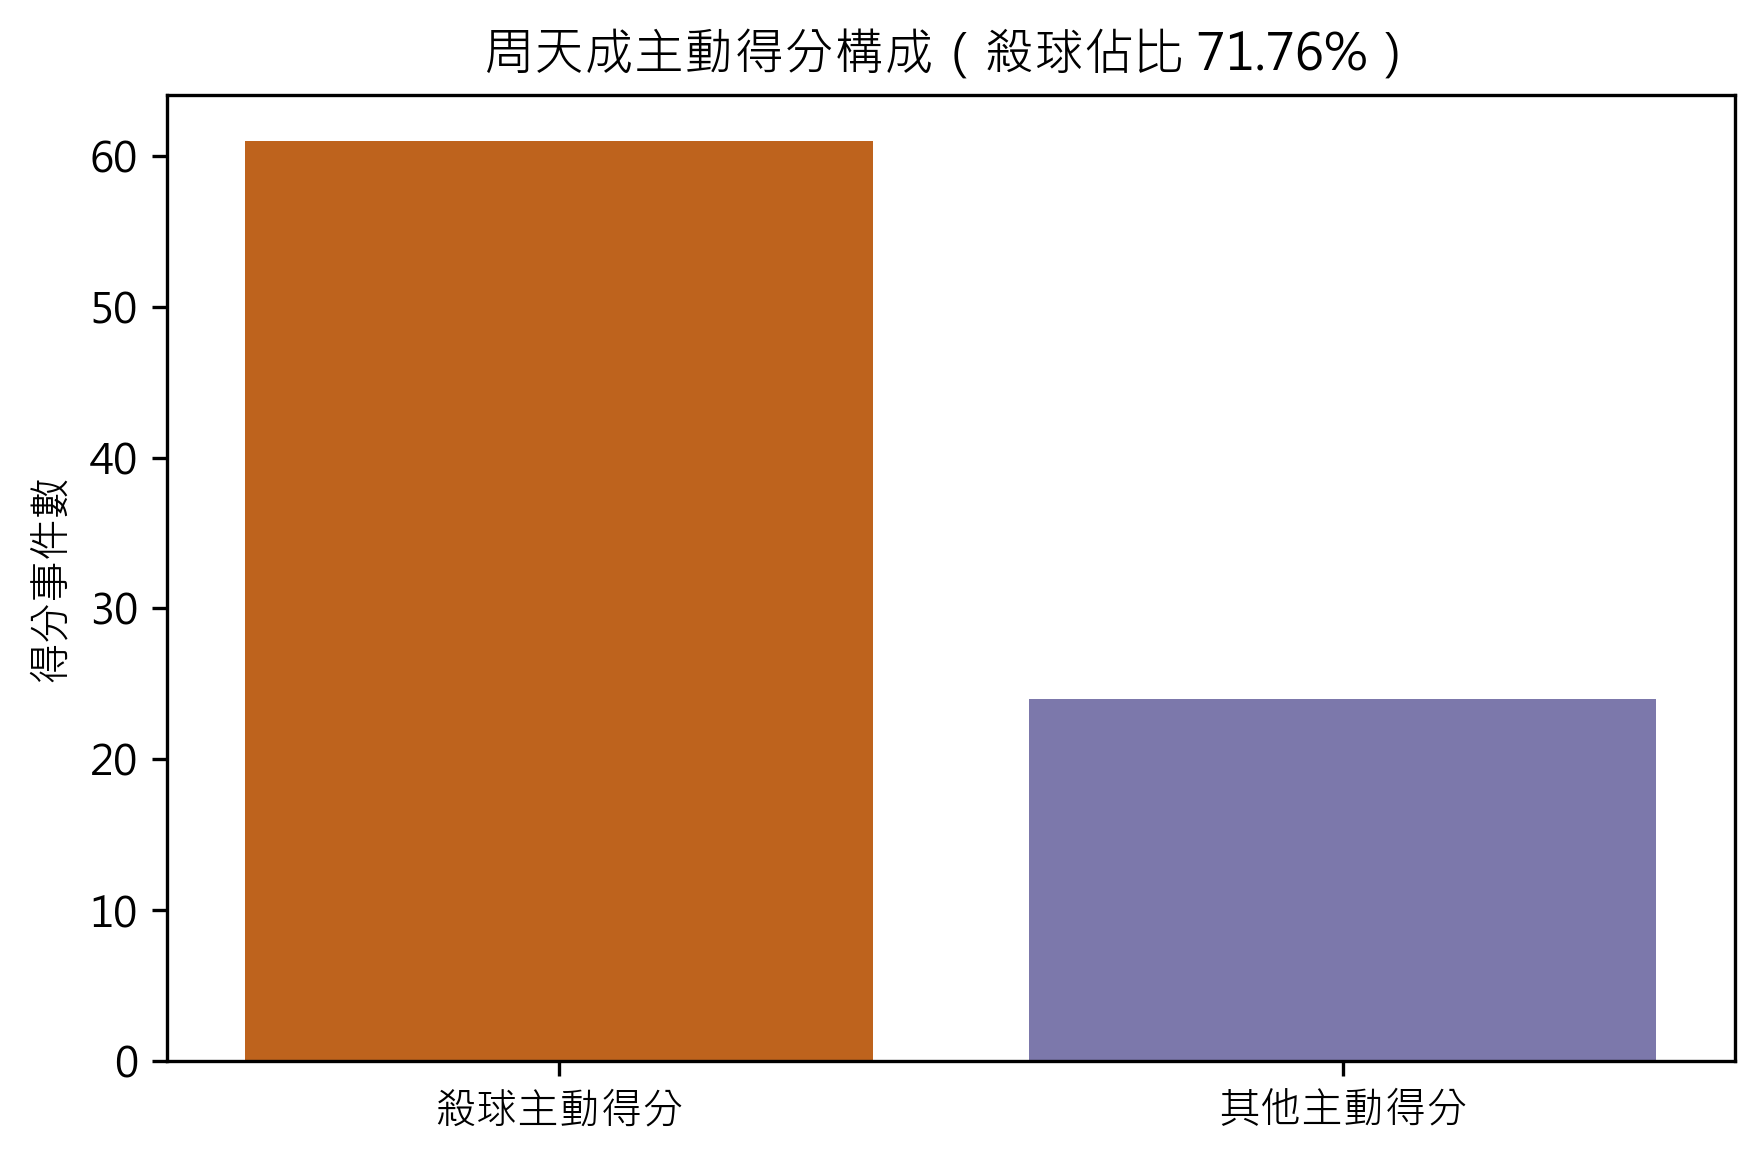

In [ ]:
required_cols = ['match_id', 'set', 'rally', 'type', 'player', 'getpoint_player']

if len(df) == 0:
    print('資料為空，無法計算。')
    fig = plt.figure(figsize=(6, 4))
elif not set(required_cols).issubset(df.columns):
    missing_cols = sorted(set(required_cols) - set(df.columns))
    print(f'缺少必要欄位：{missing_cols}')
    fig = plt.figure(figsize=(6, 4))
else:
    player_name = 'CHOU Tien Chen'
    group_cols = ['match_id', 'set', 'rally']

    work_df = df.sort_values(group_cols + ['ball_round']).copy()
    terminal_df = (
        work_df
        .groupby(group_cols, sort=False, as_index=False)
        .tail(1)
        .copy()
    )

    scoring_df = terminal_df.loc[
        terminal_df['getpoint_player'].notna()
    ].copy()

    active_win_df = scoring_df.loc[
        (scoring_df['player'] == player_name) &
        (scoring_df['getpoint_player'] == player_name)
    ].copy()

    smash_active_win_df = active_win_df.loc[
        active_win_df['type'] == '殺球'
    ].copy()

    total_active_wins = len(active_win_df)
    smash_active_wins = len(smash_active_win_df)

    percentage = (
        smash_active_wins / total_active_wins * 100
        if total_active_wins > 0 else 0.0
    )

    result_df = pd.DataFrame({
        '統計項目': ['周天成殺球主動得分', '周天成總主動得分', '殺球得分佔總得分比例'],
        '數值': [smash_active_wins, total_active_wins, percentage]
    })

    print(result_df.to_string(index=False))
    print(f'周天成使用「殺球」得分佔他總得分的百分比：{percentage:.2f}%')

    fig, ax = plt.subplots(figsize=(6, 4))
    chart_df = pd.DataFrame({
        '得分類型': ['殺球主動得分', '其他主動得分'],
        '得分次數': [
            smash_active_wins,
            total_active_wins - smash_active_wins
        ]
    })

    sns.barplot(
        data=chart_df,
        x='得分類型',
        y='得分次數',
        hue='得分類型',
        palette=['#d95f02', '#7570b3'],
        legend=False,
        ax=ax
    )
    ax.set_title(f'周天成主動得分構成（殺球佔比 {percentage:.2f}%）')
    ax.set_xlabel('')
    ax.set_ylabel('得分事件數')
    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 6
**問題**: 在第一場次中，每回合用的拍數，繪圖
> **使用的資料欄位群組**: `game_structure`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


第一場次 match_id：1.0
回合總數：107
每回合拍數分布：
 拍數  回合數
  2    6
  3    4
  4    6
  5    8
  6    6
  7    5
  8    4
  9    5
 10    3
 11    4
 12    3
 13    2
 14    9
 15    3
 16    4
 17    3
…（輸出已截斷；notebook 僅保留重點）


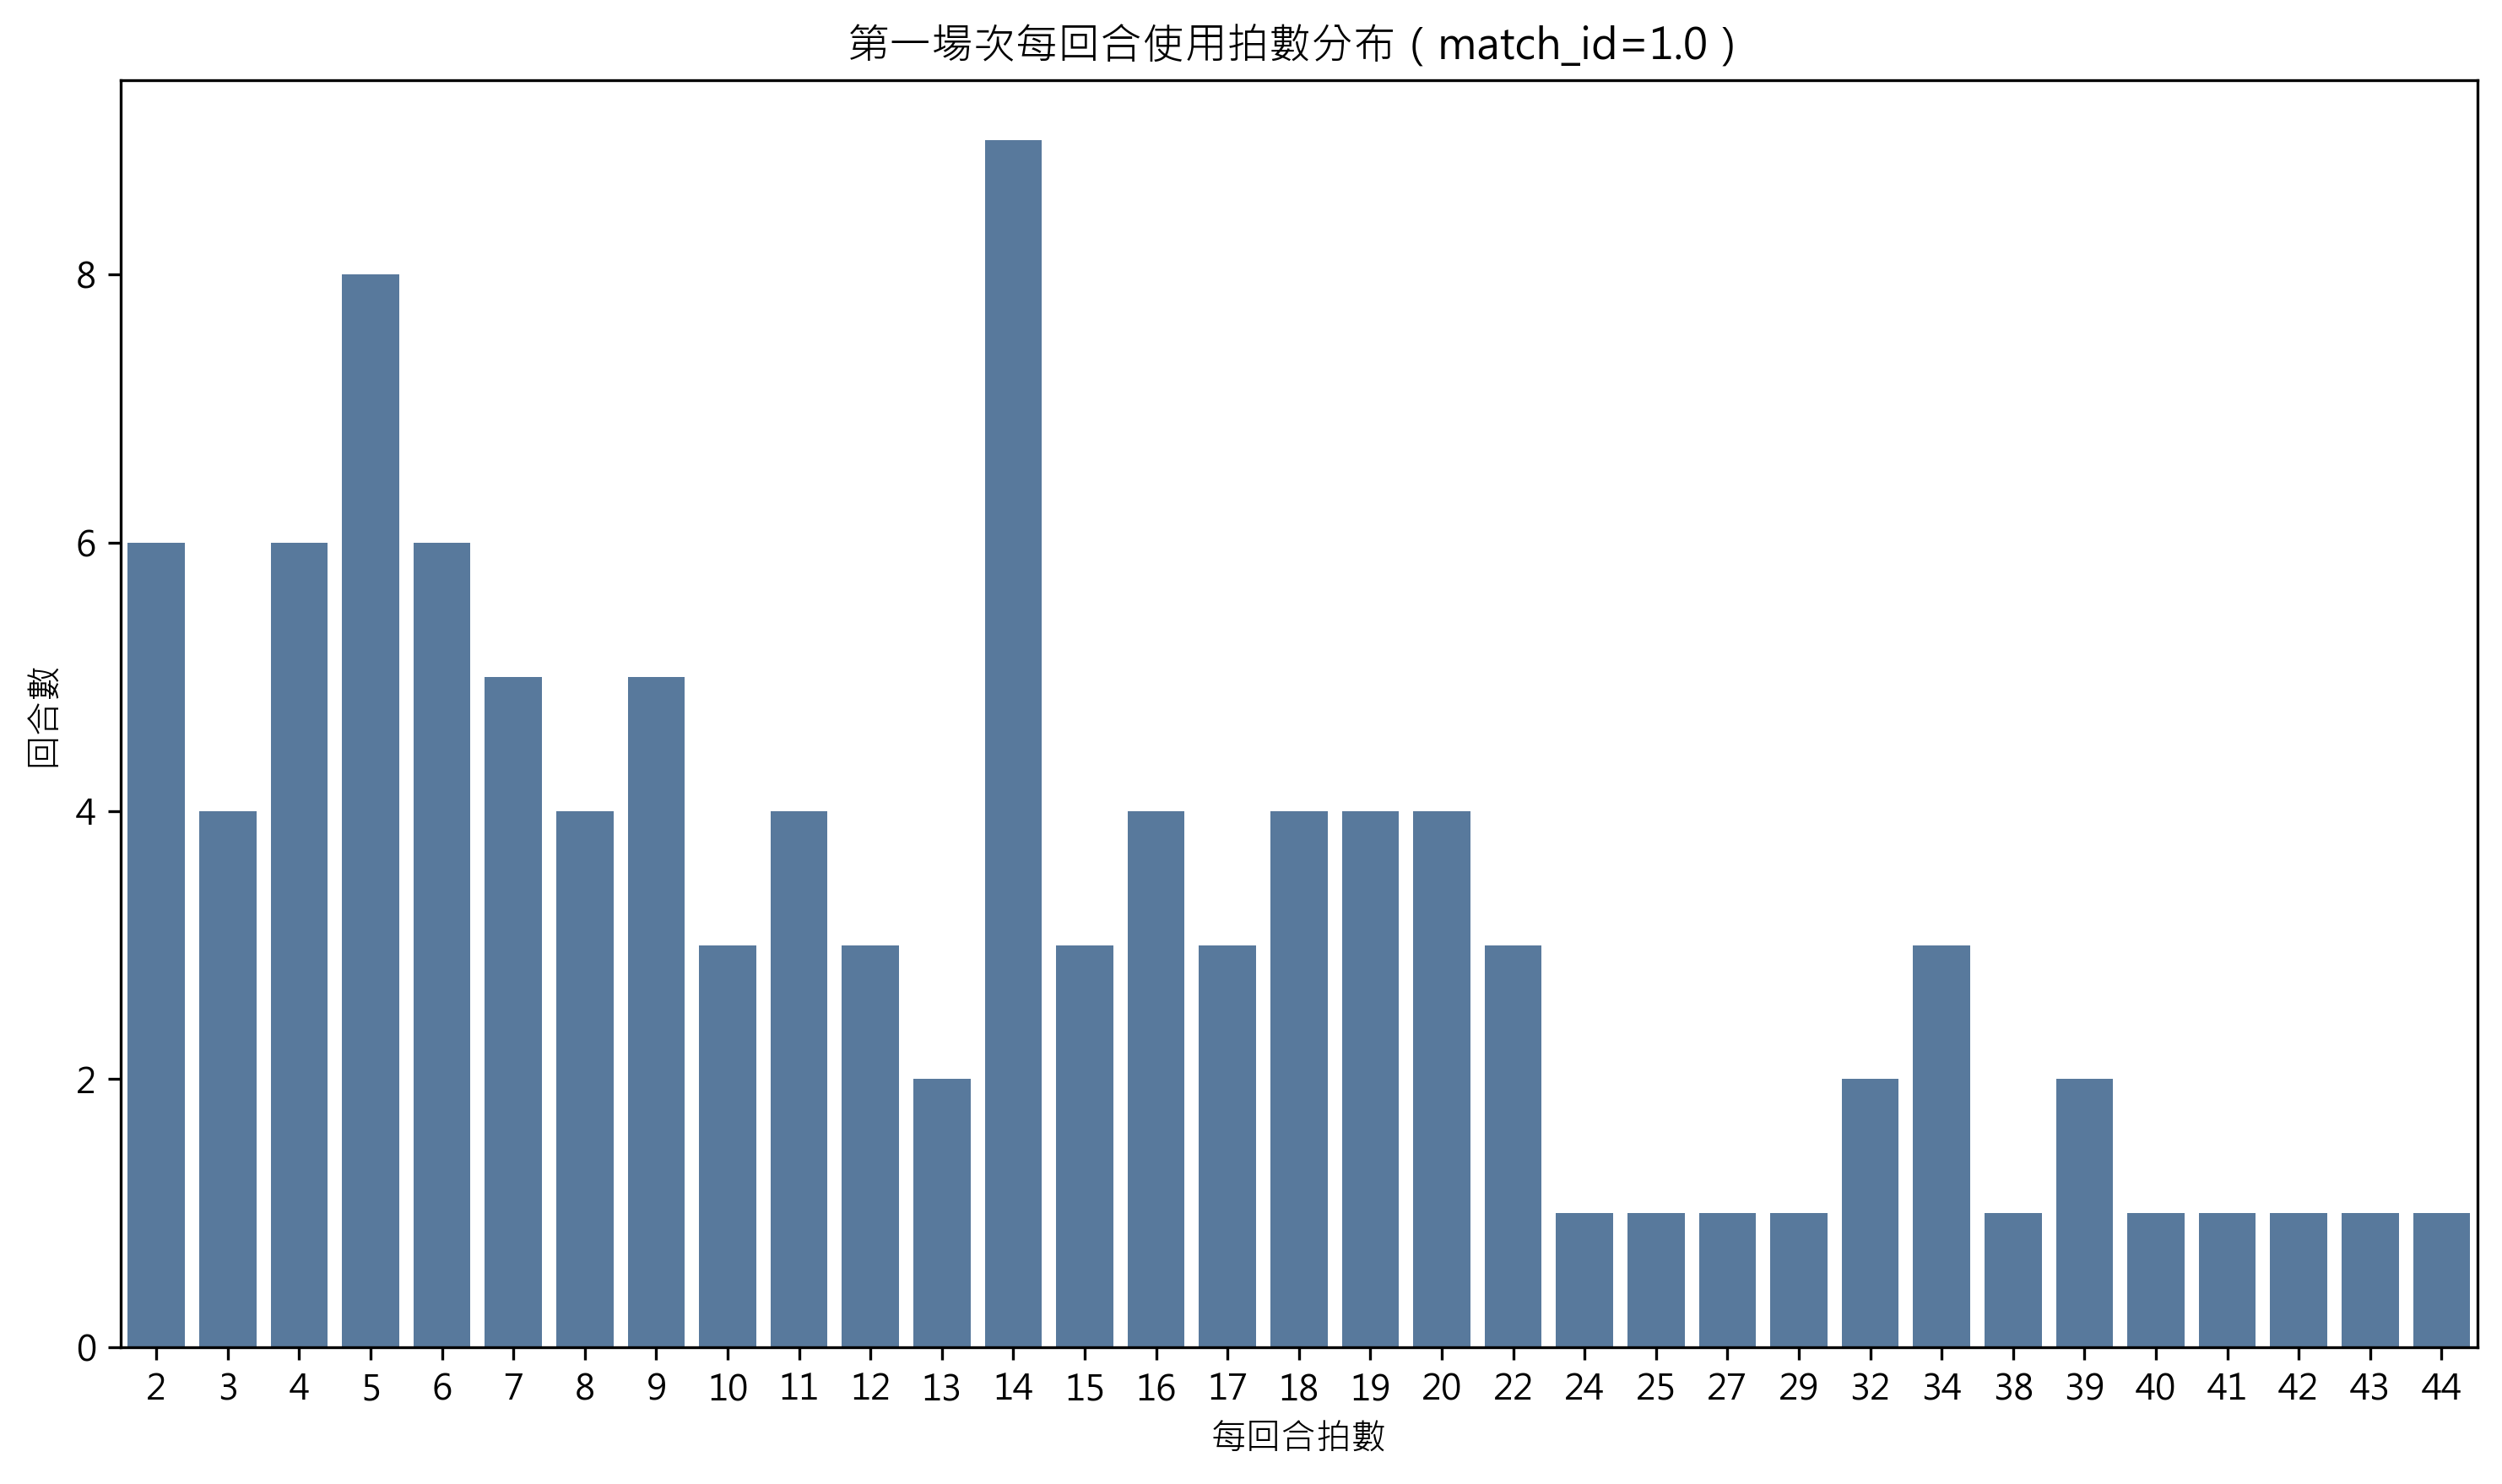

In [ ]:
required_cols = ['match_id', 'set', 'rally', 'ball_round']

if len(df) == 0:
    print("資料為空，無法分析。")
else:
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        structure_df = df[required_cols].dropna().copy()

        if len(structure_df) == 0:
            print("必要欄位沒有完整資料，無法分析。")
        else:
            first_match_id = structure_df['match_id'].min()
            first_match_df = structure_df[
                structure_df['match_id'] == first_match_id
            ].copy()

            rally_shots = (
                first_match_df
                .groupby(['match_id', 'set', 'rally'], as_index=False)
                .agg(拍數=('ball_round', 'count'))
            )

            if len(rally_shots) == 0:
                print(f"第一場次（match_id={first_match_id}）沒有完整回合資料。")
            else:
                shot_distribution = (
                    rally_shots
                    .groupby('拍數')
                    .size()
                    .reset_index(name='回合數')
                    .sort_values('拍數')
                )

                print(f"第一場次 match_id：{first_match_id}")
                print(f"回合總數：{len(rally_shots)}")
                print("每回合拍數分布：")
                print(shot_distribution.to_string(index=False))

                fig, ax = plt.subplots(figsize=(10, 6))
                sns.barplot(
                    data=shot_distribution,
                    x='拍數',
                    y='回合數',
                    color='#4C78A8',
                    ax=ax
                )
                ax.set_title(f'第一場次每回合使用拍數分布（match_id={first_match_id}）')
                ax.set_xlabel('每回合拍數')
                ax.set_ylabel('回合數')
                ax.set_xticklabels(
                    [str(int(label.get_text())) for label in ax.get_xticklabels()]
                )
                plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 10
**問題**: 當周天成站在前場時，他最主要的得分球種?
> **使用的資料欄位群組**: `game_structure, shot_type, player_location, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm+semantic_guard）


分析球員：CHOU Tien Chen
站位範圍：前場區域 17-24
得分口徑：Active Win（player == getpoint_player）
前場主動得分總拍數：9
最主要得分球種：殺球，7 拍，占比 77.78%

各得分球種統計：
type  主動得分拍數  占前場主動得分比例
  殺球       7      77.78
 推撲球       2      22.22


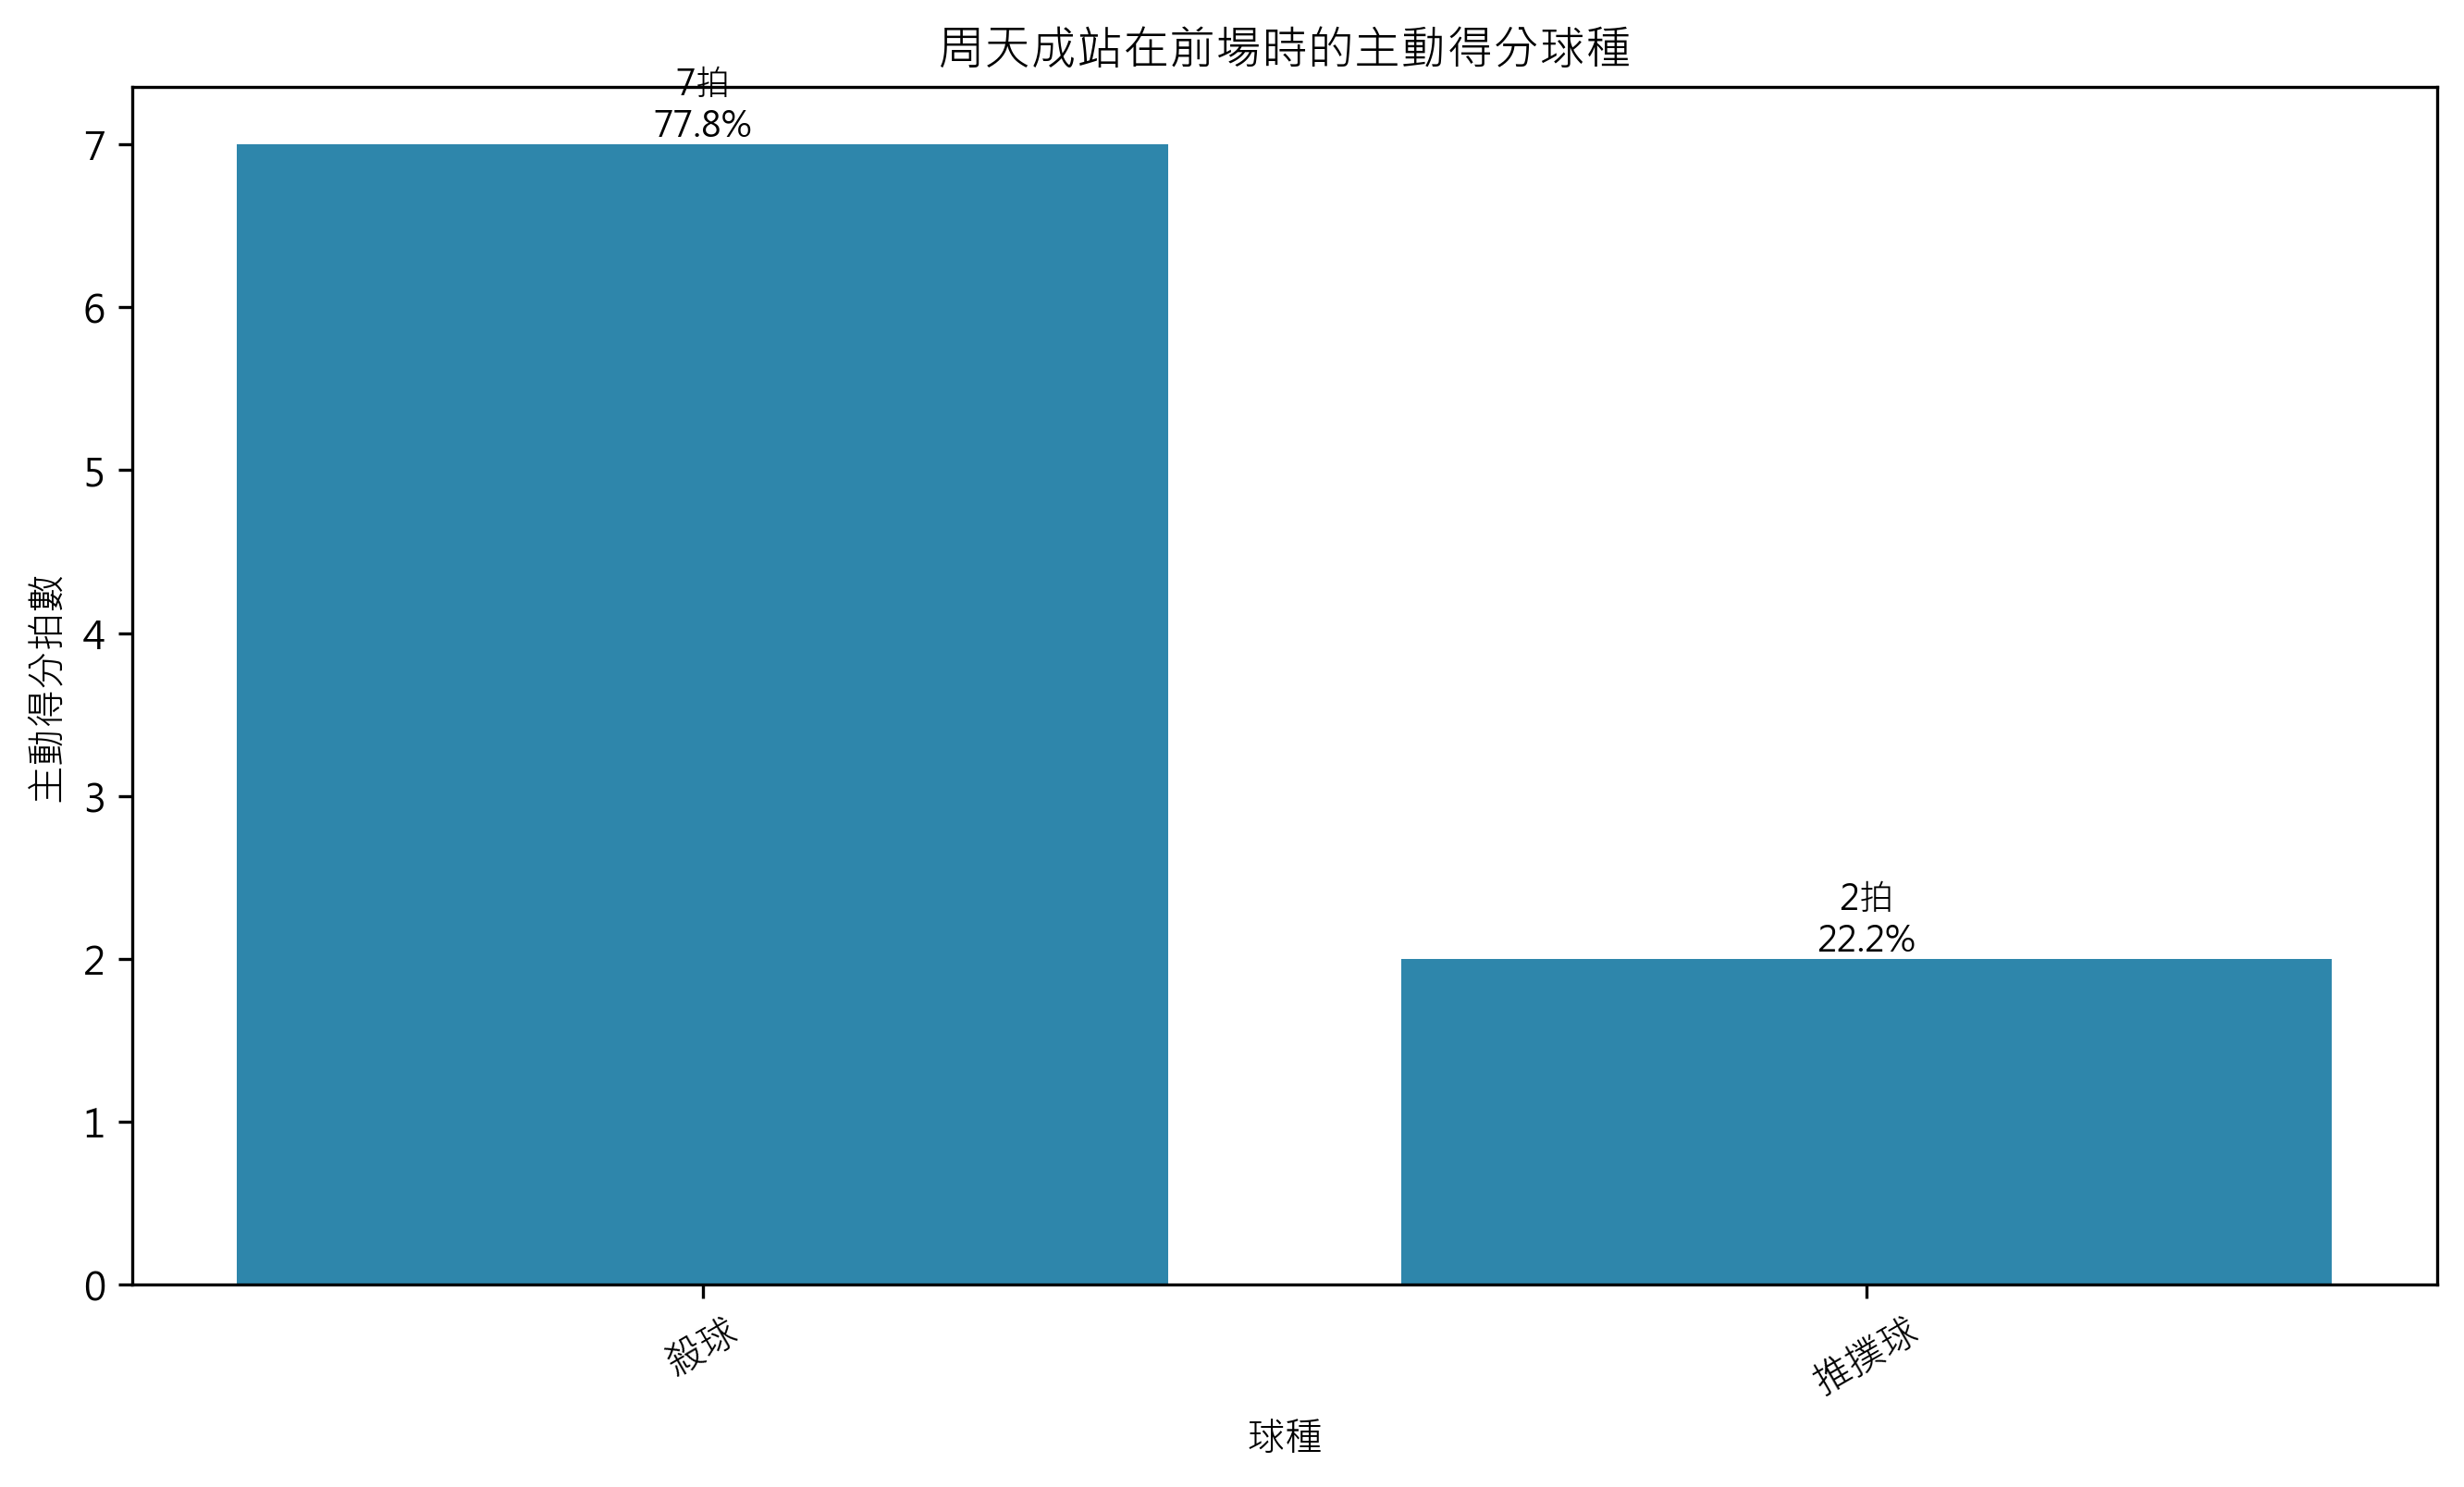

In [ ]:
required_columns = {
    'player',
    'player_location_area',
    'getpoint_player',
    'type'
}

if len(df) == 0:
    print("資料為空，無法分析。")
elif not required_columns.issubset(df.columns):
    print(f"缺少必要欄位：{sorted(required_columns - set(df.columns))}")
else:
    # 依正式 Court Grid Definitions：前場為 17-24
    court_grid_definitions = {
        '前場': [17, 18, 19, 20, 21, 22, 23, 24],
        '中場': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
        '後場': [1, 2, 3, 4],
        '左側出界': [29, 30, 31],
        '右側出界': [25, 26, 27],
        '後方出界': [28, 32]
    }

    front_zones = set(court_grid_definitions['前場'])
    target_player = 'CHOU Tien Chen'

    analysis_df = df.loc[
        df['player'].eq(target_player)
        & df['player_location_area'].isin(front_zones)
        & df['getpoint_player'].notna()
        & df['getpoint_player'].eq(df['player'])
        & df['type'].notna(),
        ['match_id', 'set', 'rally', 'ball_round', 'player_location_area', 'type']
    ].copy()

    if len(analysis_df) == 0:
        print("找不到周天成站在前場且主動得分的擊球資料。")
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title('周天成前場主動得分球種')
        ax.set_xlabel('球種')
        ax.set_ylabel('主動得分拍數')
        ax.text(0.5, 0.5, '無符合資料', ha='center', va='center')
        ax.set_xticks([])
        plt.tight_layout()
    else:
        shot_summary = (
            analysis_df.groupby('type', as_index=False)
            .size()
            .rename(columns={'size': '主動得分拍數'})
            .sort_values(['主動得分拍數', 'type'], ascending=[False, True])
            .reset_index(drop=True)
        )

        total_active_wins = int(shot_summary['主動得分拍數'].sum())
        shot_summary['占前場主動得分比例'] = (
            shot_summary['主動得分拍數'] / total_active_wins * 100
        ).round(2)

        main_shot = shot_summary.iloc[0]

        print(f"分析球員：{target_player}")
        print("站位範圍：前場區域 17-24")
        print("得分口徑：Active Win（player == getpoint_player）")
        print(f"前場主動得分總拍數：{total_active_wins}")
        print(
            f"最主要得分球種：{main_shot['type']}，"
            f"{int(main_shot['主動得分拍數'])} 拍，"
            f"占比 {main_shot['占前場主動得分比例']:.2f}%"
        )
        print("\n各得分球種統計：")
        print(shot_summary.to_string(index=False))

        fig, ax = plt.subplots(figsize=(9, 5.5))
        bars = ax.bar(
            shot_summary['type'],
            shot_summary['主動得分拍數'],
            color='#2E86AB'
        )
        ax.set_title('周天成站在前場時的主動得分球種')
        ax.set_xlabel('球種')
        ax.set_ylabel('主動得分拍數')
        ax.tick_params(axis='x', rotation=30)

        for bar, percentage in zip(
            bars,
            shot_summary['占前場主動得分比例']
        ):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f'{int(bar.get_height())}拍\n{percentage:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9
            )

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 13
**問題**: 幫我統整周天成所有球種的使用比例，以及每種球種的「得分次數」和「失誤次數」。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


分析球員：CHOU Tien Chen
統計口徑：
- 使用比例：周天成所有有效擊球紀錄中，各球種的使用次數比例。
- 得分次數：周天成擊球且該拍主動得分（player == getpoint_player）。
- 失誤次數：周天成為最後擊球者且對手得分（player == 周天成 且 getpoint_player == opponent）。
  球種  使用次數  得分次數  失誤次數  使用比例
 發短球   147     0     0  5.63
 發長球    34     0     0  1.30
  長球   275     2    11 10.54
  殺球   299    61    20 11.46
  切球   211     2     7  8.09
  挑球   270     0    17 10.35
  平球   106     2     8  4.06
 網前球   582     4    40 22.31
 推撲球   334     9    20 12.80
接殺防守   351     5    37 13.45


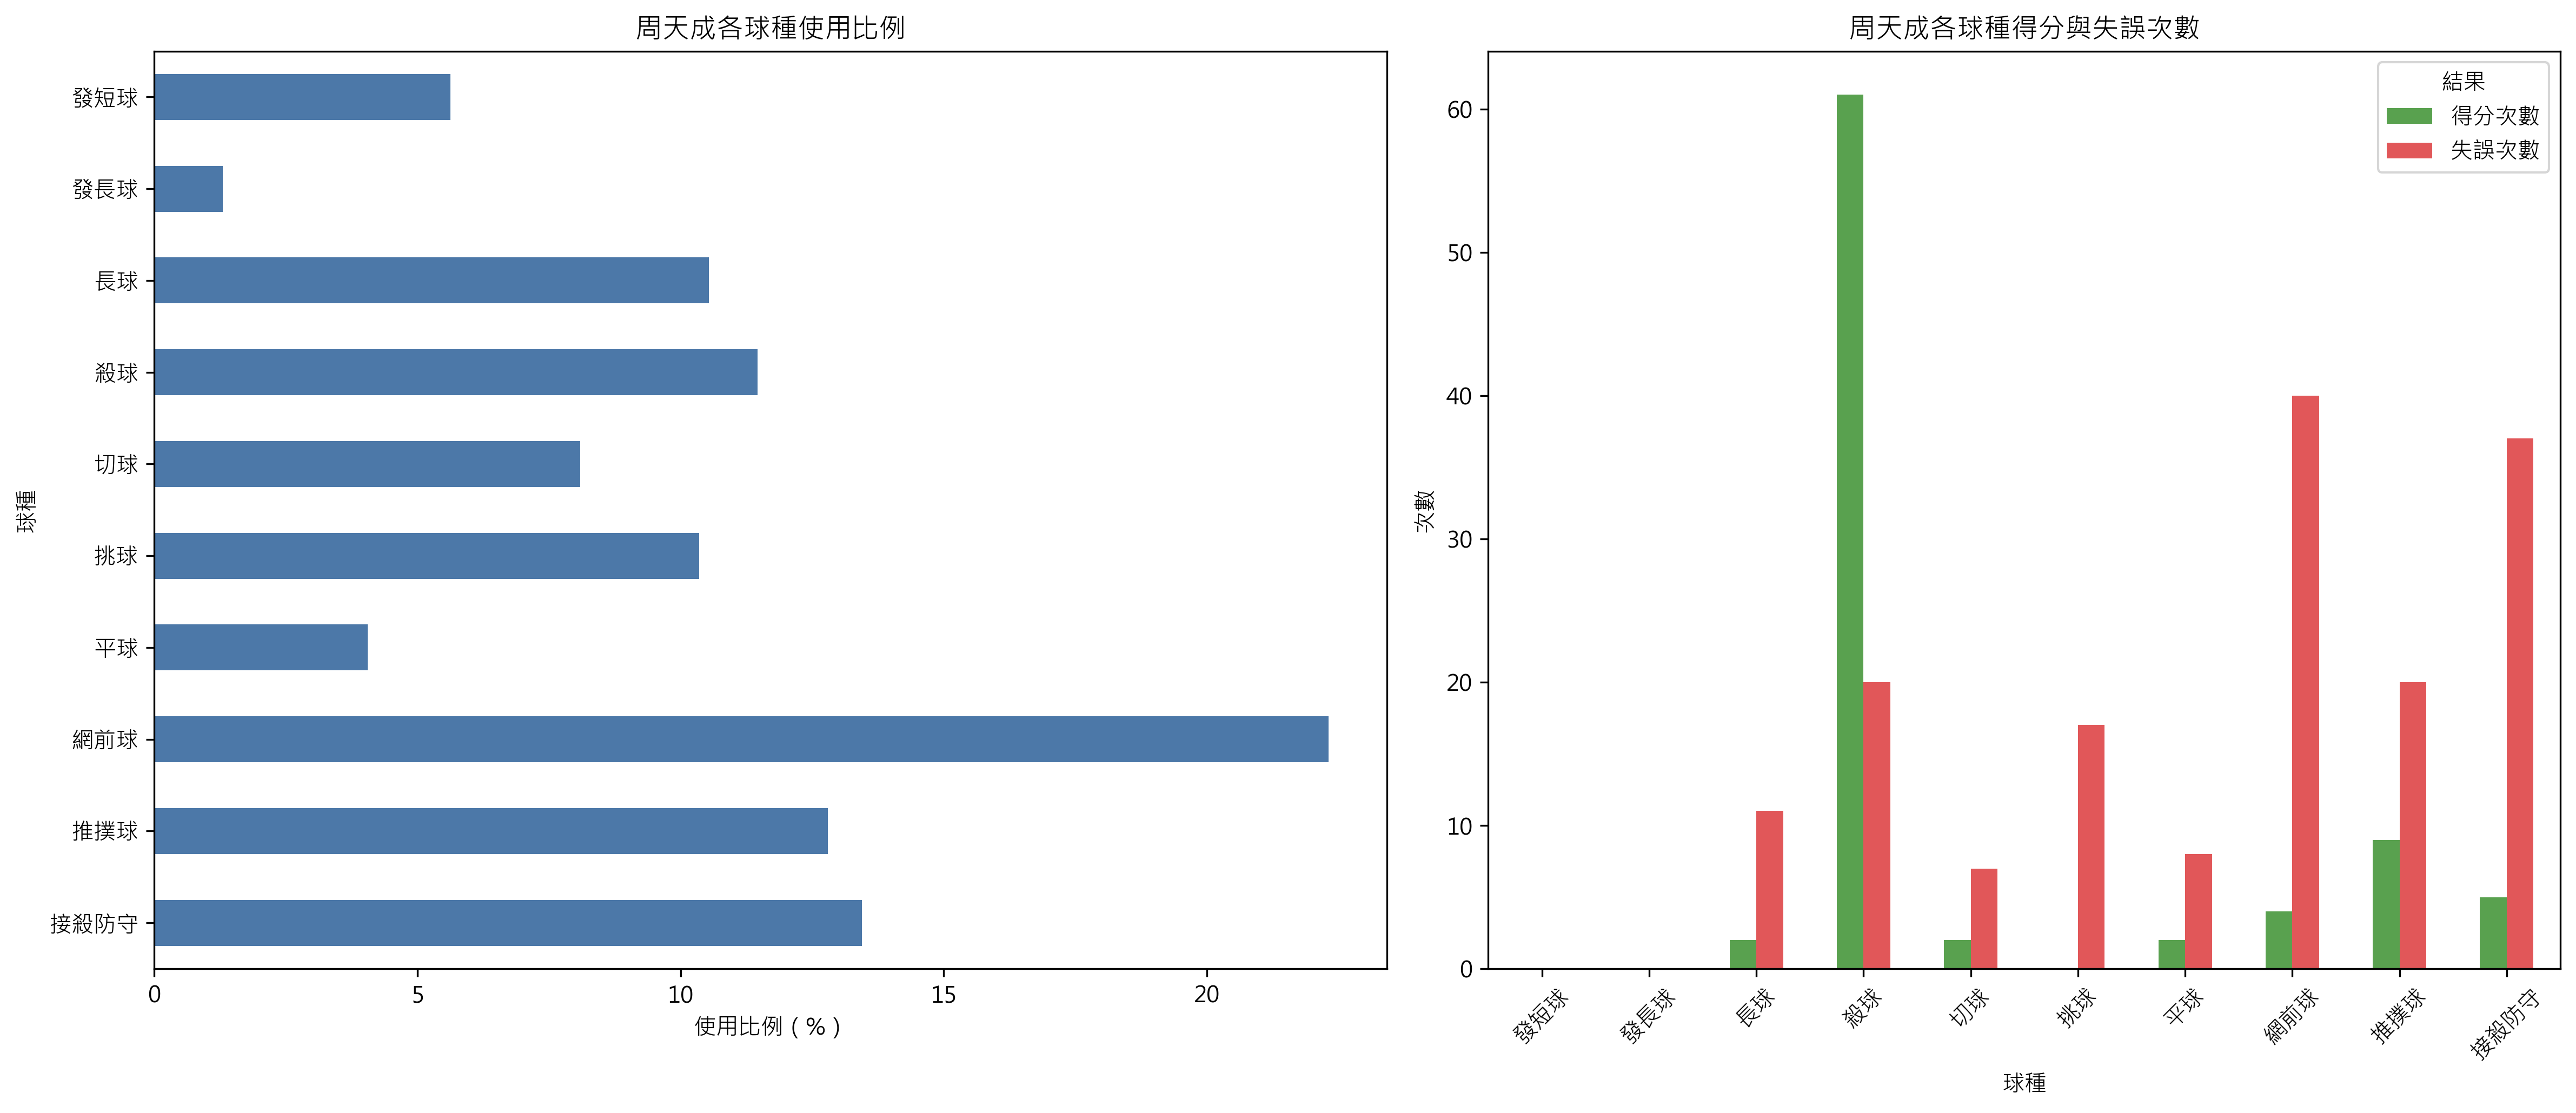

In [ ]:
required_columns = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'opponent', 'type', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法進行分析。')
    fig = plt.figure(figsize=(10, 6))
else:
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f'缺少必要欄位：{missing_columns}')

    target_player = 'CHOU Tien Chen'

    data = df.copy().sort_values(
        ['match_id', 'set', 'rally', 'ball_round'],
        kind='stable'
    )

    target_strokes = data[
        (data['player'] == target_player) &
        data['type'].notna()
    ].copy()

    if len(target_strokes) == 0:
        print(f'資料中沒有{target_player}的有效球種紀錄。')
        fig = plt.figure(figsize=(10, 6))
    else:
        shot_types = [
            '發短球', '發長球', '長球', '殺球', '切球',
            '挑球', '平球', '網前球', '推撲球', '接殺防守', '接不到'
        ]

        usage_counts = (
            target_strokes.groupby('type', dropna=False)
            .size()
            .rename('使用次數')
        )

        result_strokes = target_strokes[
            target_strokes['getpoint_player'].notna()
        ].copy()

        active_win_counts = (
            result_strokes[
                result_strokes['getpoint_player'] == result_strokes['player']
            ]
            .groupby('type')
            .size()
            .rename('得分次數')
        )

        own_error_counts = (
            result_strokes[
                (result_strokes['player'] == target_player) &
                (result_strokes['getpoint_player'] == result_strokes['opponent'])
            ]
            .groupby('type')
            .size()
            .rename('失誤次數')
        )

        result = pd.concat(
            [usage_counts, active_win_counts, own_error_counts],
            axis=1
        ).fillna(0)

        result['使用次數'] = result['使用次數'].astype(int)
        result['得分次數'] = result['得分次數'].astype(int)
        result['失誤次數'] = result['失誤次數'].astype(int)

        result['使用比例'] = (
            result['使用次數'] / result['使用次數'].sum() * 100
        )

        ordered_types = [shot_type for shot_type in shot_types if shot_type in result.index]
        extra_types = [shot_type for shot_type in result.index if shot_type not in ordered_types]
        result = result.reindex(ordered_types + extra_types)

        output_table = result.reset_index().rename(columns={'type': '球種'})
        output_table['使用比例'] = output_table['使用比例'].round(2)

        print(f'分析球員：{target_player}')
        print('統計口徑：')
        print('- 使用比例：周天成所有有效擊球紀錄中，各球種的使用次數比例。')
        print('- 得分次數：周天成擊球且該拍主動得分（player == getpoint_player）。')
        print('- 失誤次數：周天成為最後擊球者且對手得分（player == 周天成 且 getpoint_player == opponent）。')
        print(output_table.to_string(index=False))

        plot_data = output_table.set_index('球種')

        fig, axes = plt.subplots(
            1, 2,
            figsize=(16, 7),
            gridspec_kw={'width_ratios': [1.15, 1]}
        )

        plot_data['使用比例'].plot(
            kind='barh',
            ax=axes[0],
            color='#4C78A8'
        )
        axes[0].set_title('周天成各球種使用比例')
        axes[0].set_xlabel('使用比例（%）')
        axes[0].set_ylabel('球種')
        axes[0].invert_yaxis()

        count_data = plot_data[['得分次數', '失誤次數']]
        count_data.plot(
            kind='bar',
            ax=axes[1],
            color=['#59A14F', '#E15759']
        )
        axes[1].set_title('周天成各球種得分與失誤次數')
        axes[1].set_xlabel('球種')
        axes[1].set_ylabel('次數')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].legend(title='結果')

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 16
**問題**: 給我周天成最常見的失分原因
> **使用的資料欄位群組**: `game_structure, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


CHOU Tien Chen 最常見的失分原因：出界
失分次數：74
失分比例：46.84%

各失分原因統計：
失分原因  失分次數   失分比例
  出界    74 46.84%
  掛網    60 37.97%
 未過網    24 15.19%


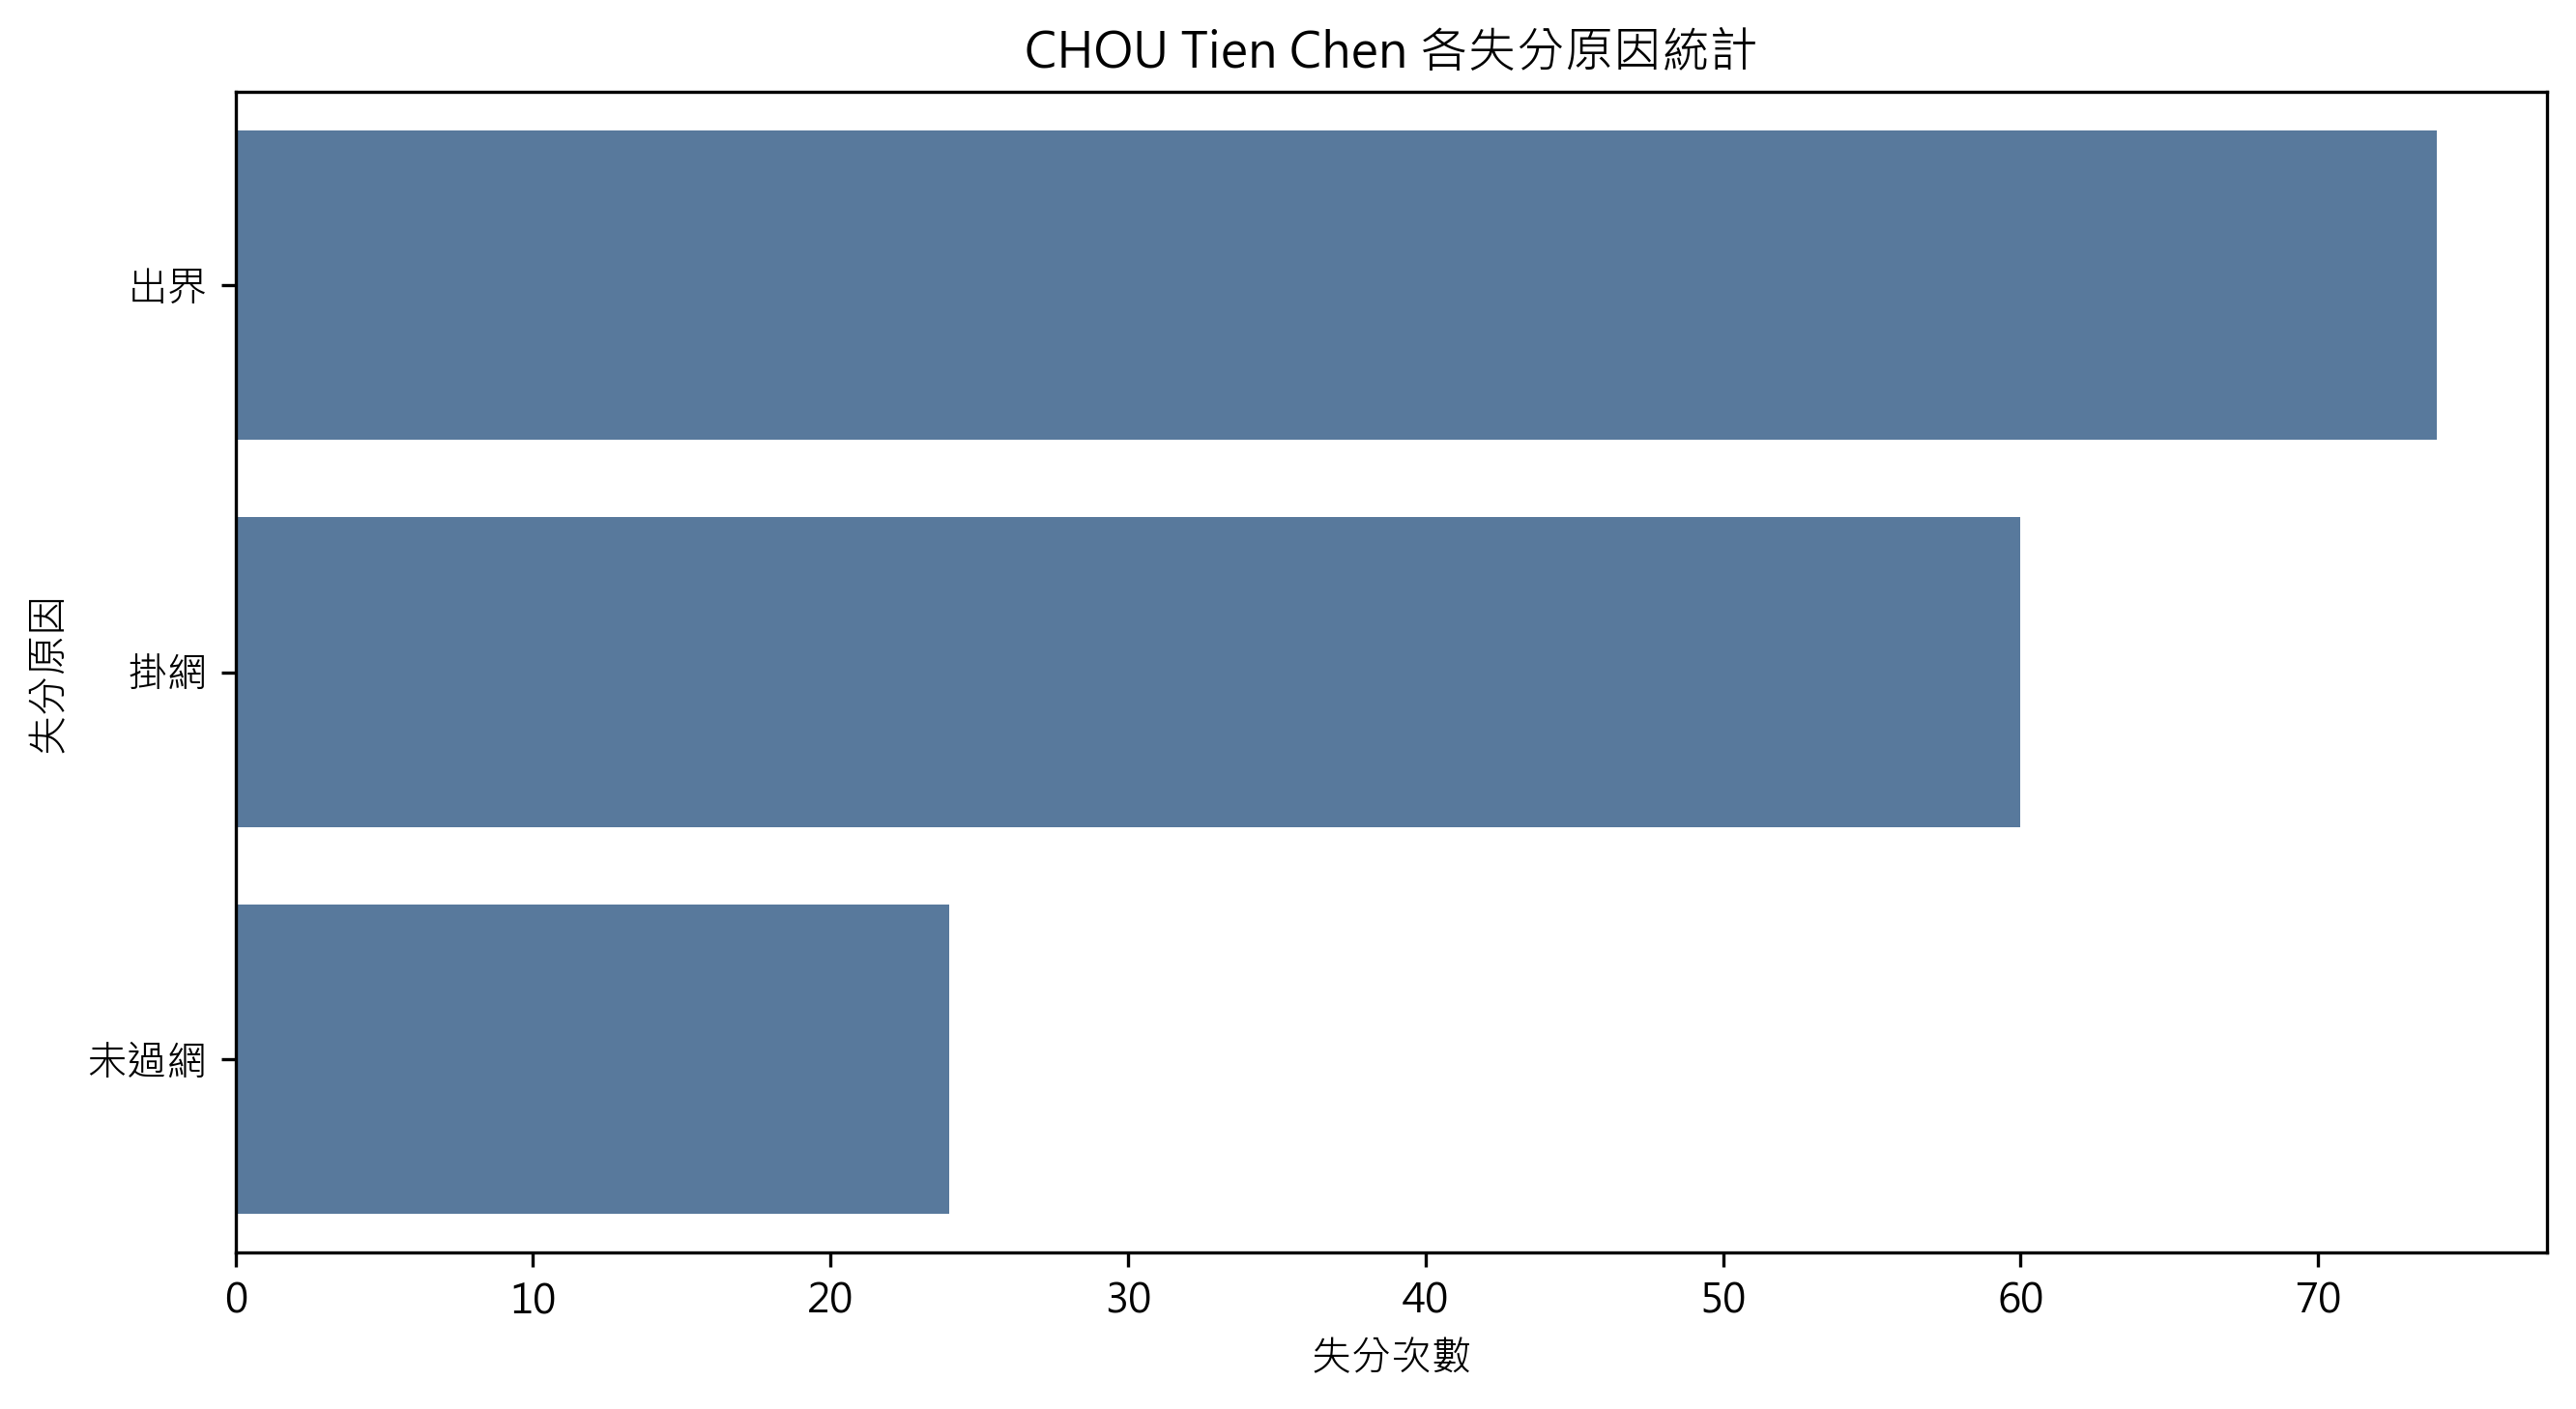

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    target_player = "CHOU Tien Chen"

    required_cols = ["match_id", "set", "rally", "player", "opponent",
                     "getpoint_player", "lose_reason"]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        # 周天成失分：最後一拍由周天成擊球，且對手取得該回合分數
        loss_events = df[
            (df["player"] == target_player) &
            (df["getpoint_player"] == df["opponent"]) &
            (df["lose_reason"].notna())
        ][["match_id", "set", "rally", "ball_round", "lose_reason"]].copy()

        if len(loss_events) == 0:
            print(f"{target_player} 沒有可辨識的失分原因資料。")
        else:
            reason_counts = (
                loss_events["lose_reason"]
                .value_counts()
                .rename_axis("失分原因")
                .reset_index(name="失分次數")
            )
            reason_counts["失分比例"] = (
                reason_counts["失分次數"] / reason_counts["失分次數"].sum() * 100
            )

            print(f"{target_player} 最常見的失分原因：{reason_counts.iloc[0]['失分原因']}")
            print(f"失分次數：{int(reason_counts.iloc[0]['失分次數'])}")
            print(f"失分比例：{reason_counts.iloc[0]['失分比例']:.2f}%")
            print("\n各失分原因統計：")
            print(reason_counts.to_string(index=False, formatters={"失分比例": "{:.2f}%".format}))

            fig, ax = plt.subplots(figsize=(9, 5))
            sns.barplot(
                data=reason_counts,
                x="失分次數",
                y="失分原因",
                color="#4C78A8",
                ax=ax
            )
            ax.set_title(f"{target_player} 各失分原因統計")
            ax.set_xlabel("失分次數")
            ax.set_ylabel("失分原因")
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 17
**問題**: 繪製周天成所有輸球原因為'掛網'時的球員站位熱區圖？
> **使用的資料欄位群組**: `player_location, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）


周天成因「掛網」失分的單拍數：60
       player_location_x  player_location_y
count             60.000             60.000
mean              -0.111              0.147
std                0.220              0.230
min               -0.656             -0.236
25%               -0.257             -0.045
50%               -0.139              0.158
75%                0.054              0.316
max                0.384              0.683


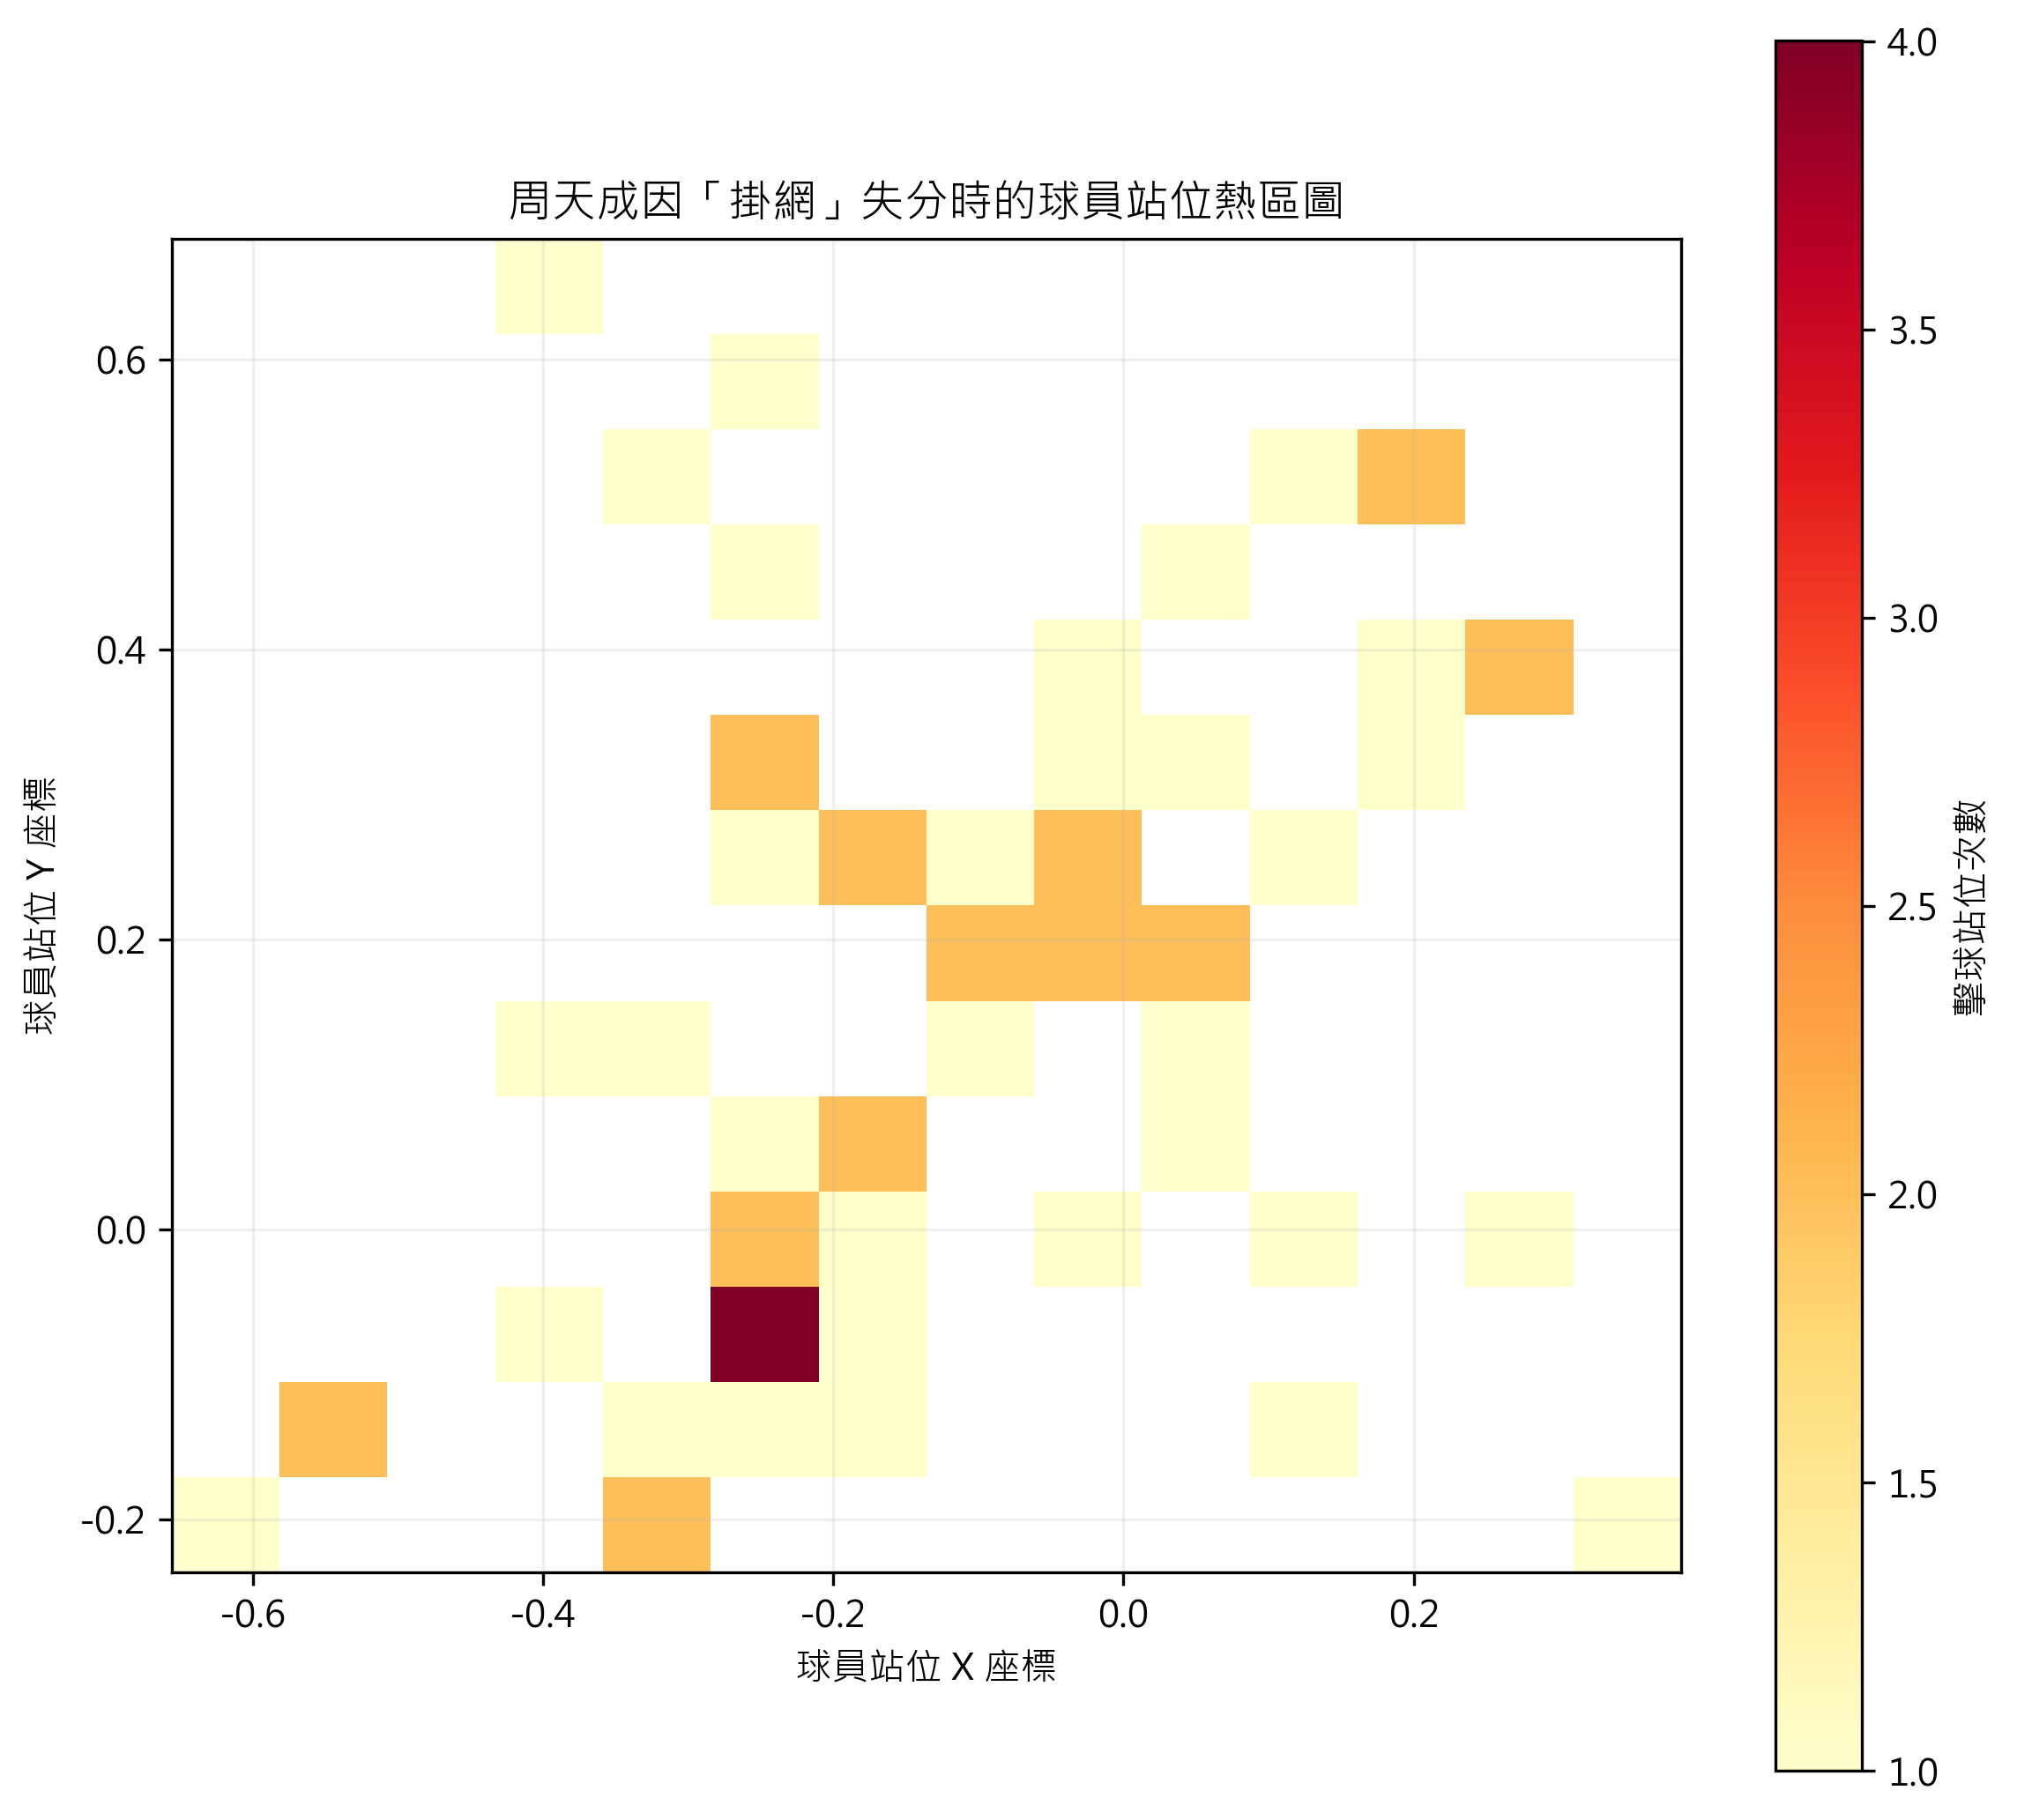

In [ ]:
required_columns = {
    'player',
    'lose_reason',
    'player_location_x',
    'player_location_y'
}

missing_columns = required_columns.difference(df.columns)

if len(missing_columns) > 0:
    print(f"缺少必要欄位：{sorted(missing_columns)}")
else:
    if len(df) == 0:
        print("df 無資料，無法分析。")
    else:
        target_player = 'CHOU Tien Chen'
        target_reason = '掛網'

        filtered_df = df.loc[
            (df['player'] == target_player) &
            (df['lose_reason'] == target_reason),
            ['match_id', 'set', 'rally', 'ball_round',
             'player_location_x', 'player_location_y']
        ].dropna(subset=['player_location_x', 'player_location_y']).copy()

        print(f"周天成因「{target_reason}」失分的單拍數：{len(filtered_df)}")

        fig, ax = plt.subplots(figsize=(8, 7))

        if len(filtered_df) > 0:
            bin_count = max(5, min(20, int(len(filtered_df) ** 0.5) * 2))

            heatmap = ax.hist2d(
                filtered_df['player_location_x'],
                filtered_df['player_location_y'],
                bins=bin_count,
                cmap='YlOrRd',
                cmin=1
            )

            fig.colorbar(heatmap[3], ax=ax, label='擊球站位次數')

            ax.set_title('周天成因「掛網」失分時的球員站位熱區圖')
            ax.set_xlabel('球員站位 X 座標')
            ax.set_ylabel('球員站位 Y 座標')
            ax.set_aspect('equal', adjustable='box')
            ax.grid(alpha=0.2)

            print(
                filtered_df[
                    ['player_location_x', 'player_location_y']
                ].describe().round(3)
            )
        else:
            ax.set_title('周天成因「掛網」失分時的球員站位熱區圖（無資料）')
            ax.set_xlabel('球員站位 X 座標')
            ax.set_ylabel('球員站位 Y 座標')
            ax.text(
                0.5, 0.5, '沒有符合條件的站位資料',
                ha='center', va='center',
                transform=ax.transAxes
            )

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 18
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階段中，他自己移動距離的差異。
> **使用的資料欄位群組**: `game_structure, player_movement, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


周天成各比分階段單拍移動距離統計：
      比分階段  單拍數  平均移動距離    中位數    標準差  最小值    最大值
  開局（0-4分）  673  0.3151 0.3107 0.2093  0.0 0.9869
 中局（5-17分） 1754  0.3244 0.3193 0.2132  0.0 1.1697
關鍵分（18分以上）  182  0.3157 0.3106 0.1967  0.0 0.8459

各比分階段平均移動距離差異：
  比較階段  平均移動距離差異
 中局－開局    0.0092
關鍵分－開局    0.0006
關鍵分－中局   -0.0087


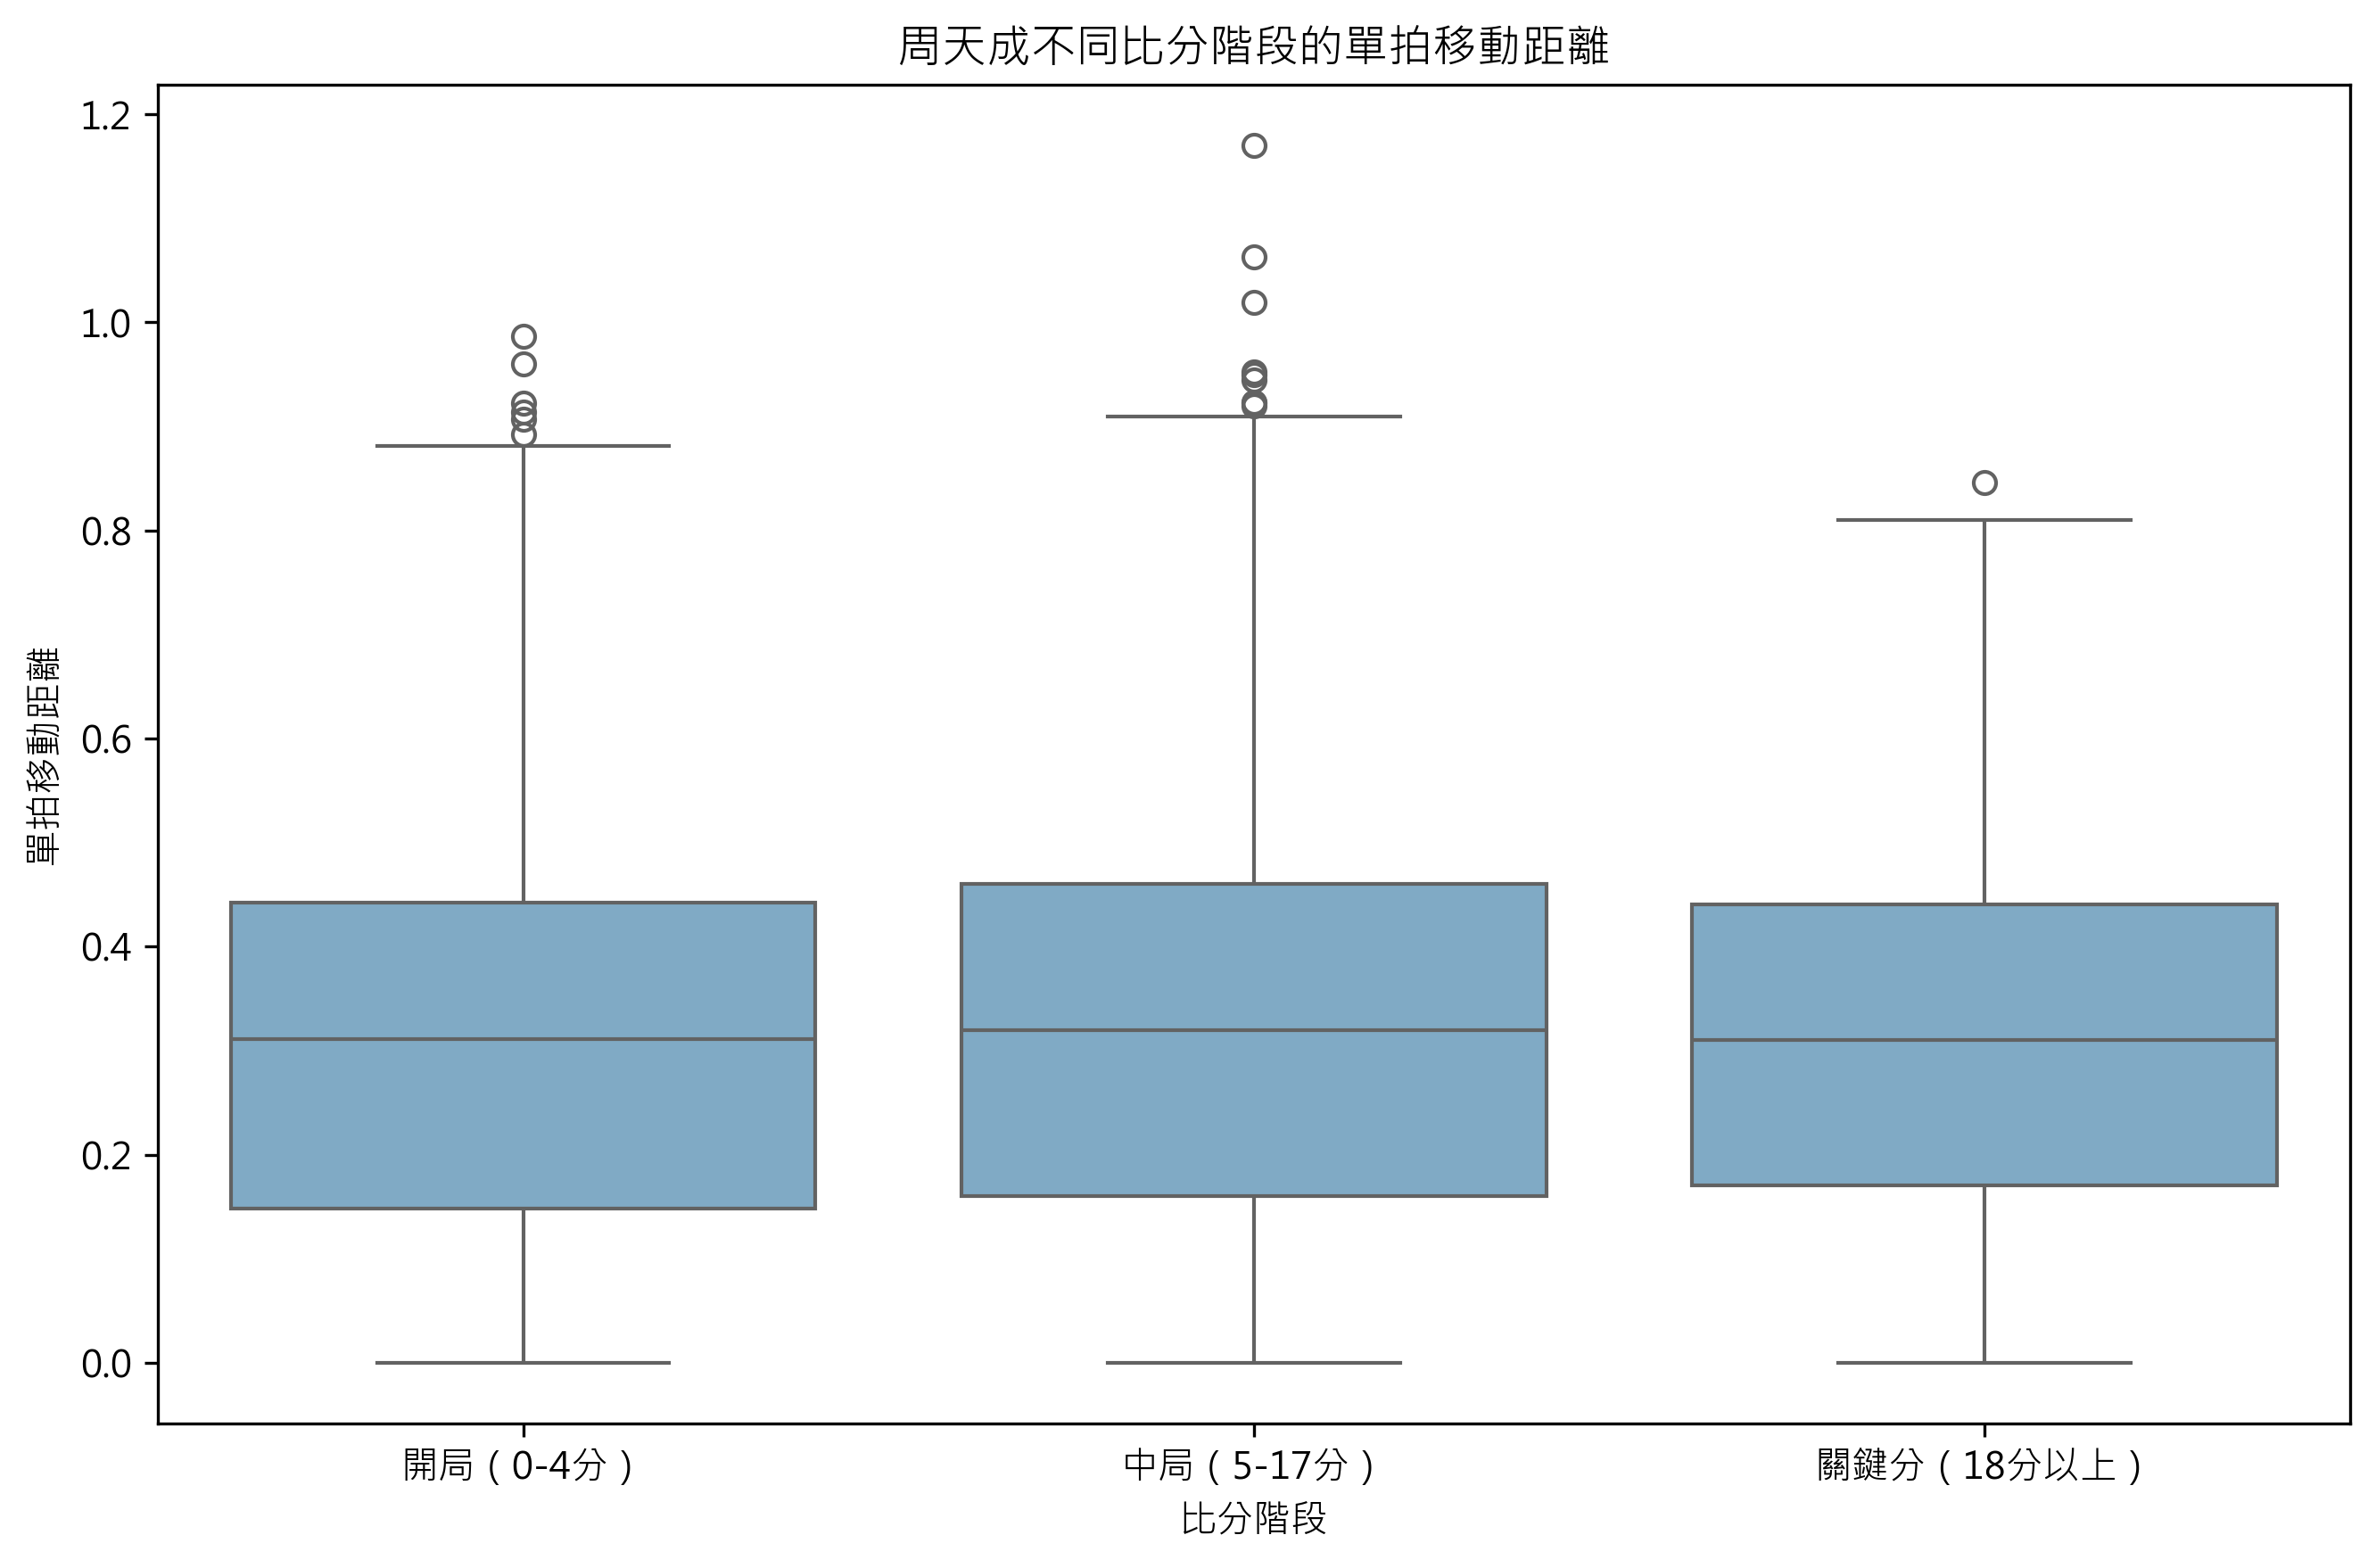

In [ ]:
fig = plt.figure(figsize=(9, 6))

required_cols = [
    'player',
    'player_move_x',
    'player_move_y',
    'CHOU Tien Chen_score'
]

if len(df) == 0:
    print('資料為空，無法分析。')
elif not set(required_cols).issubset(df.columns):
    missing_cols = [col for col in required_cols if col not in df.columns]
    print(f'缺少必要欄位：{missing_cols}')
else:
    player_name = 'CHOU Tien Chen'
    score_col = 'CHOU Tien Chen_score'

    movement_df = df.loc[
        df['player'].eq(player_name),
        required_cols
    ].copy()

    movement_df[score_col] = pd.to_numeric(
        movement_df[score_col],
        errors='coerce'
    )

    movement_df['移動距離'] = (
        movement_df['player_move_x'].astype(float).pow(2)
        + movement_df['player_move_y'].astype(float).pow(2)
    ).pow(0.5)

    movement_df['比分階段'] = pd.NA
    movement_df.loc[
        movement_df[score_col].between(0, 4, inclusive='both'),
        '比分階段'
    ] = '開局（0-4分）'
    movement_df.loc[
        movement_df[score_col].between(5, 17, inclusive='both'),
        '比分階段'
    ] = '中局（5-17分）'
    movement_df.loc[
        movement_df[score_col].ge(18),
        '比分階段'
    ] = '關鍵分（18分以上）'

    stage_order = ['開局（0-4分）', '中局（5-17分）', '關鍵分（18分以上）']

    movement_df = movement_df.dropna(
        subset=['移動距離', '比分階段']
    ).copy()

    if len(movement_df) == 0:
        print('沒有符合周天成及比分階段條件的有效移動資料。')
    else:
        movement_df['比分階段'] = pd.Categorical(
            movement_df['比分階段'],
            categories=stage_order,
            ordered=True
        )

        summary = (
            movement_df.groupby('比分階段', observed=False)['移動距離']
            .agg(
                單拍數='count',
                平均移動距離='mean',
                中位數='median',
                標準差='std',
                最小值='min',
                最大值='max'
            )
            .reindex(stage_order)
            .reset_index()
        )

        summary['平均移動距離'] = summary['平均移動距離'].round(4)
        summary['中位數'] = summary['中位數'].round(4)
        summary['標準差'] = summary['標準差'].round(4)
        summary['最小值'] = summary['最小值'].round(4)
        summary['最大值'] = summary['最大值'].round(4)

        mean_distance = (
            movement_df.groupby('比分階段', observed=False)['移動距離']
            .mean()
            .reindex(stage_order)
        )

        difference_table = pd.DataFrame({
            '比較階段': [
                '中局－開局',
                '關鍵分－開局',
                '關鍵分－中局'
            ],
            '平均移動距離差異': [
                mean_distance['中局（5-17分）'] - mean_distance['開局（0-4分）'],
                mean_distance['關鍵分（18分以上）'] - mean_distance['開局（0-4分）'],
                mean_distance['關鍵分（18分以上）'] - mean_distance['中局（5-17分）']
            ]
        })
        difference_table['平均移動距離差異'] = (
            difference_table['平均移動距離差異'].round(4)
        )

        print('周天成各比分階段單拍移動距離統計：')
        print(summary.to_string(index=False))
        print('\n各比分階段平均移動距離差異：')
        print(difference_table.to_string(index=False))

        plt.clf()
        sns.boxplot(
            data=movement_df,
            x='比分階段',
            y='移動距離',
            order=stage_order,
            color='#74add1'
        )
        plt.title('周天成不同比分階段的單拍移動距離')
        plt.xlabel('比分階段')
        plt.ylabel('單拍移動距離')
        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 22
**問題**: 分析周天成在不同比分階段(開局:0-4分,中局:5-17分,關鍵分:18分以上)中，使用不同球種的頻率變化趨勢
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


周天成各比分階段球種使用拍數：
比分階段   開局   中局  關鍵分
type               
切球     53  141   17
平球     34   64    8
挑球     72  188   10
接殺防守   85  241   25
推撲球    97  214   23
殺球     79  199   21
發短球    37   98   12
發長球     8   25    1
網前球   140  397   45
長球     68  187   20

周天成各比分階段球種使用頻率（占該階段所有擊球百分比）：
比分階段     開局     中局    關鍵分  整體變化_關鍵分減開局
type                                  
網前球   20.80  22.63  24.73         3.92
切球     7.88   8.04   9.34         1.47
接殺防守  12.63  13.74  13.74         1.11
…（輸出已截斷；notebook 僅保留重點）


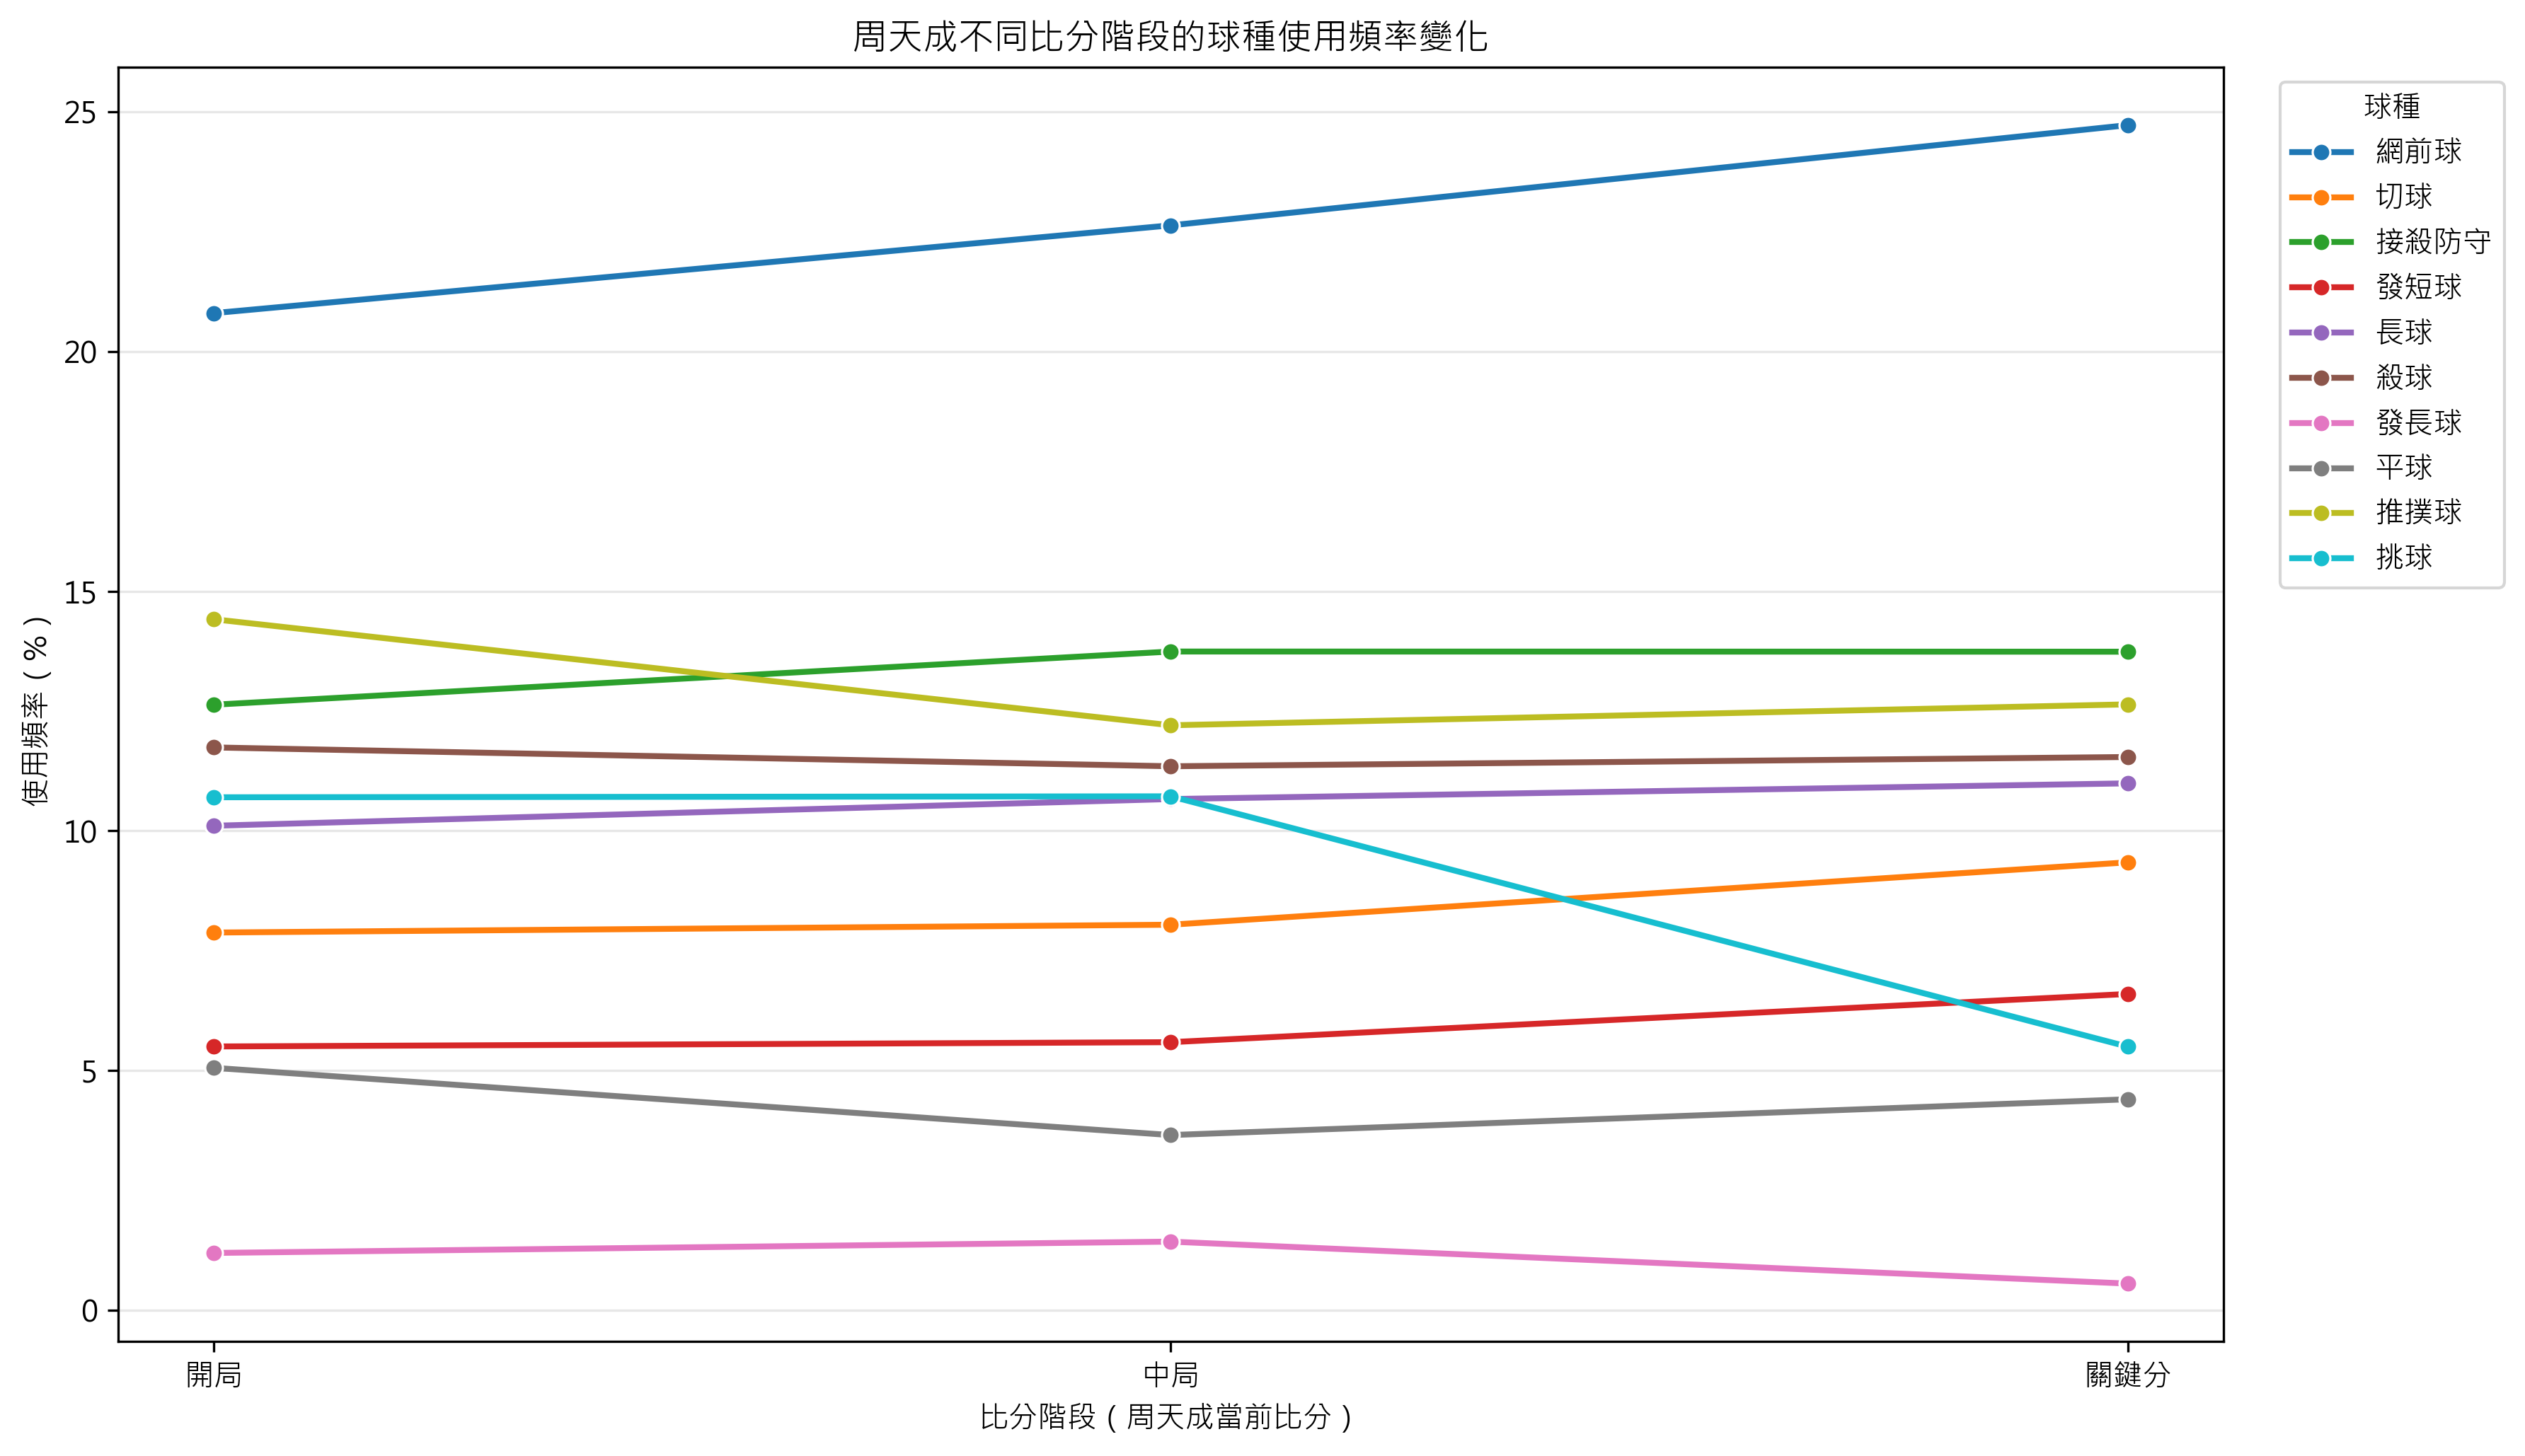

In [ ]:
required_columns = [
    'player', 'type', 'CHOU Tien Chen_score',
    'match_id', 'set', 'rally', 'ball_round'
]

missing_columns = [col for col in required_columns if col not in df.columns]

if len(df) == 0:
    print('資料為空，無法分析。')
    fig = plt.figure()
elif missing_columns:
    print(f'缺少必要欄位：{missing_columns}')
    fig = plt.figure()
else:
    target_player = 'CHOU Tien Chen'
    stage_order = ['開局', '中局', '關鍵分']

    analysis_df = df.loc[
        df['player'].eq(target_player),
        required_columns
    ].copy()

    analysis_df['CHOU Tien Chen_score'] = pd.to_numeric(
        analysis_df['CHOU Tien Chen_score'],
        errors='coerce'
    )

    analysis_df = analysis_df.dropna(
        subset=['type', 'CHOU Tien Chen_score']
    )

    analysis_df['比分階段'] = pd.cut(
        analysis_df['CHOU Tien Chen_score'],
        bins=[-1, 4, 17, float('inf')],
        labels=stage_order,
        right=True
    )

    analysis_df = analysis_df.dropna(subset=['比分階段'])

    if len(analysis_df) == 0:
        print('沒有符合周天成與比分階段條件的有效擊球資料。')
        fig = plt.figure()
    else:
        shot_frequency = (
            analysis_df
            .groupby(['比分階段', 'type'], observed=False)
            .size()
            .rename('使用拍數')
            .reset_index()
        )

        stage_totals = (
            analysis_df
            .groupby('比分階段', observed=False)
            .size()
            .rename('階段總拍數')
            .reset_index()
        )

        shot_frequency = shot_frequency.merge(
            stage_totals,
            on='比分階段',
            how='left'
        )

        shot_frequency['使用頻率_percent'] = (
            shot_frequency['使用拍數']
            / shot_frequency['階段總拍數']
            * 100
        )

        frequency_table = (
            shot_frequency
            .pivot(
                index='type',
                columns='比分階段',
                values='使用頻率_percent'
            )
            .reindex(columns=stage_order, fill_value=0)
            .fillna(0)
        )

        count_table = (
            shot_frequency
            .pivot(
                index='type',
                columns='比分階段',
                values='使用拍數'
            )
            .reindex(columns=stage_order, fill_value=0)
            .fillna(0)
            .astype(int)
        )

        frequency_table['整體變化_關鍵分減開局'] = (
            frequency_table['關鍵分'] - frequency_table['開局']
        )

        frequency_table = frequency_table.sort_values(
            '整體變化_關鍵分減開局',
            ascending=False
        )

        print('周天成各比分階段球種使用拍數：')
        print(count_table.to_string())

        print('\n周天成各比分階段球種使用頻率（占該階段所有擊球百分比）：')
        print(frequency_table.round(2).to_string())

        plot_df = (
            frequency_table
            .drop(columns='整體變化_關鍵分減開局')
            .reset_index()
            .melt(
                id_vars='type',
                value_vars=stage_order,
                var_name='比分階段',
                value_name='使用頻率_percent'
            )
        )

        fig, ax = plt.subplots(figsize=(12, 7))

        sns.lineplot(
            data=plot_df,
            x='比分階段',
            y='使用頻率_percent',
            hue='type',
            marker='o',
            linewidth=2,
            ax=ax
        )

        ax.set_title('周天成不同比分階段的球種使用頻率變化')
        ax.set_xlabel('比分階段（周天成當前比分）')
        ax.set_ylabel('使用頻率（%）')
        ax.legend(
            title='球種',
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )
        ax.grid(axis='y', alpha=0.3)

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 25
**問題**: 當對手靠球場兩側時，周天成較常讓球落點到哪些區域？繪製熱區圖。
> **使用的資料欄位群組**: `game_structure, coordinates, player_location`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm+semantic_guard）


分析拍數：66
對手兩側定義：左側欄位與右側欄位，以及正式定義的左右側出界區域
 落點區域代碼  落點區域  拍數  比例（%）
     14 前中場中左   7  10.61
     20   前場右   6   9.09
     13  前中場左   6   9.09
     18  前場中左   5   7.58
     24   網前右   5   7.58
     17   前場左   4   6.06
     19  前場中右   4   6.06
      9   中場左   3   4.55
     25 右側出界上   3   4.55
     15 前中場中右   3   4.55
     23  網前中右   2   3.03
      1   後場左   2   3.03
     27 右側出界下   2   3.03
     22  網前中左   2   3.03
     16  前中場右   2   3.03
     33 未定義區域   2   3.03
      6 中後場中左   1   1.52
…（輸出已截斷；notebook 僅保留重點）


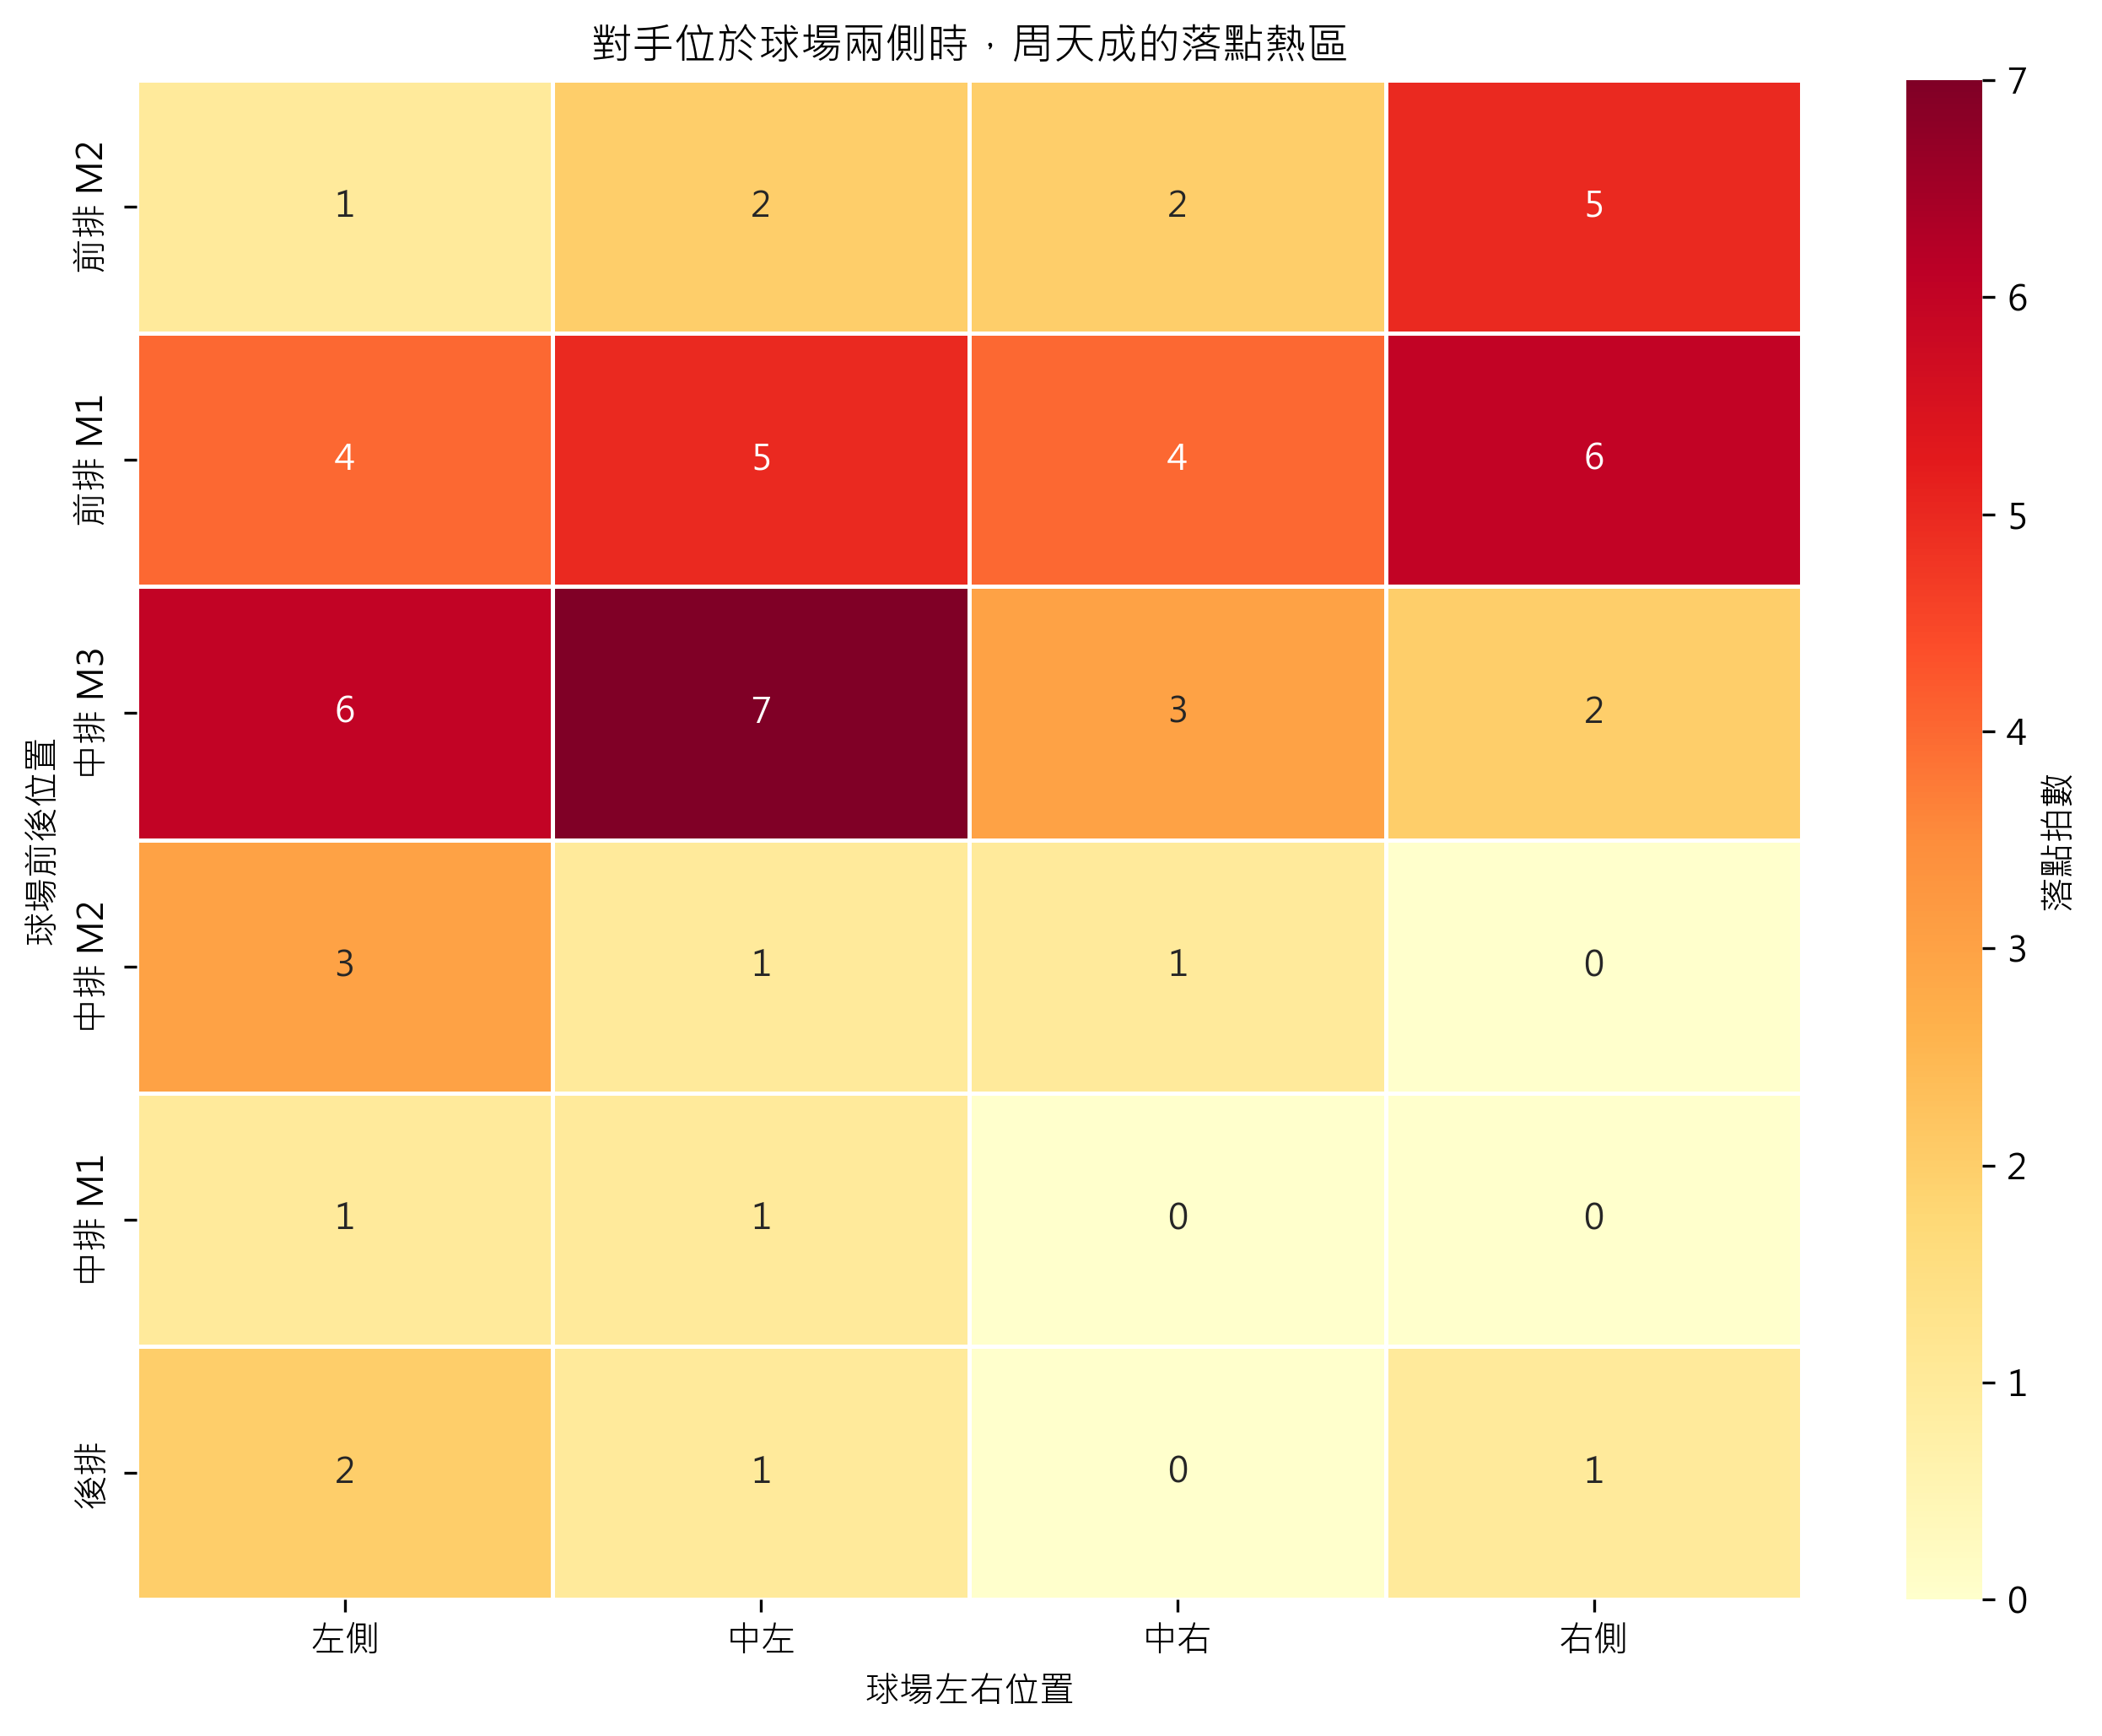

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player',
    'opponent_location_area', 'landing_area'
]

if len(df) == 0:
    print('資料為空，無法分析。')
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
    else:
        target_player = 'CHOU Tien Chen'

        # 依正式 Court Grid Definitions：左側為每列第 1 欄，右側為每列第 4 欄。
        # 同時納入正式定義中的左右側出界區域。
        left_side_zones = {1, 5, 9, 13, 17, 21, 29, 30, 31}
        right_side_zones = {4, 8, 12, 16, 20, 24, 25, 26, 27}
        opponent_side_zones = left_side_zones | right_side_zones

        analysis_df = df[required_cols].copy()
        analysis_df = analysis_df.dropna(
            subset=['player', 'opponent_location_area', 'landing_area']
        )

        side_df = analysis_df[
            (analysis_df['player'] == target_player) &
            (analysis_df['opponent_location_area'].isin(opponent_side_zones))
        ].copy()

        if len(side_df) == 0:
            print('沒有符合「對手位於球場兩側且周天成擊球」的資料。')
        else:
            zone_names = {
                1: '後場左', 2: '後場中左', 3: '後場中右', 4: '後場右',
                5: '中後場左', 6: '中後場中左', 7: '中後場中右', 8: '中後場右',
                9: '中場左', 10: '中場中左', 11: '中場中右', 12: '中場右',
                13: '前中場左', 14: '前中場中左', 15: '前中場中右', 16: '前中場右',
                17: '前場左', 18: '前場中左', 19: '前場中右', 20: '前場右',
                21: '網前左', 22: '網前中左', 23: '網前中右', 24: '網前右',
                25: '右側出界上', 26: '右側出界中', 27: '右側出界下',
                28: '後方出界右', 29: '左側出界上', 30: '左側出界中',
                31: '左側出界下', 32: '後方出界左', 33: '未定義區域'
            }

            landing_counts = (
                side_df['landing_area']
                .astype(int)
                .value_counts()
                .rename_axis('落點區域代碼')
                .reset_index(name='拍數')
            )
            landing_counts['落點區域'] = landing_counts['落點區域代碼'].map(
                lambda x: zone_names.get(x, '未定義區域')
            )
            landing_counts['比例（%）'] = (
                landing_counts['拍數'] / landing_counts['拍數'].sum() * 100
            ).round(2)

            landing_counts = landing_counts[
                ['落點區域代碼', '落點區域', '拍數', '比例（%）']
            ]

            print(f'分析拍數：{len(side_df)}')
            print('對手兩側定義：左側欄位與右側欄位，以及正式定義的左右側出界區域')
            print(landing_counts.to_string(index=False))

            grid_zones = list(range(1, 25))
            grid_counts = (
                side_df['landing_area']
                .astype(int)
                .value_counts()
                .reindex(grid_zones, fill_value=0)
            )

            grid_matrix = pd.DataFrame(
                [
                    [grid_counts[21], grid_counts[22], grid_counts[23], grid_counts[24]],
                    [grid_counts[17], grid_counts[18], grid_counts[19], grid_counts[20]],
                    [grid_counts[13], grid_counts[14], grid_counts[15], grid_counts[16]],
                    [grid_counts[9], grid_counts[10], grid_counts[11], grid_counts[12]],
                    [grid_counts[5], grid_counts[6], grid_counts[7], grid_counts[8]],
                    [grid_counts[1], grid_counts[2], grid_counts[3], grid_counts[4]]
                ],
                index=['前排 M2', '前排 M1', '中排 M3', '中排 M2', '中排 M1', '後排'],
                columns=['左側', '中左', '中右', '右側']
            )

            fig, ax = plt.subplots(figsize=(9, 7))
            sns.heatmap(
                grid_matrix,
                annot=True,
                fmt='d',
                cmap='YlOrRd',
                linewidths=0.8,
                linecolor='white',
                cbar_kws={'label': '落點拍數'},
                ax=ax
            )
            ax.set_title('對手位於球場兩側時，周天成的落點熱區')
            ax.set_xlabel('球場左右位置')
            ax.set_ylabel('球場前後位置')
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 30
**問題**: 周天成在比賽後段（第 2、3 局）移動距離與失誤率的關聯分析。
> **使用的資料欄位群組**: `game_structure, player_movement, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


統計口徑：統計單位為單拍；範圍為第 2、3 局；
移動距離 = sqrt(player_move_x² + player_move_y²)；
失誤 = player 為周天成且 getpoint_player 為對手。

有效擊球拍數：1515
移動距離與失誤指標的 Pearson 相關係數：-0.3759

各局整體統計：
 set  擊球拍數  失誤拍數 平均移動距離   失誤率
   2   847    47 0.3207 5.55%
   3   668    45 0.3252 6.74%

依移動距離分組的失誤率：
 set  距離分組  擊球拍數  失誤拍數 平均移動距離    失誤率
   2 第1四分位   220    47 0.0596 21.36%
   2 第2四分位   200     0 0.2412  0.00%
   2 第3四分位   210     0 0.3832  0.00%
   2 第4四分位   217     0 0.5983  0.00%
   3 第1四分位   159    44 0.0584 27.67%
   3 第2四分位   179     0 0.2444  0.00%
…（輸出已截斷；notebook 僅保留重點）


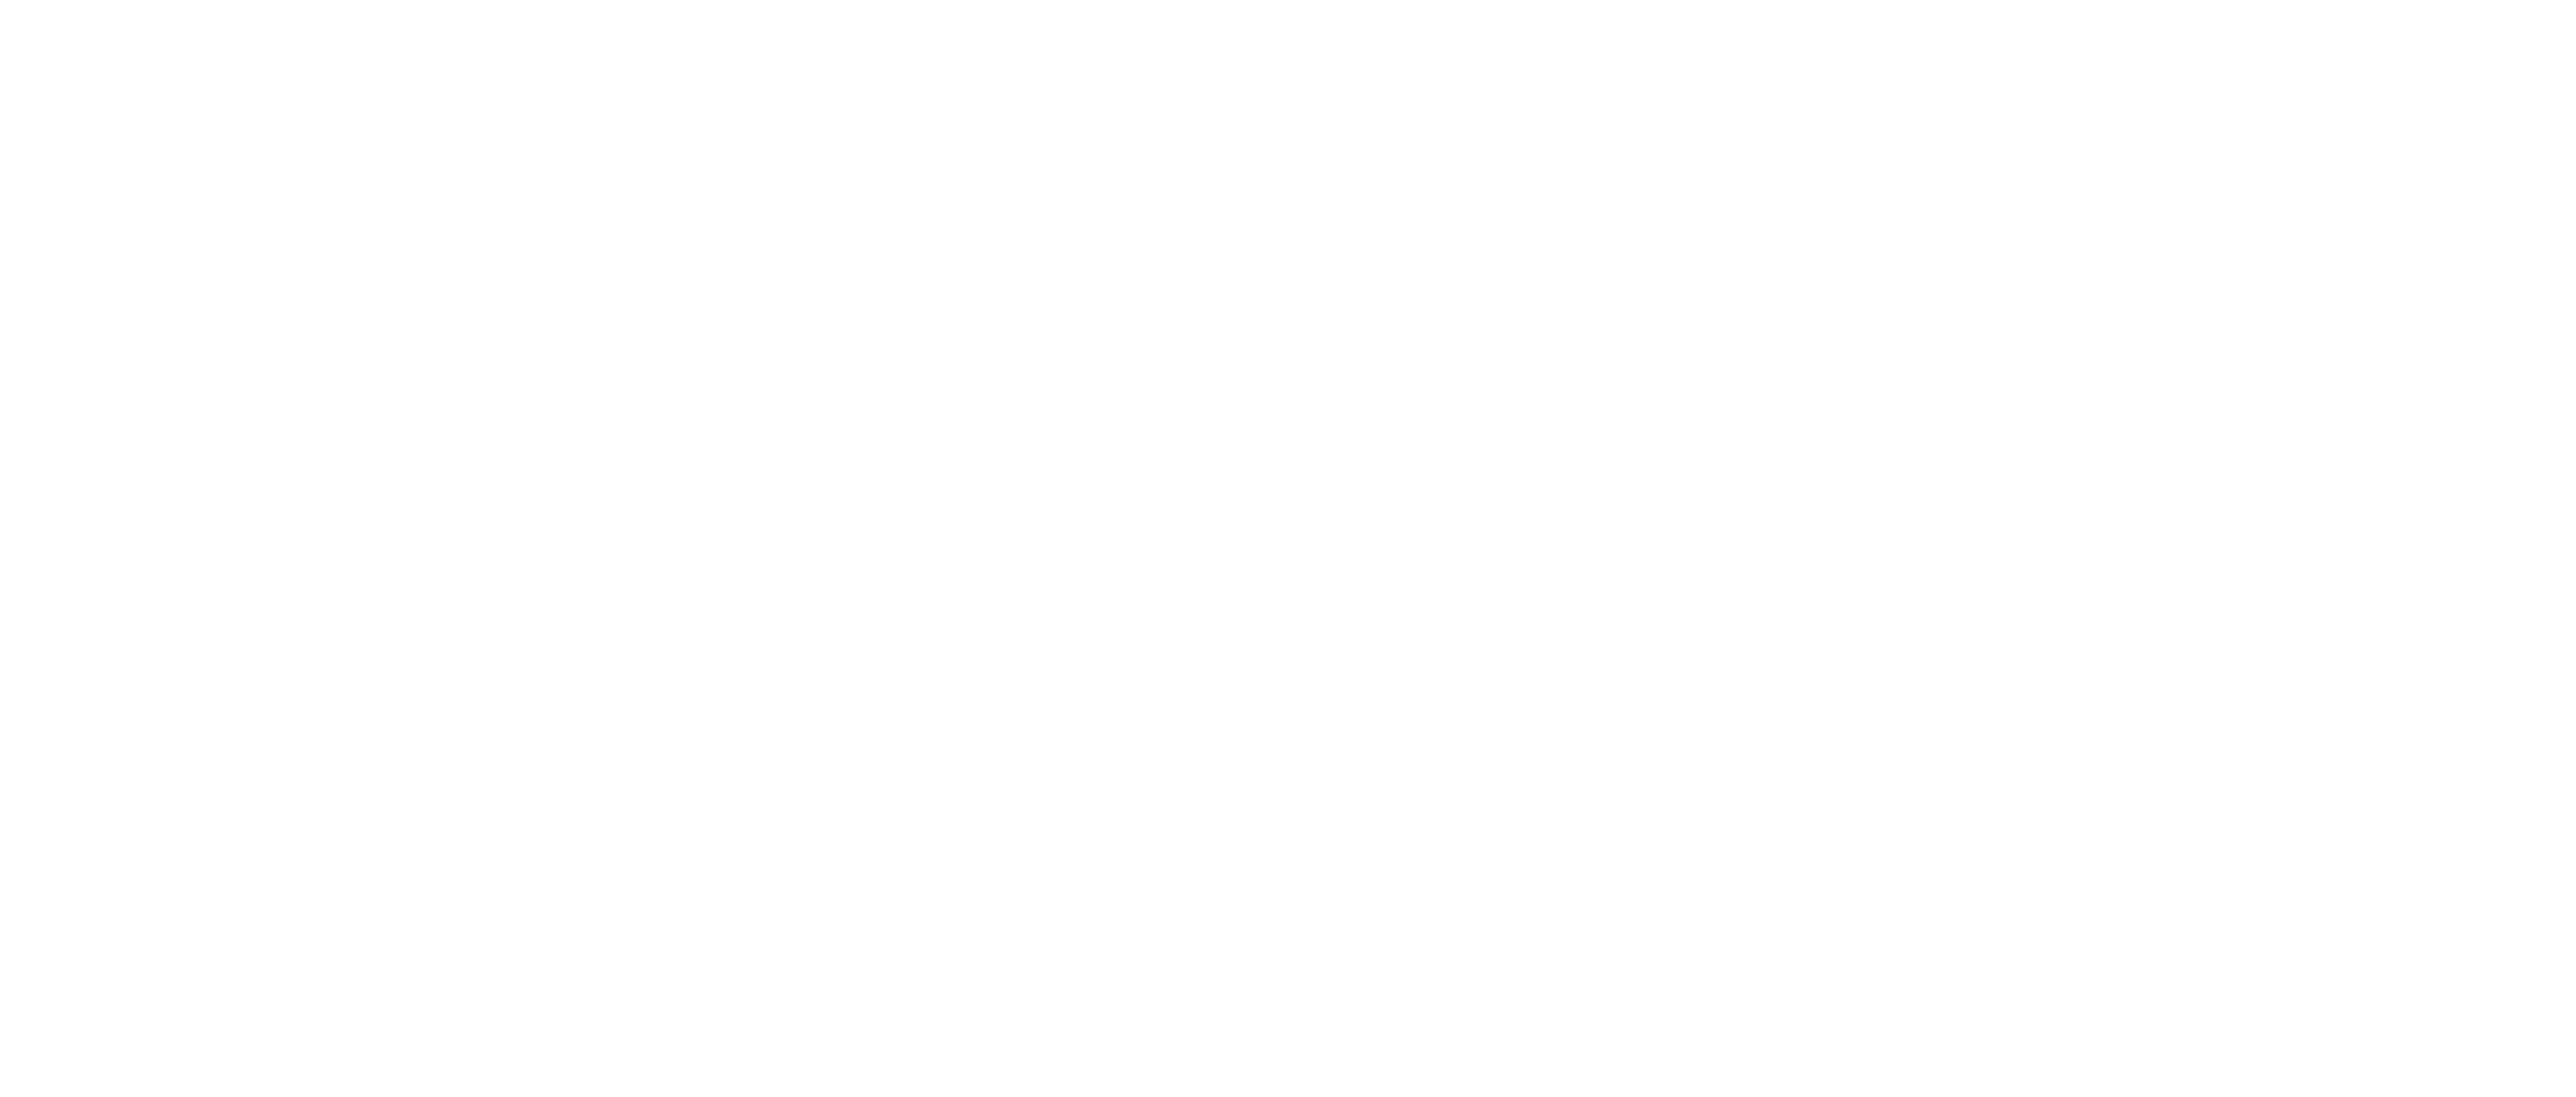

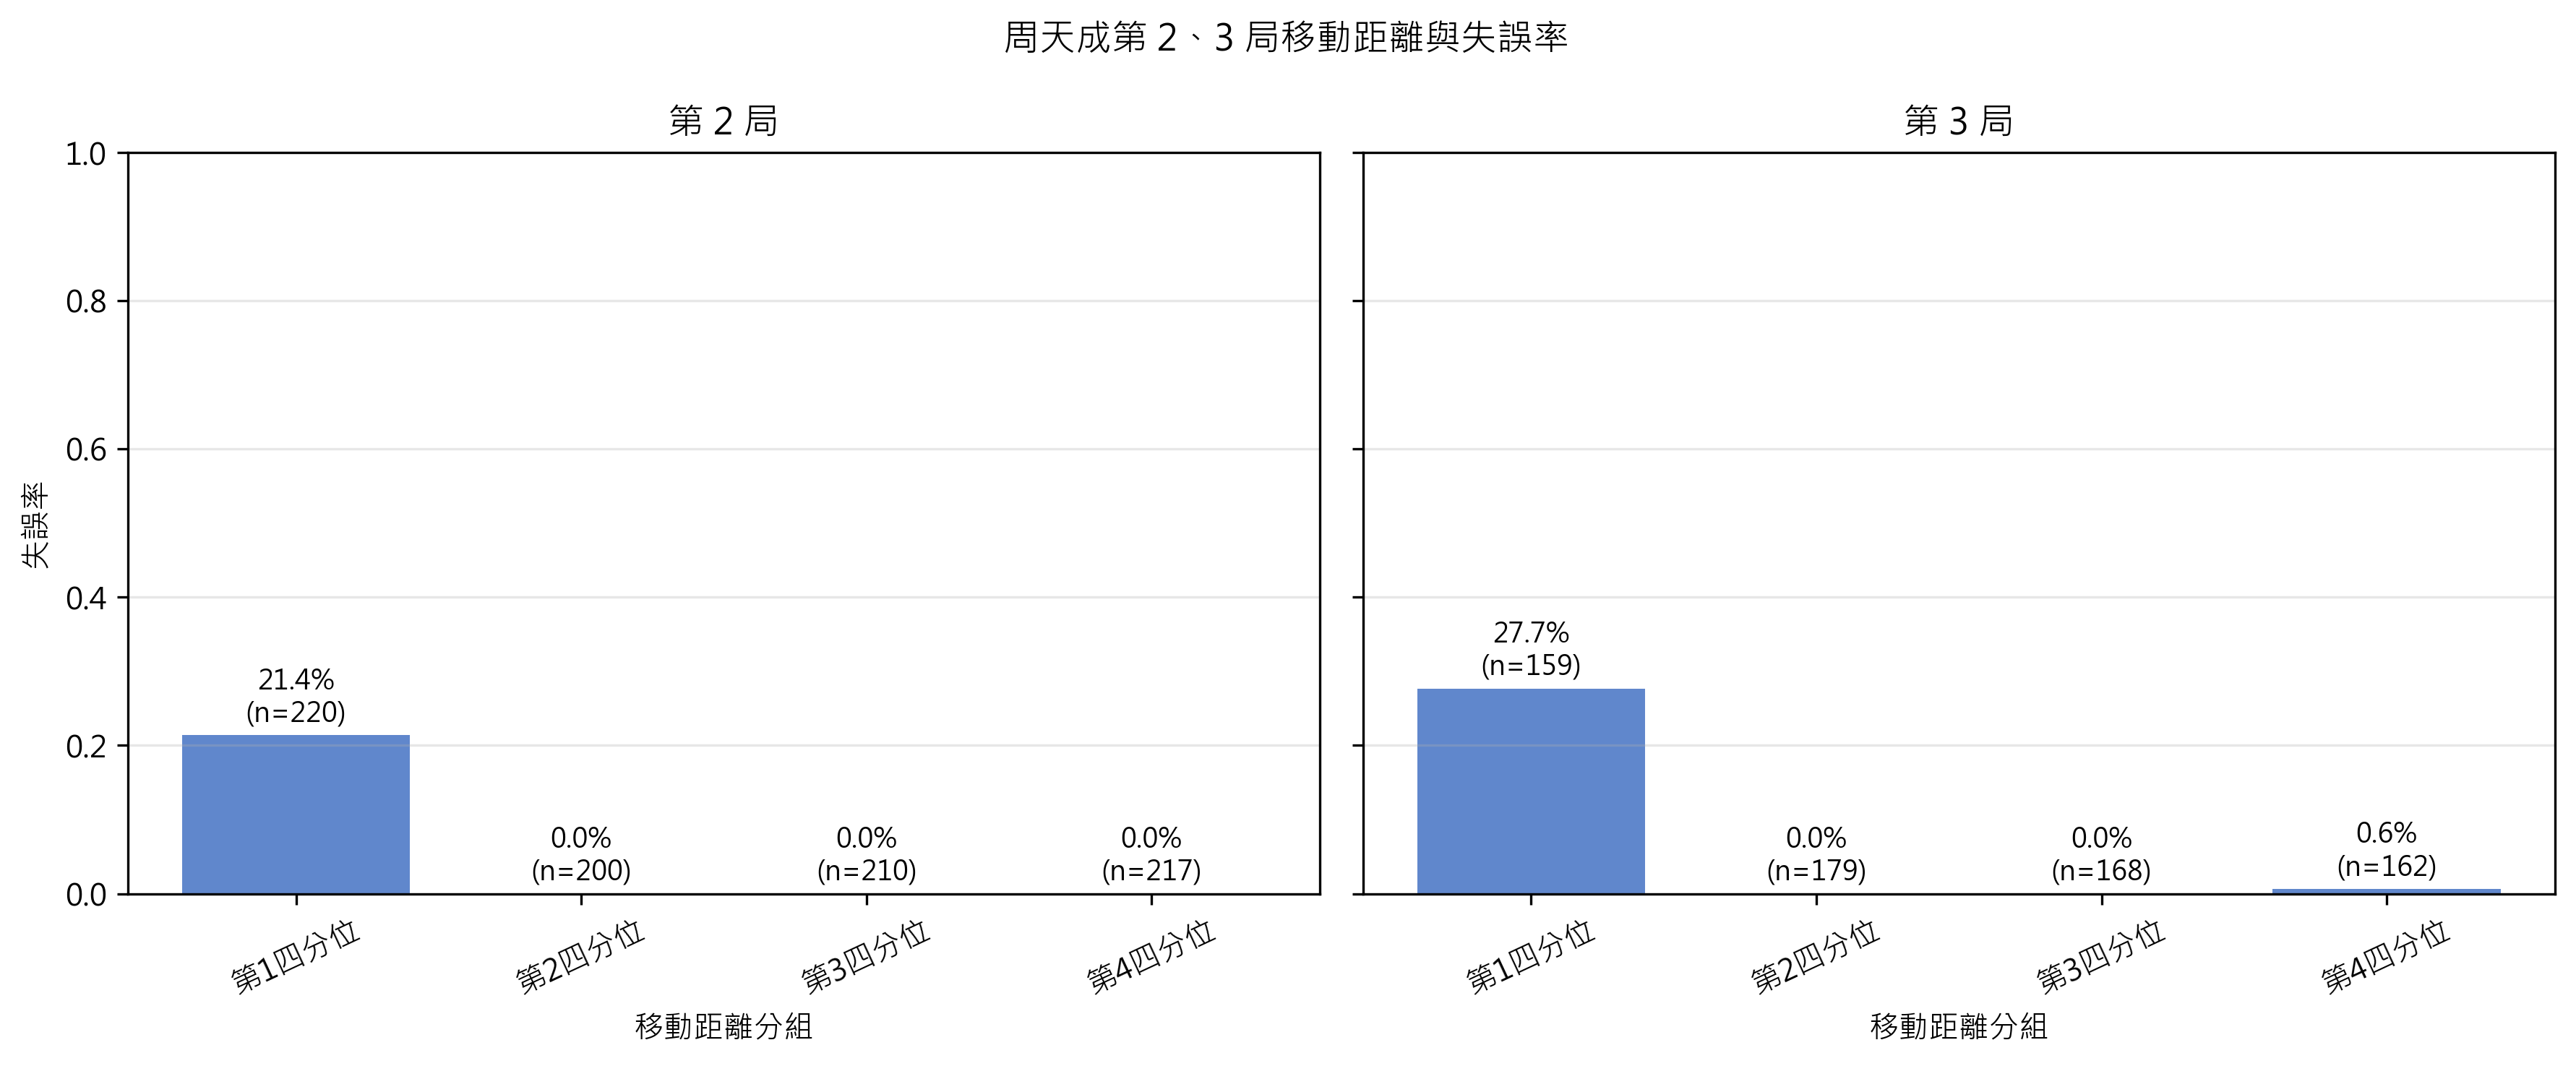

In [ ]:
import numpy as np

required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'getpoint_player', 'player_move_x', 'player_move_y'
]

fig = plt.figure(figsize=(12, 5))

if len(df) == 0:
    print('資料為空，無法進行分析。')
elif not set(required_cols).issubset(df.columns):
    missing_cols = sorted(set(required_cols) - set(df.columns))
    print(f'缺少必要欄位：{missing_cols}')
else:
    target_player = 'CHOU Tien Chen'
    opponent_player = 'Kento MOMOTA'

    analysis_df = df.loc[
        (df['set'].isin([2, 3])) &
        (df['player'] == target_player) &
        (df['opponent'] == opponent_player),
        required_cols
    ].copy()

    movement_cols = ['player_move_x', 'player_move_y']
    analysis_df = analysis_df.dropna(subset=movement_cols)

    if len(analysis_df) == 0:
        print('第 2、3 局沒有周天成具備完整移動距離資料的擊球紀錄。')
    else:
        analysis_df['移動距離'] = np.sqrt(
            analysis_df['player_move_x'] ** 2 +
            analysis_df['player_move_y'] ** 2
        )

        # 失誤定義：周天成是最後擊球者，且該回合由對手得分
        analysis_df['是否失誤'] = (
            (analysis_df['player'] == target_player) &
            (analysis_df['getpoint_player'] == opponent_player)
        ).astype(int)

        analysis_df['距離分組代碼'] = pd.qcut(
            analysis_df['移動距離'],
            q=4,
            labels=False,
            duplicates='drop'
        )

        analysis_df = analysis_df.dropna(subset=['距離分組代碼']).copy()
        analysis_df['距離分組'] = (
            analysis_df['距離分組代碼']
            .astype(int)
            .add(1)
            .map(lambda x: f'第{x}四分位')
        )

        summary = (
            analysis_df
            .groupby(['set', '距離分組代碼', '距離分組'], observed=True)
            .agg(
                擊球拍數=('是否失誤', 'size'),
                失誤拍數=('是否失誤', 'sum'),
                平均移動距離=('移動距離', 'mean'),
                失誤率=('是否失誤', 'mean')
            )
            .reset_index()
            .sort_values(['set', '距離分組代碼'])
        )

        overall_summary = (
            analysis_df
            .groupby('set', observed=True)
            .agg(
                擊球拍數=('是否失誤', 'size'),
                失誤拍數=('是否失誤', 'sum'),
                平均移動距離=('移動距離', 'mean'),
                失誤率=('是否失誤', 'mean')
            )
            .reset_index()
        )

        correlation = analysis_df['移動距離'].corr(
            analysis_df['是否失誤'],
            method='pearson'
        )

        print('統計口徑：統計單位為單拍；範圍為第 2、3 局；')
        print('移動距離 = sqrt(player_move_x² + player_move_y²)；')
        print('失誤 = player 為周天成且 getpoint_player 為對手。')
        print(f'\n有效擊球拍數：{len(analysis_df)}')
        print(f'移動距離與失誤指標的 Pearson 相關係數：{correlation:.4f}')
        print('\n各局整體統計：')
        print(
            overall_summary.to_string(
                index=False,
                formatters={
                    '平均移動距離': '{:.4f}'.format,
                    '失誤率': '{:.2%}'.format
                }
            )
        )
        print('\n依移動距離分組的失誤率：')
        print(
            summary[
                ['set', '距離分組', '擊球拍數', '失誤拍數', '平均移動距離', '失誤率']
            ].to_string(
                index=False,
                formatters={
                    '平均移動距離': '{:.4f}'.format,
                    '失誤率': '{:.2%}'.format
                }
            )
        )

        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        distance_order = (
            analysis_df[['距離分組代碼', '距離分組']]
            .drop_duplicates()
            .sort_values('距離分組代碼')['距離分組']
            .tolist()
        )

        max_error_rate = max(1.0, summary['失誤率'].max() * 1.15)

        for ax, current_set in zip(axes, [2, 3]):
            plot_data = summary[summary['set'] == current_set].copy()
            plot_data = plot_data.set_index('距離分組').reindex(distance_order).reset_index()
            plot_data = plot_data.dropna(subset=['失誤率'])

            if len(plot_data) > 0:
                bars = ax.bar(
                    plot_data['距離分組'],
                    plot_data['失誤率'],
                    color='#4472C4',
                    alpha=0.85
                )
                for bar, rate, count in zip(
                    bars,
                    plot_data['失誤率'],
                    plot_data['擊球拍數']
                ):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{rate:.1%}\n(n={int(count)})',
                        ha='center',
                        va='bottom',
                        fontsize=9
                    )
            else:
                ax.text(
                    0.5, 0.5, '無有效資料',
                    ha='center', va='center',
                    transform=ax.transAxes
                )

            ax.set_title(f'第 {current_set} 局')
            ax.set_xlabel('移動距離分組')
            ax.set_ylabel('失誤率' if current_set == 2 else '')
            ax.set_ylim(0, max_error_rate)
            ax.tick_params(axis='x', rotation=25)
            ax.grid(axis='y', alpha=0.3)

        fig.suptitle('周天成第 2、3 局移動距離與失誤率')
        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 31
**問題**: 分析周天成使用殺球，對手都用什麼球種反擊，繪製圓餅圖
> **使用的資料欄位群組**: `game_structure, shot_type`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


CHOU Tien Chen殺球後的有效對手回擊事件數：218
對手回擊球種  次數       百分比
  接殺防守 174 79.816514
   網前球  38 17.431193
    平球   3  1.376147
   推撲球   1  0.458716
    挑球   1  0.458716
    切球   1  0.458716


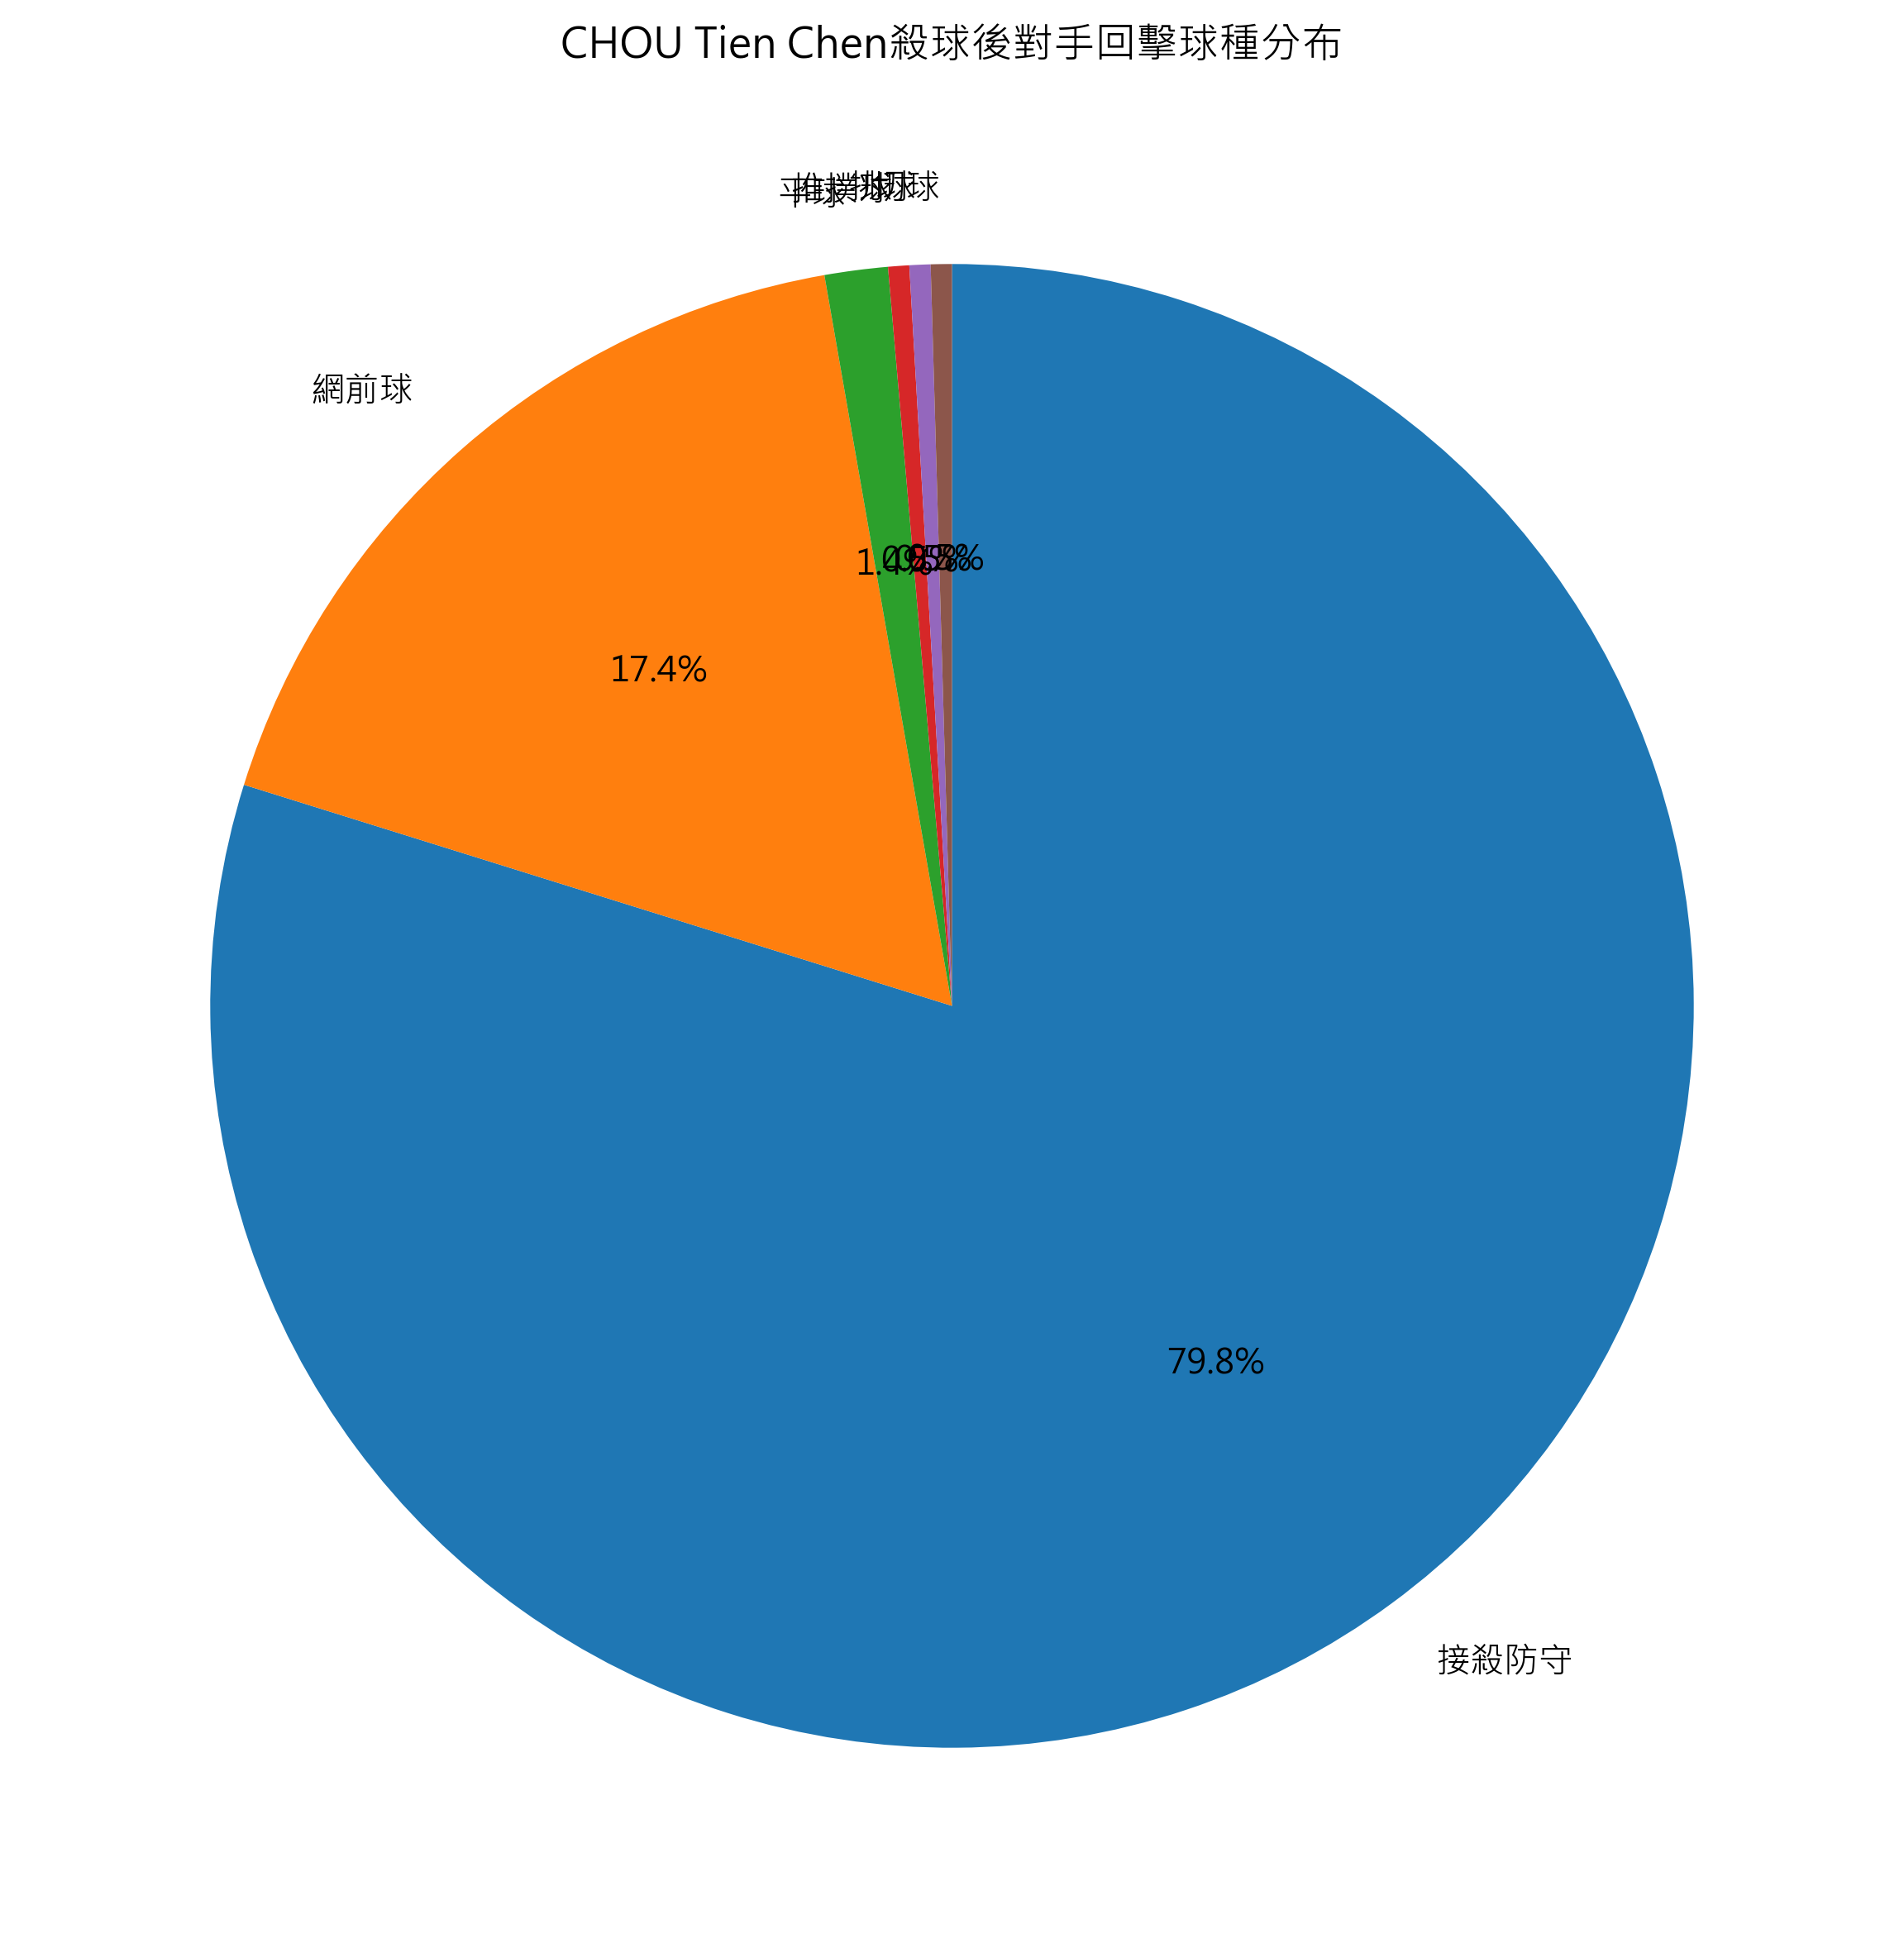

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    target_player = "CHOU Tien Chen"

    required_cols = [
        "match_id", "set", "rally", "ball_round",
        "player", "opponent", "type"
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        data = (
            df[required_cols]
            .sort_values(["match_id", "set", "rally", "ball_round"])
            .reset_index(drop=True)
            .copy()
        )

        rally_group = data.groupby(
            ["match_id", "set", "rally"],
            sort=False
        )

        data["next_player"] = rally_group["player"].shift(-1)
        data["next_type"] = rally_group["type"].shift(-1)

        target_events = data[
            (data["player"] == target_player) &
            (data["type"] == "殺球") &
            (data["next_player"] == data["opponent"])
        ].copy()

        target_events = target_events.dropna(subset=["next_type"])

        response_counts = (
            target_events["next_type"]
            .value_counts()
            .rename_axis("對手回擊球種")
            .reset_index(name="次數")
        )

        total_responses = response_counts["次數"].sum()

        if total_responses > 0:
            response_counts["百分比"] = (
                response_counts["次數"] / total_responses * 100
            )

        print(f"{target_player}殺球後的有效對手回擊事件數：{len(target_events)}")
        print(response_counts.to_string(index=False))

        fig, ax = plt.subplots(figsize=(8, 8))

        if total_responses > 0:
            ax.pie(
                response_counts["次數"],
                labels=response_counts["對手回擊球種"],
                autopct="%1.1f%%",
                startangle=90,
                counterclock=False
            )
            ax.set_title(f"{target_player}殺球後對手回擊球種分布")
        else:
            ax.text(
                0.5, 0.5,
                "沒有符合條件的有效對手回擊事件",
                ha="center",
                va="center",
                fontsize=14
            )
            ax.set_title(f"{target_player}殺球後對手回擊球種分布")

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 34
**問題**: 分析周天成前一拍打什麼球種最容易造成對手未過網？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


統計口徑：以周天成擊球後，同一回合的下一拍對手擊球為事件；
分子為對手下一拍 lose_reason='未過網' 且該回合得分者為周天成，分母為該球種後存在有效對手下一拍的次數。

周天成前一拍球種造成對手未過網的統計：
type  前一拍次數  對手未過網次數 未過網比例
  殺球    218        5 2.29%
  平球     96        1 1.04%
 推撲球    305        3 0.98%
  長球    262        1 0.38%
 網前球    538        2 0.37%
接殺防守    309        1 0.32%
  挑球    253        0 0.00%
  切球    202        0 0.00%
 發短球    147        0 0.00%
 發長球     34        0 0.00%


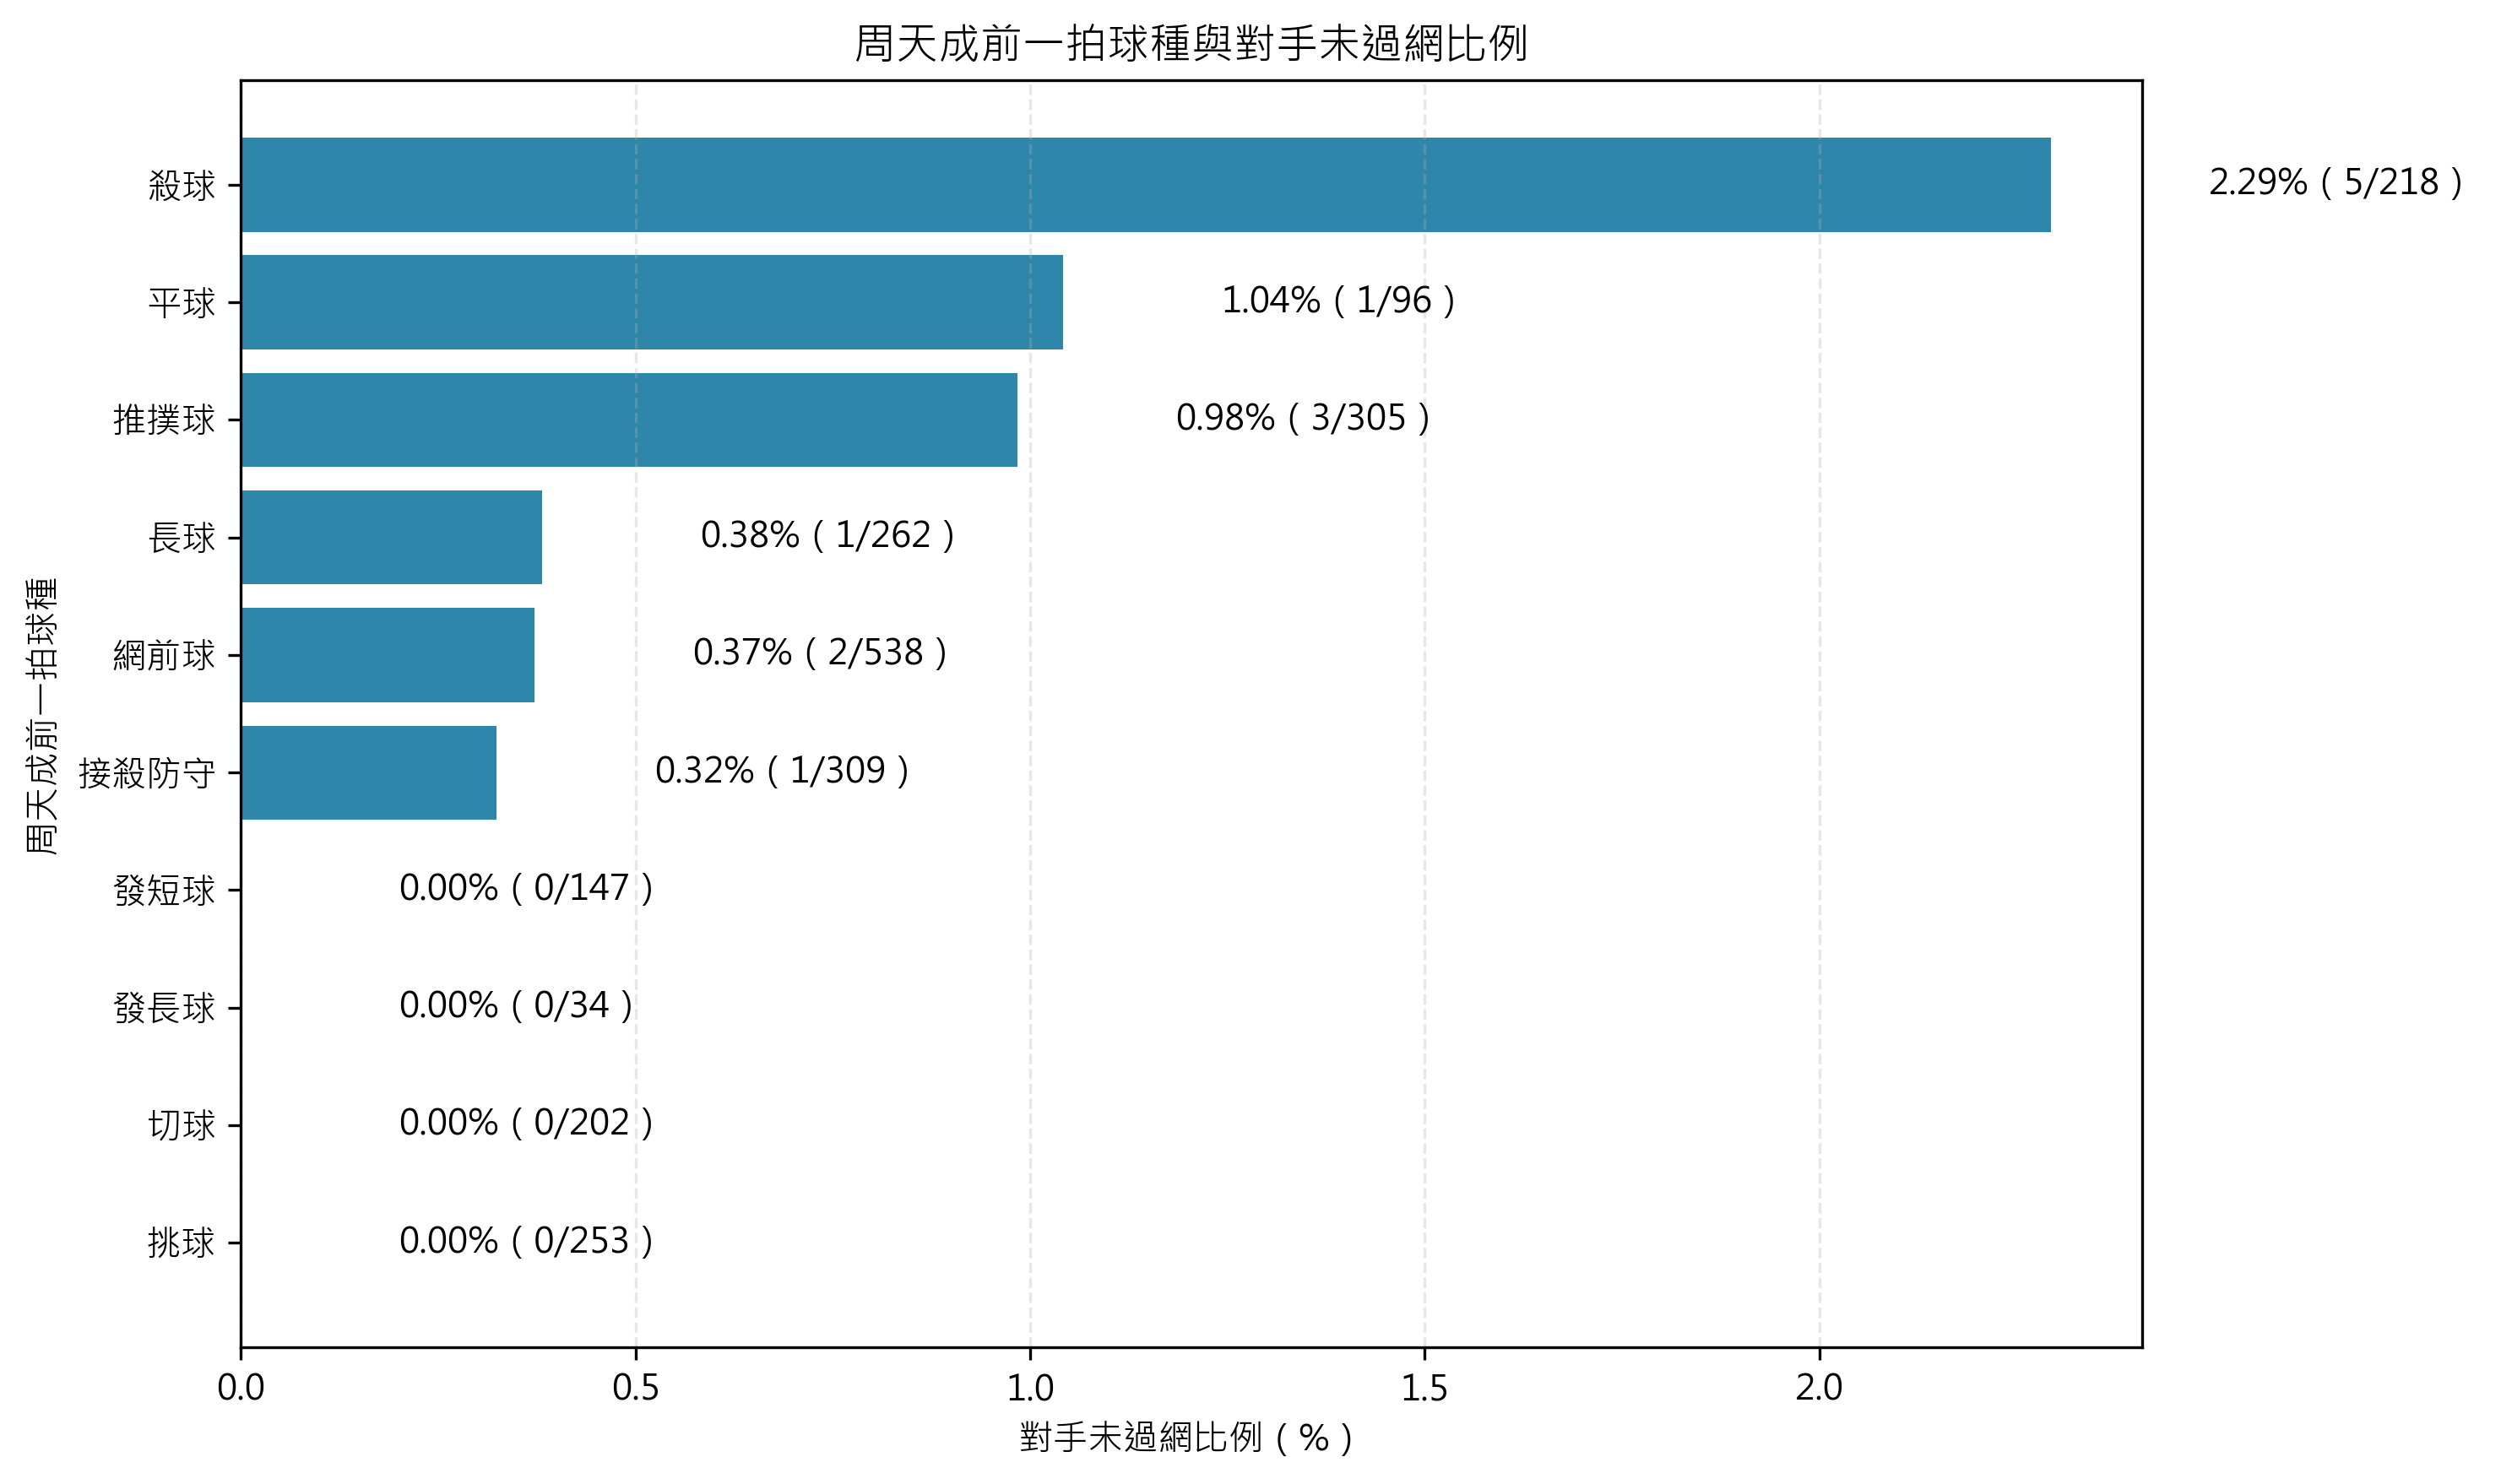

In [ ]:
import pandas as pd

if len(df) == 0:
    print("資料為空，無法分析。")
    fig = plt.figure(figsize=(8, 5))
else:
    target_player = "CHOU Tien Chen"
    opponent_player = "Kento MOMOTA"
    group_cols = ["match_id", "set", "rally"]

    data = df.sort_values(group_cols + ["ball_round"]).copy()

    grouped = data.groupby(group_cols, sort=False)
    data["next_player"] = grouped["player"].shift(-1)
    data["next_type"] = grouped["type"].shift(-1)
    data["next_lose_reason"] = grouped["lose_reason"].shift(-1)
    data["next_getpoint_player"] = grouped["getpoint_player"].shift(-1)
    data["next_match_id"] = grouped["match_id"].shift(-1)
    data["next_set"] = grouped["set"].shift(-1)
    data["next_rally"] = grouped["rally"].shift(-1)

    same_rally_next = (
        data["match_id"].eq(data["next_match_id"])
        & data["set"].eq(data["next_set"])
        & data["rally"].eq(data["next_rally"])
    )

    valid_next_shot = (
        same_rally_next
        & data["player"].eq(target_player)
        & data["next_player"].eq(opponent_player)
        & data["type"].notna()
    )

    opportunities = data.loc[valid_next_shot].copy()
    opportunities["opponent_unforced_error"] = (
        opportunities["next_lose_reason"].eq("未過網")
        & opportunities["next_getpoint_player"].eq(target_player)
    )

    result = (
        opportunities.groupby("type", as_index=False)
        .agg(
            前一拍次數=("type", "size"),
            對手未過網次數=("opponent_unforced_error", "sum")
        )
    )

    result["未過網比例"] = (
        result["對手未過網次數"] / result["前一拍次數"] * 100
    )

    result = result.sort_values(
        ["未過網比例", "對手未過網次數", "前一拍次數"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    print("統計口徑：以周天成擊球後，同一回合的下一拍對手擊球為事件；")
    print("分子為對手下一拍 lose_reason='未過網' 且該回合得分者為周天成，分母為該球種後存在有效對手下一拍的次數。")
    print("\n周天成前一拍球種造成對手未過網的統計：")
    print(result.to_string(index=False, formatters={"未過網比例": "{:.2f}%".format}))

    if len(result) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        plot_data = result.sort_values("未過網比例", ascending=True)

        bars = ax.barh(
            plot_data["type"],
            plot_data["未過網比例"],
            color="#2E86AB"
        )

        ax.set_title("周天成前一拍球種與對手未過網比例")
        ax.set_xlabel("對手未過網比例（%）")
        ax.set_ylabel("周天成前一拍球種")
        ax.grid(axis="x", linestyle="--", alpha=0.3)

        for bar, rate, count, total in zip(
            bars,
            plot_data["未過網比例"],
            plot_data["對手未過網次數"],
            plot_data["前一拍次數"]
        ):
            ax.text(
                bar.get_width() + 0.2,
                bar.get_y() + bar.get_height() / 2,
                f"{rate:.2f}%（{int(count)}/{int(total)}）",
                va="center"
            )

        plt.tight_layout()
    else:
        print("沒有符合條件的周天成前一拍與對手未過網事件。")
        fig = plt.figure(figsize=(10, 6))


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 37
**問題**: 分析周天成使用殺球造成失誤，請繪製失誤原因的圓餅圖
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


周天成使用殺球造成失誤的總拍數：20
失誤原因  失誤拍數
  出界    17
  掛網     3


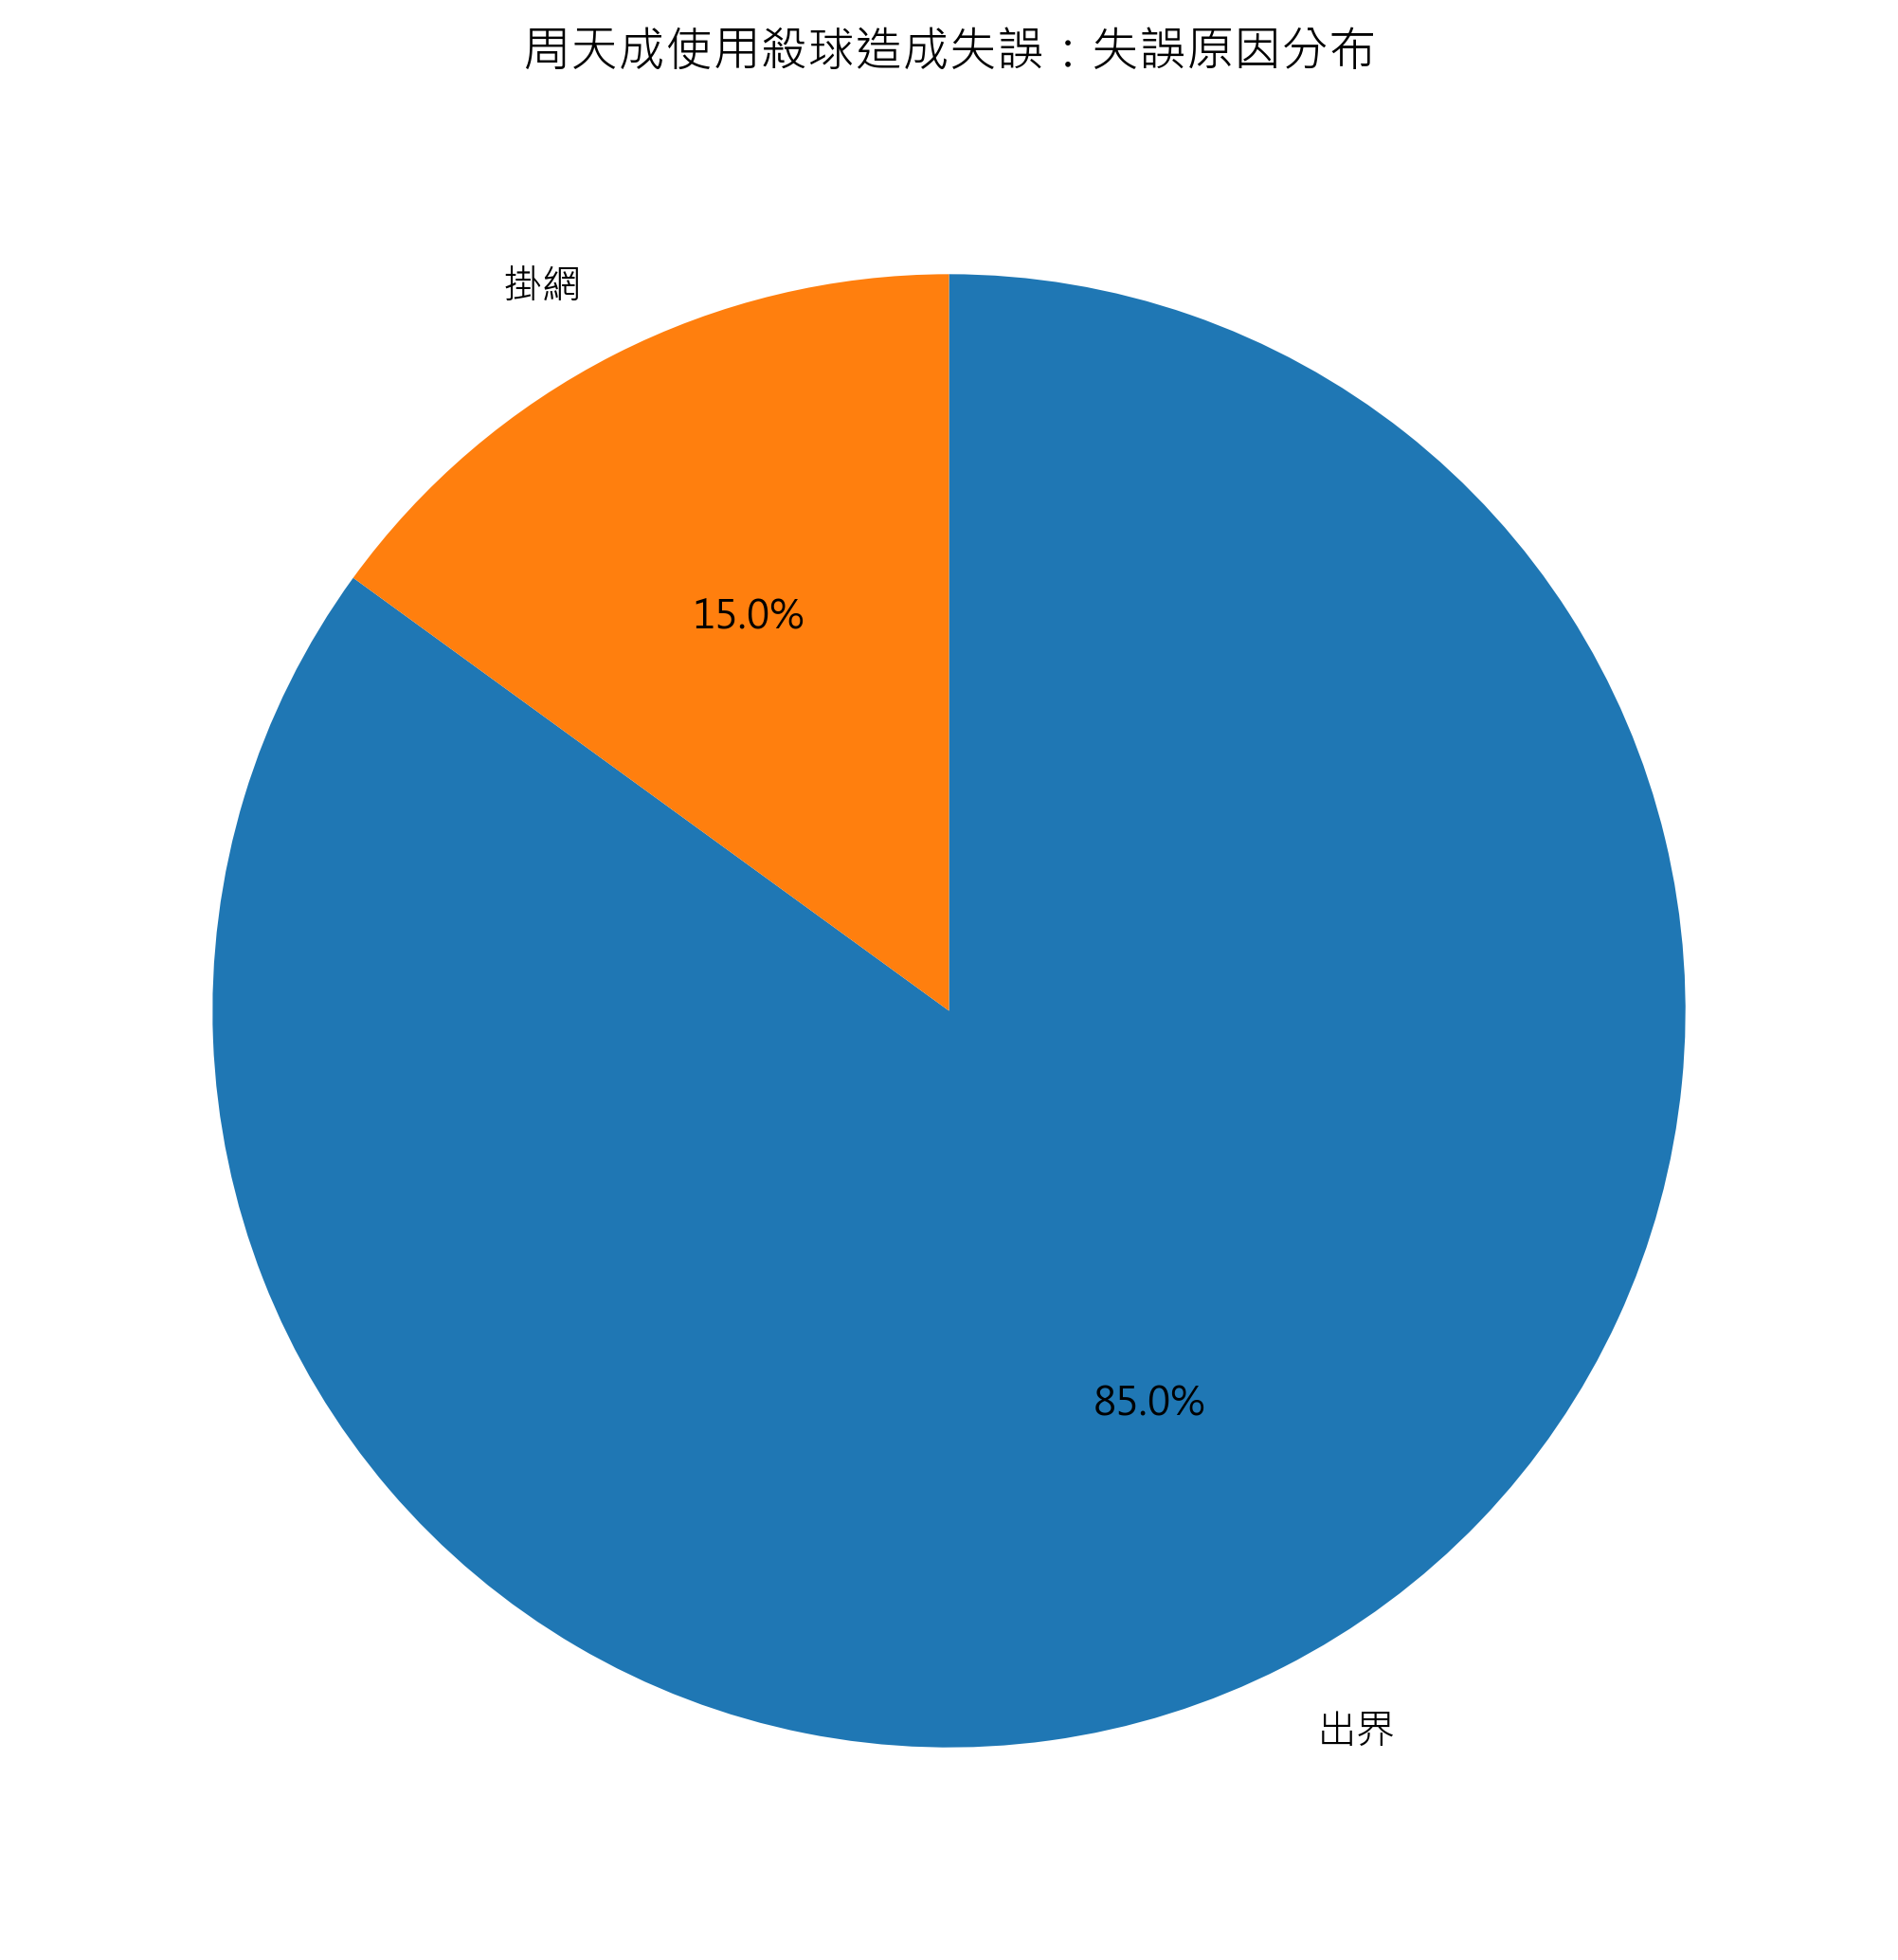

In [ ]:
target_player = 'CHOU Tien Chen'

if len(df) == 0:
    print('資料為空，無法分析。')
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_title('周天成使用殺球造成失誤：失誤原因')
    ax.text(0.5, 0.5, '無資料', ha='center', va='center', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
else:
    required_columns = ['player', 'opponent', 'type', 'getpoint_player', 'lose_reason']
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        print(f'缺少必要欄位：{missing_columns}')
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.set_title('周天成使用殺球造成失誤：失誤原因')
        ax.text(0.5, 0.5, '缺少必要欄位', ha='center', va='center', fontsize=14)
        ax.axis('off')
        plt.tight_layout()
    else:
        error_df = df[
            (df['player'] == target_player) &
            (df['type'] == '殺球') &
            (df['getpoint_player'] == df['opponent']) &
            (df['lose_reason'].notna())
        ].copy()

        reason_counts = (
            error_df['lose_reason']
            .value_counts()
            .rename_axis('失誤原因')
            .reset_index(name='失誤拍數')
        )

        print(f'周天成使用殺球造成失誤的總拍數：{len(error_df)}')
        print(reason_counts.to_string(index=False))

        fig, ax = plt.subplots(figsize=(7, 7))

        if len(reason_counts) > 0:
            ax.pie(
                reason_counts['失誤拍數'],
                labels=reason_counts['失誤原因'],
                autopct='%1.1f%%',
                startangle=90,
                counterclock=False
            )
            ax.set_title('周天成使用殺球造成失誤：失誤原因分布')
        else:
            ax.set_title('周天成使用殺球造成失誤：失誤原因分布')
            ax.text(0.5, 0.5, '無符合條件的失誤資料', ha='center', va='center', fontsize=14)
            ax.axis('off')

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 38
**問題**: 在周天成的所有失分中，有多少百分比是因為對手的殺球導致的？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


周天成總失分回合數：217
對手殺球導致周天成失分回合數：29
對手殺球導致的失分比例：13.36%


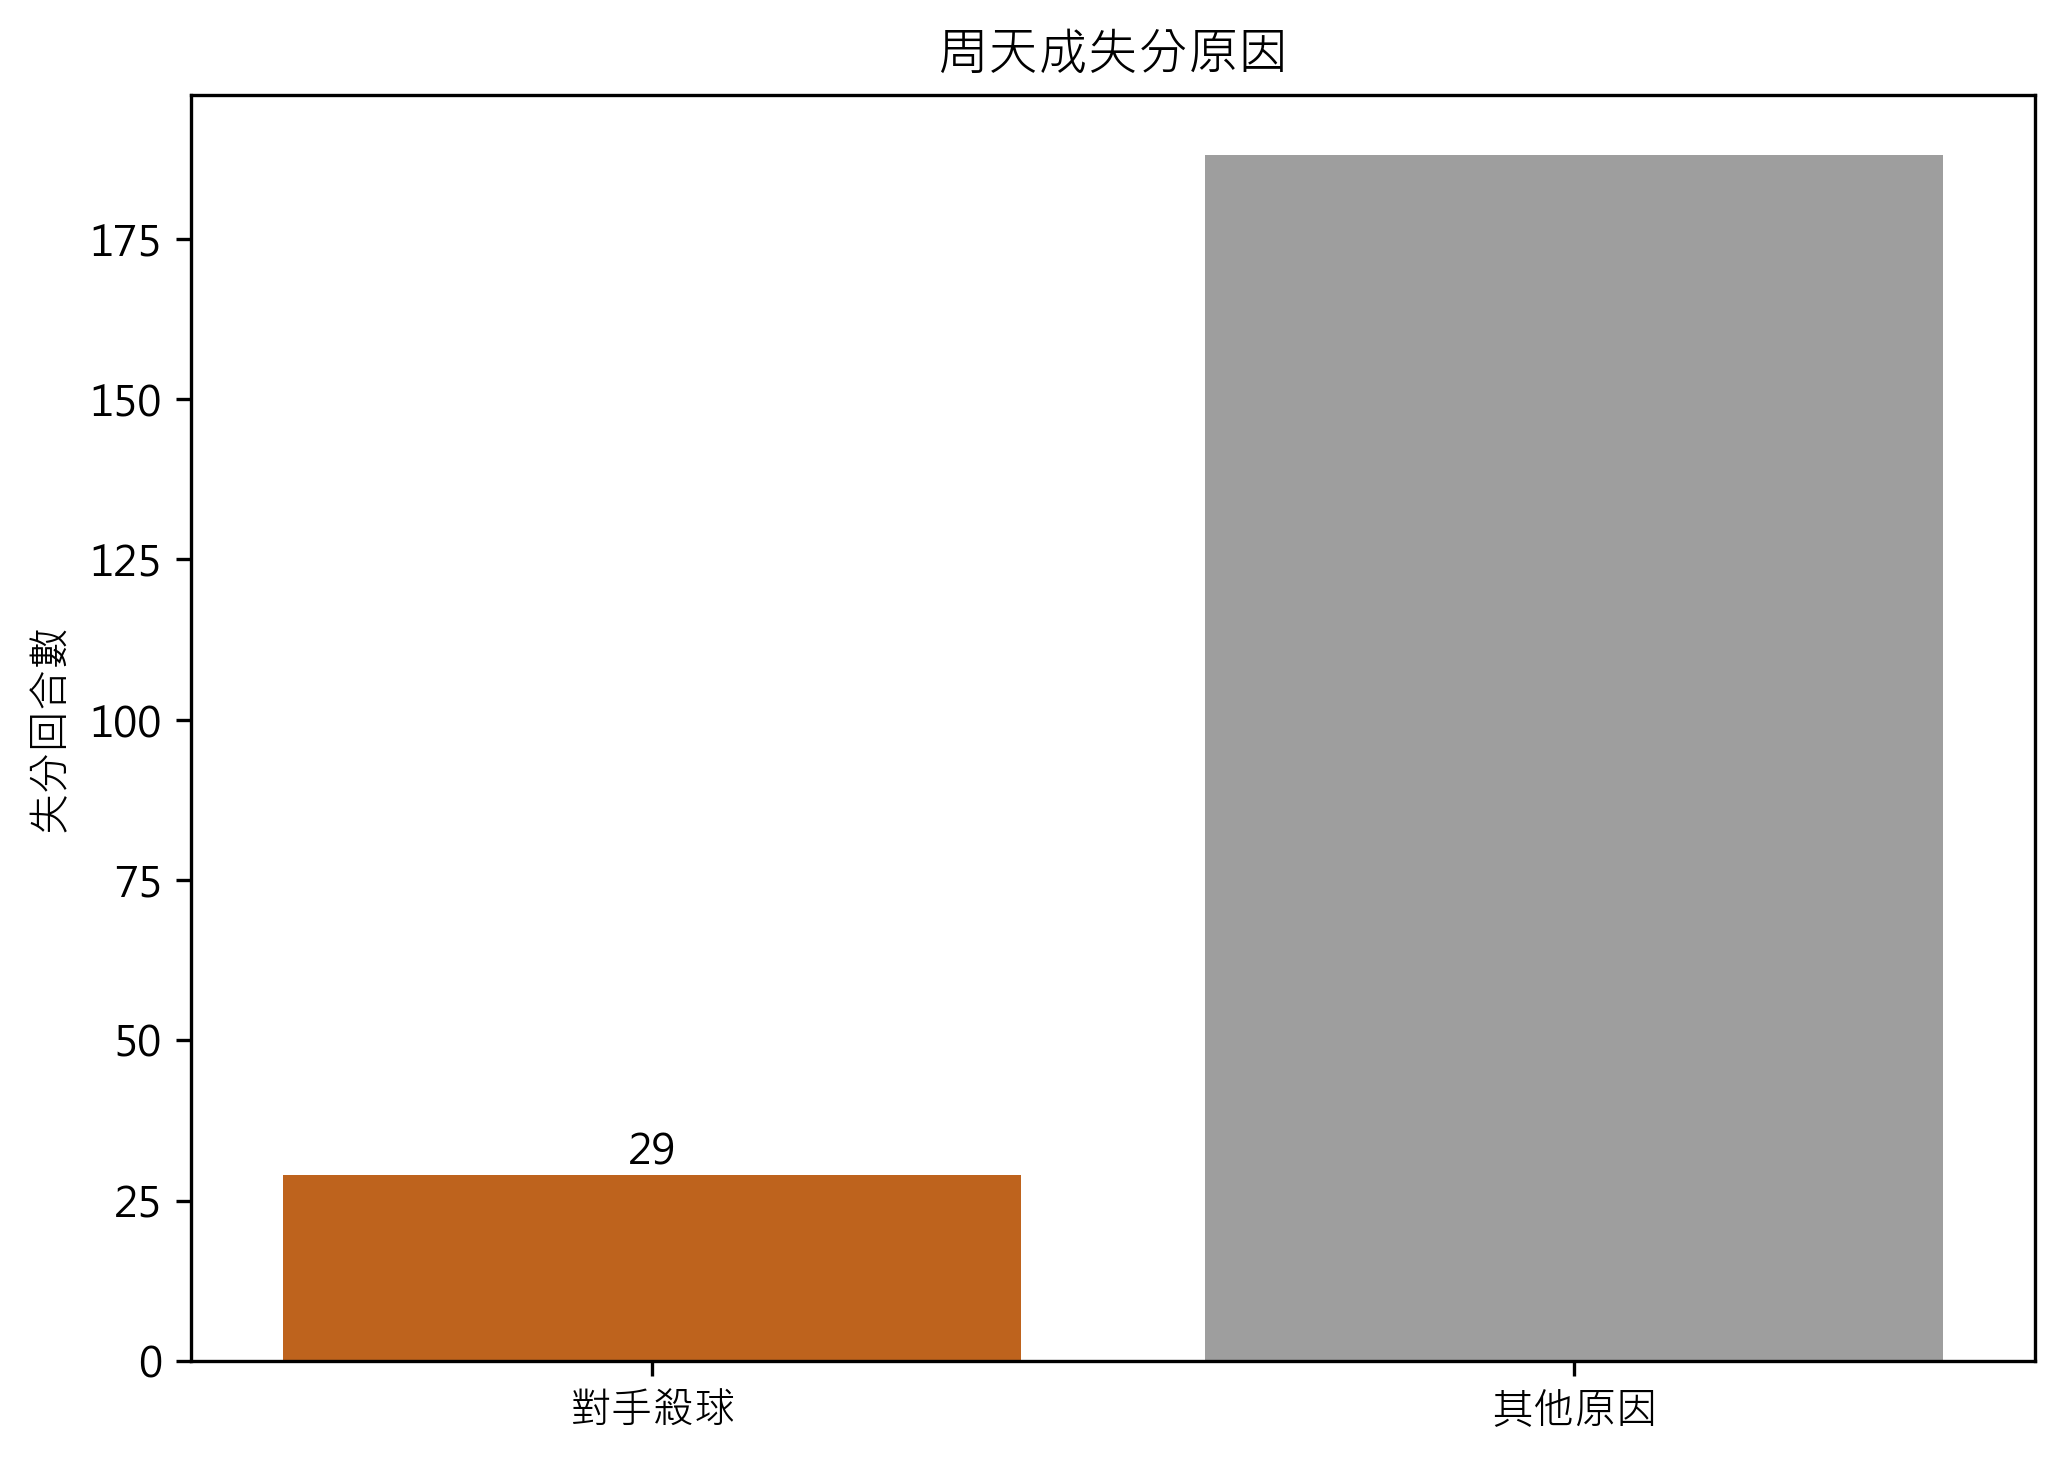

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'type', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法計算。')
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title('周天成失分原因')
    ax.set_axis_off()
else:
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f'缺少必要欄位：{missing_cols}')

    target_player = 'CHOU Tien Chen'
    opponent_player = 'Kento MOMOTA'
    group_cols = ['match_id', 'set', 'rally']

    ordered_df = df.sort_values(
        group_cols + ['ball_round'],
        kind='stable'
    ).copy()

    rally_end_df = (
        ordered_df
        .groupby(group_cols, sort=False, as_index=False)
        .tail(1)
        .copy()
    )

    rally_end_df = rally_end_df[
        rally_end_df['getpoint_player'].notna()
    ].copy()

    target_loss_df = rally_end_df[
        rally_end_df['getpoint_player'].eq(opponent_player)
    ].copy()

    opponent_smash_loss_df = target_loss_df[
        target_loss_df['player'].eq(opponent_player)
        & target_loss_df['type'].eq('殺球')
    ].copy()

    total_target_losses = len(target_loss_df)
    smash_caused_losses = len(opponent_smash_loss_df)

    percentage = (
        smash_caused_losses / total_target_losses * 100
        if total_target_losses > 0 else 0.0
    )

    print(f'周天成總失分回合數：{total_target_losses}')
    print(f'對手殺球導致周天成失分回合數：{smash_caused_losses}')
    print(f'對手殺球導致的失分比例：{percentage:.2f}%')

    chart_df = pd.DataFrame({
        '失分類別': ['對手殺球', '其他原因'],
        '回合數': [
            smash_caused_losses,
            total_target_losses - smash_caused_losses
        ]
    })

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.barplot(
        data=chart_df,
        x='失分類別',
        y='回合數',
        hue='失分類別',
        palette=['#d95f02', '#9e9e9e'],
        legend=False,
        ax=ax
    )
    ax.set_title('周天成失分原因')
    ax.set_xlabel('')
    ax.set_ylabel('失分回合數')
    ax.bar_label(ax.containers[0], fmt='%d')
    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 42
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階中，他的「殺球」使用比例以及得分率，是否有顯著變化？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


周天成不同比分階段的殺球表現：
            總擊球數  殺球數 殺球使用比例  殺球總數  殺球主動得分數  殺球得分率
比分階段                                              
開局（0-4分）     673   79 11.74%    79       20 25.32%
中局（5-17分）   1754  199 11.35%   199       37 18.59%
關鍵分（18分以上）   182   21 11.54%    21        4 19.05%

顯著性檢定（卡方獨立性檢定，顯著水準 α=0.05）：
殺球使用比例跨比分階段的 p-value：0.9631
殺球得分率跨比分階段的 p-value：0.4494
結論：沒有足夠證據顯示殺球使用比例在三個比分階段間有顯著變化。
結論：沒有足夠證據顯示殺球得分率在三個比分階段間有顯著變化。


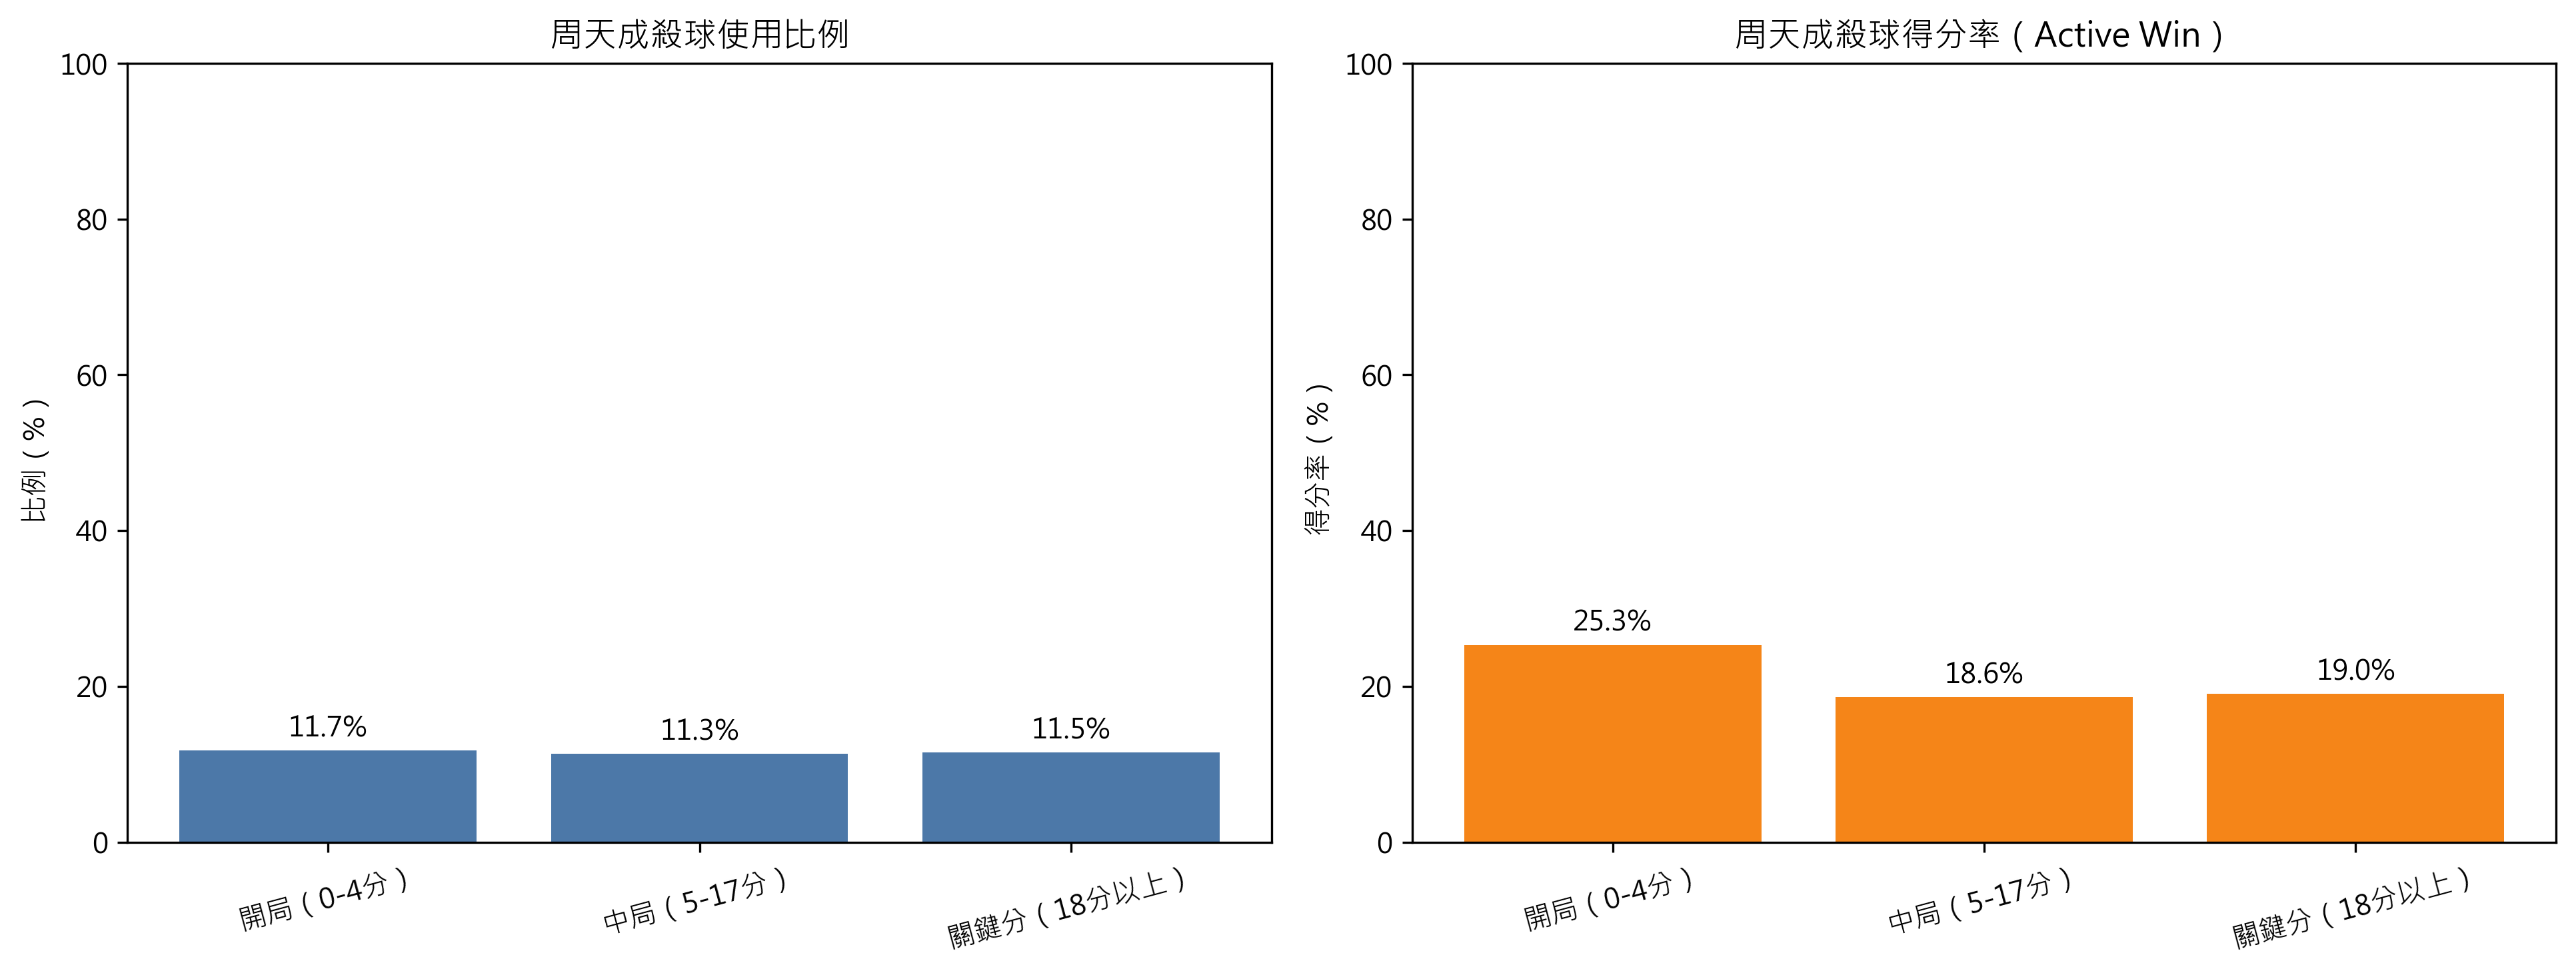

In [ ]:
required_cols = ['player', 'type', 'getpoint_player', 'CHOU Tien Chen_score']
missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print("資料為空，無法分析。")
elif missing_cols:
    print(f"缺少必要欄位：{missing_cols}")
else:
    import numpy as np
    from scipy.stats import chi2_contingency

    player_name = 'CHOU Tien Chen'
    score_col = 'CHOU Tien Chen_score'
    stages = ['開局（0-4分）', '中局（5-17分）', '關鍵分（18分以上）']

    work = df.loc[
        df['player'].eq(player_name),
        ['player', 'type', 'getpoint_player', score_col]
    ].copy()

    work[score_col] = pd.to_numeric(work[score_col], errors='coerce')
    work = work.dropna(subset=[score_col, 'type']).copy()

    work['比分階段'] = pd.cut(
        work[score_col],
        bins=[-np.inf, 4, 17, np.inf],
        labels=stages,
        right=True
    )

    work = work.dropna(subset=['比分階段']).copy()
    work['是否殺球'] = work['type'].eq('殺球')
    work['是否主動得分'] = (
        work['getpoint_player'].notna()
        & work['player'].eq(work['getpoint_player'])
    )

    summary = (
        work.groupby('比分階段', observed=False)
        .agg(
            總擊球數=('是否殺球', 'size'),
            殺球數=('是否殺球', 'sum')
        )
        .reindex(stages, fill_value=0)
    )

    smash_work = work.loc[work['是否殺球']].copy()

    success_summary = (
        smash_work.groupby('比分階段', observed=False)
        .agg(
            殺球總數=('是否主動得分', 'size'),
            殺球主動得分數=('是否主動得分', 'sum')
        )
        .reindex(stages, fill_value=0)
    )

    result = summary.join(success_summary)
    result['殺球使用比例'] = np.where(
        result['總擊球數'] > 0,
        result['殺球數'] / result['總擊球數'],
        np.nan
    )
    result['殺球得分率'] = np.where(
        result['殺球總數'] > 0,
        result['殺球主動得分數'] / result['殺球總數'],
        np.nan
    )

    def chi_square_test(table):
        table = table.loc[(table.sum(axis=1) > 0), (table.sum(axis=0) > 0)]
        if table.shape[0] < 2 or table.shape[1] < 2:
            return np.nan
        try:
            _, p_value, _, _ = chi2_contingency(table)
            return p_value
        except ValueError:
            return np.nan

    usage_table = pd.DataFrame({
        '殺球': result['殺球數'],
        '非殺球': result['總擊球數'] - result['殺球數']
    }, index=stages)

    success_table = pd.DataFrame({
        '殺球主動得分': result['殺球主動得分數'],
        '殺球未主動得分': result['殺球總數'] - result['殺球主動得分數']
    }, index=stages)

    usage_p = chi_square_test(usage_table)
    success_p = chi_square_test(success_table)
    alpha = 0.05

    output = result[
        [
            '總擊球數',
            '殺球數',
            '殺球使用比例',
            '殺球總數',
            '殺球主動得分數',
            '殺球得分率'
        ]
    ].copy()

    print("周天成不同比分階段的殺球表現：")
    print(output.to_string(
        formatters={
            '殺球使用比例': lambda x: f'{x:.2%}' if pd.notna(x) else 'NaN',
            '殺球得分率': lambda x: f'{x:.2%}' if pd.notna(x) else 'NaN'
        }
    ))

    print("\n顯著性檢定（卡方獨立性檢定，顯著水準 α=0.05）：")
    print(f"殺球使用比例跨比分階段的 p-value：{usage_p:.4g}" if pd.notna(usage_p)
          else "殺球使用比例無法進行卡方檢定。")
    print(f"殺球得分率跨比分階段的 p-value：{success_p:.4g}" if pd.notna(success_p)
          else "殺球得分率無法進行卡方檢定。")

    if pd.notna(usage_p):
        print(
            "結論：殺球使用比例在三個比分階段間有顯著變化。"
            if usage_p < alpha
            else "結論：沒有足夠證據顯示殺球使用比例在三個比分階段間有顯著變化。"
        )

    if pd.notna(success_p):
        print(
            "結論：殺球得分率在三個比分階段間有顯著變化。"
            if success_p < alpha
            else "結論：沒有足夠證據顯示殺球得分率在三個比分階段間有顯著變化。"
        )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    usage_values = result['殺球使用比例'].fillna(0) * 100
    success_values = result['殺球得分率'].fillna(0) * 100

    bars1 = axes[0].bar(stages, usage_values, color='#4C78A8')
    axes[0].set_title('周天成殺球使用比例')
    axes[0].set_ylabel('比例（%）')
    axes[0].set_ylim(0, max(100, usage_values.max() * 1.2 if len(usage_values) else 100))
    axes[0].tick_params(axis='x', rotation=15)

    bars2 = axes[1].bar(stages, success_values, color='#F58518')
    axes[1].set_title('周天成殺球得分率（Active Win）')
    axes[1].set_ylabel('得分率（%）')
    axes[1].set_ylim(0, max(100, success_values.max() * 1.2 if len(success_values) else 100))
    axes[1].tick_params(axis='x', rotation=15)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[0 if bars is bars1 else 1].text(
                bar.get_x() + bar.get_width() / 2,
                height + 1,
                f'{height:.1f}%',
                ha='center',
                va='bottom'
            )

    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 45
**問題**: 統整周天成每個場次中各局的表現(例如，球種變化、殺球頻與失誤率、失誤原因等等)
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason, stroke_details`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


周天成各場次各局整體表現：
 match_id  set  回合數  已判定回合數  得分回合數  失分回合數   得分率  擊球數  球種數  殺球數  殺球頻率  失誤數  失誤率
      1.0    1   35      35     14     21 40.00  261   10   32 12.26   18 6.90
      1.0    2   33      33     18     15 54.55  225   10   21  9.33    8 3.56
      1.0    3   39      39     18     21 46.15  293   10   28  9.56   16 5.46
      3.0    1   33      33     15     18 45.45  206    9   24 11.65   12 5.83
      3.0    2   34      34     16     18 47.06  199    9   26 13.07   14 7.04
      5.0    1   29      29      9     20 31.03  183   10   19 10.38   14 7.65
      5.0    2   29      29     18     11 62.07  153    9   13  8.50    9 5.88
      5.0    3   29      29     13     16 44.83  202    9   21 10.40   14 6.93
      6.0    1   36      36     16     20 44.44  209   10   26 12.44   13 6.22
      6.0    2   29      29     18     11 62.07  132    9   15 11.36    7 5.30
      6.0    3   30      30     12     18 40.00  173    9   19 10.98   12 6.94
      7.0    1   32      32     15    

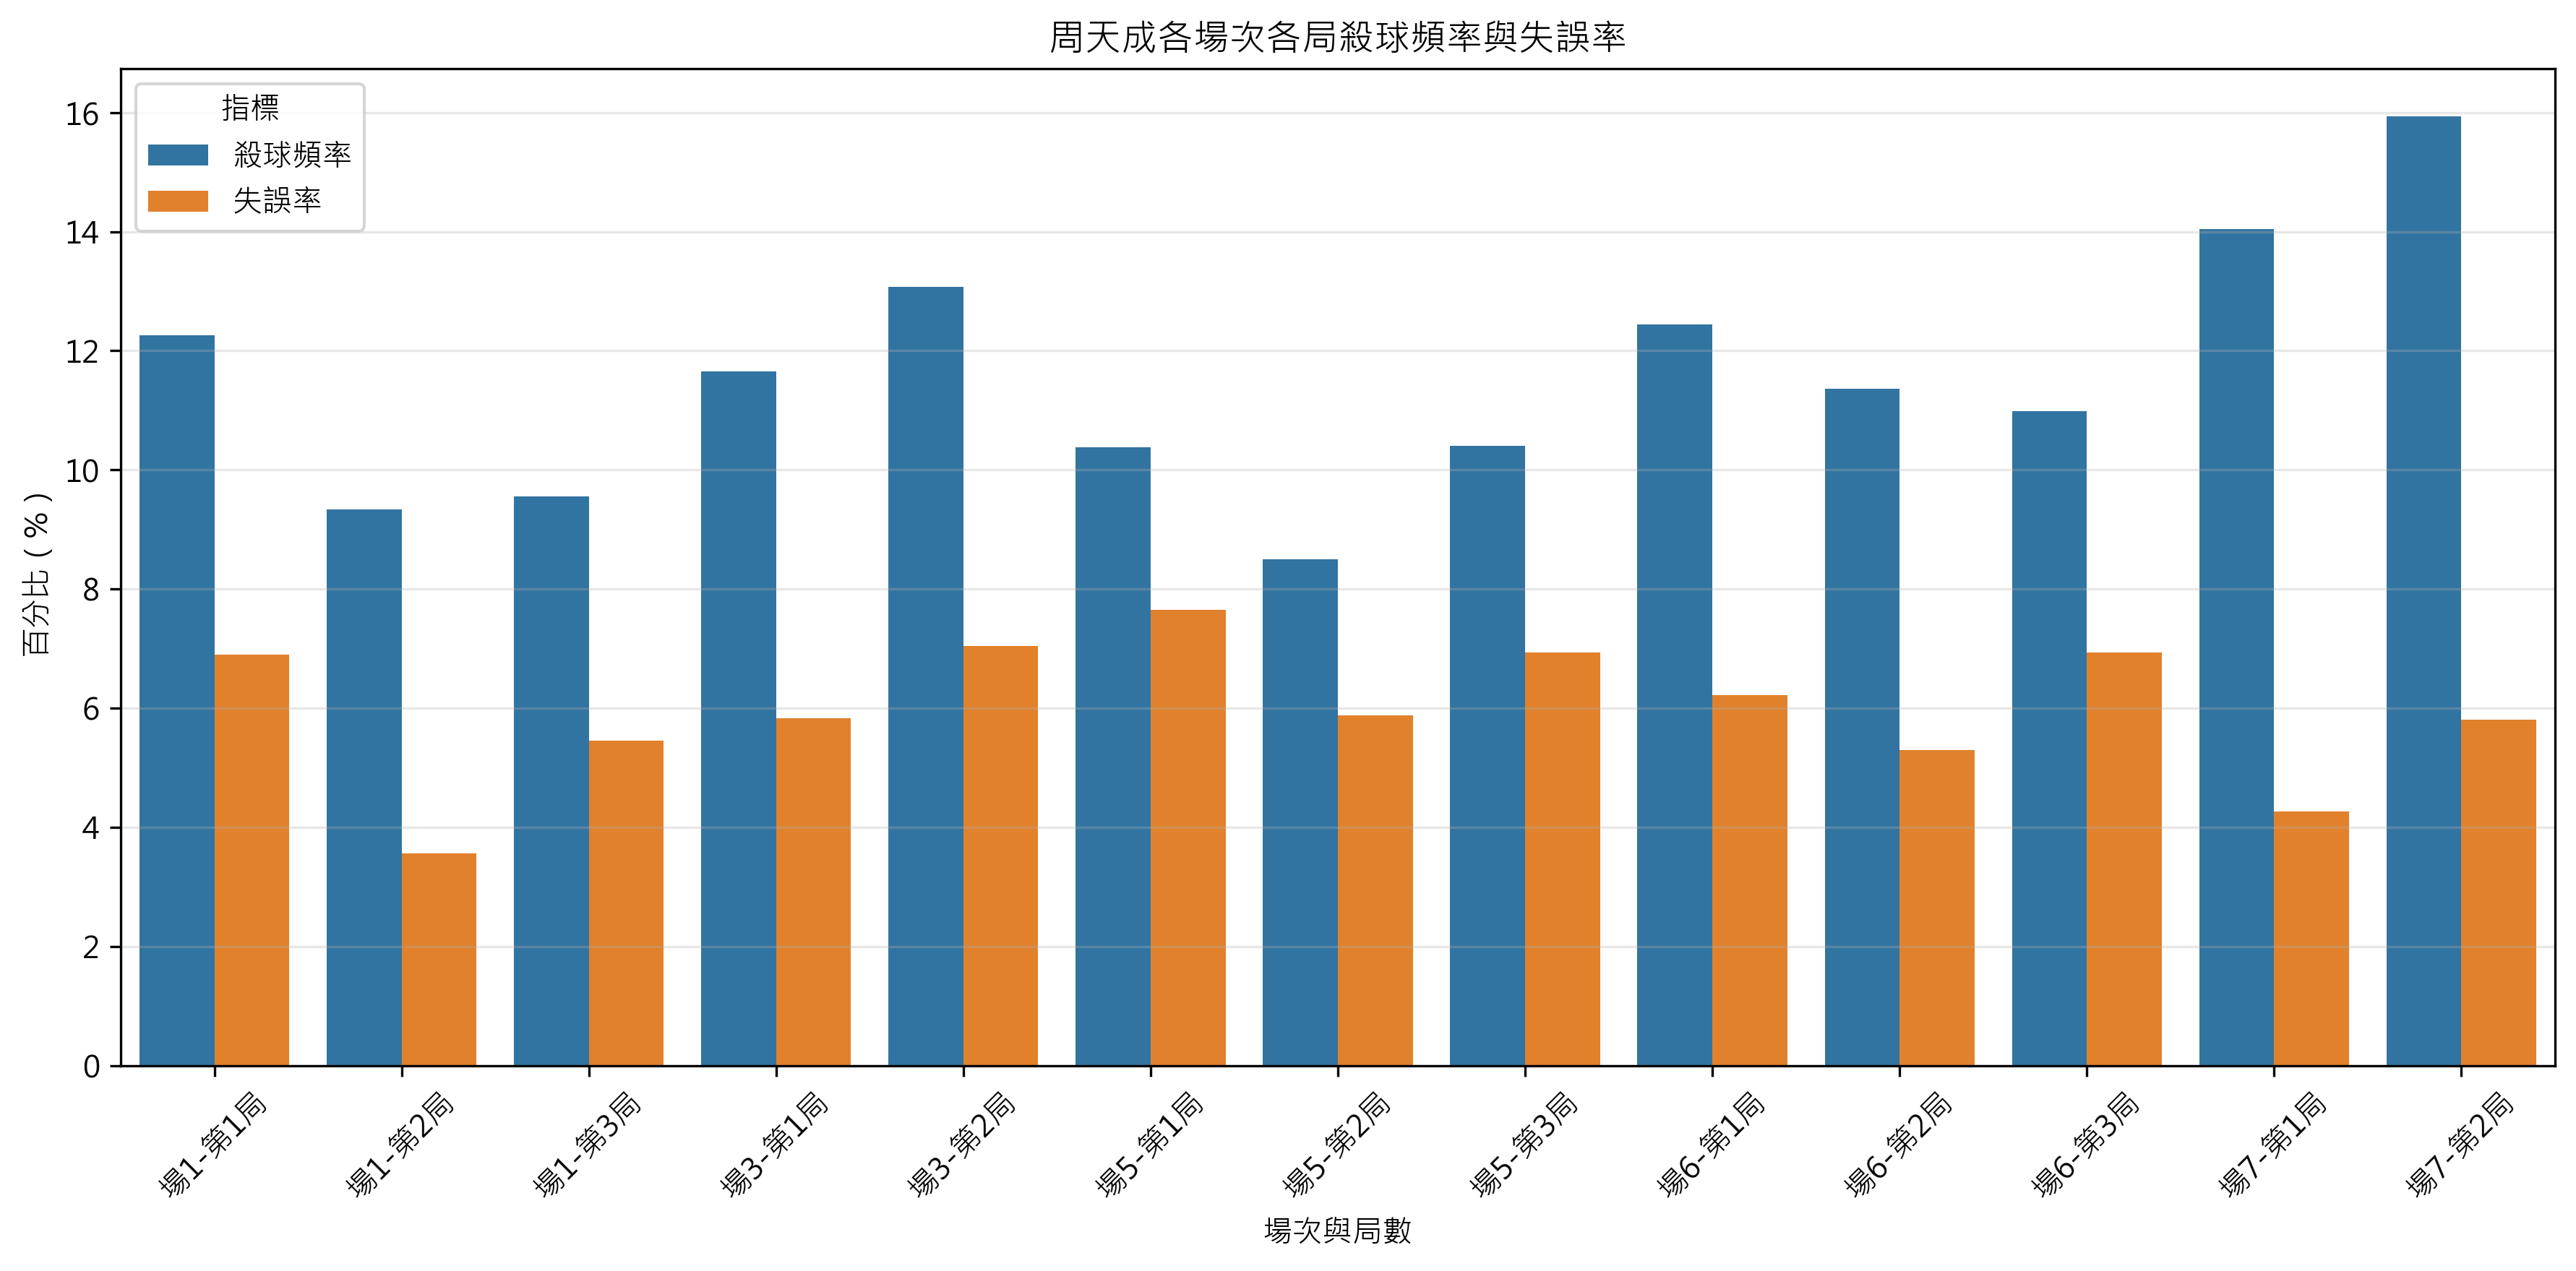

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'getpoint_player', 'lose_reason'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print('資料為空，無法進行分析。')
    fig = plt.figure(figsize=(8, 4))
    plt.tight_layout()
elif len(missing_cols) > 0:
    print(f'缺少必要欄位：{missing_cols}')
    fig = plt.figure(figsize=(8, 4))
    plt.tight_layout()
else:
    target_player = 'CHOU Tien Chen'
    opponent_player = 'Kento MOMOTA'
    unit_cols = ['match_id', 'set']

    work = df.copy()
    work = work.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).reset_index(drop=True)

    target_shots = work[
        work['player'].eq(target_player)
    ].copy()

    target_shots_with_type = target_shots[
        target_shots['type'].notna()
    ].copy()

    # 每場每局的回合數
    rally_summary = (
        work.groupby(unit_cols + ['rally'], dropna=False)
        .agg(
            rally_winner=('getpoint_player', 'last')
        )
        .reset_index()
    )

    rally_summary['resolved_rally'] = rally_summary['rally_winner'].notna()
    rally_summary['target_won'] = (
        rally_summary['rally_winner'].eq(target_player)
    )
    rally_summary['target_lost'] = (
        rally_summary['rally_winner'].eq(opponent_player)
    )

    rally_by_unit = (
        rally_summary.groupby(unit_cols, dropna=False)
        .agg(
            回合數=('rally', 'size'),
            已判定回合數=('resolved_rally', 'sum'),
            得分回合數=('target_won', 'sum'),
            失分回合數=('target_lost', 'sum')
        )
        .reset_index()
    )

    rally_by_unit['得分率'] = (
        rally_by_unit['得分回合數']
        .div(rally_by_unit['已判定回合數'].replace(0, pd.NA))
        .mul(100)
        .fillna(0)
    )

    # 周天成擊球表現與失誤
    target_shot_summary = (
        target_shots.groupby(unit_cols, dropna=False)
        .agg(
            擊球數=('player', 'size'),
            球種數=('type', lambda x: x.dropna().nunique())
        )
        .reset_index()
    )

    target_shot_summary['殺球數'] = (
        target_shots.assign(
            is_smash=target_shots['type'].eq('殺球')
        )
        .groupby(unit_cols, dropna=False)['is_smash']
        .sum()
        .reset_index(drop=True)
    )

    target_shot_summary['殺球頻率'] = (
        target_shot_summary['殺球數']
        .div(target_shot_summary['擊球數'].replace(0, pd.NA))
        .mul(100)
        .fillna(0)
    )

    # 失誤定義：
    # 周天成是該回合最後擊球者，且對手取得該回合分數
    final_rallies = (
        work.groupby(['match_id', 'set', 'rally'], dropna=False)
        .tail(1)
        .copy()
    )

    target_errors = final_rallies[
        final_rallies['player'].eq(target_player)
        & final_rallies['getpoint_player'].eq(opponent_player)
    ].copy()

    error_summary = (
        target_errors.groupby(unit_cols, dropna=False)
        .size()
        .rename('失誤數')
        .reset_index()
    )

    error_reasons = [
        '出界', '未過網', '掛網', '落點判斷失誤', '犯規'
    ]

    error_reason_counts = (
        target_errors[
            target_errors['lose_reason'].notna()
        ]
        .groupby(unit_cols + ['lose_reason'], dropna=False)
        .size()
        .rename('次數')
        .reset_index()
    )

    error_reason_table = (
        error_reason_counts.pivot_table(
            index=unit_cols,
            columns='lose_reason',
            values='次數',
            aggfunc='sum',
            fill_value=0
        )
        .reset_index()
    )

    for reason in error_reasons:
        if reason not in error_reason_table.columns:
            error_reason_table[reason] = 0

    error_reason_table = error_reason_table[
        unit_cols + error_reasons
    ]

    # 各場各局球種使用次數與比例
    shot_type_counts = (
        target_shots_with_type
        .groupby(unit_cols + ['type'], dropna=False)
        .size()
        .rename('次數')
        .reset_index()
    )

    shot_type_table = (
        shot_type_counts.pivot_table(
            index=unit_cols,
            columns='type',
            values='次數',
            aggfunc='sum',
            fill_value=0
        )
        .reset_index()
    )

    all_shot_types = [
        '發短球', '發長球', '長球', '推撲球', '殺球',
        '接殺防守', '平球', '網前球', '挑球', '切球'
    ]

    for shot_type in all_shot_types:
        if shot_type not in shot_type_table.columns:
            shot_type_table[shot_type] = 0

    shot_type_table = shot_type_table[
        unit_cols + all_shot_types
    ]

    shot_type_freq_table = shot_type_table.copy()
    shot_type_freq_table[all_shot_types] = (
        shot_type_freq_table[all_shot_types]
        .div(
            shot_type_freq_table[all_shot_types].sum(axis=1)
            .replace(0, pd.NA),
            axis=0
        )
        .mul(100)
        .fillna(0)
        .round(2)
    )

    # 合併成每場每局的總表
    summary = (
        rally_by_unit
        .merge(target_shot_summary, on=unit_cols, how='outer')
        .merge(error_summary, on=unit_cols, how='left')
        .fillna(0)
    )

    summary['失誤率'] = (
        summary['失誤數']
        .div(summary['擊球數'].replace(0, pd.NA))
        .mul(100)
        .fillna(0)
    )

    summary['得分率'] = summary['得分率'].round(2)
    summary['殺球頻率'] = summary['殺球頻率'].round(2)
    summary['失誤率'] = summary['失誤率'].round(2)

    summary = summary.sort_values(unit_cols).reset_index(drop=True)

    print('周天成各場次各局整體表現：')
    print(
        summary[
            [
                'match_id', 'set', '回合數', '已判定回合數',
                '得分回合數', '失分回合數', '得分率',
                '擊球數', '球種數', '殺球數', '殺球頻率',
                '失誤數', '失誤率'
            ]
        ].to_string(index=False)
    )

    print('\n各場次各局球種使用次數：')
    print(shot_type_table.to_string(index=False))

    print('\n各場次各局球種使用比例（%）：')
    print(shot_type_freq_table.to_string(index=False))

    print('\n各場次各局失誤原因次數：')
    print(error_reason_table.to_string(index=False))

    # 繪製殺球頻率與失誤率，兩者皆以周天中擊球數為基準
    plot_data = summary.copy()
    plot_data['場次-局數'] = (
        '場' + plot_data['match_id'].astype(int).astype(str)
        + '-第' + plot_data['set'].astype(int).astype(str) + '局'
    )

    plot_data = plot_data[
        ['場次-局數', '殺球頻率', '失誤率']
    ].melt(
        id_vars='場次-局數',
        var_name='指標',
        value_name='百分比'
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    if len(plot_data) > 0:
        sns.barplot(
            data=plot_data,
            x='場次-局數',
            y='百分比',
            hue='指標',
            ax=ax
        )
        ax.set_title('周天成各場次各局殺球頻率與失誤率')
        ax.set_xlabel('場次與局數')
        ax.set_ylabel('百分比（%）')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='指標')
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 47
**問題**: 比較周天成與他的對手的球種使用頻率與其得分率。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


統計口徑：
1. 使用頻率 = 該球員該球種使用拍數 / 該球員總擊球數。
2. 得分率 = 該球種 Active Win 拍數 / 該球種使用拍數。
3. Active Win 定義為 player == getpoint_player。

        player type  使用拍數  總擊球數   使用頻率  主動得分拍數    得分率
CHOU Tien Chen  發短球   147  2609  5.63%       0  0.00%
  Kento MOMOTA  發短球   208  2595  8.02%       0  0.00%
CHOU Tien Chen  發長球    34  2609  1.30%       0  0.00%
  Kento MOMOTA  發長球     8  2595  0.31%       0  0.00%
CHOU Tien Chen   長球   275  2609 10.54%       2  0.73%
  Kento MOMOTA   長球   209  2595  8.05%       2  0.96%
CHOU Tien Chen   殺球   299  2609 11.46%      61 20.40%
  Kento MOMOTA   殺球   296  2595 11.41%      31 10.47%
CHOU Tien Chen 接殺防守   351  2609 13.45%       5  1.42%
  Kento MOMOTA 接殺防守   362  2595 13.95%       3  0.83%
CHOU Tien Chen   平球   106  2609  4.06%       2  1.89%
  Kento MOMOTA   平球    76  2595  2.93%       1  1.32%
CHOU Tien Chen  網前球   582  2609 22.31%       4  0.69%
  Kento MOMOTA  網前球   456  2595 17.57%       6  1.32%
…（輸出已截斷；notebook 僅保留重點）


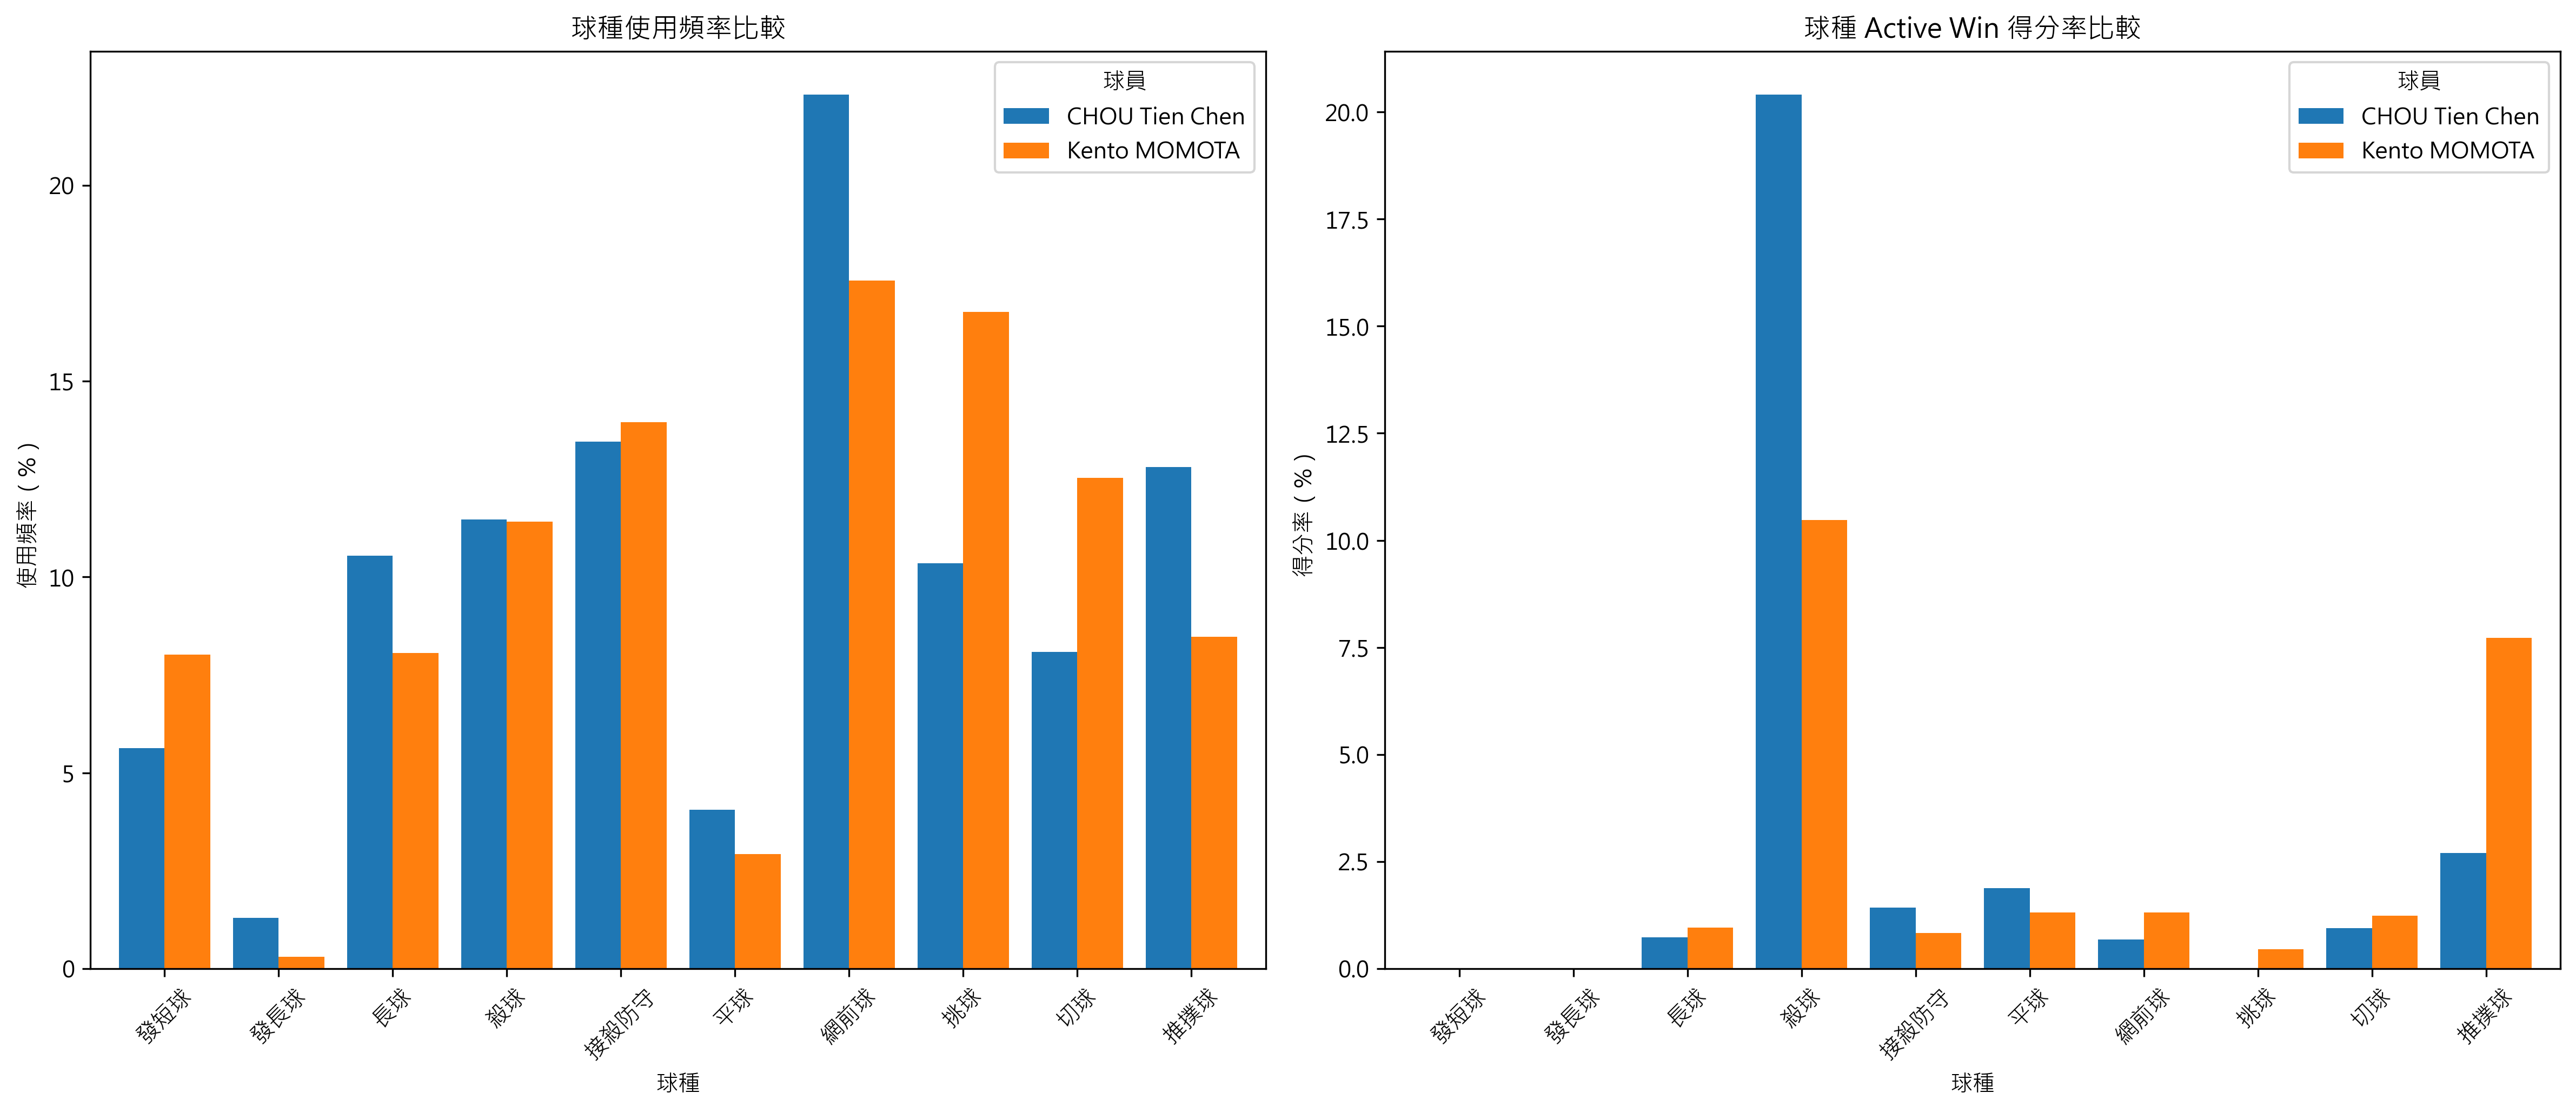

In [ ]:
if len(df) == 0:
    print("資料為空，無法進行分析。")
else:
    player_name = "CHOU Tien Chen"
    opponent_names = sorted(
        df.loc[df["player"].eq(player_name), "opponent"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if len(opponent_names) == 0:
        print("找不到周天成的對手資料，無法進行比較。")
    else:
        opponent_name = opponent_names[0]

        required_columns = ["player", "type", "getpoint_player"]
        missing_columns = [col for col in required_columns if col not in df.columns]

        if missing_columns:
            print(f"缺少必要欄位：{missing_columns}")
        else:
            shot_df = df[required_columns].dropna(subset=["player", "type"]).copy()
            shot_df["player"] = shot_df["player"].astype(str)
            shot_df["type"] = shot_df["type"].astype(str)

            comparison_players = [player_name, opponent_name]
            shot_df = shot_df[shot_df["player"].isin(comparison_players)].copy()

            if len(shot_df) == 0:
                print("找不到周天成與對手的有效擊球資料。")
            else:
                shot_df["active_win"] = (
                    shot_df["player"].eq(shot_df["getpoint_player"])
                )

                shot_counts = (
                    shot_df.groupby(["player", "type"], as_index=False)
                    .size()
                    .rename(columns={"size": "使用拍數"})
                )

                total_shots = (
                    shot_counts.groupby("player")["使用拍數"]
                    .sum()
                    .rename("總擊球數")
                    .reset_index()
                )

                active_wins = (
                    shot_df[shot_df["active_win"]]
                    .groupby(["player", "type"], as_index=False)
                    .size()
                    .rename(columns={"size": "主動得分拍數"})
                )

                result = shot_counts.merge(
                    active_wins,
                    on=["player", "type"],
                    how="left"
                )

                result = result.merge(total_shots, on="player", how="left")
                result["主動得分拍數"] = result["主動得分拍數"].fillna(0).astype(int)
                result["使用頻率"] = result["使用拍數"] / result["總擊球數"] * 100
                result["得分率"] = (
                    result["主動得分拍數"] / result["使用拍數"] * 100
                )

                shot_order = [
                    "發短球", "發長球", "長球", "殺球", "接殺防守",
                    "平球", "網前球", "挑球", "切球", "推撲球"
                ]
                observed_types = result["type"].drop_duplicates().tolist()
                ordered_types = [
                    shot_type for shot_type in shot_order if shot_type in observed_types
                ]
                ordered_types += [
                    shot_type for shot_type in observed_types
                    if shot_type not in ordered_types
                ]

                result["type"] = pd.Categorical(
                    result["type"],
                    categories=ordered_types,
                    ordered=True
                )
                result = result.sort_values(["type", "player"]).reset_index(drop=True)

                print("統計口徑：")
                print("1. 使用頻率 = 該球員該球種使用拍數 / 該球員總擊球數。")
                print("2. 得分率 = 該球種 Active Win 拍數 / 該球種使用拍數。")
                print("3. Active Win 定義為 player == getpoint_player。")
                print()
                print(result[
                    [
                        "player", "type", "使用拍數", "總擊球數",
                        "使用頻率", "主動得分拍數", "得分率"
                    ]
                ].to_string(
                    index=False,
                    formatters={
                        "使用頻率": "{:.2f}%".format,
                        "得分率": "{:.2f}%".format
                    }
                ))

                frequency_plot = result.pivot(
                    index="type",
                    columns="player",
                    values="使用頻率"
                ).reindex(ordered_types)

                success_rate_plot = result.pivot(
                    index="type",
                    columns="player",
                    values="得分率"
                ).reindex(ordered_types)

                fig, axes = plt.subplots(1, 2, figsize=(16, 7))

                frequency_plot.plot(
                    kind="bar",
                    ax=axes[0],
                    width=0.8
                )
                axes[0].set_title("球種使用頻率比較")
                axes[0].set_xlabel("球種")
                axes[0].set_ylabel("使用頻率（%）")
                axes[0].tick_params(axis="x", rotation=45)
                axes[0].legend(title="球員")

                success_rate_plot.plot(
                    kind="bar",
                    ax=axes[1],
                    width=0.8
                )
                axes[1].set_title("球種 Active Win 得分率比較")
                axes[1].set_xlabel("球種")
                axes[1].set_ylabel("得分率（%）")
                axes[1].tick_params(axis="x", rotation=45)
                axes[1].legend(title="球員")

                plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 50
**問題**: 分析周天成接發球策略：長球、網前球、平球的比例與得分影響。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


周天成接發球有效單拍數：221
其中具有回合最終得分者的接發球單拍數：221
接發球比例分母：周天成所有有效接發球單拍；得分影響以該回合最終得分者計算。
接發球球種  接發球次數 接發球比例(%)  可判定得分回合數  周天成得分回合  對手得分回合 周天成得分率(%) 對手得分率(%)  得分差(周天成-對手)
   長球      5     2.26         5        3       2     60.00    40.00            1
  網前球     88    39.82        88       44      44     50.00    50.00            0
   平球      5     2.26         5        1       4     20.00    80.00           -3


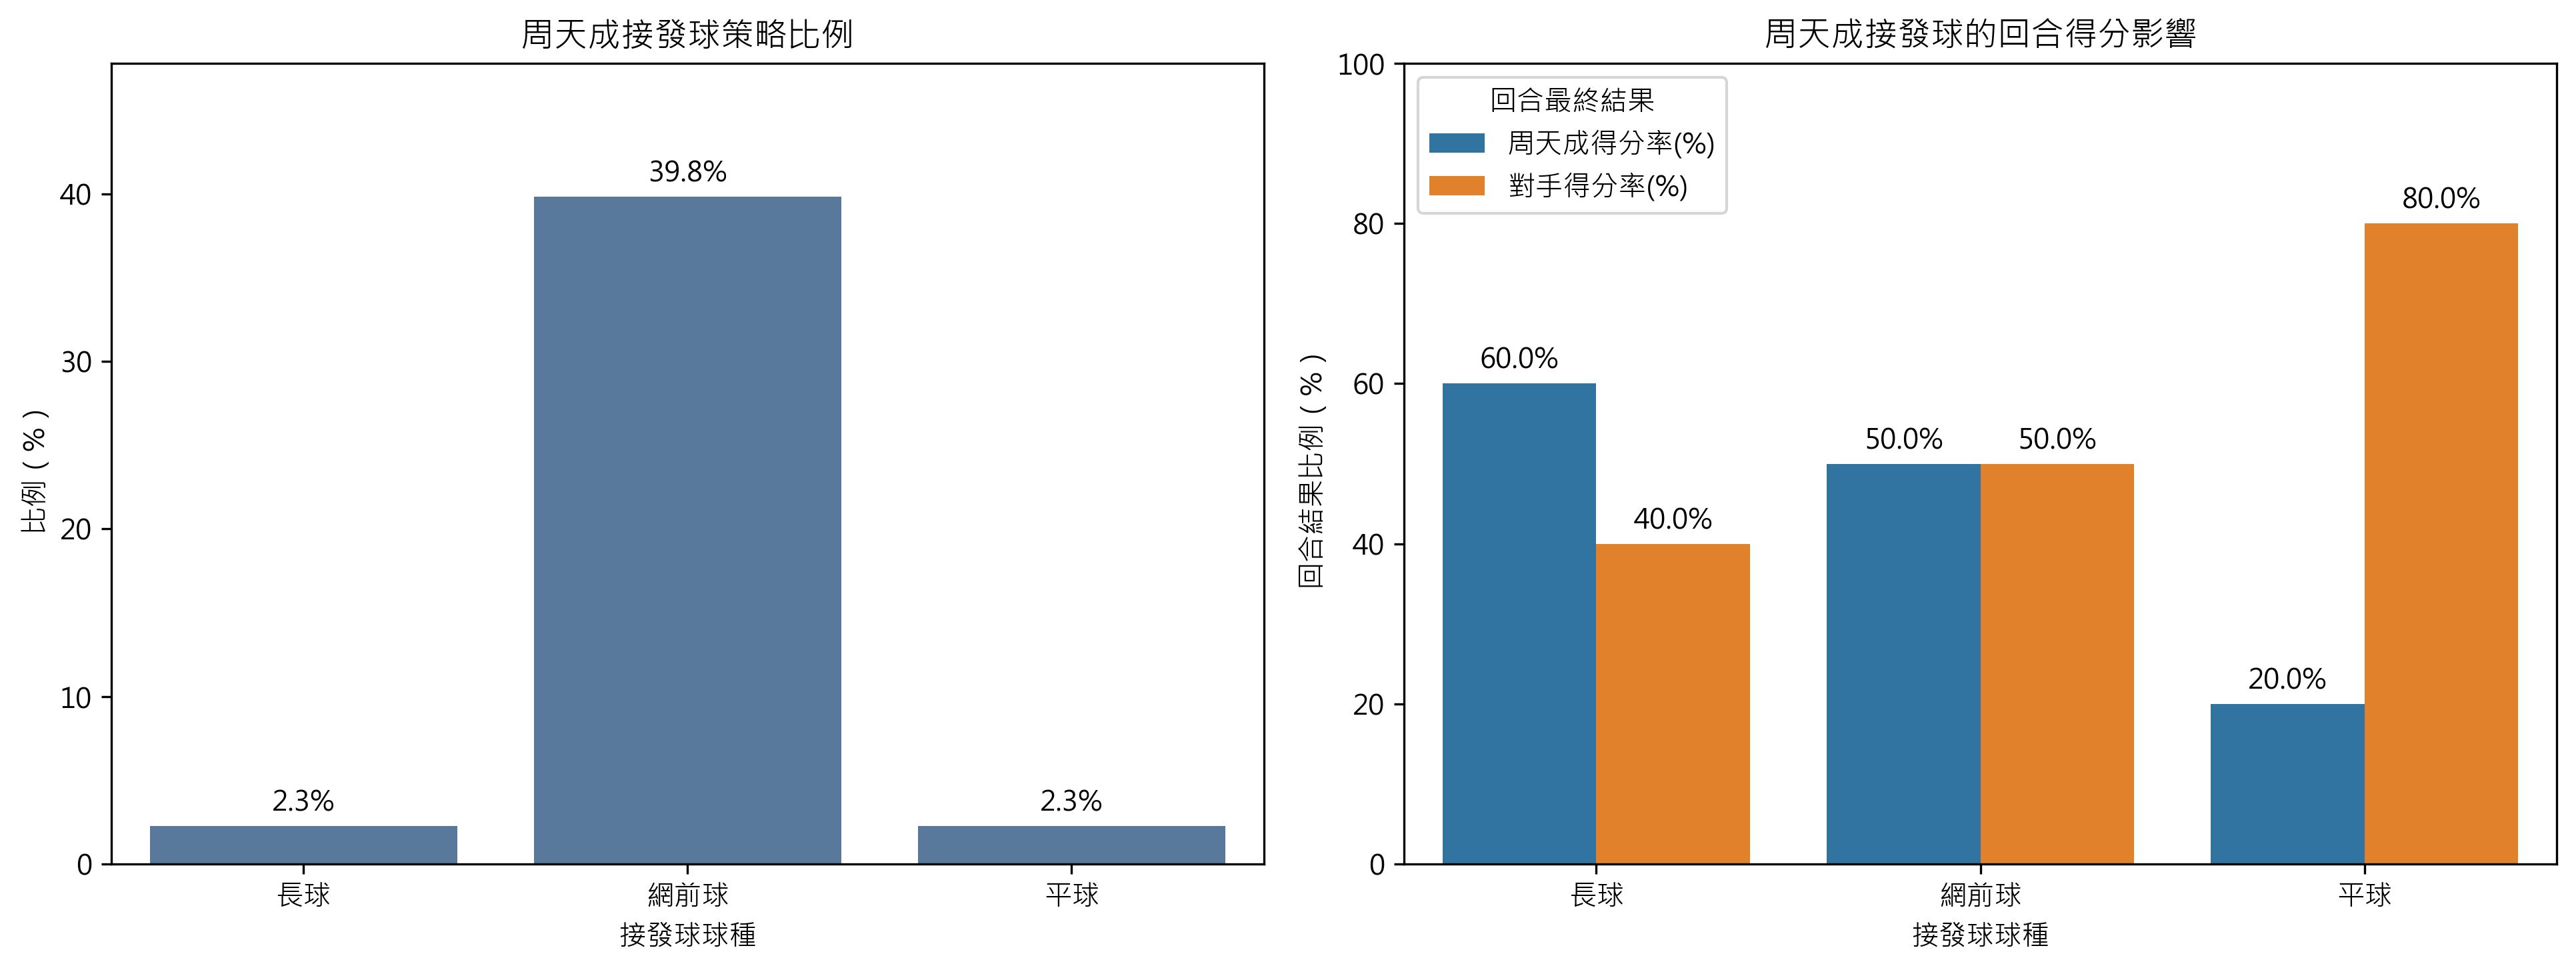

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'type', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法分析。')
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].set_title('周天成接發球策略比例')
    axes[1].set_title('周天成接發球得分影響')
    plt.tight_layout()
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].set_title('周天成接發球策略比例')
        axes[1].set_title('周天成接發球得分影響')
        plt.tight_layout()
    else:
        chou = 'CHOU Tien Chen'
        opponent = 'Kento MOMOTA'
        target_types = ['長球', '網前球', '平球']
        rally_keys = ['match_id', 'set', 'rally']

        work = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).copy()

        # 接發球單拍定義：每個回合第 2 拍且擊球者為周天成
        receive_df = work.loc[
            (work['ball_round'] == 2) &
            (work['player'] == chou),
            rally_keys + ['ball_round', 'player', 'type']
        ].dropna(subset=['type']).copy()

        # 取每個 match_id、set、rally 的最後一拍，取得回合最終得分者
        rally_end = (
            work.groupby(rally_keys, sort=False, as_index=False)
            .tail(1)[rally_keys + ['getpoint_player']]
            .copy()
        )

        receive_df = receive_df.merge(
            rally_end,
            on=rally_keys,
            how='left',
            validate='one_to_one'
        )

        total_receive = len(receive_df)
        scored_receive = receive_df.dropna(
            subset=['getpoint_player']
        ).copy()

        if total_receive == 0:
            print('找不到周天成接發球單拍資料。')
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            axes[0].set_title('周天成接發球策略比例')
            axes[1].set_title('周天成接發球得分影響')
            plt.tight_layout()
        else:
            strategy_rows = []

            for shot_type in target_types:
                shot_df = receive_df.loc[
                    receive_df['type'] == shot_type
                ].copy()

                scored_shot_df = shot_df.dropna(
                    subset=['getpoint_player']
                ).copy()

                chou_points = (
                    scored_shot_df['getpoint_player'] == chou
                ).sum()
                opponent_points = (
                    scored_shot_df['getpoint_player'] == opponent
                ).sum()
                valid_points = chou_points + opponent_points

                strategy_rows.append({
                    '接發球球種': shot_type,
                    '接發球次數': len(shot_df),
                    '接發球比例(%)': len(shot_df) / total_receive * 100,
                    '可判定得分回合數': valid_points,
                    '周天成得分回合': chou_points,
                    '對手得分回合': opponent_points,
                    '周天成得分率(%)': (
                        chou_points / valid_points * 100
                        if valid_points > 0 else 0
                    ),
                    '對手得分率(%)': (
                        opponent_points / valid_points * 100
                        if valid_points > 0 else 0
                    ),
                    '得分差(周天成-對手)': chou_points - opponent_points
                })

            strategy_df = pd.DataFrame(strategy_rows)

            print(f'周天成接發球有效單拍數：{total_receive}')
            print(
                f'其中具有回合最終得分者的接發球單拍數：'
                f'{len(scored_receive)}'
            )
            print(
                '接發球比例分母：周天成所有有效接發球單拍；'
                '得分影響以該回合最終得分者計算。'
            )
            print(
                strategy_df.to_string(
                    index=False,
                    formatters={
                        '接發球比例(%)': '{:.2f}'.format,
                        '周天成得分率(%)': '{:.2f}'.format,
                        '對手得分率(%)': '{:.2f}'.format
                    }
                )
            )

            plot_df = strategy_df.copy()

            fig, axes = plt.subplots(1, 2, figsize=(13, 5))

            sns.barplot(
                data=plot_df,
                x='接發球球種',
                y='接發球比例(%)',
                order=target_types,
                color='#4C78A8',
                ax=axes[0]
            )
            axes[0].set_title('周天成接發球策略比例')
            axes[0].set_xlabel('接發球球種')
            axes[0].set_ylabel('比例（%）')
            axes[0].set_ylim(
                0,
                max(plot_df['接發球比例(%)'].max() * 1.2, 1)
            )

            impact_df = plot_df.melt(
                id_vars='接發球球種',
                value_vars=['周天成得分率(%)', '對手得分率(%)'],
                var_name='結果',
                value_name='比例(%)'
            )

            sns.barplot(
                data=impact_df,
                x='接發球球種',
                y='比例(%)',
                hue='結果',
                order=target_types,
                ax=axes[1]
            )
            axes[1].set_title('周天成接發球的回合得分影響')
            axes[1].set_xlabel('接發球球種')
            axes[1].set_ylabel('回合結果比例（%）')
            axes[1].legend(title='回合最終結果')
            axes[1].set_ylim(0, 100)

            for ax in axes:
                for container in ax.containers:
                    labels = [
                        f'{bar.get_height():.1f}%'
                        if bar.get_height() > 0 else ''
                        for bar in container
                    ]
                    ax.bar_label(container, labels=labels, padding=3)

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 51
**問題**: 分析對手殺球到前中後排後，周天成分別會怎麼去反擊？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, stroke_details`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）


落點區域定義：
前排: [17, 18, 19, 20, 21, 22, 23, 24]
中排: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
後排: [1, 2, 3, 4]
界外: [25, 26, 27, 28, 29, 30, 31, 32]
符合條件的對手殺球事件數：248
周天成在不同殺球落點排別的下一拍回擊方式：
smash_landing_zone next_type  回擊次數  區內回擊比例(%)
                前排      接殺防守     1       50.0
                前排       網前球     1       50.0
                中排      接殺防守   215       87.4
                中排       網前球    22        8.9
                中排        平球     6        2.4
                中排       推撲球     2        0.8
                中排        殺球     1        0.4

回擊次數交叉表：
next_type           平球  接殺防守  推撲球  殺球  網前球
smash_landing_zone                        
前排                   0     1    0   0    1
…（輸出已截斷；notebook 僅保留重點）


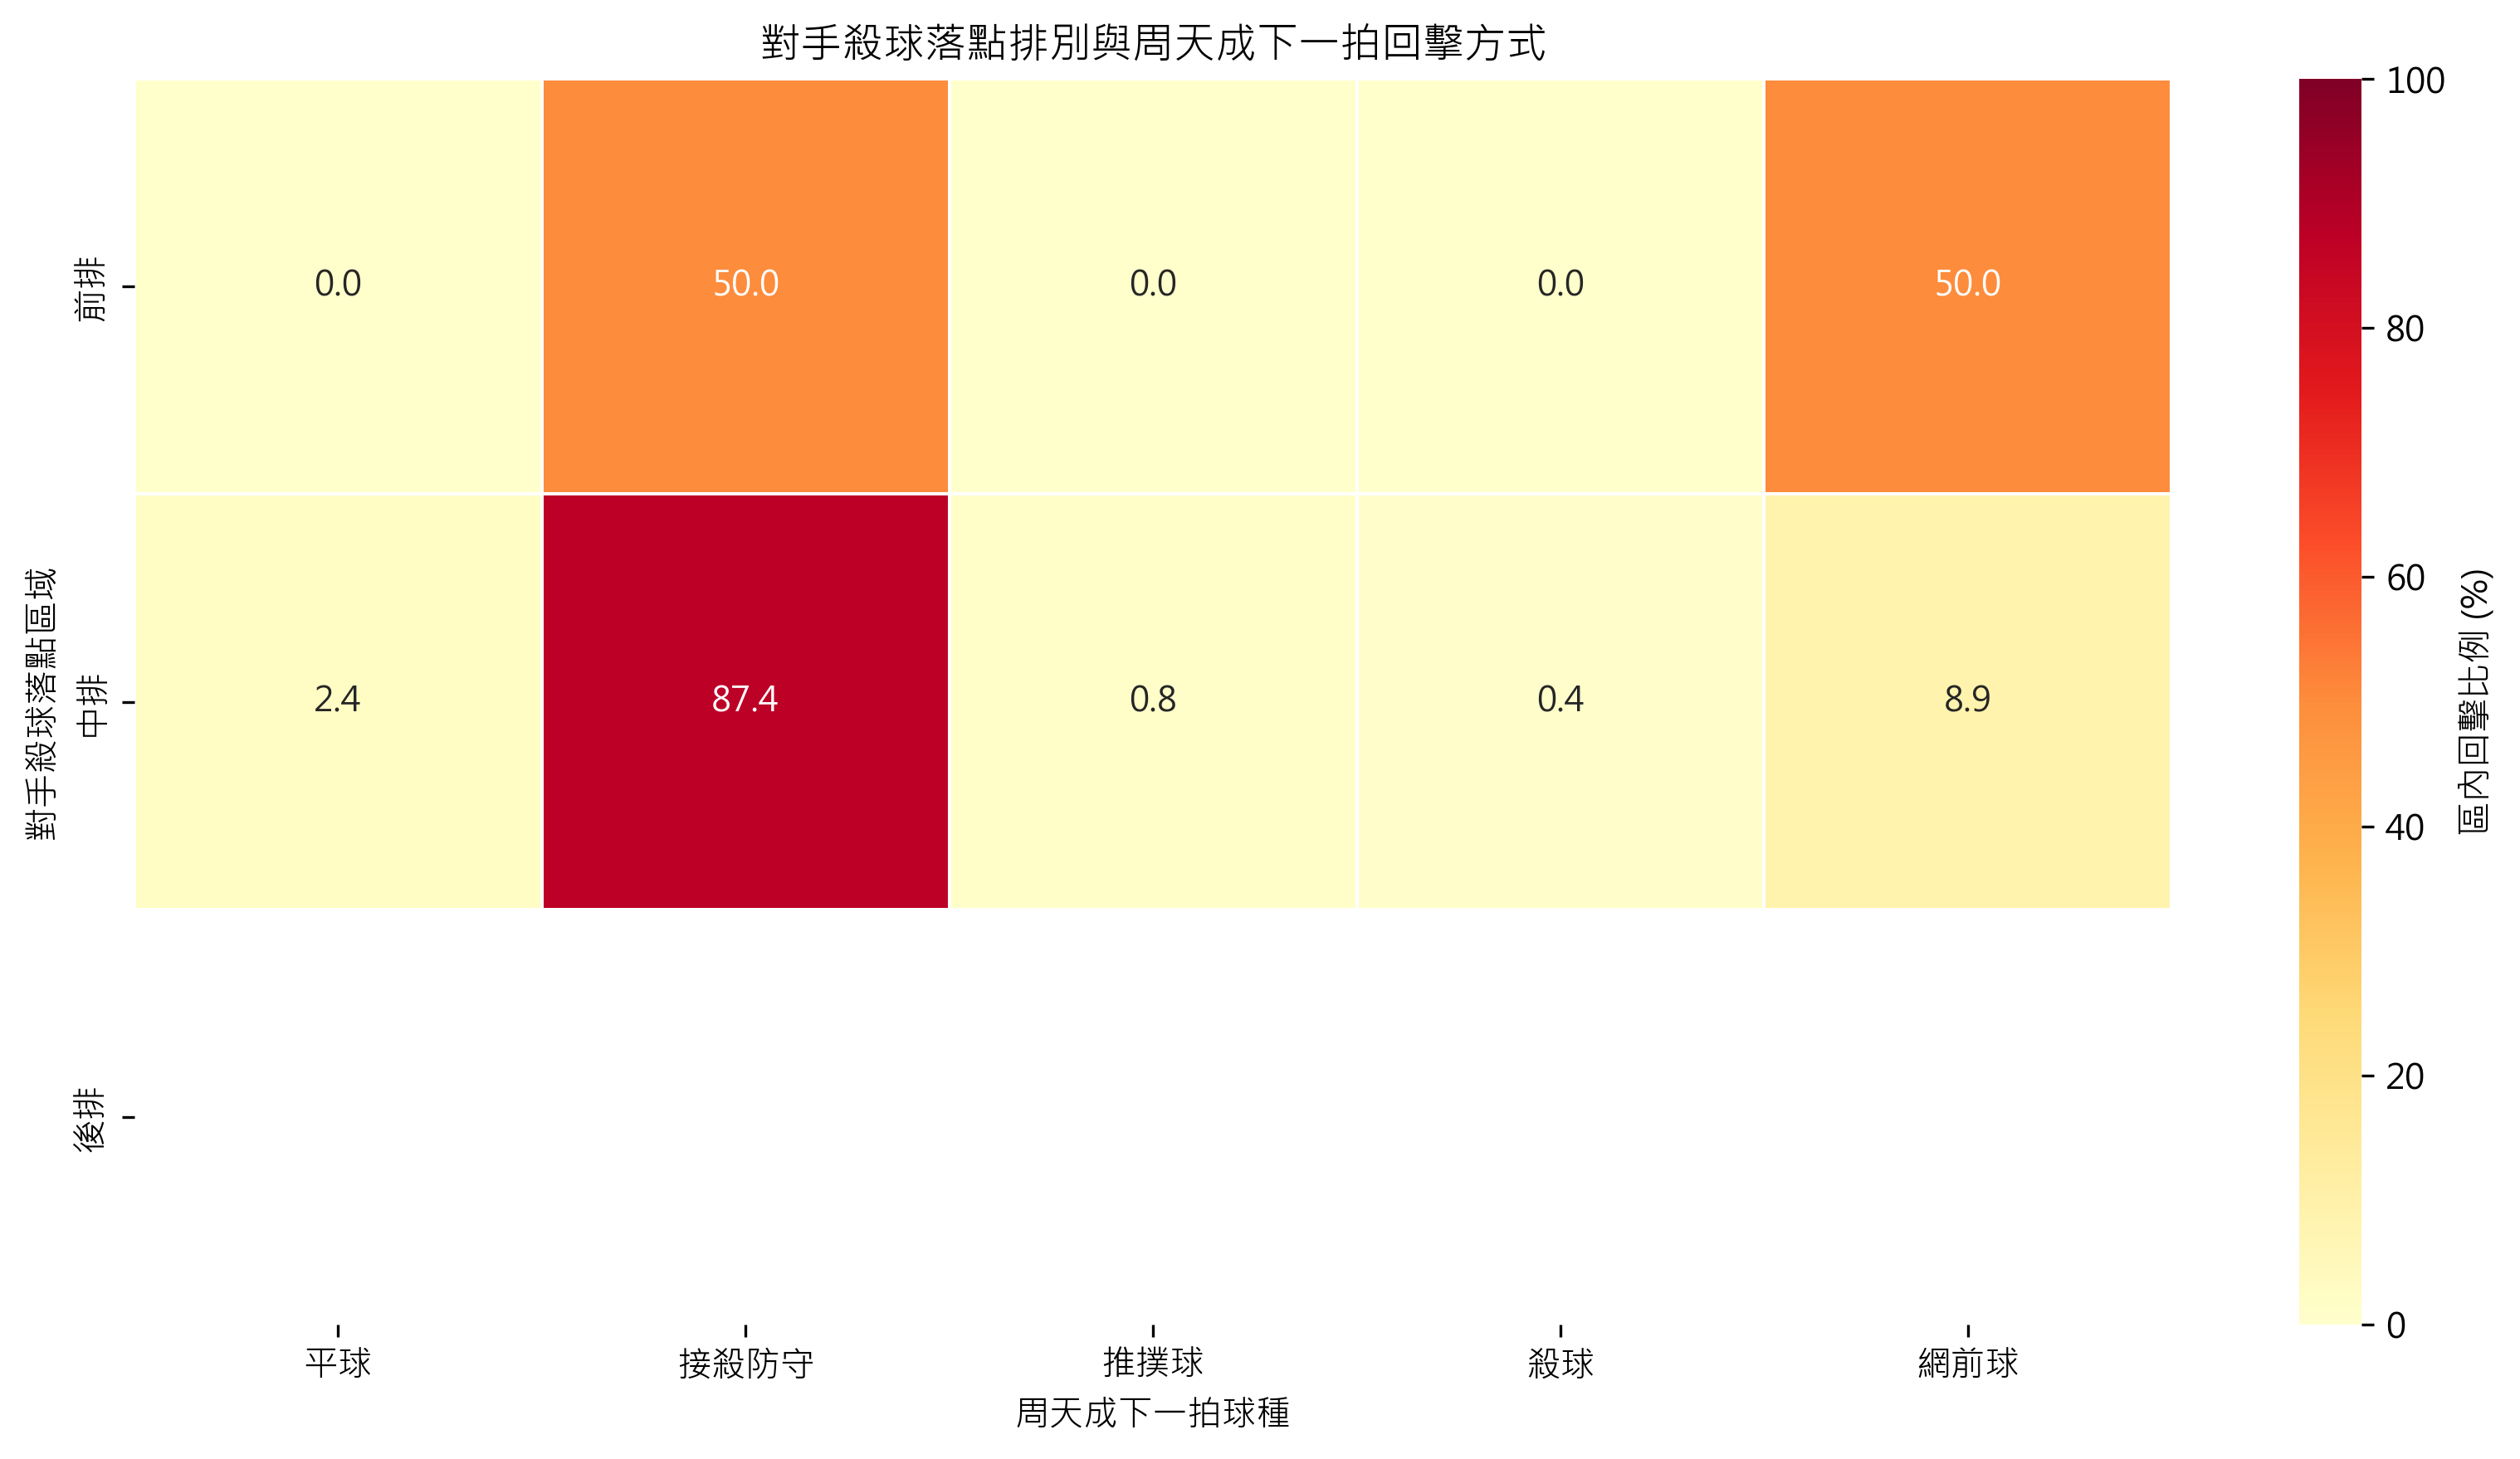

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

if len(df) == 0:
    print("資料為空，無法分析。")
    ax.text(0.5, 0.5, "無資料可分析", ha="center", va="center", fontsize=14)
    ax.axis("off")
    plt.tight_layout()
else:
    required_columns = [
        "match_id", "set", "rally", "ball_round",
        "player", "type", "landing_area"
    ]
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        print(f"缺少必要欄位：{missing_columns}")
        ax.text(0.5, 0.5, "缺少必要欄位", ha="center", va="center", fontsize=14)
        ax.axis("off")
        plt.tight_layout()
    else:
        target_player = "CHOU Tien Chen"
        opponent_player = "Kento MOMOTA"

        court_grid_definitions = {
            "前排": [17, 18, 19, 20, 21, 22, 23, 24],
            "中排": [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
            "後排": [1, 2, 3, 4],
            "界外": [25, 26, 27, 28, 29, 30, 31, 32]
        }

        print("落點區域定義：")
        for category, zones in court_grid_definitions.items():
            print(f"{category}: {zones}")

        work = df.copy()
        work = work.sort_values(
            ["match_id", "set", "rally", "ball_round"]
        ).reset_index(drop=True)

        rally_group = ["match_id", "set", "rally"]

        work["next_player"] = (
            work.groupby(rally_group, sort=False)["player"].shift(-1)
        )
        work["next_type"] = (
            work.groupby(rally_group, sort=False)["type"].shift(-1)
        )
        work["next_ball_round"] = (
            work.groupby(rally_group, sort=False)["ball_round"].shift(-1)
        )

        def classify_landing_zone(area):
            if pd.isna(area):
                return None
            area = int(area)
            if area in court_grid_definitions["前排"]:
                return "前排"
            if area in court_grid_definitions["中排"]:
                return "中排"
            if area in court_grid_definitions["後排"]:
                return "後排"
            if area in court_grid_definitions["界外"]:
                return "界外"
            return None

        work["smash_landing_zone"] = work["landing_area"].apply(
            classify_landing_zone
        )

        event_mask = (
            (work["player"] == opponent_player) &
            (work["type"] == "殺球") &
            (work["next_player"] == target_player) &
            (work["smash_landing_zone"].isin(["前排", "中排", "後排"])) &
            work["next_type"].notna() &
            work["next_ball_round"].notna() &
            (work["next_ball_round"] == work["ball_round"] + 1)
        )

        events = work.loc[
            event_mask,
            [
                "match_id", "set", "rally", "ball_round",
                "landing_area", "smash_landing_zone", "next_type"
            ]
        ].copy()

        if len(events) == 0:
            print("找不到符合條件的事件：對手殺球後，由周天成完成同回合下一拍回擊。")
            ax.text(
                0.5, 0.5,
                "無符合條件的對手殺球與周天成下一拍回擊事件",
                ha="center", va="center", fontsize=13
            )
            ax.axis("off")
            plt.tight_layout()
        else:
            zone_order = ["前排", "中排", "後排"]
            events["smash_landing_zone"] = pd.Categorical(
                events["smash_landing_zone"],
                categories=zone_order,
                ordered=True
            )

            response_counts = (
                events.groupby(
                    ["smash_landing_zone", "next_type"],
                    observed=True
                )
                .size()
                .reset_index(name="回擊次數")
            )

            zone_totals = (
                response_counts.groupby(
                    "smash_landing_zone",
                    observed=True
                )["回擊次數"]
                .transform("sum")
            )
            response_counts["區內回擊比例(%)"] = (
                response_counts["回擊次數"] / zone_totals * 100
            ).round(1)

            response_counts = response_counts.sort_values(
                ["smash_landing_zone", "回擊次數"],
                ascending=[True, False]
            )

            print(f"符合條件的對手殺球事件數：{len(events)}")
            print("周天成在不同殺球落點排別的下一拍回擊方式：")
            print(response_counts.to_string(index=False))

            count_table = pd.crosstab(
                events["smash_landing_zone"],
                events["next_type"]
            ).reindex(zone_order, fill_value=0)

            percentage_table = (
                count_table.div(count_table.sum(axis=1), axis=0) * 100
            ).round(1)

            print("\n回擊次數交叉表：")
            print(count_table.to_string())

            print("\n區內回擊比例(%)交叉表：")
            print(percentage_table.to_string())

            plt.close(fig)
            fig, ax = plt.subplots(figsize=(11, 6))

            sns.heatmap(
                percentage_table,
                annot=True,
                fmt=".1f",
                cmap="YlOrRd",
                vmin=0,
                vmax=100,
                linewidths=0.5,
                cbar_kws={"label": "區內回擊比例 (%)"},
                ax=ax
            )

            ax.set_title("對手殺球落點排別與周天成下一拍回擊方式")
            ax.set_xlabel("周天成下一拍球種")
            ax.set_ylabel("對手殺球落點區域")
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 60
**問題**: 分析周天成在自己失分回合中，最後一拍前一拍最常使用的球種。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


周天成自己失分回合數（倒數第二拍由周天成擊球）：62
最常使用球種：長球，次數：17，比例：27.42%
  球種  次數     比例
  長球  17 27.42%
 網前球  14 22.58%
  挑球   7 11.29%
 推撲球   6  9.68%
  切球   6  9.68%
接殺防守   5  8.06%
 發長球   3  4.84%
  殺球   2  3.23%
  平球   2  3.23%


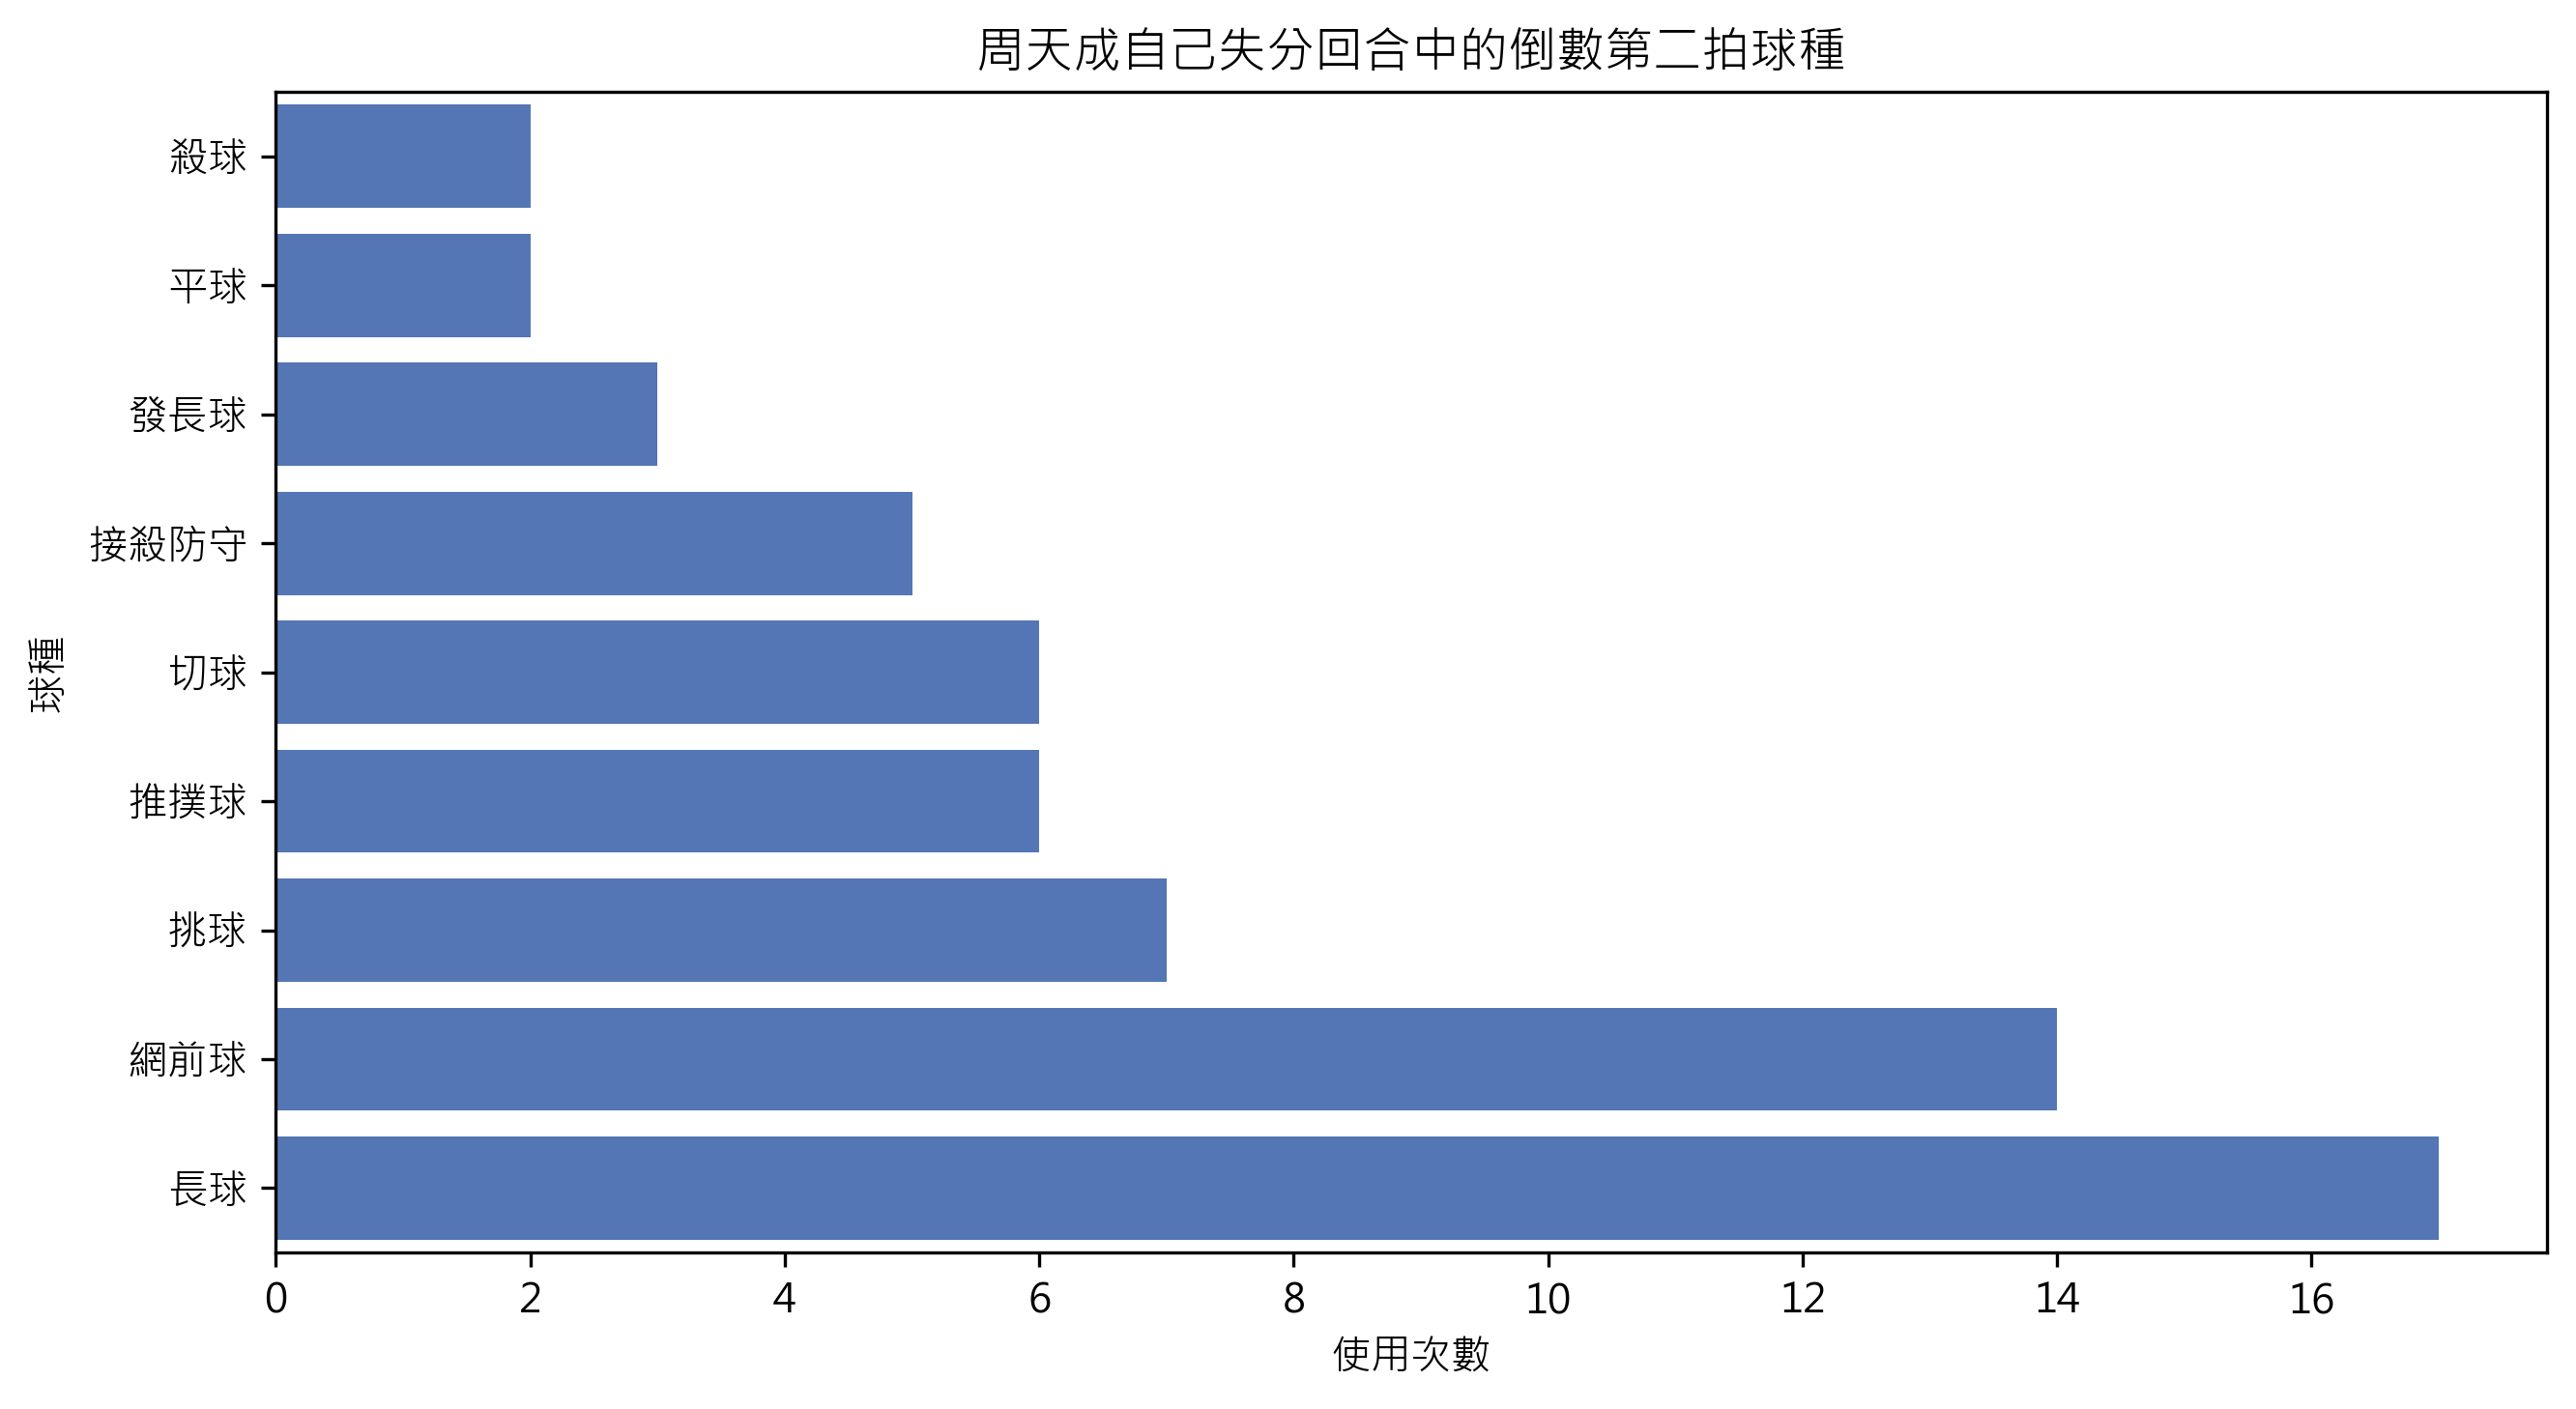

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'opponent', 'type', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法分析。')
elif not set(required_cols).issubset(df.columns):
    missing_cols = sorted(set(required_cols) - set(df.columns))
    print(f'缺少必要欄位：{missing_cols}')
else:
    player_name = 'CHOU Tien Chen'
    opponent_name = 'Kento MOMOTA'
    group_cols = ['match_id', 'set', 'rally']

    work = df.sort_values(
        group_cols + ['ball_round']
    ).copy()

    valid = work[required_cols].dropna(
        subset=['match_id', 'set', 'rally', 'ball_round', 'player', 'type']
    ).copy()

    if len(valid) == 0:
        print('沒有足夠的有效擊球資料可供分析。')
    else:
        rally_winner = (
            valid.groupby(group_cols, sort=False)['getpoint_player']
            .transform('last')
        )

        next_player = (
            valid.groupby(group_cols, sort=False)['player']
            .shift(-1)
        )
        next_getpoint_player = (
            valid.groupby(group_cols, sort=False)['getpoint_player']
            .shift(-1)
        )

        second_last_shots = valid[
            (rally_winner == opponent_name) &
            (valid['player'] == player_name) &
            (next_player == opponent_name) &
            (next_getpoint_player == opponent_name)
        ].copy()

        if len(second_last_shots) == 0:
            print('找不到周天成在自己失分回合中的倒數第二拍資料。')
        else:
            shot_counts = (
                second_last_shots['type']
                .value_counts()
                .rename_axis('球種')
                .reset_index(name='次數')
            )
            shot_counts['比例'] = (
                shot_counts['次數'] / shot_counts['次數'].sum() * 100
            )

            most_common_shot = shot_counts.iloc[0]

            print(f'周天成自己失分回合數（倒數第二拍由周天成擊球）：{len(second_last_shots)}')
            print(
                f"最常使用球種：{most_common_shot['球種']}，"
                f"次數：{int(most_common_shot['次數'])}，"
                f"比例：{most_common_shot['比例']:.2f}%"
            )
            print(shot_counts.to_string(index=False, formatters={
                '比例': '{:.2f}%'.format
            }))

            fig, ax = plt.subplots(figsize=(9, 5))
            plot_data = shot_counts.sort_values('次數', ascending=True)

            sns.barplot(
                data=plot_data,
                x='次數',
                y='球種',
                color='#4472C4',
                ax=ax
            )

            ax.set_title('周天成自己失分回合中的倒數第二拍球種')
            ax.set_xlabel('使用次數')
            ax.set_ylabel('球種')
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 61
**問題**: 在被對手四角拉吊得回合下，周天成勝率是多少？四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)
> **使用的資料欄位群組**: `game_structure, coordinates, player_movement, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm+semantic_guard）


In [ ]:
required_columns = [
    'match_id', 'set', 'rally', 'ball_round', 'player',
    'hit_area', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法計算。')
elif not set(required_columns).issubset(df.columns):
    missing_columns = sorted(set(required_columns) - set(df.columns))
    print(f'缺少必要欄位：{missing_columns}')
else:
    zhou = 'CHOU Tien Chen'
    opponent = 'Kento MOMOTA'
    rally_keys = ['match_id', 'set', 'rally']
    corner_zones = {1, 4, 21, 24}

    work = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    grouped = work.groupby(rally_keys, sort=False)

    work['next_player'] = grouped['player'].shift(-2)
    work['next_hit_area'] = grouped['hit_area'].shift(-2)
    work['next_match_id'] = grouped['match_id'].shift(-2)
    work['next_set'] = grouped['set'].shift(-2)
    work['next_rally'] = grouped['rally'].shift(-2)

    same_rally_next_shot = (
        (work['match_id'] == work['next_match_id']) &
        (work['set'] == work['next_set']) &
        (work['rally'] == work['next_rally'])
    )

    opponent_four_corner_pull = (
        (work['player'] == opponent) &
        same_rally_next_shot &
        (work['next_player'] == opponent) &
        (work['hit_area'].isin(corner_zones)) &
        (work['next_hit_area'].isin(corner_zones)) &
        (work['hit_area'] != work['next_hit_area'])
    )

    work['rally_getpoint_player'] = grouped['getpoint_player'].transform('last')

    qualifying_rallies = (
        work.loc[opponent_four_corner_pull, rally_keys]
        .drop_duplicates()
        .merge(
            work[rally_keys + ['rally_getpoint_player']].drop_duplicates(),
            on=rally_keys,
            how='left'
        )
    )

    total_rallies = len(qualifying_rallies)
    zhou_wins = (
        qualifying_rallies['rally_getpoint_player'] == zhou
    ).sum()

    win_rate = zhou_wins / total_rallies * 100 if total_rallies > 0 else 0.0

    print(f'對手四角拉吊後的周天成勝回合數：{zhou_wins}')
    print(f'對手四角拉吊後的有效回合數：{total_rallies}')
    print(f'周天成勝率：{win_rate:.2f}%')


對手四角拉吊後的周天成勝回合數：27
對手四角拉吊後的有效回合數：63
周天成勝率：42.86%


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 63
**問題**: 哪些球種組合是周天成最常使用的，反而讓對手主動攻擊？(可能是周天成連續打長球，讓對手抓時機殺球)
> **使用的資料欄位群組**: `game_structure, shot_type`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


主動攻擊球種定義：殺球、推撲球、平球
             球種組合  使用次數  對手主動攻擊次數 對手主動攻擊率
   周天成：長球 → 對手：殺球   102       102  100.0%
 周天成：網前球 → 對手：推撲球    83        83  100.0%
   周天成：挑球 → 對手：殺球    81        81  100.0%
  周天成：推撲球 → 對手：殺球    76        76  100.0%
周天成：接殺防守 → 對手：推撲球    55        55  100.0%
 周天成：發短球 → 對手：推撲球    45        45  100.0%
  周天成：推撲球 → 對手：平球    26        26  100.0%
  周天成：切球 → 對手：推撲球    24        24  100.0%
  周天成：發長球 → 對手：殺球    19        19  100.0%
   周天成：平球 → 對手：平球    18        18  100.0%
 周天成：接殺防守 → 對手：殺球    12        12  100.0%
 周天成：接殺防守 → 對手：平球    11        11  100.0%
   周天成：挑球 → 對手：平球     8         8  100.0%
  周天成：平球 → 對手：推撲球     7         7  100.0%
   周天成：切球 → 對手：平球     6         6  100.0%


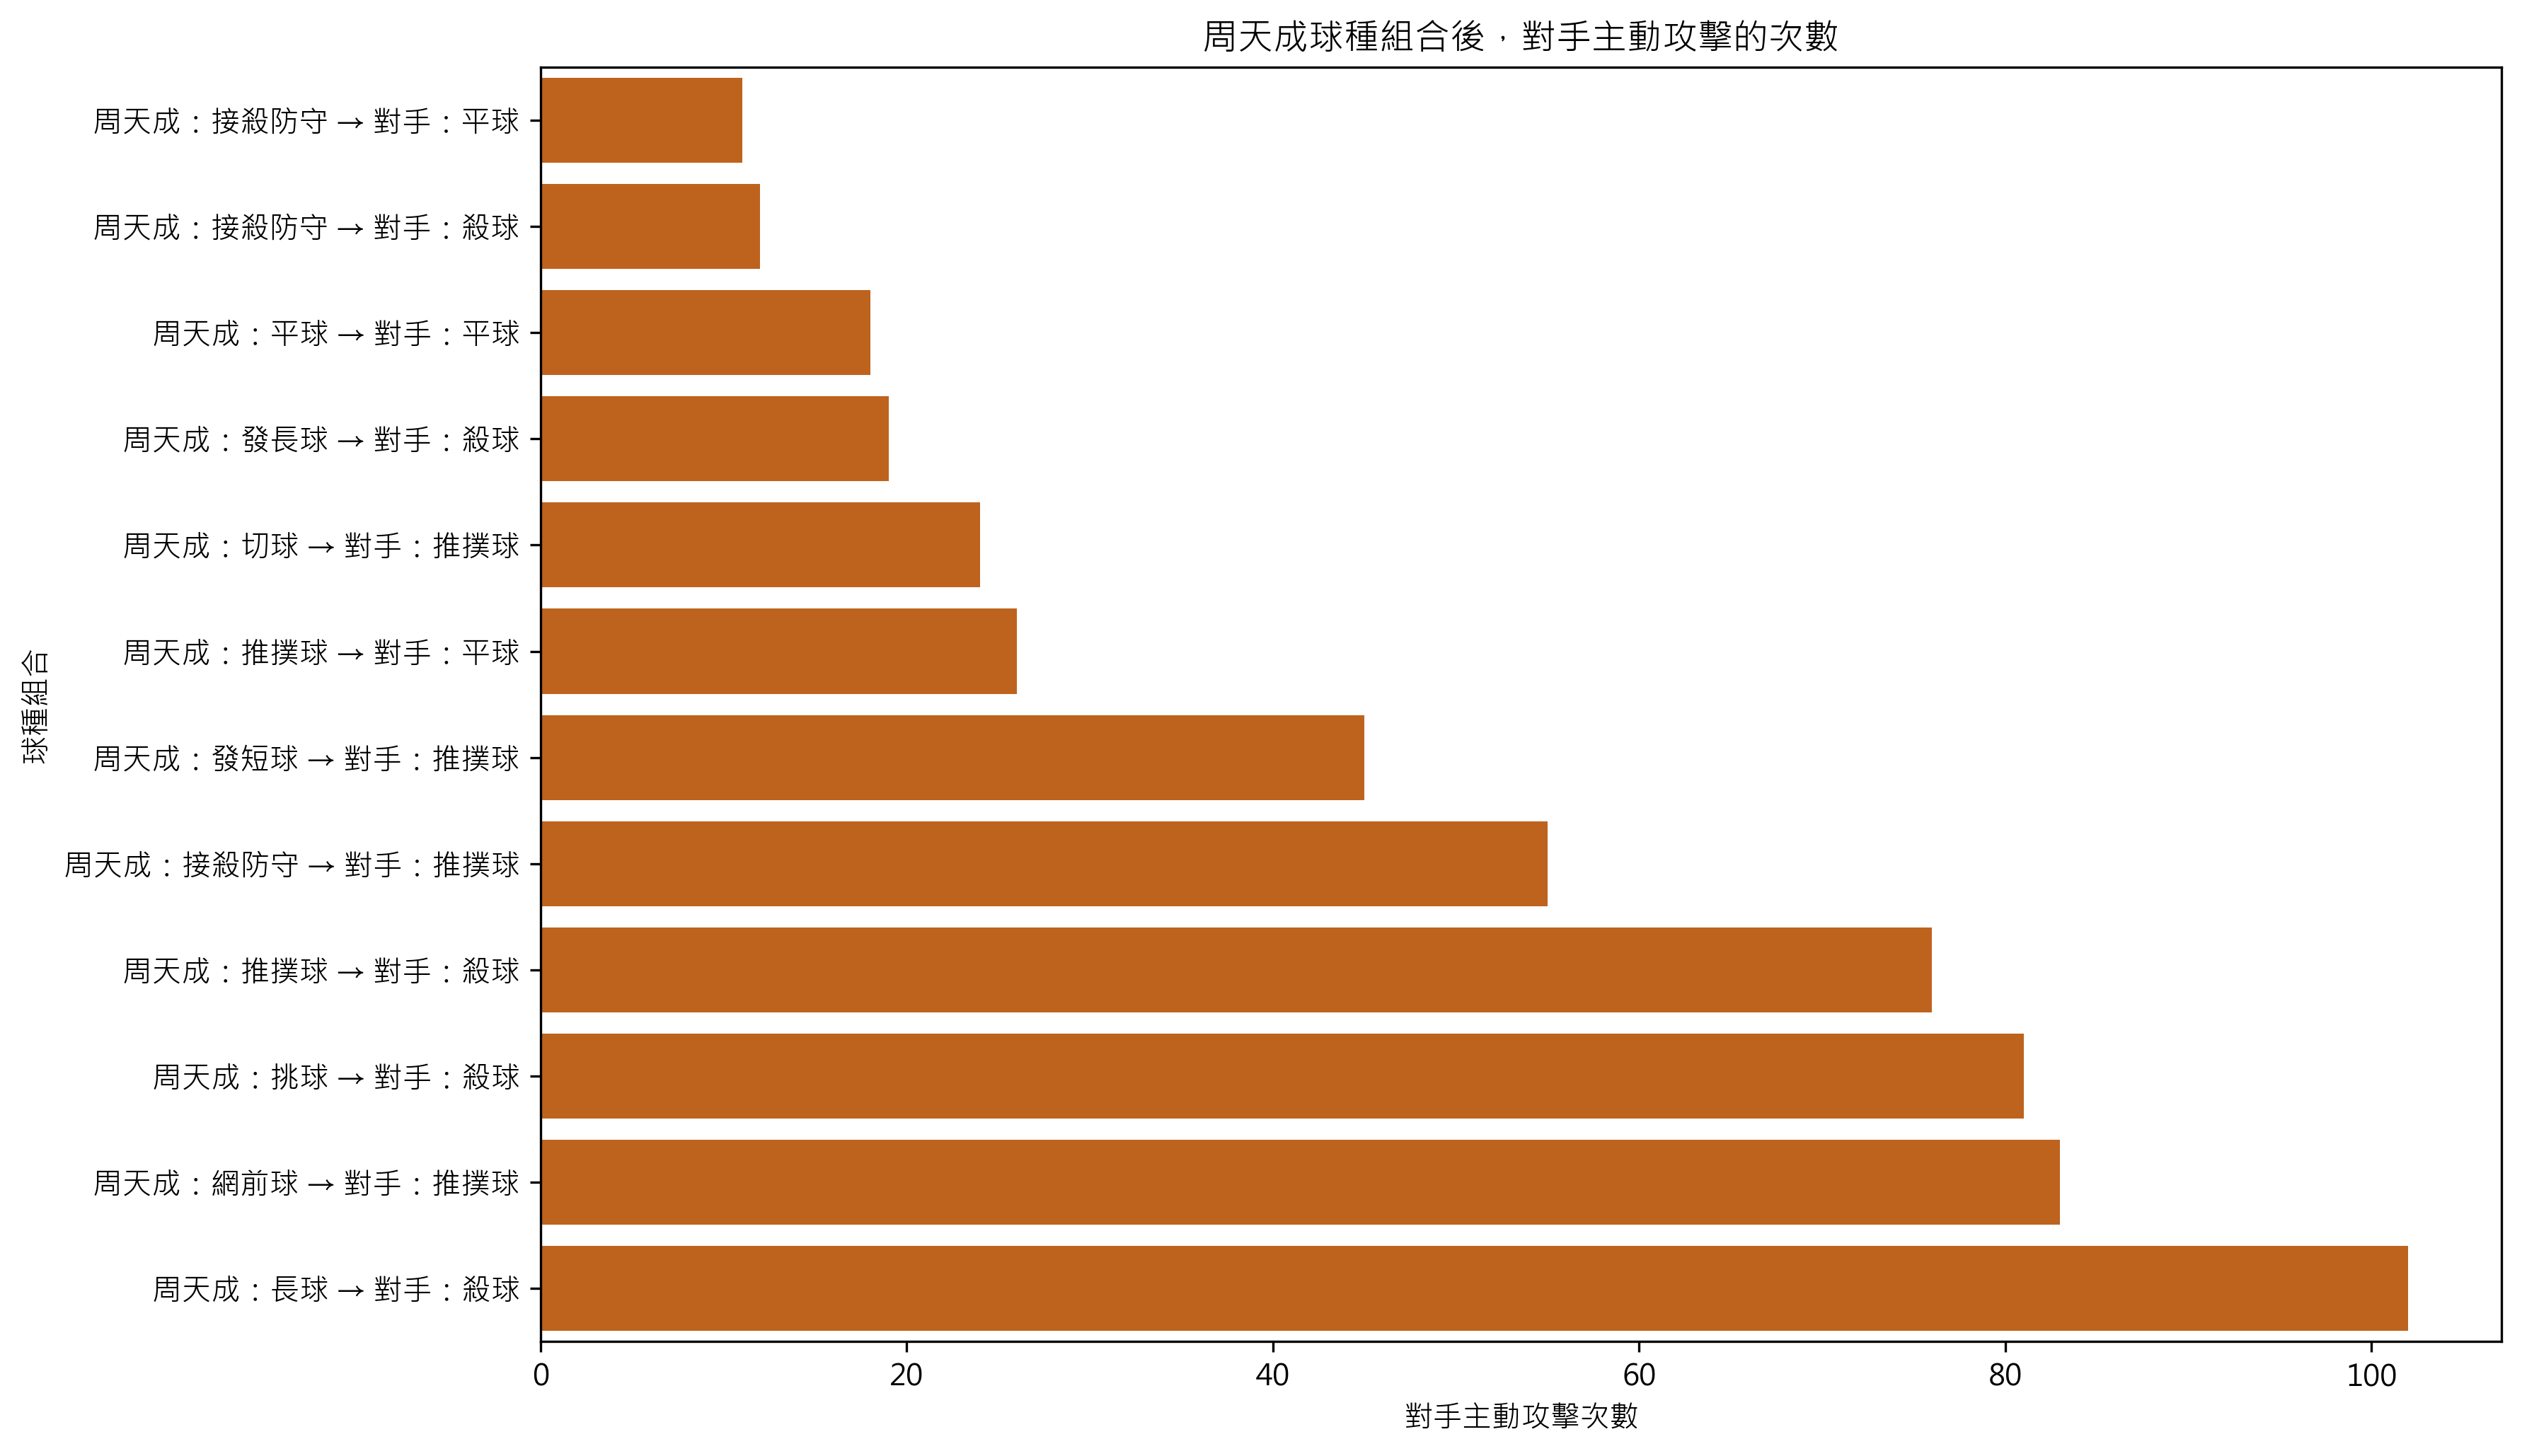

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
    fig = plt.figure(figsize=(10, 6))
else:
    target_player = "CHOU Tien Chen"
    attack_types = {"殺球", "推撲球", "平球"}

    required_cols = [
        "match_id", "set", "rally", "ball_round",
        "player", "opponent", "type"
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
        fig = plt.figure(figsize=(10, 6))
    else:
        work = df.copy()
        work = work.sort_values(
            ["match_id", "set", "rally", "ball_round"]
        ).reset_index(drop=True)

        valid_base = (
            work["match_id"].notna()
            & work["set"].notna()
            & work["rally"].notna()
            & work["ball_round"].notna()
            & work["player"].notna()
            & work["opponent"].notna()
            & work["type"].notna()
        )
        work = work.loc[valid_base].copy()

        group_cols = ["match_id", "set", "rally"]

        work["next_match_id"] = work.groupby(group_cols)["match_id"].shift(-1)
        work["next_set"] = work.groupby(group_cols)["set"].shift(-1)
        work["next_rally"] = work.groupby(group_cols)["rally"].shift(-1)
        work["next_player"] = work.groupby(group_cols)["player"].shift(-1)
        work["next_type"] = work.groupby(group_cols)["type"].shift(-1)

        same_rally_next = (
            work["next_match_id"].eq(work["match_id"])
            & work["next_set"].eq(work["set"])
            & work["next_rally"].eq(work["rally"])
        )

        transition = work.loc[
            same_rally_next
            & work["player"].eq(target_player)
            & work["next_player"].eq(work["opponent"])
            & work["next_type"].notna(),
            ["type", "next_type"]
        ].copy()

        if len(transition) == 0:
            print("找不到周天成後一拍由對手回擊的有效球種組合。")
            fig = plt.figure(figsize=(10, 6))
        else:
            transition["對手是否主動攻擊"] = transition["next_type"].isin(
                attack_types
            )

            combo_stats = (
                transition
                .groupby(["type", "next_type"], as_index=False)
                .agg(
                    使用次數=("next_type", "size"),
                    對手主動攻擊次數=("對手是否主動攻擊", "sum")
                )
            )

            combo_stats["對手主動攻擊率"] = (
                combo_stats["對手主動攻擊次數"]
                / combo_stats["使用次數"]
                * 100
            )

            combo_stats["球種組合"] = (
                "周天成：" + combo_stats["type"]
                + " → 對手：" + combo_stats["next_type"]
            )

            result = (
                combo_stats
                .sort_values(
                    ["對手主動攻擊次數", "使用次數", "對手主動攻擊率"],
                    ascending=[False, False, False]
                )
                .reset_index(drop=True)
            )

            print("主動攻擊球種定義：殺球、推撲球、平球")
            print(
                result[
                    [
                        "球種組合",
                        "使用次數",
                        "對手主動攻擊次數",
                        "對手主動攻擊率"
                    ]
                ]
                .head(15)
                .to_string(
                    index=False,
                    formatters={"對手主動攻擊率": "{:.1f}%".format}
                )
            )

            chart_data = result.head(12).sort_values(
                "對手主動攻擊次數", ascending=True
            )

            fig, ax = plt.subplots(figsize=(12, 7))
            sns.barplot(
                data=chart_data,
                x="對手主動攻擊次數",
                y="球種組合",
                color="#D95F02",
                ax=ax
            )
            ax.set_title("周天成球種組合後，對手主動攻擊的次數")
            ax.set_xlabel("對手主動攻擊次數")
            ax.set_ylabel("球種組合")
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 65
**問題**: 在周天成連續失分3分(含)以上時，他的打擊策略選擇是否變得激進或過於保守？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


統計口徑：以每個 match_id、set、rally 為一個回合；
失分定義：該回合最後一拍 getpoint_player == Kento MOMOTA。
連續失分定義：同一 match_id、set 內連續由 Kento MOMOTA 得分的回合數。
下一拍定義：完整事件串流中該失分回合結束後的下一列，且該列必須是周天成擊球。
激進球種：殺球、推撲球、平球；保守球種：挑球、接殺防守、發短球、發長球；其餘為中性。

符合「連續失分3分以上」的回合後下一拍樣本數：1
其他回合後下一拍基準樣本數：183

策略傾向統計：
       策略 策略傾向  次數  總樣本數  比例(%)
    其他回合後   中性   2   183   1.09
    其他回合後   保守 178   183  97.27
    其他回合後   激進   3   183   1.64
連續失分3分以上後   保守   1     1 100.00

激進比例變化：+0.00 個百分點
保守比例變化：+0.00 個百分點
結論：連續失分後，未觀察到明確的激進或保守轉變。

…（輸出已截斷；notebook 僅保留重點）


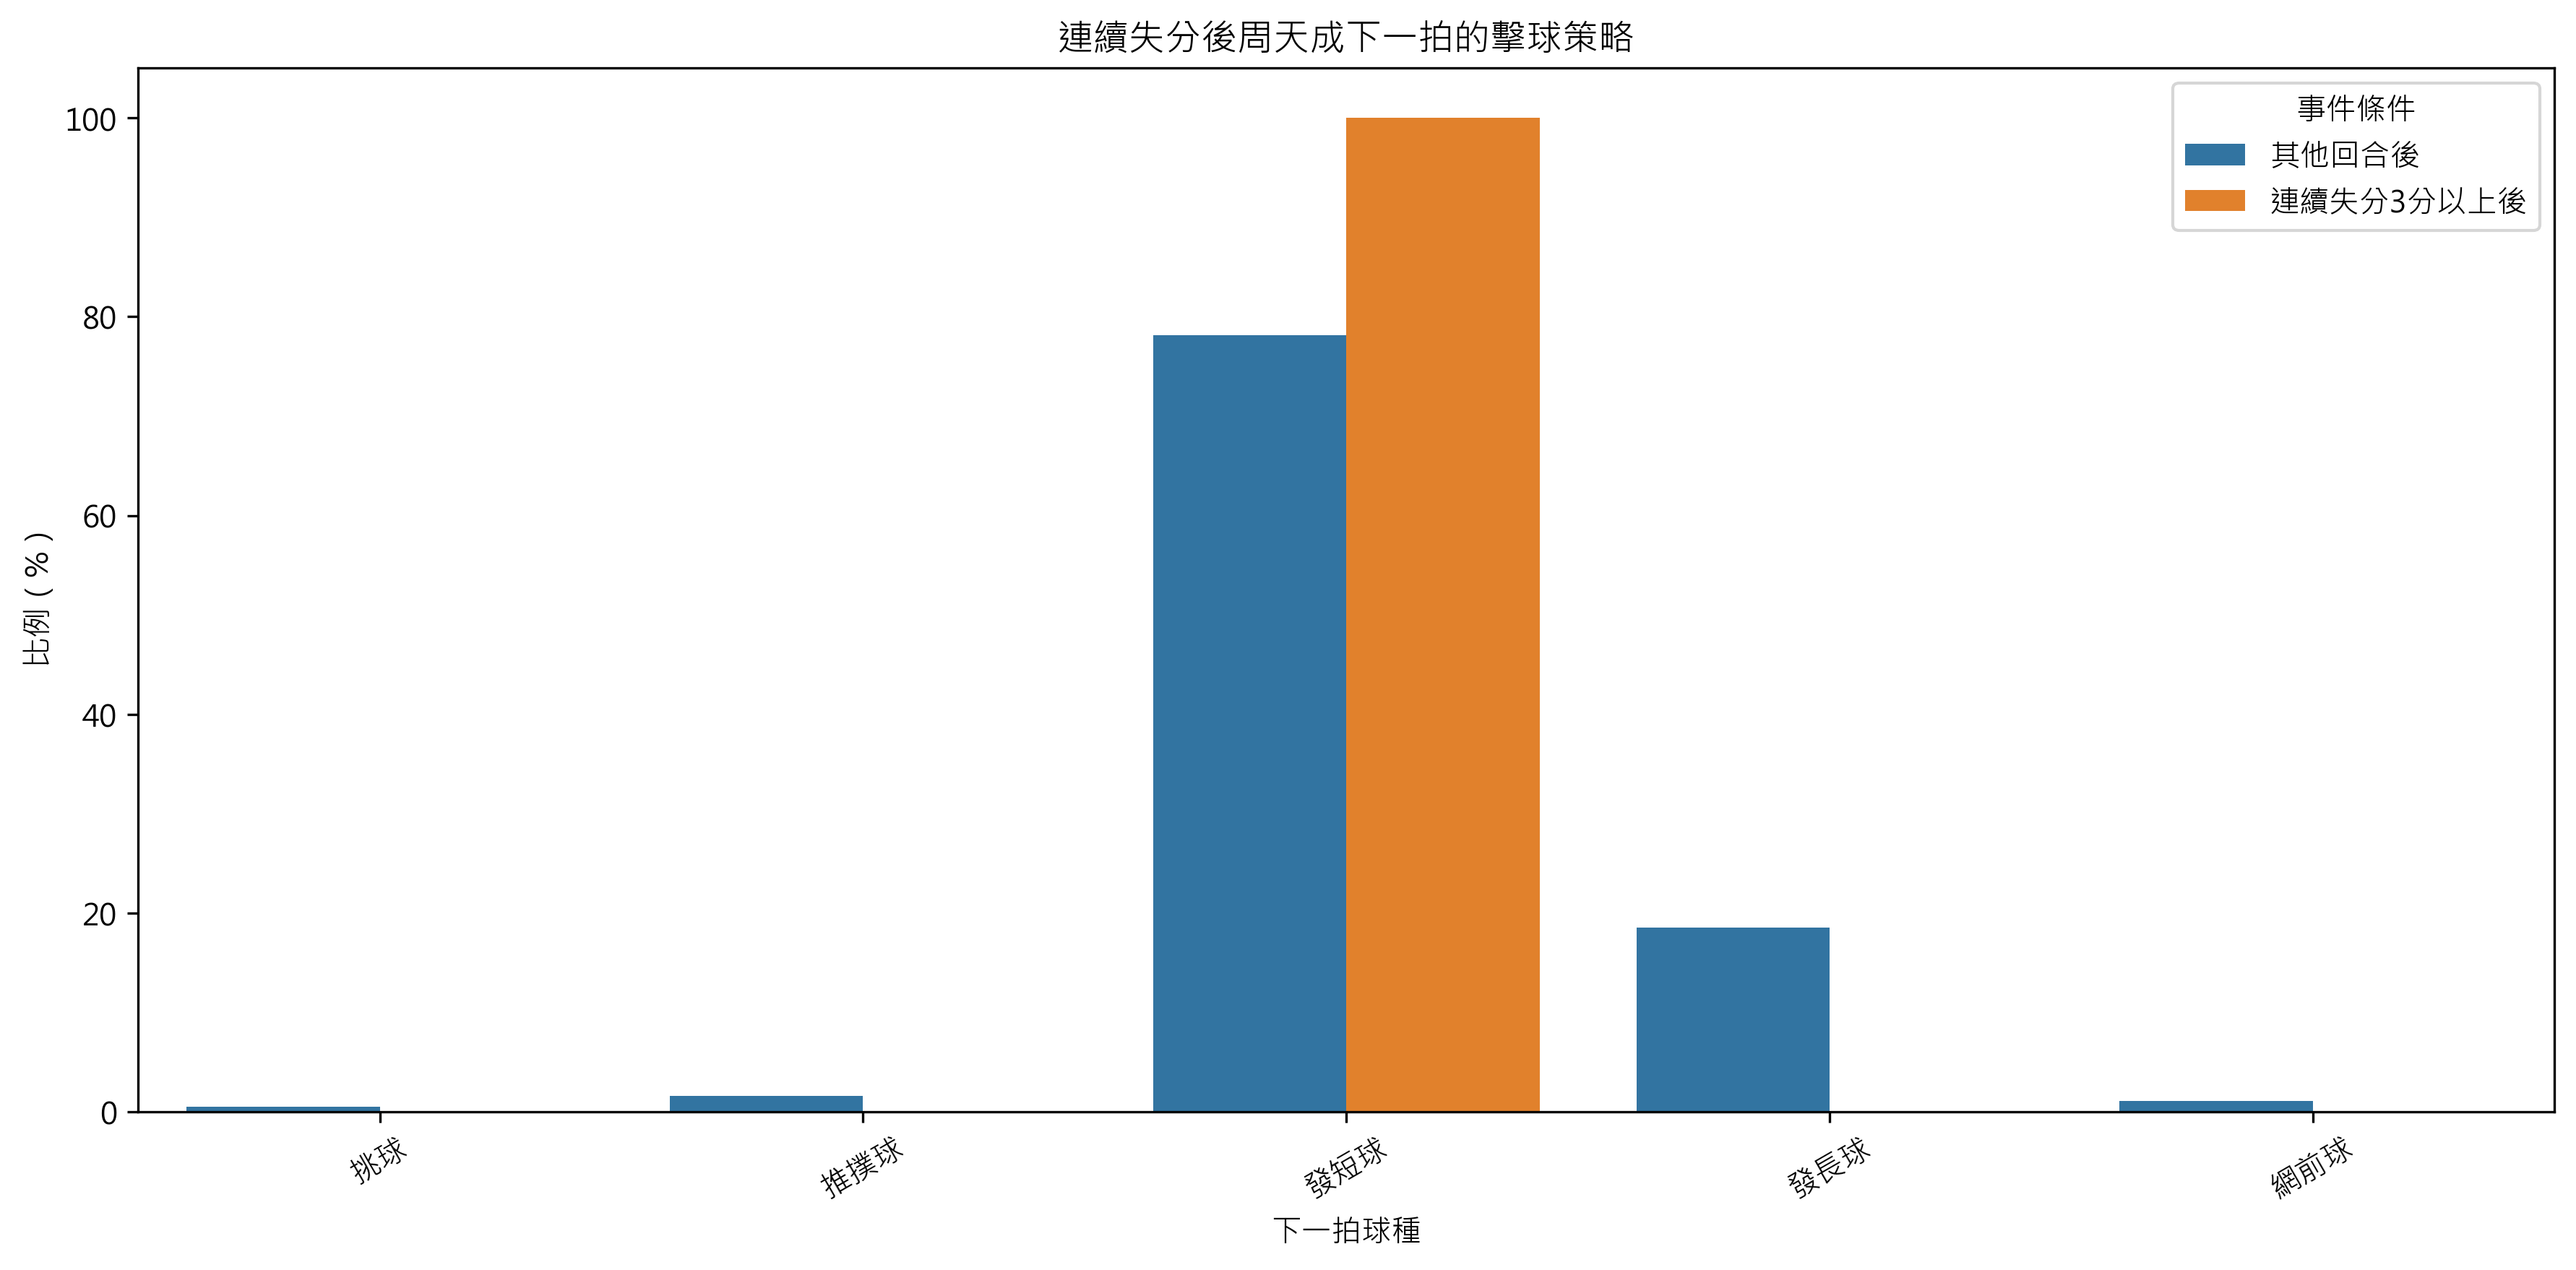

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player',
    'getpoint_player', 'type'
]

if len(df) == 0:
    print('資料為空，無法分析。')
else:
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
    else:
        ctc = 'CHOU Tien Chen'
        opponent = 'Kento MOMOTA'
        keys = ['match_id', 'set', 'rally']

        work = df.copy().sort_values(
            ['match_id', 'set', 'rally', 'ball_round'],
            kind='stable'
        ).reset_index(drop=True)

        work['rally_winner'] = (
            work.groupby(keys, sort=False)['getpoint_player']
            .transform('last')
        )
        work['rally_end'] = (
            work.groupby(keys, sort=False).cumcount()
            == work.groupby(keys, sort=False)['ball_round'].transform('size') - 1
        )

        rally_order = (
            work.loc[work['rally_end'], keys + ['rally_winner']]
            .drop_duplicates(keys)
            .reset_index(drop=True)
        )

        streak_values = []
        previous_match_set = None
        loss_streak = 0

        for row in rally_order.itertuples(index=False):
            current_match_set = (row.match_id, row.set)

            if current_match_set != previous_match_set:
                loss_streak = 0
                previous_match_set = current_match_set

            if row.rally_winner == opponent:
                loss_streak += 1
            else:
                loss_streak = 0

            streak_values.append(loss_streak)

        rally_order['loss_streak_after_rally'] = streak_values

        work = work.merge(
            rally_order[keys + ['loss_streak_after_rally']],
            on=keys,
            how='left',
            validate='many_to_one'
        )

        group_match_set = ['match_id', 'set']
        work['next_player'] = (
            work.groupby(group_match_set, sort=False)['player'].shift(-1)
        )
        work['next_type'] = (
            work.groupby(group_match_set, sort=False)['type'].shift(-1)
        )
        work['next_match_id'] = (
            work.groupby(group_match_set, sort=False)['match_id'].shift(-1)
        )
        work['next_set'] = (
            work.groupby(group_match_set, sort=False)['set'].shift(-1)
        )
        work['next_rally'] = (
            work.groupby(group_match_set, sort=False)['rally'].shift(-1)
        )

        valid_next_shot = (
            work['rally_end']
            & work['next_match_id'].eq(work['match_id'])
            & work['next_set'].eq(work['set'])
            & work['next_rally'].ne(work['rally'])
            & work['next_player'].eq(ctc)
            & work['next_type'].notna()
        )

        events = work.loc[
            valid_next_shot,
            keys + ['rally_winner', 'loss_streak_after_rally', 'next_type']
        ].copy()

        events['策略'] = np.where(
            events['loss_streak_after_rally'].ge(3),
            '連續失分3分以上後',
            '其他回合後'
        )

        target = events.loc[
            events['loss_streak_after_rally'].ge(3)
        ].copy()
        baseline = events.loc[
            ~events['loss_streak_after_rally'].ge(3)
        ].copy()

        aggressive_types = {'殺球', '推撲球', '平球'}
        conservative_types = {'挑球', '接殺防守', '發短球', '發長球'}

        def classify_strategy(shot_type):
            if shot_type in aggressive_types:
                return '激進'
            if shot_type in conservative_types:
                return '保守'
            return '中性'

        events['策略傾向'] = events['next_type'].map(classify_strategy)

        summary = (
            events.groupby(['策略', '策略傾向'], dropna=False)
            .size()
            .rename('次數')
            .reset_index()
        )

        totals = (
            events.groupby('策略')
            .size()
            .rename('總樣本數')
            .reset_index()
        )

        summary = summary.merge(totals, on='策略', how='left')
        summary['比例(%)'] = summary['次數'] / summary['總樣本數'] * 100

        type_summary = (
            events.groupby(['策略', 'next_type'])
            .size()
            .rename('次數')
            .reset_index()
        )
        type_summary = type_summary.merge(totals, on='策略', how='left')
        type_summary['比例(%)'] = (
            type_summary['次數'] / type_summary['總樣本數'] * 100
        )

        print('統計口徑：以每個 match_id、set、rally 為一個回合；')
        print('失分定義：該回合最後一拍 getpoint_player == Kento MOMOTA。')
        print('連續失分定義：同一 match_id、set 內連續由 Kento MOMOTA 得分的回合數。')
        print('下一拍定義：完整事件串流中該失分回合結束後的下一列，且該列必須是周天成擊球。')
        print('激進球種：殺球、推撲球、平球；保守球種：挑球、接殺防守、發短球、發長球；其餘為中性。')
        print()

        print(f'符合「連續失分3分以上」的回合後下一拍樣本數：{len(target)}')
        print(f'其他回合後下一拍基準樣本數：{len(baseline)}')
        print()

        if len(summary) > 0:
            print('策略傾向統計：')
            print(
                summary[
                    ['策略', '策略傾向', '次數', '總樣本數', '比例(%)']
                ].to_string(index=False, formatters={'比例(%)': '{:.2f}'.format})
            )
            print()

            pivot = (
                summary.pivot(
                    index='策略',
                    columns='策略傾向',
                    values='比例(%)'
                )
                .fillna(0)
            )

            aggressive_after = pivot.get('連續失分3分以上後', pd.Series(dtype=float)).get('激進', 0)
            aggressive_baseline = pivot.get('其他回合後', pd.Series(dtype=float)).get('激進', 0)
            conservative_after = pivot.get('連續失分3分以上後', pd.Series(dtype=float)).get('保守', 0)
            conservative_baseline = pivot.get('其他回合後', pd.Series(dtype=float)).get('保守', 0)

            aggressive_diff = aggressive_after - aggressive_baseline
            conservative_diff = conservative_after - conservative_baseline

            if aggressive_diff > 0 and aggressive_diff >= abs(conservative_diff):
                conclusion = '連續失分後，周天成的下一拍整體呈現較激進。'
            elif conservative_diff > 0 and conservative_diff > aggressive_diff:
                conclusion = '連續失分後，周天成的下一拍整體呈現較保守。'
            else:
                conclusion = '連續失分後，未觀察到明確的激進或保守轉變。'

            print(f'激進比例變化：{aggressive_diff:+.2f} 個百分點')
            print(f'保守比例變化：{conservative_diff:+.2f} 個百分點')
            print(f'結論：{conclusion}')
            print()

            print('下一拍實際球種分布：')
            print(
                type_summary[
                    ['策略', 'next_type', '次數', '總樣本數', '比例(%)']
                ].sort_values(['策略', '次數'], ascending=[True, False])
                .to_string(index=False, formatters={'比例(%)': '{:.2f}'.format})
            )

            plot_data = type_summary.copy()
            plot_data['next_type'] = plot_data['next_type'].astype(str)

            sns.barplot(
                data=plot_data,
                x='next_type',
                y='比例(%)',
                hue='策略',
                ax=ax
            )
            ax.set_title('連續失分後周天成下一拍的擊球策略')
            ax.set_xlabel('下一拍球種')
            ax.set_ylabel('比例（%）')
            ax.legend(title='事件條件')
            ax.tick_params(axis='x', rotation=30)
        else:
            print('沒有足夠的有效下一拍資料可供分析。')
            ax.set_title('沒有足夠的有效下一拍資料')
            ax.set_xlabel('')
            ax.set_ylabel('')

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 66
**問題**: 分析周天成在「領先 3 分以上」時的擊球策略是否更保守？請統計球種比例。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


分析口徑：以每一拍當下比分計算周天成分差；分差 >= 3 視為「領先3分以上」。
領先3分以上擊球數：445
未領先3分以上擊球數：2164

各球種擊球比例（%）與領先時相對變化（百分點）：
狀態    未領先3分以上  領先3分以上  比例變化(百分點)
type                            
網前球     23.24   17.75      -5.49
長球       9.57   15.28       5.72
挑球       9.75   13.26       3.51
切球       7.07   13.03       5.96
接殺防守    13.82   11.69      -2.13
發短球      4.99    8.76       3.77
推撲球     13.82    7.87      -5.95
殺球      12.25    7.64      -4.61
平球       4.16    3.60      -0.56
發長球      1.34    1.12      -0.22


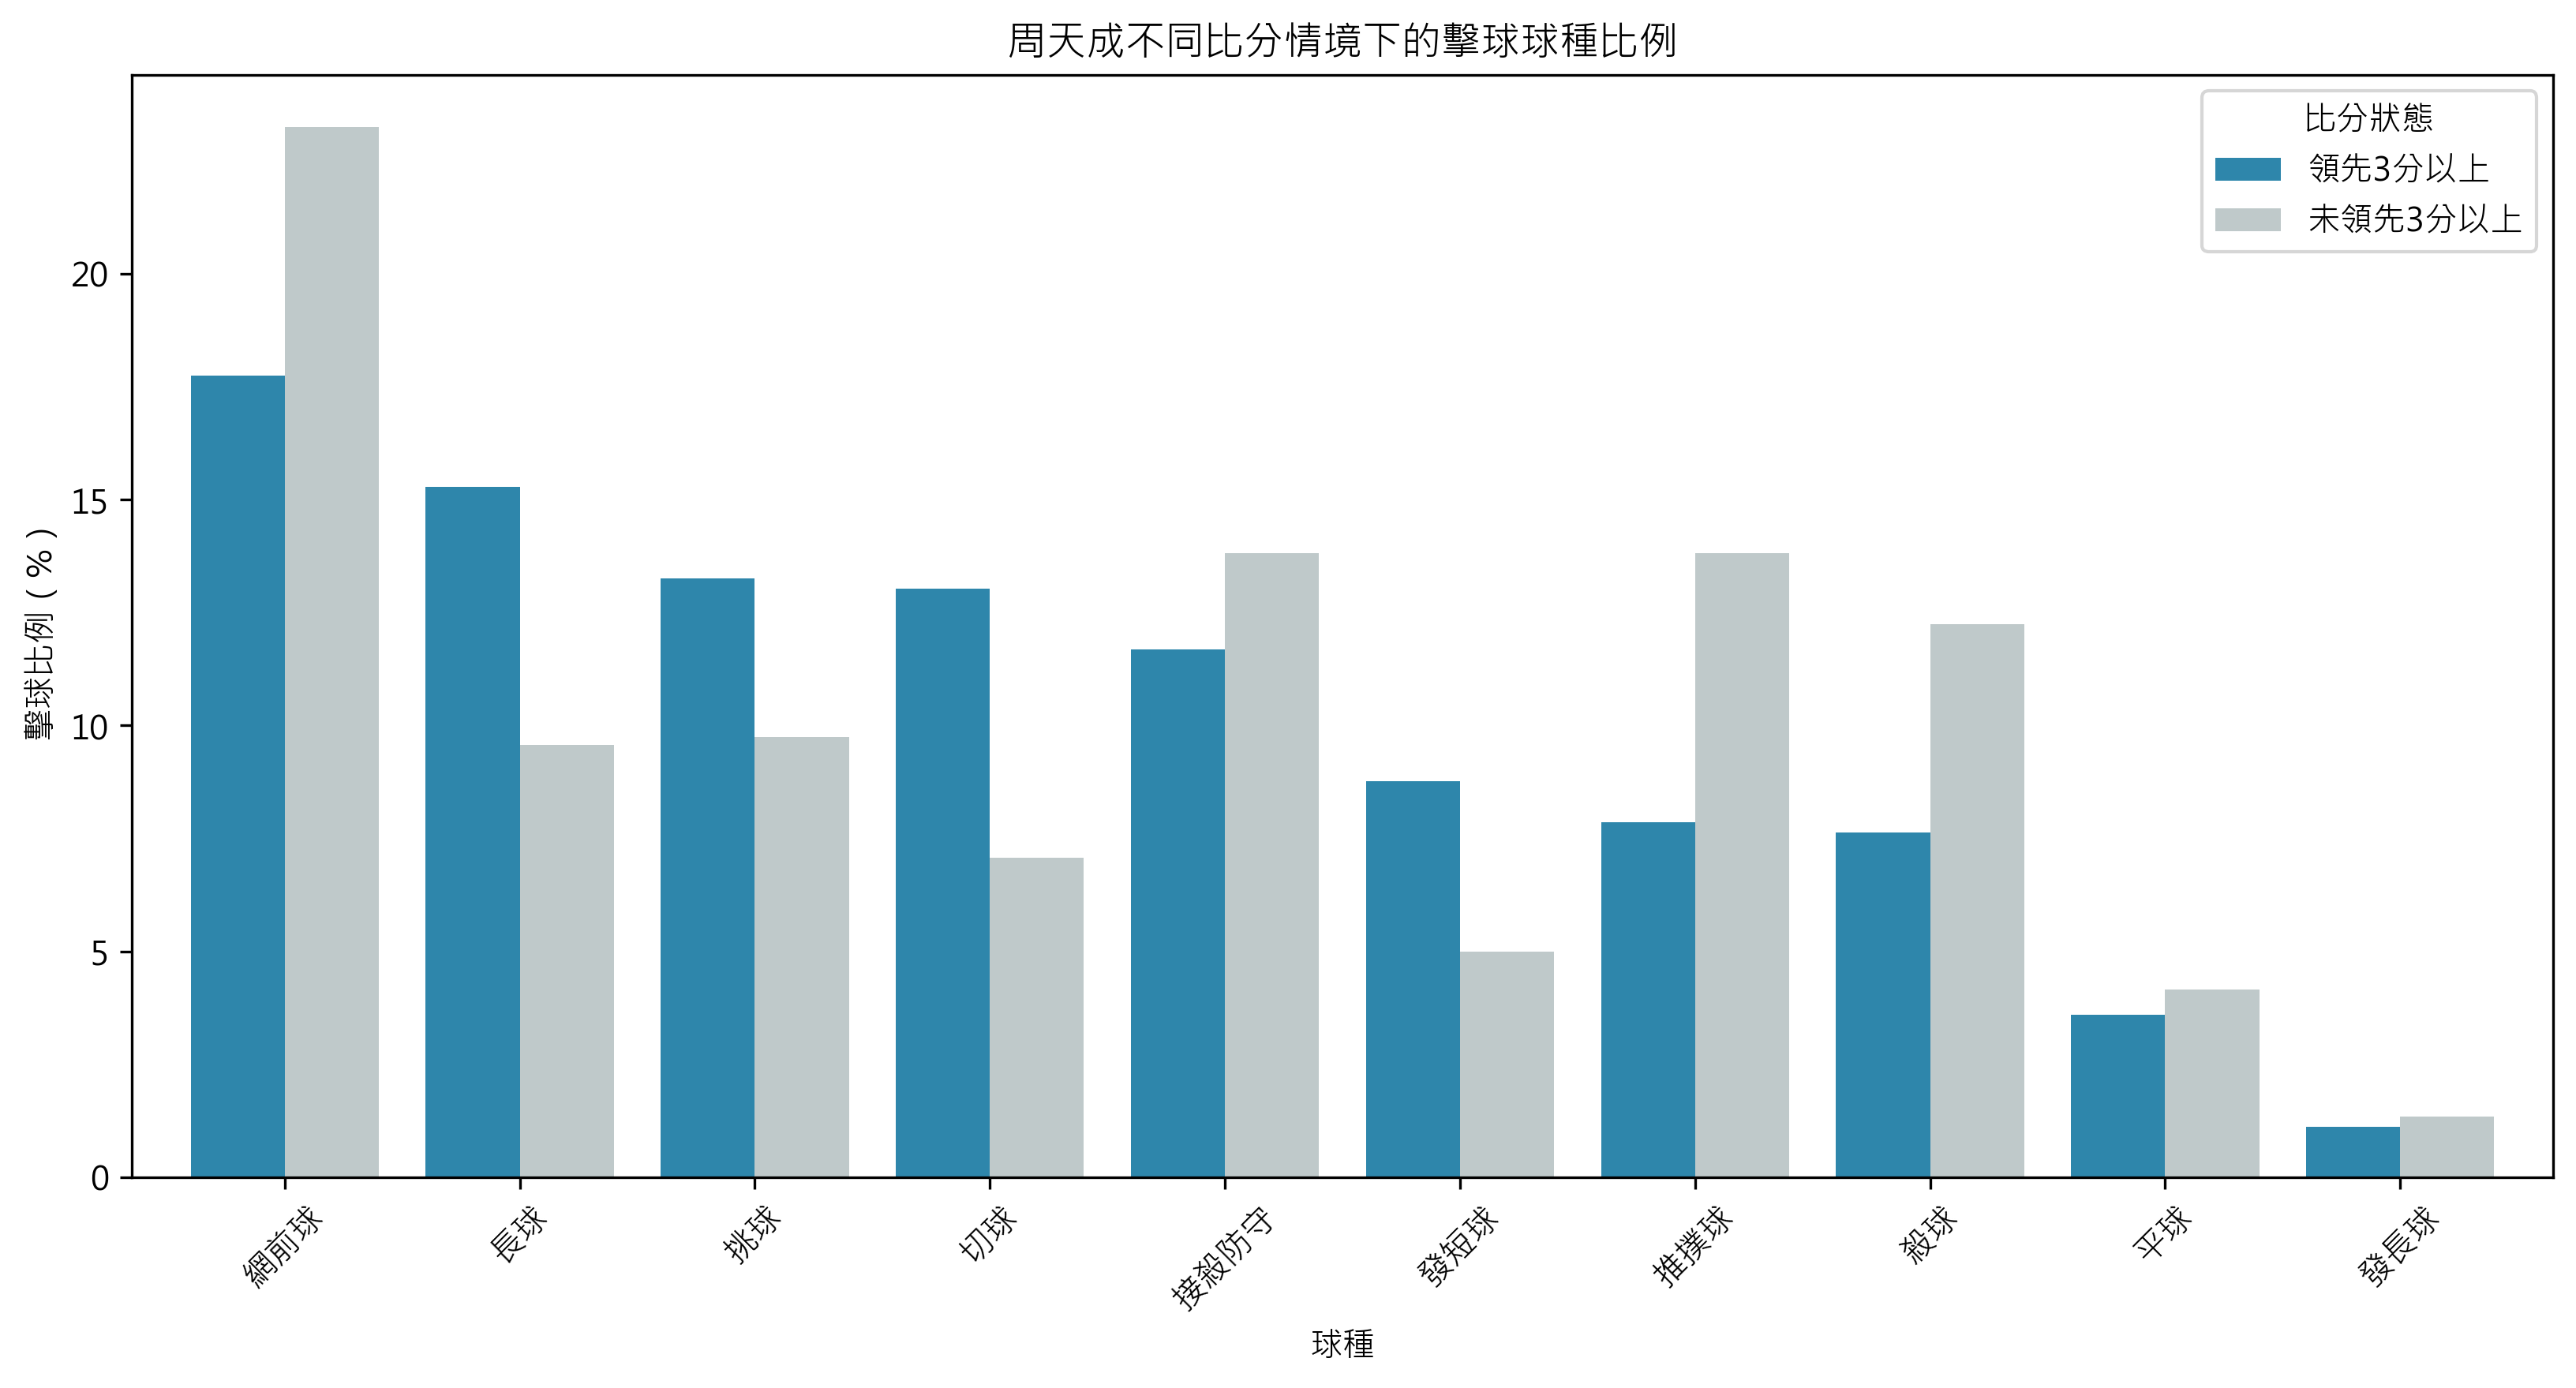

In [ ]:
required_cols = [
    'player', 'type', 'Kento MOMOTA_score', 'CHOU Tien Chen_score'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print('資料為空，無法分析。')
elif missing_cols:
    print(f'缺少必要欄位：{missing_cols}')
else:
    chou = df.loc[
        (df['player'] == 'CHOU Tien Chen'),
        required_cols
    ].copy()

    chou = chou.dropna(
        subset=['type', 'Kento MOMOTA_score', 'CHOU Tien Chen_score']
    )

    if len(chou) == 0:
        print('沒有足夠的周天成擊球資料可分析。')
    else:
        chou['分差'] = (
            chou['CHOU Tien Chen_score'] -
            chou['Kento MOMOTA_score']
        )
        chou['狀態'] = chou['分差'].ge(3).map({
            True: '領先3分以上',
            False: '未領先3分以上'
        })

        summary = (
            chou.groupby(['狀態', 'type'], observed=False)
            .size()
            .rename('擊球數')
            .reset_index()
        )

        summary['總擊球數'] = summary.groupby('狀態')['擊球數'].transform('sum')
        summary['比例'] = summary['擊球數'] / summary['總擊球數']
        summary['比例(%)'] = summary['比例'] * 100

        pivot_ratio = (
            summary.pivot(index='type', columns='狀態', values='比例(%)')
            .fillna(0)
        )

        for col in ['領先3分以上', '未領先3分以上']:
            if col not in pivot_ratio.columns:
                pivot_ratio[col] = 0.0

        pivot_ratio['比例變化(百分點)'] = (
            pivot_ratio['領先3分以上'] -
            pivot_ratio['未領先3分以上']
        )

        order = (
            pivot_ratio['領先3分以上']
            .sort_values(ascending=False)
            .index
        )
        pivot_ratio = pivot_ratio.loc[order]

        state_counts = chou['狀態'].value_counts()
        print('分析口徑：以每一拍當下比分計算周天成分差；分差 >= 3 視為「領先3分以上」。')
        print(f'領先3分以上擊球數：{state_counts.get("領先3分以上", 0)}')
        print(f'未領先3分以上擊球數：{state_counts.get("未領先3分以上", 0)}')
        print('\n各球種擊球比例（%）與領先時相對變化（百分點）：')
        print(pivot_ratio.round(2).to_string())

        if (
            state_counts.get('領先3分以上', 0) > 0 and
            state_counts.get('未領先3分以上', 0) > 0
        ):
            fig, ax = plt.subplots(figsize=(11, 6))
            plot_data = pivot_ratio[
                ['領先3分以上', '未領先3分以上']
            ]
            plot_data.plot(
                kind='bar',
                ax=ax,
                color=['#2E86AB', '#BFC9CA'],
                width=0.8
            )
            ax.set_title('周天成不同比分情境下的擊球球種比例')
            ax.set_xlabel('球種')
            ax.set_ylabel('擊球比例（%）')
            ax.legend(title='比分狀態')
            ax.tick_params(axis='x', rotation=45)
            plt.tight_layout()
        else:
            fig = None
            print('\n其中一種比分狀態沒有有效擊球資料，無法進行比例比較。')


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 67
**問題**: 當分數差距逐漸縮小時（領先轉膠著），周天成殺球成功率是否下降？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


統計口徑：
1. 統計單位為周天成每一拍「殺球」。
2. 分數差距 = 周天成分數 − 對手分數。
3. 僅納入周天成領先或平分時的殺球，排除落後情境。
4. 殺球成功採 Active Win：getpoint_player == player。
5. 成功率 = 殺球 Active Win 數 ÷ 該情境殺球拍數。

周天成在不同領先差距下的殺球成功率：
  領先情境  領先差距中位數  殺球拍數  Active_Win數  殺球成功率
領先4分以上      6.0     9            5  55.56
領先2至3分      2.0    10            7  70.00
  領先1分      1.0    13           10  76.92
膠著（平分）      0.0    11            9  81.82

結論：在本資料中，從大幅領先轉為膠著時，周天成殺球成功率上升 26.26 個百分點。


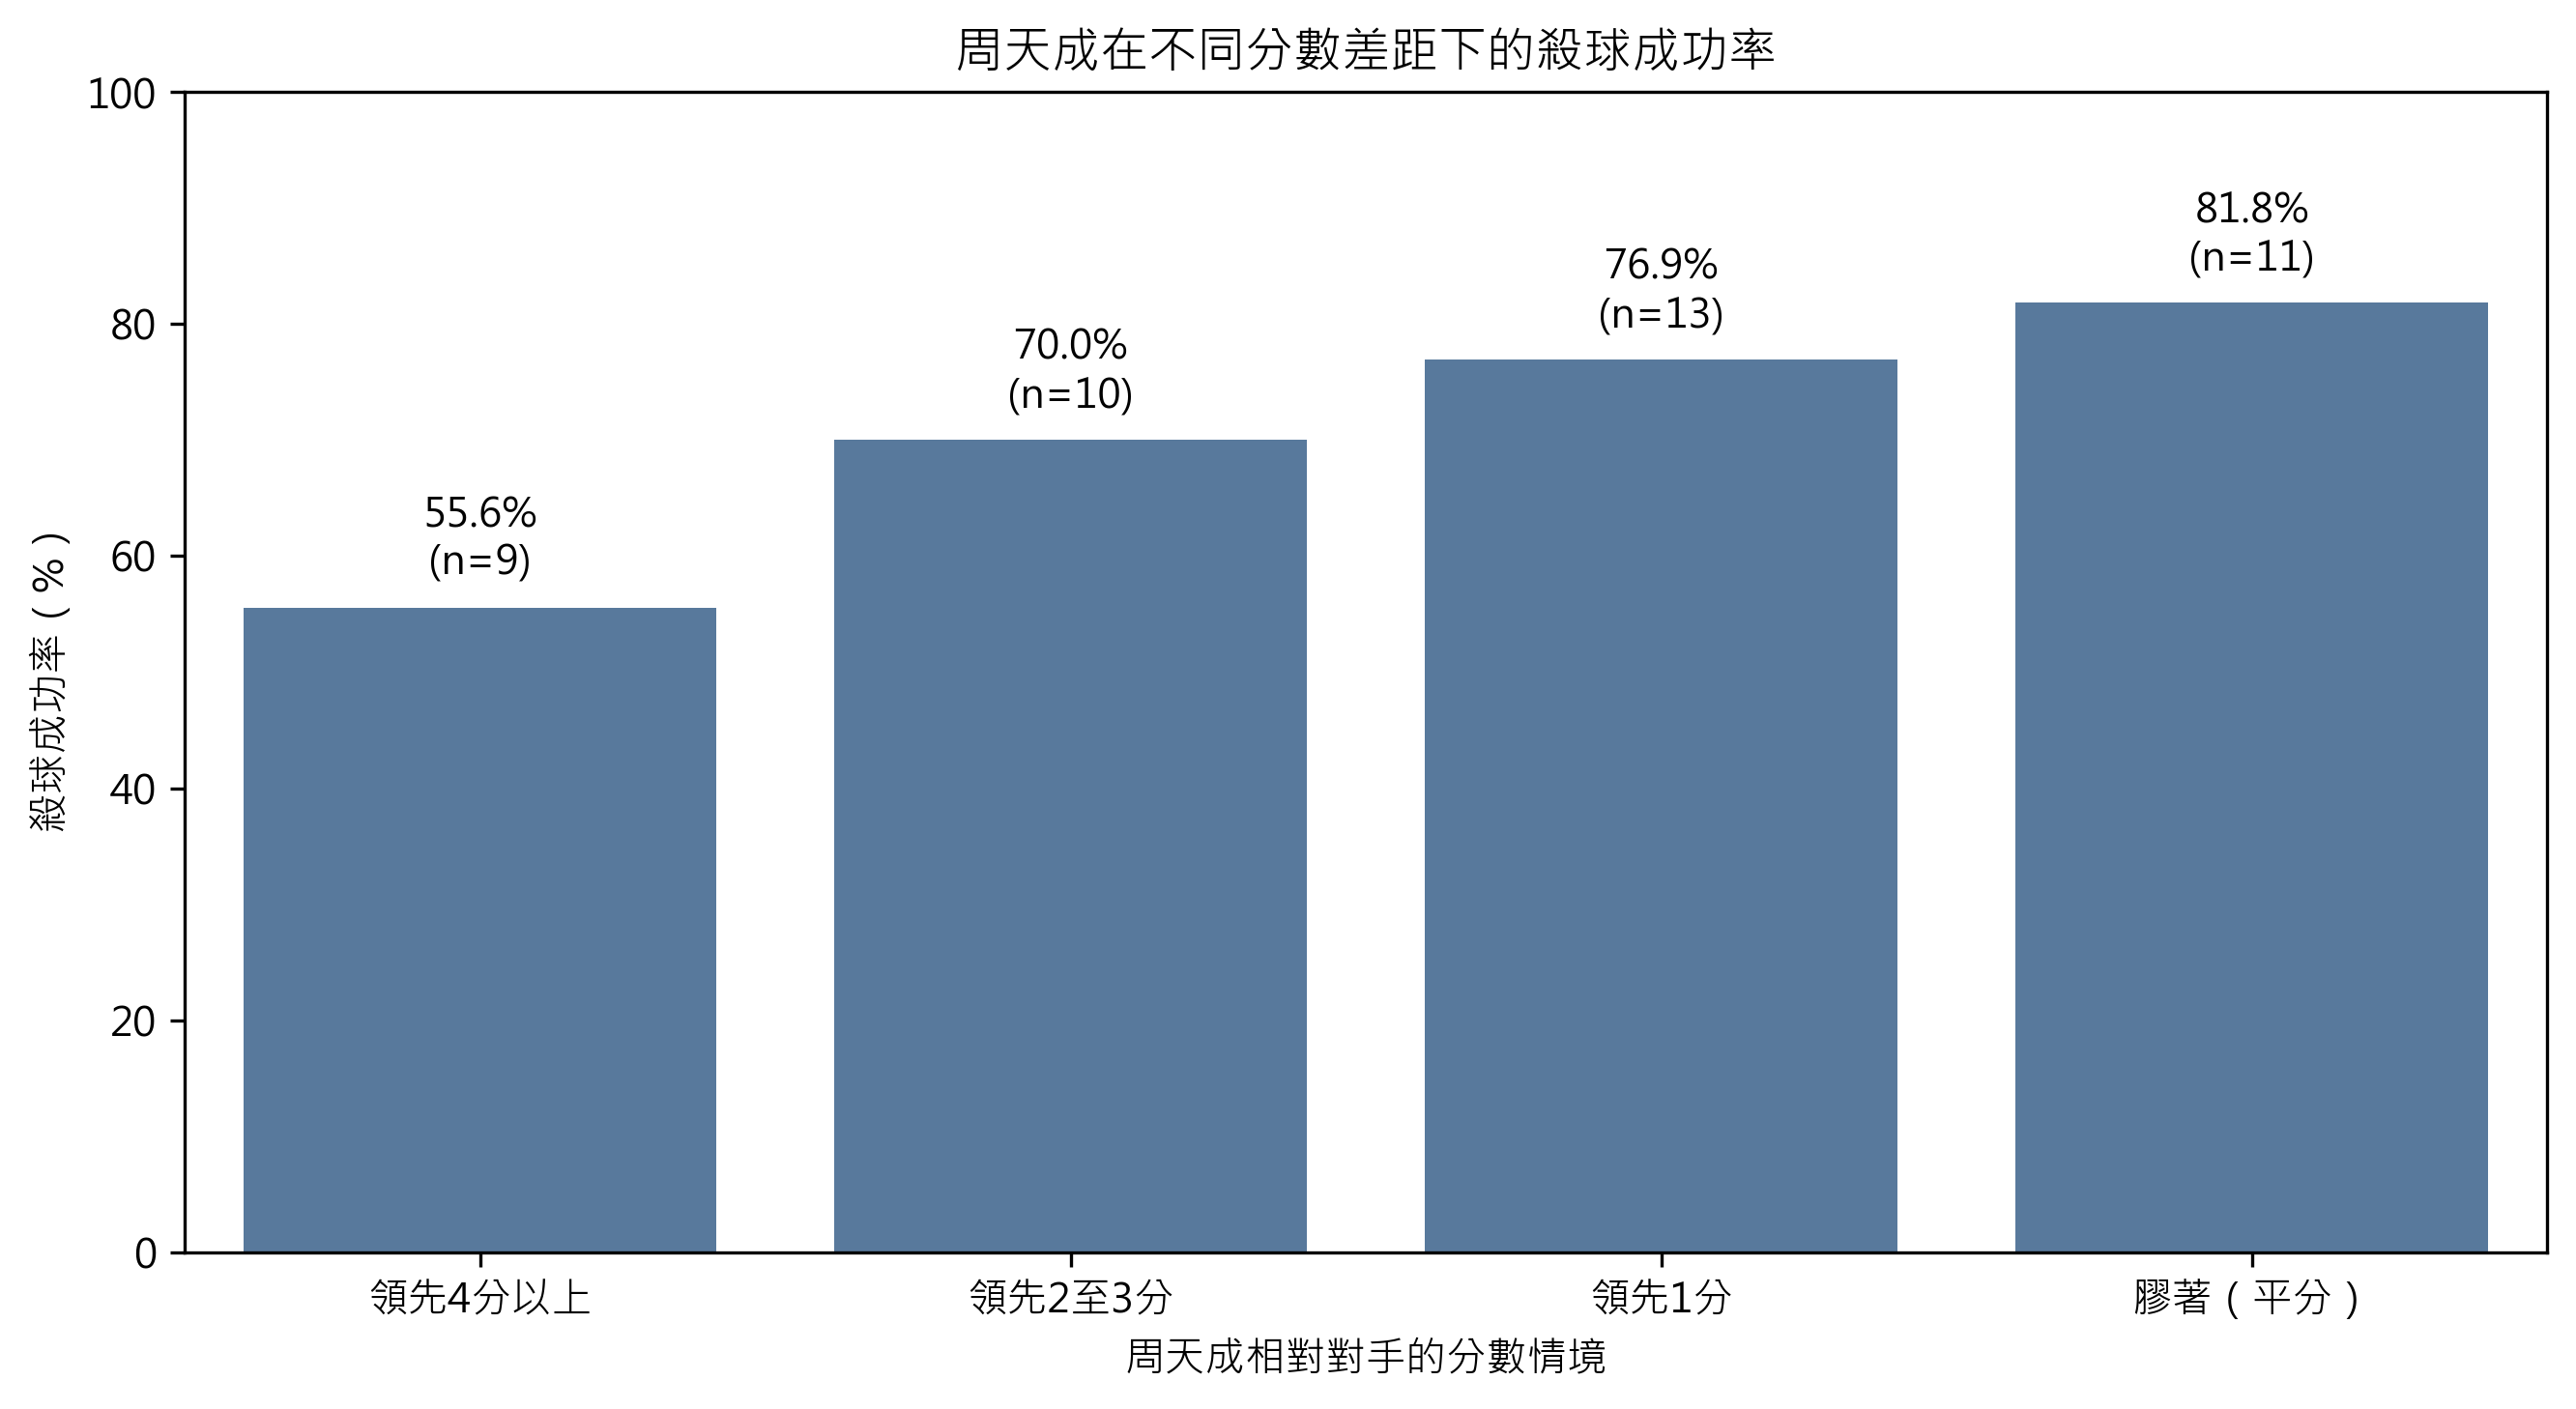

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    required_cols = [
        'match_id', 'set', 'rally', 'ball_round', 'player', 'type',
        'getpoint_player', 'Kento MOMOTA_score', 'CHOU Tien Chen_score'
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        player_name = 'CHOU Tien Chen'
        opponent_name = 'Kento MOMOTA'

        analysis_df = df.copy()
        analysis_df = analysis_df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).reset_index(drop=True)

        numeric_cols = [
            'match_id', 'set', 'rally', 'ball_round',
            f'{player_name}_score', f'{opponent_name}_score'
        ]
        for col in numeric_cols:
            analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

        analysis_df['score_gap'] = (
            analysis_df[f'{player_name}_score']
            - analysis_df[f'{opponent_name}_score']
        )

        smash_df = analysis_df[
            (analysis_df['player'] == player_name) &
            (analysis_df['type'] == '殺球') &
            analysis_df['score_gap'].notna() &
            (analysis_df['getpoint_player'].notna())
        ].copy()

        if len(smash_df) == 0:
            print("沒有符合條件的周天成殺球資料，無法分析。")
        else:
            # 只分析周天成領先時，觀察領先差距縮小至膠著的情況
            smash_df = smash_df[smash_df['score_gap'] >= 0].copy()

            if len(smash_df) == 0:
                print("沒有周天成領先或平分時的殺球資料，無法分析。")
            else:
                smash_df['active_win'] = (
                    smash_df['getpoint_player'] == smash_df['player']
                )

                smash_df['領先情境'] = pd.cut(
                    smash_df['score_gap'],
                    bins=[-0.01, 0.5, 1.5, 3.5, float('inf')],
                    labels=['膠著（平分）', '領先1分', '領先2至3分', '領先4分以上'],
                    right=True
                )

                category_order = [
                    '領先4分以上',
                    '領先2至3分',
                    '領先1分',
                    '膠著（平分）'
                ]

                result = (
                    smash_df.groupby('領先情境', observed=False)
                    .agg(
                        殺球拍數=('active_win', 'size'),
                        Active_Win數=('active_win', 'sum')
                    )
                    .reindex(category_order)
                    .reset_index()
                )

                result['殺球成功率'] = (
                    result['Active_Win數'] / result['殺球拍數'] * 100
                ).round(2)

                result['領先差距中位數'] = (
                    smash_df.groupby('領先情境', observed=False)['score_gap']
                    .median()
                    .reindex(category_order)
                    .values
                )

                print("統計口徑：")
                print("1. 統計單位為周天成每一拍「殺球」。")
                print("2. 分數差距 = 周天成分數 − 對手分數。")
                print("3. 僅納入周天成領先或平分時的殺球，排除落後情境。")
                print("4. 殺球成功採 Active Win：getpoint_player == player。")
                print("5. 成功率 = 殺球 Active Win 數 ÷ 該情境殺球拍數。")
                print("\n周天成在不同領先差距下的殺球成功率：")
                print(
                    result[
                        [
                            '領先情境',
                            '領先差距中位數',
                            '殺球拍數',
                            'Active_Win數',
                            '殺球成功率'
                        ]
                    ].to_string(index=False)
                )

                valid_result = result[result['殺球拍數'] > 0].copy()

                if len(valid_result) >= 2:
                    widest_lead_rate = valid_result.iloc[0]['殺球成功率']
                    closest_rate = valid_result.iloc[-1]['殺球成功率']
                    rate_change = round(closest_rate - widest_lead_rate, 2)

                    if rate_change < 0:
                        conclusion = (
                            f"在本資料中，從大幅領先轉為膠著時，"
                            f"周天成殺球成功率下降 {abs(rate_change):.2f} 個百分點。"
                        )
                    elif rate_change > 0:
                        conclusion = (
                            f"在本資料中，從大幅領先轉為膠著時，"
                            f"周天成殺球成功率上升 {rate_change:.2f} 個百分點。"
                        )
                    else:
                        conclusion = (
                            "在本資料中，從大幅領先轉為膠著時，"
                            "周天成殺球成功率沒有變化。"
                        )

                    print(f"\n結論：{conclusion}")
                else:
                    print("\n可比較的領先情境不足，無法判斷成功率是否下降。")

                if len(valid_result) > 0:
                    fig, ax = plt.subplots(figsize=(9, 5))
                    plot_result = valid_result.copy()

                    sns.barplot(
                        data=plot_result,
                        x='領先情境',
                        y='殺球成功率',
                        order=category_order,
                        color='#4C78A8',
                        ax=ax
                    )

                    ax.set_title('周天成在不同分數差距下的殺球成功率')
                    ax.set_xlabel('周天成相對對手的分數情境')
                    ax.set_ylabel('殺球成功率（%）')
                    ax.set_ylim(0, 100)

                    for index, row in plot_result.iterrows():
                        category_index = category_order.index(row['領先情境'])
                        ax.text(
                            category_index,
                            row['殺球成功率'] + 2,
                            f"{row['殺球成功率']:.1f}%\n(n={int(row['殺球拍數'])})",
                            ha='center',
                            va='bottom'
                        )

                    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 71
**問題**: 分析周天成在自己領先時與落後時，網前球的使用比例差異。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）


統計口徑：以單拍為單位，只納入擊球者為周天成的球；平手狀態不納入。
網前球使用比例 = 網前球次數 ÷ 周天成該比賽情勢下的總擊球數。
前中後場分析限制：資料 Schema 未提供 area 或 zone 欄位，無法依正式場地網格定義拆分前、中、後場。

網前球使用比例統計：
 比賽情勢  總擊球數  網前球次數 網前球使用比例
周天成領先   947    203  21.44%
周天成落後  1359    316  23.25%

領先與落後的使用比例差異：-1.82 個百分點（領先 - 落後）


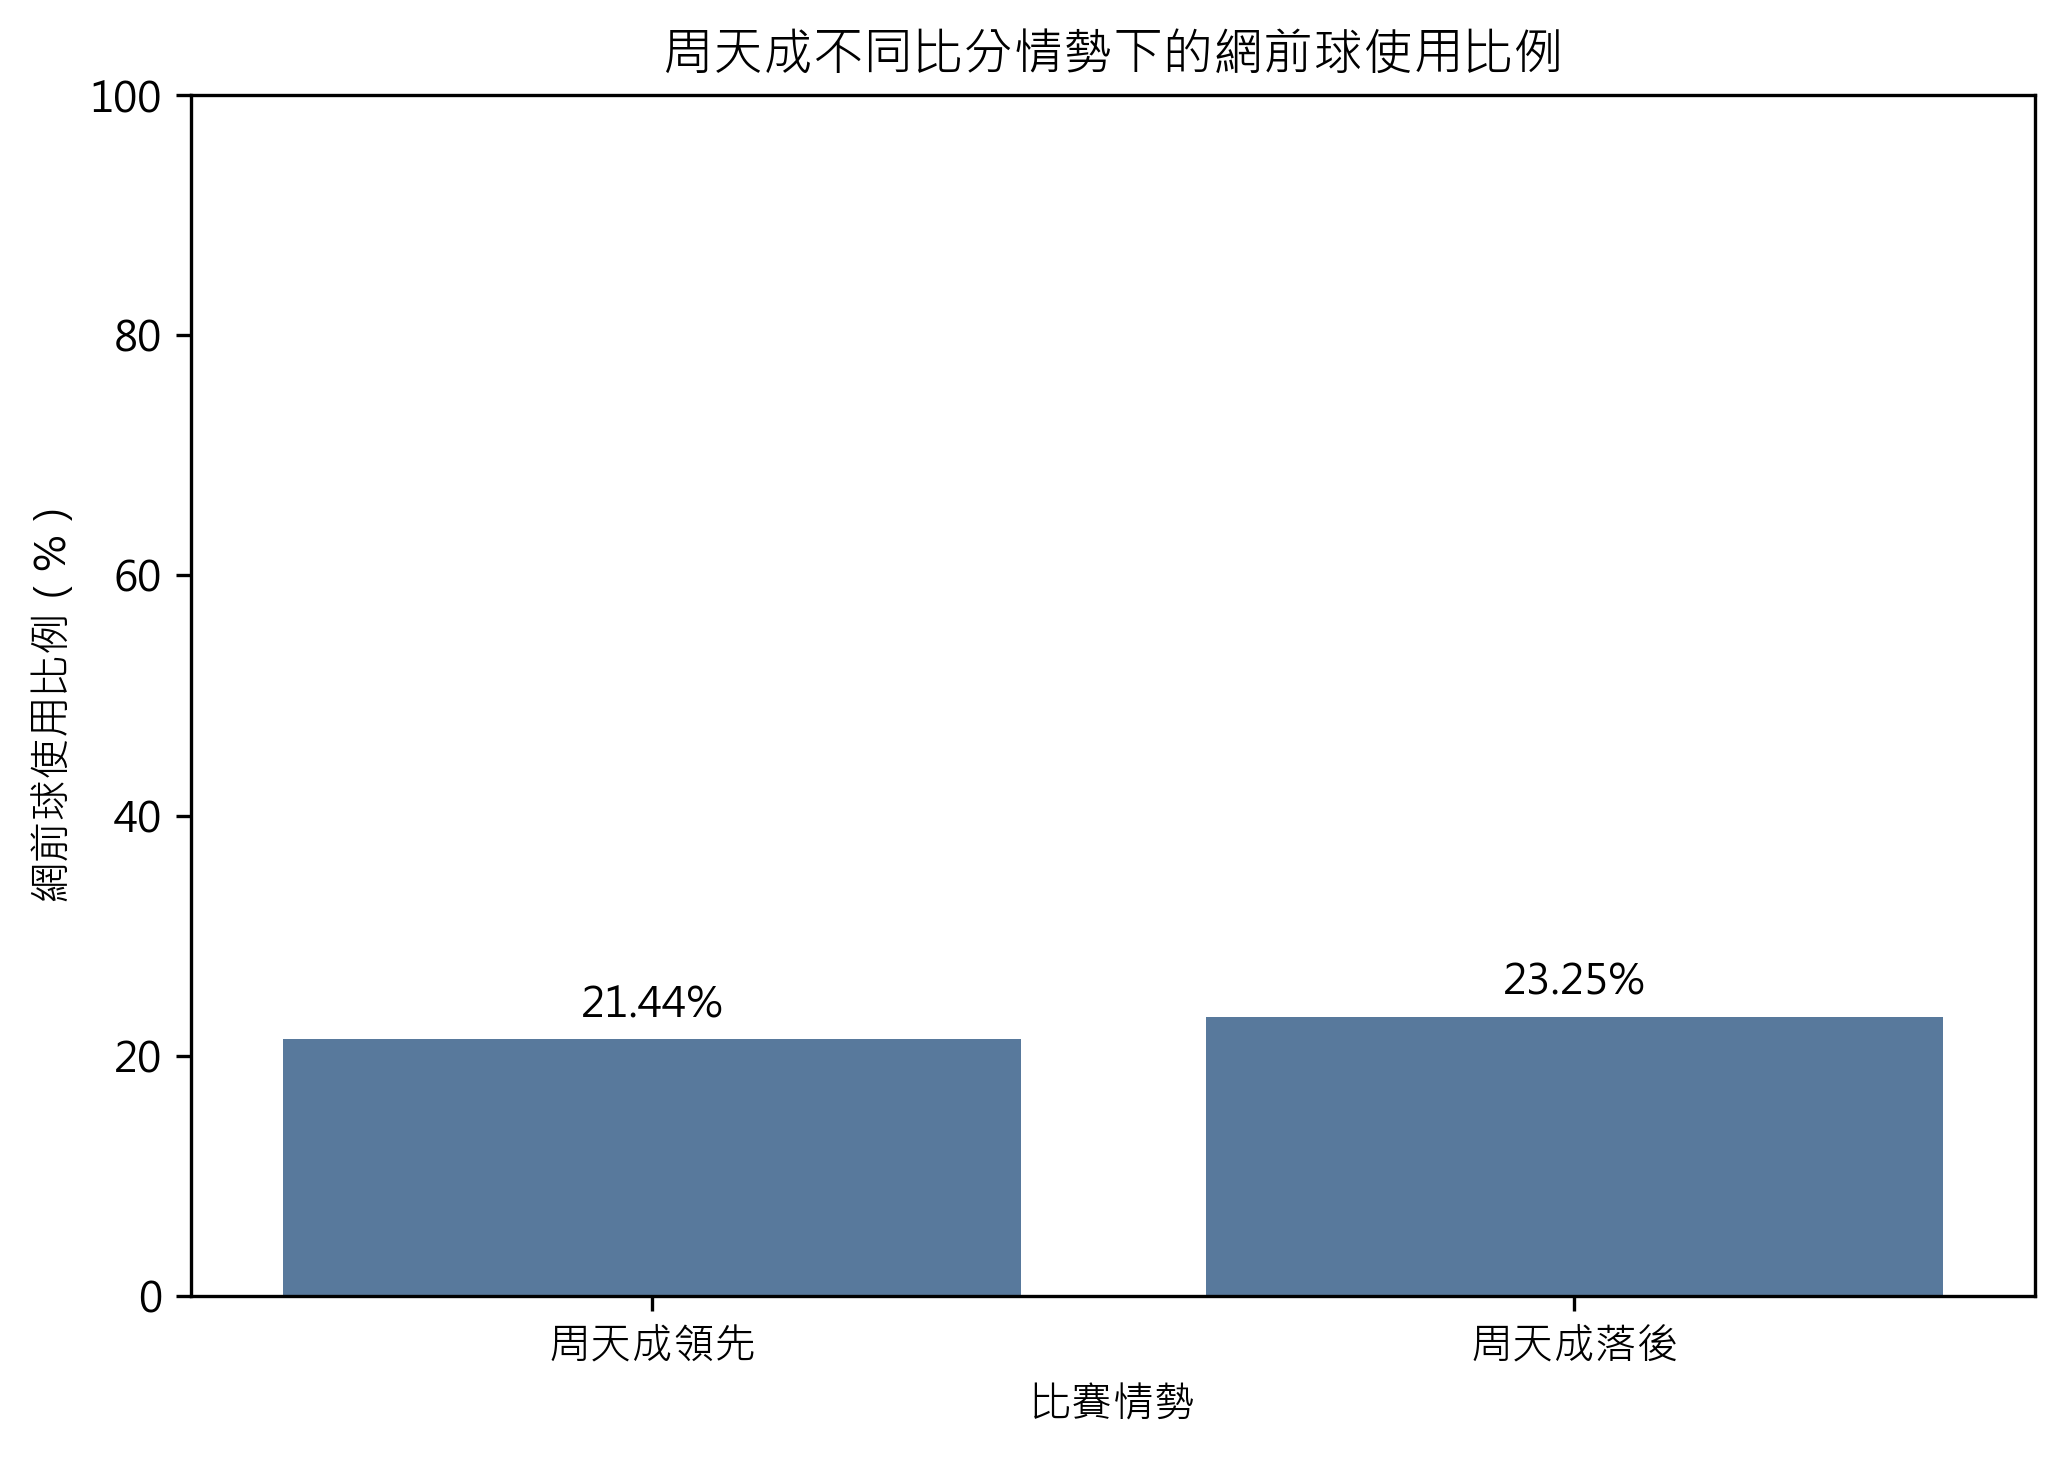

In [ ]:
required_cols = {
    'player',
    'type',
    'Kento MOMOTA_score',
    'CHOU Tien Chen_score'
}

fig, ax = plt.subplots(figsize=(7, 5))

if len(df) == 0:
    print('資料為空，無法分析。')
elif not required_cols.issubset(df.columns):
    print(f'缺少必要欄位：{sorted(required_cols - set(df.columns))}')
else:
    target_player = 'CHOU Tien Chen'
    opponent_player = 'Kento MOMOTA'

    analysis_df = df[
        ['player', 'type', 'Kento MOMOTA_score', 'CHOU Tien Chen_score']
    ].copy()

    analysis_df = analysis_df[
        analysis_df['player'].eq(target_player)
    ].dropna(
        subset=['type', 'Kento MOMOTA_score', 'CHOU Tien Chen_score']
    )

    analysis_df['比賽情勢'] = '平手'
    analysis_df.loc[
        analysis_df['CHOU Tien Chen_score'] > analysis_df['Kento MOMOTA_score'],
        '比賽情勢'
    ] = '周天成領先'
    analysis_df.loc[
        analysis_df['CHOU Tien Chen_score'] < analysis_df['Kento MOMOTA_score'],
        '比賽情勢'
    ] = '周天成落後'

    state_order = ['周天成領先', '周天成落後']
    analysis_df = analysis_df[
        analysis_df['比賽情勢'].isin(state_order)
    ].copy()

    if len(analysis_df) == 0:
        print('沒有周天成領先或落後時的有效擊球資料。')
    else:
        summary = (
            analysis_df.assign(
                是否網前球=analysis_df['type'].eq('網前球')
            )
            .groupby('比賽情勢', observed=False)
            .agg(
                總擊球數=('type', 'size'),
                網前球次數=('是否網前球', 'sum')
            )
            .reindex(state_order, fill_value=0)
            .reset_index()
        )

        summary['網前球使用比例'] = (
            summary['網前球次數'] / summary['總擊球數'] * 100
        )

        leading_rate = summary.loc[
            summary['比賽情勢'].eq('周天成領先'),
            '網前球使用比例'
        ].iloc[0]
        trailing_rate = summary.loc[
            summary['比賽情勢'].eq('周天成落後'),
            '網前球使用比例'
        ].iloc[0]
        rate_difference = leading_rate - trailing_rate

        print('統計口徑：以單拍為單位，只納入擊球者為周天成的球；平手狀態不納入。')
        print('網前球使用比例 = 網前球次數 ÷ 周天成該比賽情勢下的總擊球數。')
        print('前中後場分析限制：資料 Schema 未提供 area 或 zone 欄位，無法依正式場地網格定義拆分前、中、後場。')
        print('\n網前球使用比例統計：')
        print(summary.to_string(index=False, formatters={
            '網前球使用比例': '{:.2f}%'.format
        }))
        print(f'\n領先與落後的使用比例差異：{rate_difference:.2f} 個百分點（領先 - 落後）')

        plot_df = summary.copy()
        sns.barplot(
            data=plot_df,
            x='比賽情勢',
            y='網前球使用比例',
            order=state_order,
            color='#4C78A8',
            ax=ax
        )
        ax.set_title('周天成不同比分情勢下的網前球使用比例')
        ax.set_xlabel('比賽情勢')
        ax.set_ylabel('網前球使用比例（%）')
        ax.set_ylim(0, max(100, plot_df['網前球使用比例'].max() * 1.2))

        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 73
**問題**: 周天成對直線 vs 斜線殺球的對手回擊效果（得失分比較）。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


統計口徑：周天成殺球後，同一回合對手的下一拍；結果採該回合最終得分者。
方向判定：擊球點 hit_x 與落點 landing_x 同側為直線，異側為斜線。

直線 vs 斜線殺球之對手回擊效果：
結果    周天成得分  周天成失分  總事件數    得分率    失分率
殺球方向                                  
直線       36     49    85  42.35  57.65
斜線       61     72   133  45.86  54.14


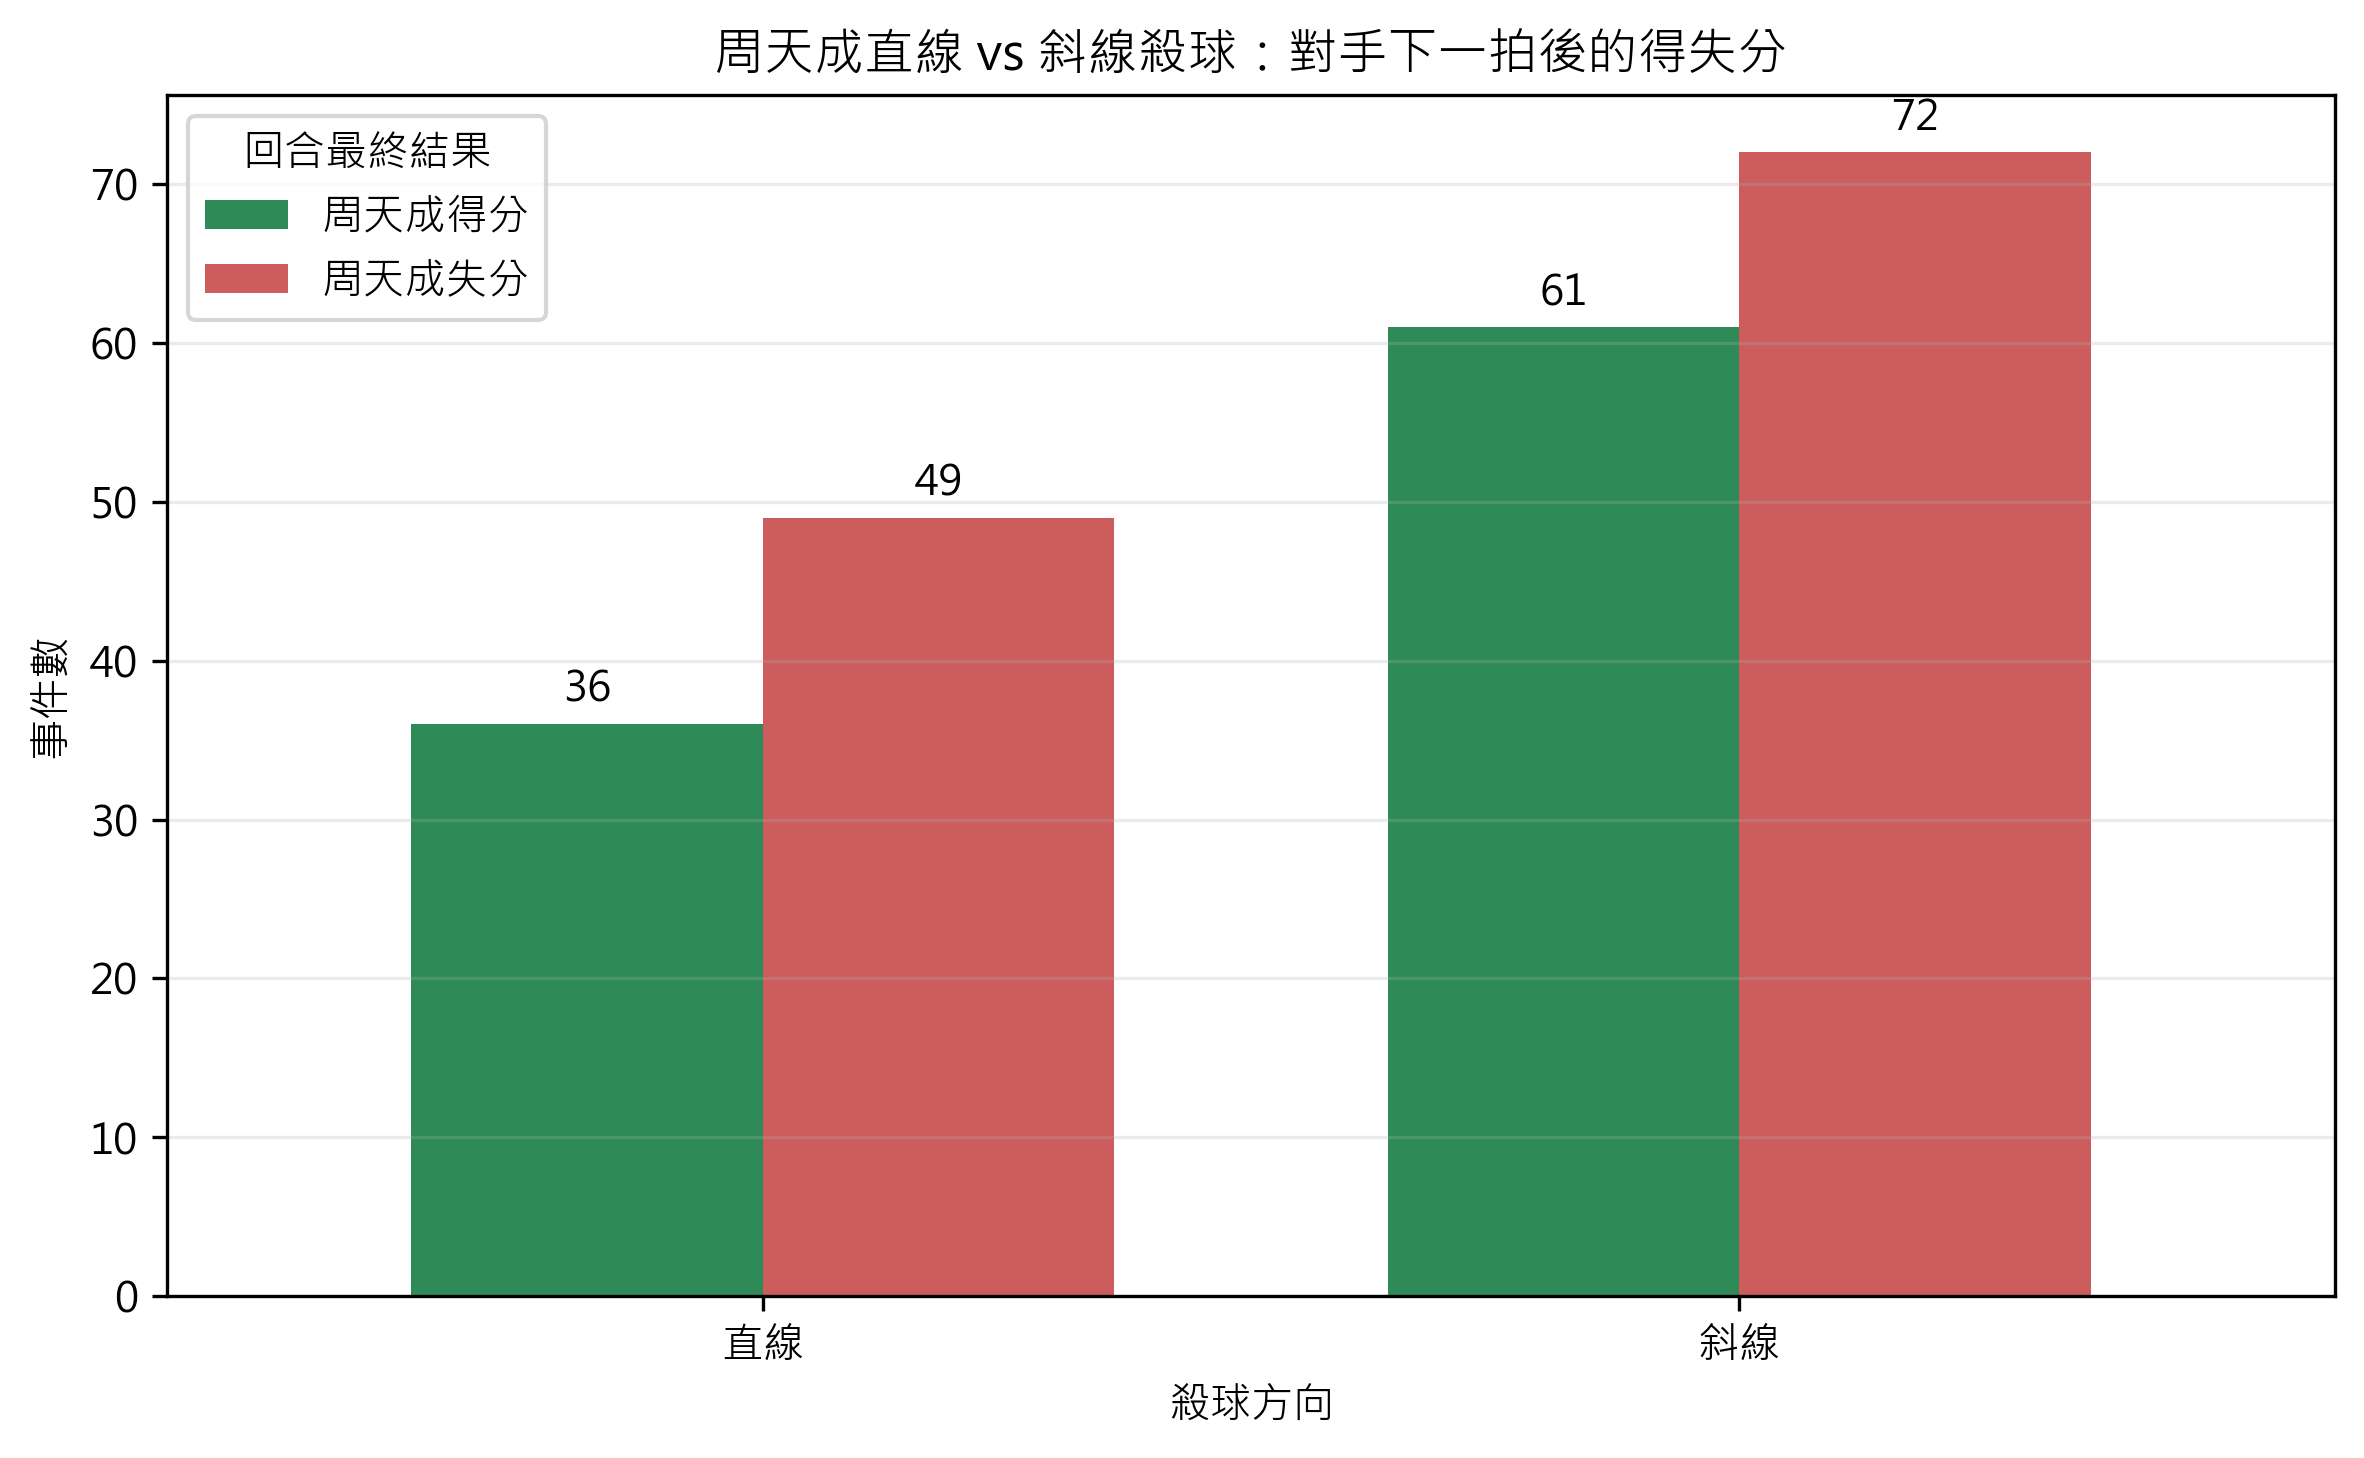

In [ ]:
import numpy as np

required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'hit_x', 'landing_x', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法分析。')
    fig = plt.figure(figsize=(8, 5))
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
        fig = plt.figure(figsize=(8, 5))
    else:
        chou = 'CHOU Tien Chen'
        opponent = 'Kento MOMOTA'
        group_cols = ['match_id', 'set', 'rally']

        data = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).copy()

        grouped = data.groupby(group_cols, sort=False)

        # 在完整資料上建立同一回合的下一拍資訊，避免跨回合污染
        data['next_player'] = grouped['player'].shift(-1)
        data['next_ball_round'] = grouped['ball_round'].shift(-1)

        data['rally_getpoint_player'] = grouped['getpoint_player'].transform('last')

        # 僅分析周天成打出的殺球，且必須存在同一回合的對手下一拍
        smash = data[
            (data['player'] == chou) &
            (data['type'] == '殺球') &
            (data['next_player'] == opponent) &
            (data['hit_x'].notna()) &
            (data['landing_x'].notna()) &
            (data['rally_getpoint_player'].isin([chou, opponent]))
        ].copy()

        # 以擊球點與落點的左右側判定方向：
        # 同側為直線殺球，異側為斜線殺球；落點位於中心線者不納入方向比較
        smash['hit_side'] = np.sign(smash['hit_x'])
        smash['landing_side'] = np.sign(smash['landing_x'])

        smash = smash[
            (smash['hit_side'] != 0) &
            (smash['landing_side'] != 0)
        ].copy()

        smash['殺球方向'] = np.where(
            smash['hit_side'] == smash['landing_side'],
            '直線',
            '斜線'
        )

        smash['結果'] = np.where(
            smash['rally_getpoint_player'] == chou,
            '周天成得分',
            '周天成失分'
        )

        direction_order = ['直線', '斜線']
        result_order = ['周天成得分', '周天成失分']

        if len(smash) == 0:
            print('找不到符合條件的周天成殺球及對手下一拍資料。')
            fig = plt.figure(figsize=(8, 5))
        else:
            summary = (
                smash.groupby(['殺球方向', '結果'])
                .size()
                .unstack(fill_value=0)
                .reindex(index=direction_order, columns=result_order, fill_value=0)
            )

            summary['總事件數'] = summary.sum(axis=1)
            summary['得分率'] = (
                summary['周天成得分'] / summary['總事件數'] * 100
            ).round(2)
            summary['失分率'] = (
                summary['周天成失分'] / summary['總事件數'] * 100
            ).round(2)

            print('統計口徑：周天成殺球後，同一回合對手的下一拍；結果採該回合最終得分者。')
            print('方向判定：擊球點 hit_x 與落點 landing_x 同側為直線，異側為斜線。')
            print('\n直線 vs 斜線殺球之對手回擊效果：')
            print(summary.to_string())

            plot_data = summary[result_order].copy()
            plot_data.columns = ['周天成得分', '周天成失分']

            fig, ax = plt.subplots(figsize=(8, 5))
            plot_data.plot(
                kind='bar',
                ax=ax,
                color=['#2E8B57', '#CD5C5C'],
                width=0.72
            )

            ax.set_title('周天成直線 vs 斜線殺球：對手下一拍後的得失分')
            ax.set_xlabel('殺球方向')
            ax.set_ylabel('事件數')
            ax.set_xticklabels(direction_order, rotation=0)
            ax.legend(title='回合最終結果')
            ax.grid(axis='y', alpha=0.25)

            for container in ax.containers:
                ax.bar_label(container, fmt='%d', padding=3)

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 76
**問題**: 在被動情況下（跨步救球），下一拍攻擊性球種的成功機率。
> **使用的資料欄位群組**: `game_structure, shot_type, player_movement, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


跨步救球代理條件：位移距離 >= 0.4749 （全體有效位移距離第75百分位）
攻擊性球種：殺球、推撲球、平球
符合樣本數：86
Active Win 次數：59
整體下一拍攻擊成功機率：68.60%

各攻擊性球種成功機率：
next_type  下一拍次數  Active_Win次數     成功機率
       殺球     75            54 0.720000
      推撲球      6             4 0.666667
       平球      5             1 0.200000


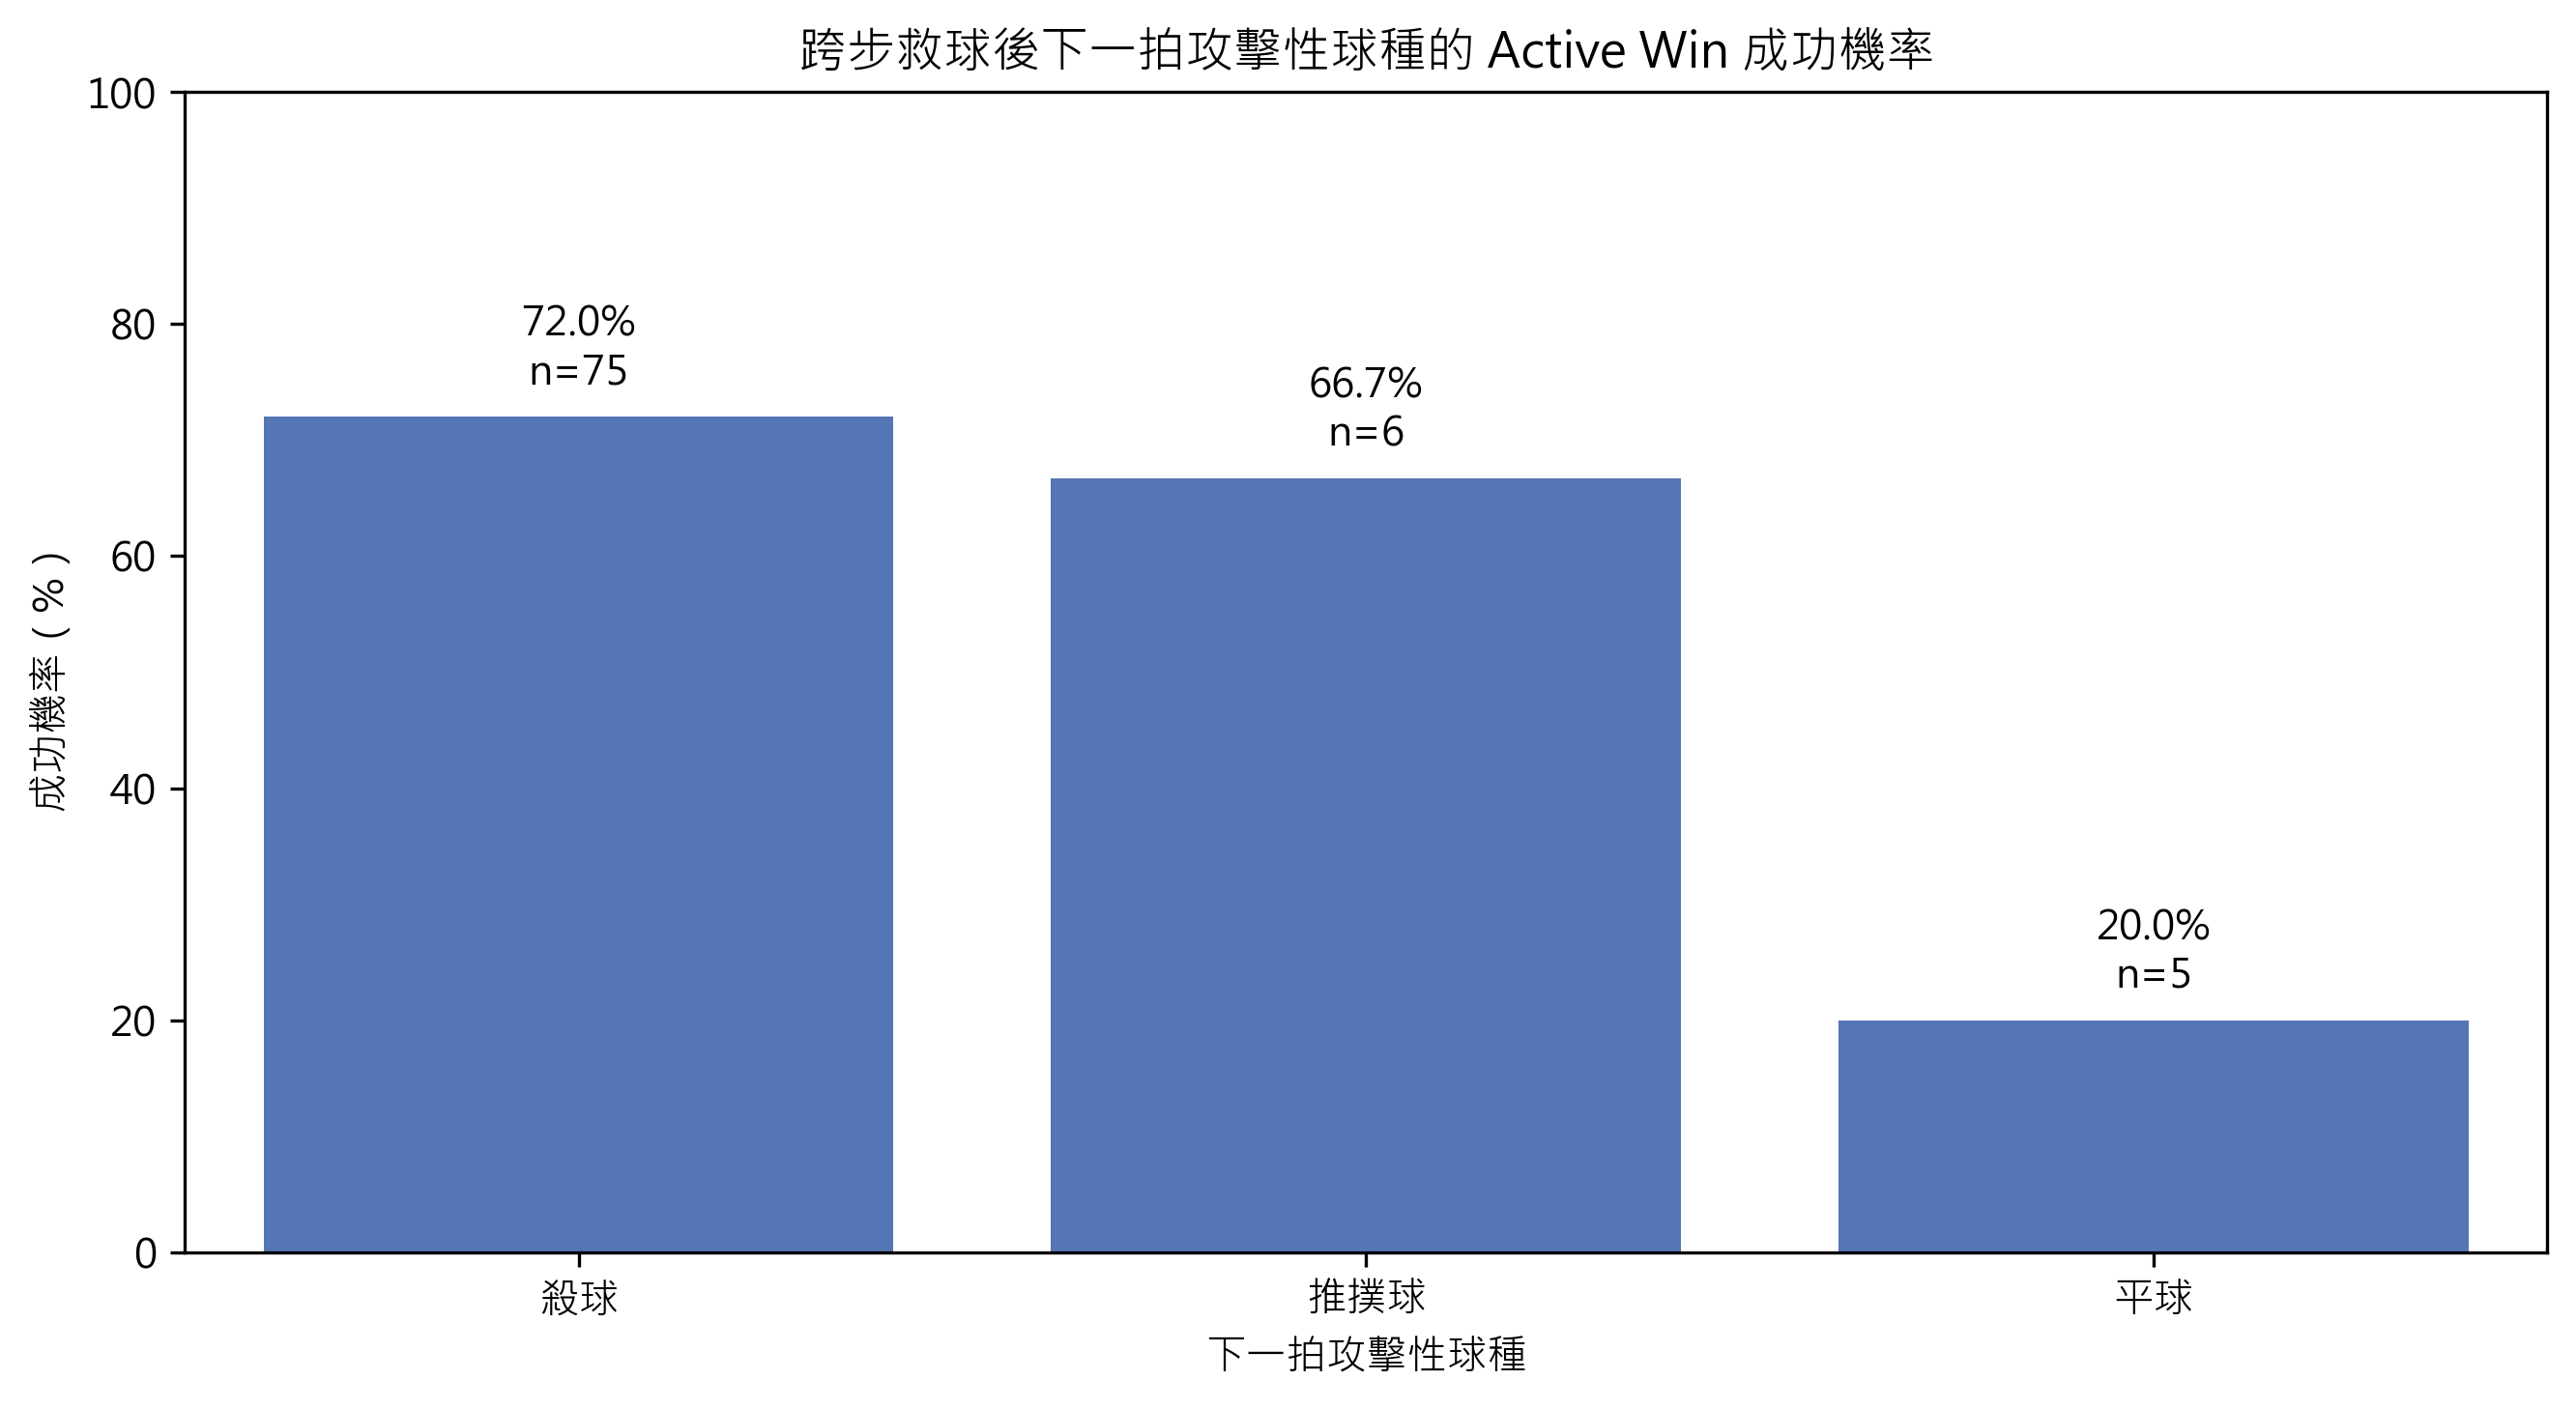

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    required_cols = [
        'match_id', 'set', 'rally', 'ball_round', 'player', 'type',
        'getpoint_player', 'player_move_x', 'player_move_y'
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        data = df.copy().sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).reset_index(drop=True)

        group_cols = ['match_id', 'set', 'rally']

        # 以擊球後的位移距離較大的情況，作為「跨步救球」的可觀測代理條件
        movement_valid = data[['player_move_x', 'player_move_y']].notna().all(axis=1)
        data['movement_distance'] = (
            data['player_move_x'].pow(2) +
            data['player_move_y'].pow(2)
        ).pow(0.5)

        if movement_valid.sum() == 0:
            print("player_move_x 或 player_move_y 沒有可用資料，無法辨識跨步救球。")
        else:
            rescue_threshold = data.loc[
                movement_valid, 'movement_distance'
            ].quantile(0.75)

            # 完整資料上建立同一回合的下一拍資訊，避免篩選後 shift 造成跨拍污染
            next_cols = ['player', 'type', 'getpoint_player', 'ball_round']
            for col in next_cols:
                data[f'next_{col}'] = data.groupby(group_cols)[col].shift(-1)

            same_rally_next = (
                data['match_id'].eq(data.groupby(group_cols)['match_id'].shift(-1)) &
                data['set'].eq(data.groupby(group_cols)['set'].shift(-1)) &
                data['rally'].eq(data.groupby(group_cols)['rally'].shift(-1))
            )

            data['is_cross_step_rescue'] = (
                movement_valid &
                (data['movement_distance'] >= rescue_threshold)
            )

            # 攻擊性球種定義：殺球、推撲球、平球
            attacking_types = ['殺球', '推撲球', '平球']

            rescue_followup = data[
                data['is_cross_step_rescue'] &
                same_rally_next &
                data['next_type'].isin(attacking_types) &
                data['next_player'].notna() &
                data['next_getpoint_player'].notna()
            ].copy()

            if len(rescue_followup) == 0:
                print("沒有符合條件的跨步救球後下一拍攻擊性球種資料。")
            else:
                # 下一拍必須由對手擊球，才符合「跨步救球後對手回擊」
                rescue_followup = rescue_followup[
                    rescue_followup['next_player'].ne(rescue_followup['player'])
                ].copy()

                if len(rescue_followup) == 0:
                    print("沒有符合條件的對手下一拍攻擊性球種資料。")
                else:
                    # 下一拍攻擊性球種的成功定義：下一拍為 Active Win
                    rescue_followup['next_active_win'] = (
                        rescue_followup['next_player'] ==
                        rescue_followup['next_getpoint_player']
                    )

                    result = (
                        rescue_followup
                        .groupby('next_type', as_index=False)
                        .agg(
                            下一拍次數=('next_type', 'size'),
                            Active_Win次數=('next_active_win', 'sum')
                        )
                    )
                    result['成功機率'] = (
                        result['Active_Win次數'] / result['下一拍次數']
                    )

                    total_attempts = len(rescue_followup)
                    total_active_wins = int(
                        rescue_followup['next_active_win'].sum()
                    )
                    total_probability = total_active_wins / total_attempts

                    result = result.sort_values(
                        ['成功機率', '下一拍次數'],
                        ascending=[False, False]
                    ).reset_index(drop=True)

                    print(
                        f"跨步救球代理條件：位移距離 >= {rescue_threshold:.4f} "
                        f"（全體有效位移距離第75百分位）"
                    )
                    print("攻擊性球種：殺球、推撲球、平球")
                    print(f"符合樣本數：{total_attempts}")
                    print(f"Active Win 次數：{total_active_wins}")
                    print(f"整體下一拍攻擊成功機率：{total_probability:.2%}")
                    print("\n各攻擊性球種成功機率：")
                    print(result.to_string(index=False))

                    fig, ax = plt.subplots(figsize=(9, 5))
                    plot_data = result.copy()
                    plot_data['成功機率百分比'] = plot_data['成功機率'] * 100

                    sns.barplot(
                        data=plot_data,
                        x='next_type',
                        y='成功機率百分比',
                        order=plot_data['next_type'].tolist(),
                        color='#4472C4',
                        ax=ax
                    )

                    ax.set_title('跨步救球後下一拍攻擊性球種的 Active Win 成功機率')
                    ax.set_xlabel('下一拍攻擊性球種')
                    ax.set_ylabel('成功機率（%）')
                    ax.set_ylim(0, 100)

                    for i, row in plot_data.iterrows():
                        ax.text(
                            i,
                            row['成功機率百分比'] + 2,
                            f"{row['成功機率百分比']:.1f}%\n"
                            f"n={int(row['下一拍次數'])}",
                            ha='center',
                            va='bottom'
                        )

                    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 79
**問題**: 計算對手挑球過短時，周天成球種的選擇統計。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


對手挑球過短後周天成的有效下一拍事件數：409
周天成下一拍球種  使用次數    比例
      殺球   155 37.90
      長球   134 32.76
      切球   101 24.69
      平球    19  4.65


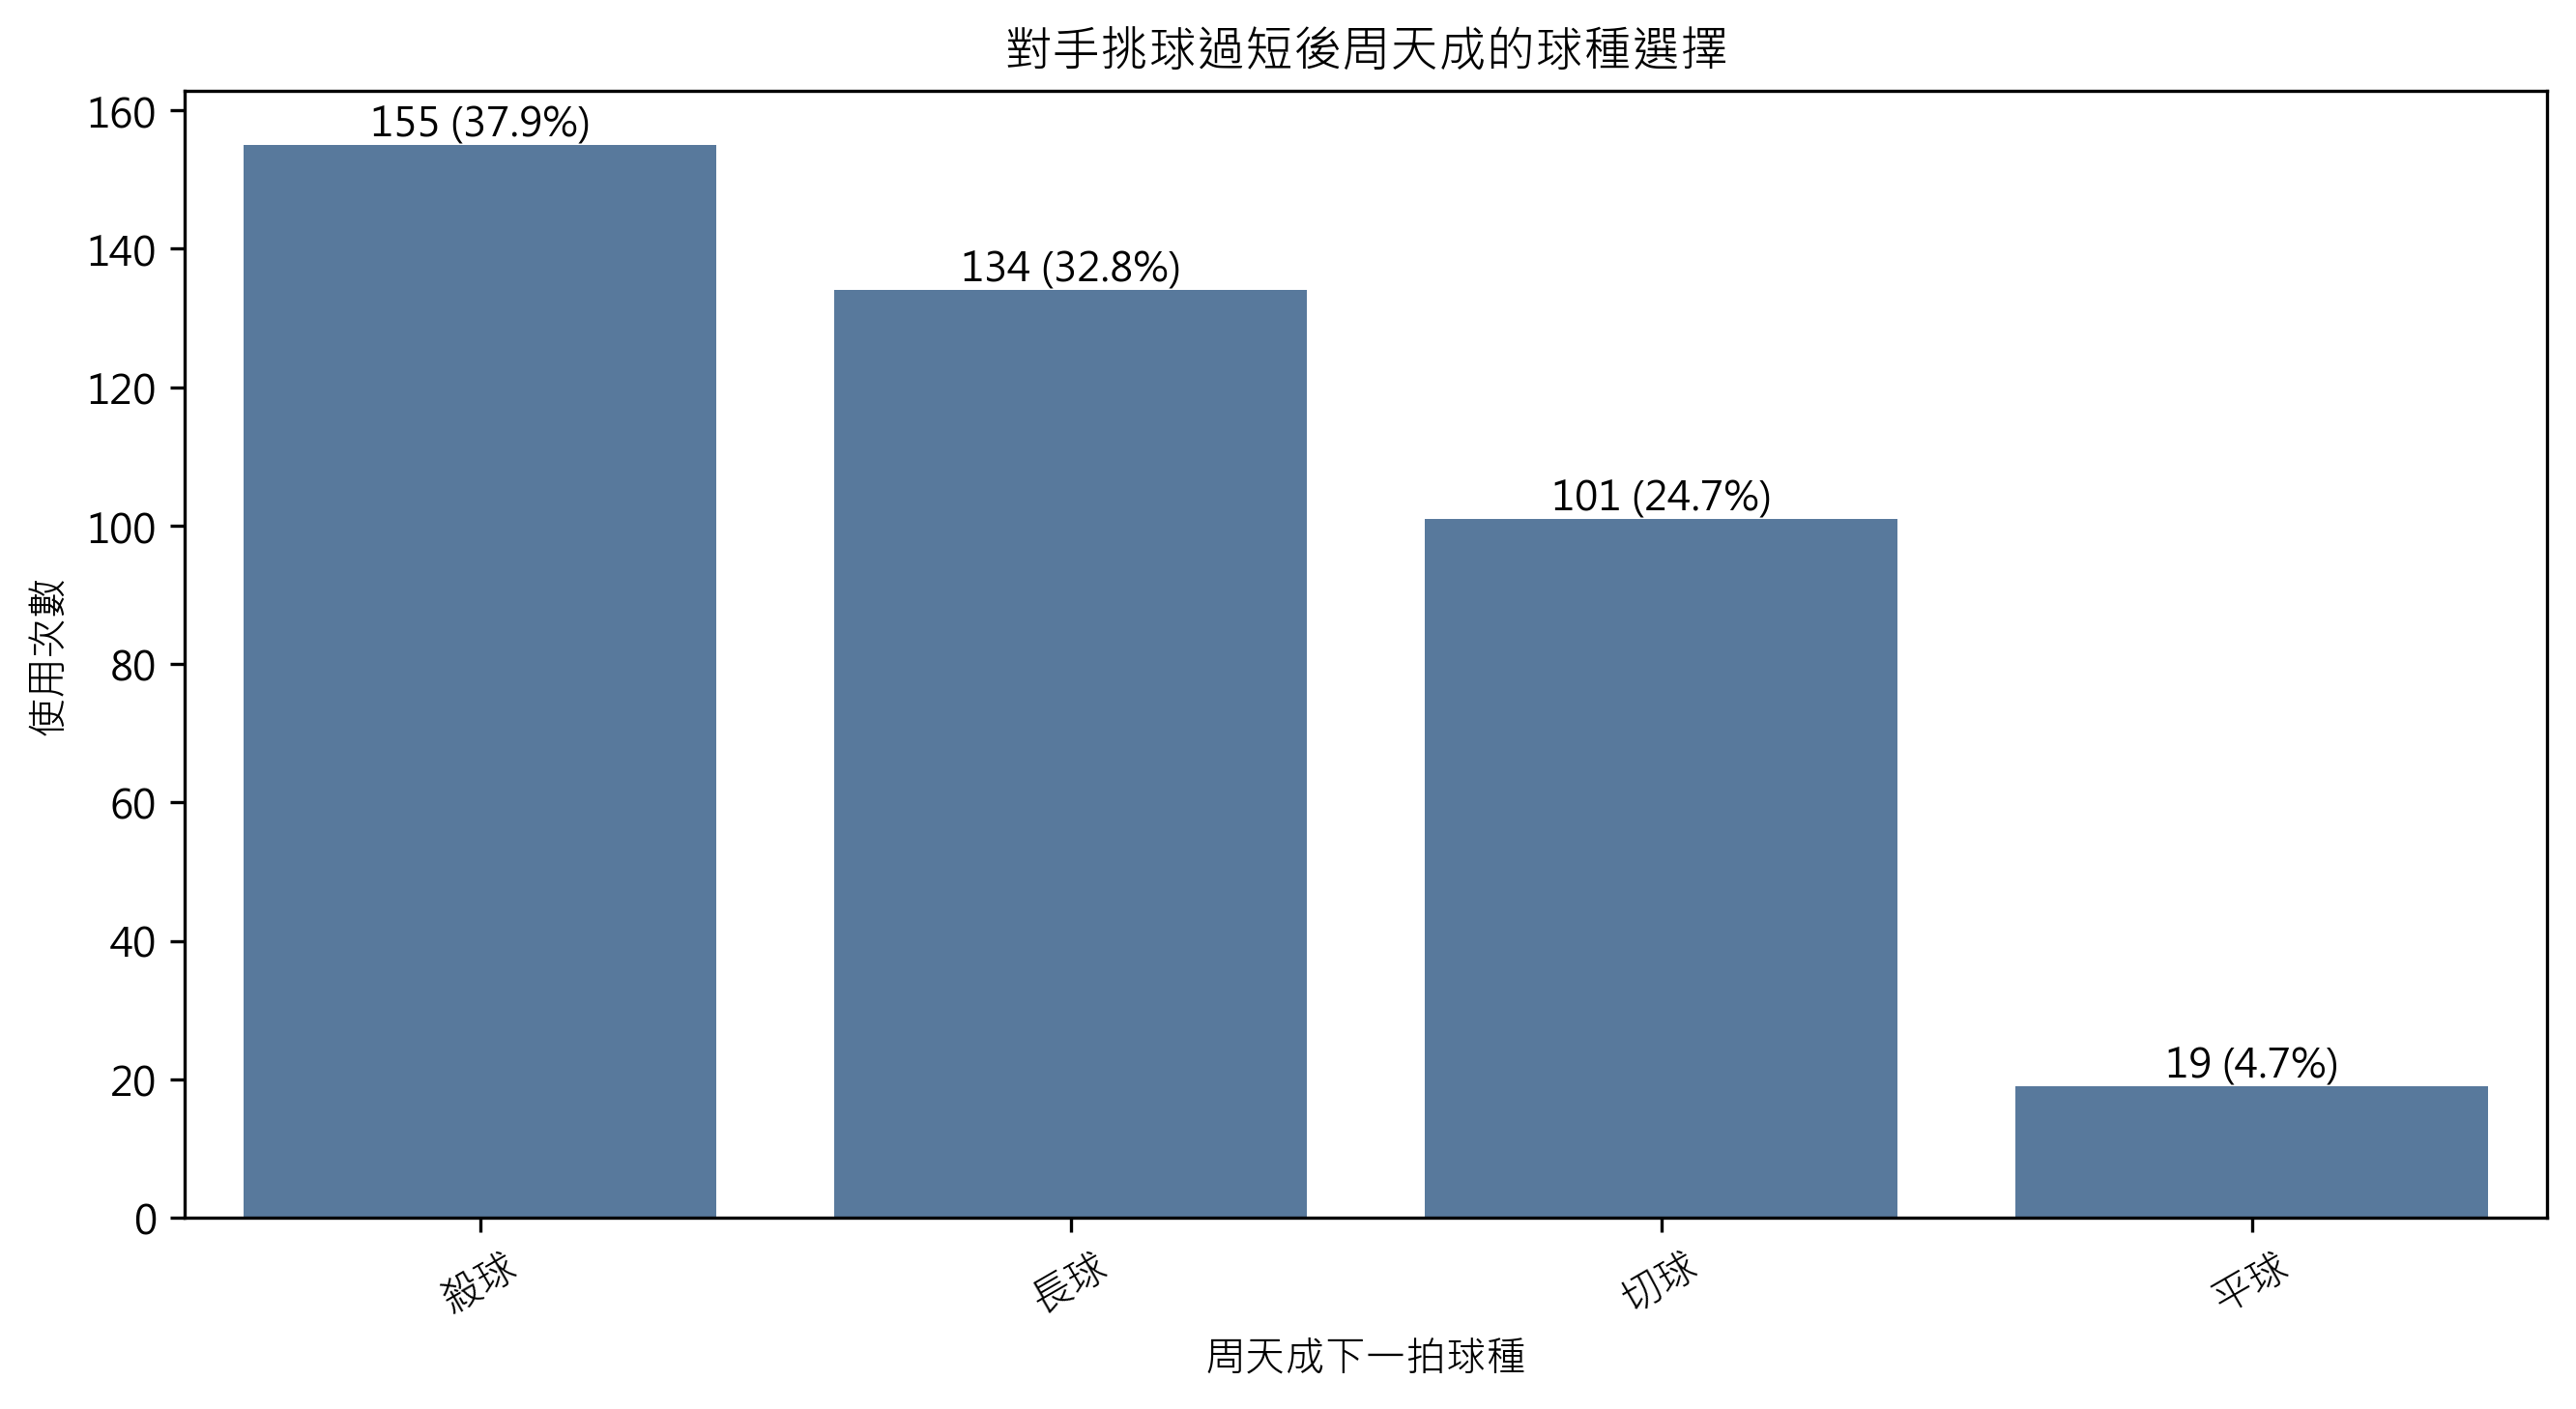

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'opponent', 'type', 'landing_y'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print('資料為空，無法分析。')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title('對手挑球過短後周天成的球種選擇')
    ax.set_xlabel('周天成下一拍球種')
    ax.set_ylabel('使用次數')
    plt.tight_layout()

elif missing_cols:
    print(f'缺少必要欄位：{missing_cols}')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title('對手挑球過短後周天成的球種選擇')
    ax.set_xlabel('周天成下一拍球種')
    ax.set_ylabel('使用次數')
    plt.tight_layout()

else:
    target_player = 'CHOU Tien Chen'
    opponent_player = 'Kento MOMOTA'

    # 以落點 y 座標 <= 0.5 定義為前場短落點，作為「挑球過短」的操作性判定
    short_landing_y_threshold = 0.5

    work = df[required_cols].copy()
    work = work.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).reset_index(drop=True)

    group_cols = ['match_id', 'set', 'rally']

    work['next_player'] = work.groupby(group_cols)['player'].shift(-1)
    work['next_opponent'] = work.groupby(group_cols)['opponent'].shift(-1)
    work['next_type'] = work.groupby(group_cols)['type'].shift(-1)
    work['next_ball_round'] = work.groupby(group_cols)['ball_round'].shift(-1)
    work['next_match_id'] = work.groupby(group_cols)['match_id'].shift(-1)
    work['next_set'] = work.groupby(group_cols)['set'].shift(-1)
    work['next_rally'] = work.groupby(group_cols)['rally'].shift(-1)

    same_rally_next_shot = (
        (work['next_match_id'] == work['match_id']) &
        (work['next_set'] == work['set']) &
        (work['next_rally'] == work['rally']) &
        (work['next_ball_round'] == work['ball_round'] + 1)
    )

    valid_event = work[
        same_rally_next_shot &
        work['player'].eq(opponent_player) &
        work['opponent'].eq(target_player) &
        work['type'].eq('挑球') &
        work['landing_y'].notna() &
        work['landing_y'].le(short_landing_y_threshold) &
        work['next_player'].eq(target_player) &
        work['next_opponent'].eq(opponent_player) &
        work['next_type'].notna()
    ].copy()

    choice_counts = (
        valid_event['next_type']
        .value_counts()
        .rename_axis('周天成下一拍球種')
        .reset_index(name='使用次數')
    )

    total_events = len(valid_event)

    if total_events > 0:
        choice_counts['比例'] = (
            choice_counts['使用次數'] / total_events * 100
        ).round(2)

        print(f'對手挑球過短後周天成的有效下一拍事件數：{total_events}')
        print(choice_counts.to_string(index=False))

        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(
            data=choice_counts,
            x='周天成下一拍球種',
            y='使用次數',
            color='#4C78A8',
            ax=ax
        )

        ax.set_title('對手挑球過短後周天成的球種選擇')
        ax.set_xlabel('周天成下一拍球種')
        ax.set_ylabel('使用次數')
        ax.tick_params(axis='x', rotation=30)

        for index, row in choice_counts.iterrows():
            ax.text(
                index,
                row['使用次數'],
                f"{int(row['使用次數'])} ({row['比例']:.1f}%)",
                ha='center',
                va='bottom'
            )
    else:
        print('找不到符合條件的「對手挑球過短後周天成下一拍」事件。')

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.set_title('對手挑球過短後周天成的球種選擇')
        ax.set_xlabel('周天成下一拍球種')
        ax.set_ylabel('使用次數')

    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 80
**問題**: 當周天成發現自己較容易掛網時，應該如何調整自己的擊球策略與站位，以減少掛網失誤的發生？
> **使用的資料欄位群組**: `game_structure, shot_type, player_location, scoring_reason, stroke_details`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


分析主體：CHOU Tien Chen
失誤定義：周天成為最後擊球者，且 lose_reason=掛網、對手取得該回合得分。
周天成有效擊球數：2609
掛網失誤數：60
整體掛網失誤率：2.30%

依球種統計：
type  擊球數  掛網失誤數 掛網失誤率
接殺防守  351     18 5.13%
 網前球  582     29 4.98%
  平球  106      3 2.83%
  殺球  299      3 1.00%
  切球  211      2 0.95%
 推撲球  334      3 0.90%
  挑球  270      2 0.74%
  長球  275      0 0.00%
 發短球  147      0 0.00%
 發長球   34      0 0.00%

站位統計：
…（輸出已截斷；notebook 僅保留重點）


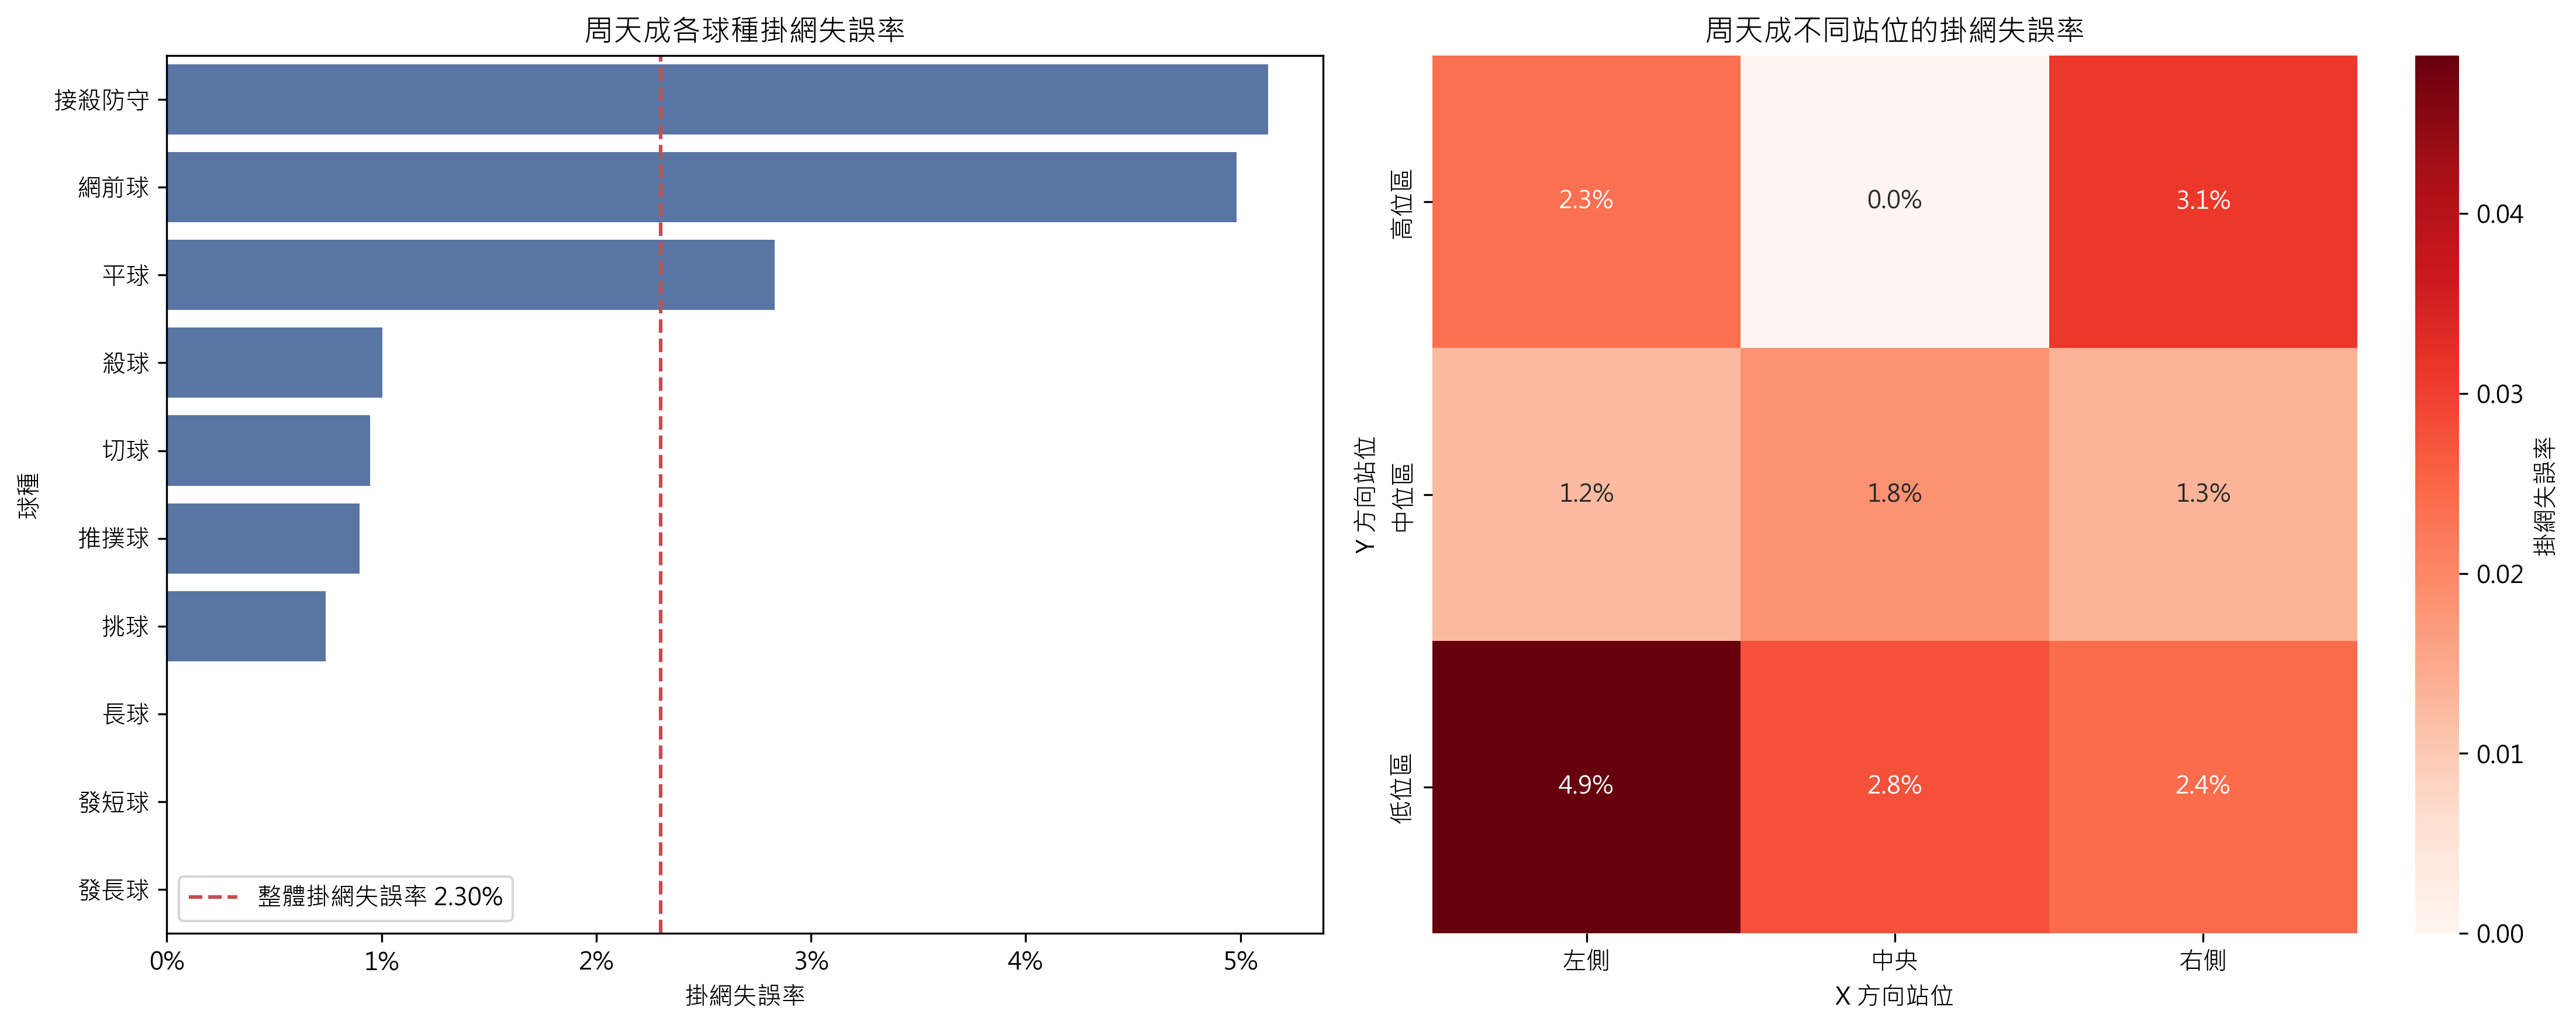

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'lose_reason', 'getpoint_player',
    'player_location_x', 'player_location_y'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print('資料為空，無法進行分析。')
    fig = plt.figure(figsize=(12, 6))
elif missing_cols:
    print(f'缺少必要欄位：{missing_cols}')
    fig = plt.figure(figsize=(12, 6))
else:
    target_player = 'CHOU Tien Chen'
    opponent_player = 'Kento MOMOTA'

    work = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    valid_player = work['player'].notna()
    valid_type = work['type'].notna()
    valid_reason = work['lose_reason'].notna()
    valid_opponent = work['opponent'].notna()
    valid_getpoint = work['getpoint_player'].notna()

    target_shots = work[
        valid_player
        & (work['player'] == target_player)
        & valid_type
    ].copy()

    target_shots['掛網失誤'] = (
        target_shots['lose_reason'].eq('掛網')
        & target_shots['getpoint_player'].eq(opponent_player)
        & target_shots['opponent'].eq(opponent_player)
    )

    total_shots = len(target_shots)
    net_errors = int(target_shots['掛網失誤'].sum())
    overall_rate = net_errors / total_shots if total_shots > 0 else 0

    print(f'分析主體：{target_player}')
    print('失誤定義：周天成為最後擊球者，且 lose_reason=掛網、對手取得該回合得分。')
    print(f'周天成有效擊球數：{total_shots}')
    print(f'掛網失誤數：{net_errors}')
    print(f'整體掛網失誤率：{overall_rate:.2%}')

    type_stats = (
        target_shots
        .groupby('type', dropna=False)
        .agg(
            擊球數=('type', 'size'),
            掛網失誤數=('掛網失誤', 'sum')
        )
        .reset_index()
    )
    type_stats['掛網失誤率'] = (
        type_stats['掛網失誤數'] / type_stats['擊球數']
    )
    type_stats = type_stats.sort_values(
        ['掛網失誤率', '擊球數'],
        ascending=[False, False]
    )

    print('\n依球種統計：')
    print(type_stats.to_string(index=False, formatters={
        '掛網失誤率': lambda x: f'{x:.2%}'
    }))

    spatial_shots = target_shots.dropna(
        subset=['player_location_x', 'player_location_y']
    ).copy()

    if len(spatial_shots) > 0:
        spatial_shots['X站位'] = pd.qcut(
            spatial_shots['player_location_x'].rank(method='first'),
            q=3,
            labels=['左側', '中央', '右側']
        )
        spatial_shots['Y站位'] = pd.qcut(
            spatial_shots['player_location_y'].rank(method='first'),
            q=3,
            labels=['低位區', '中位區', '高位區']
        )

        station_stats = (
            spatial_shots
            .groupby(['X站位', 'Y站位'], observed=False)
            .agg(
                擊球數=('掛網失誤', 'size'),
                掛網失誤數=('掛網失誤', 'sum')
            )
            .reset_index()
        )
        station_stats['掛網失誤率'] = (
            station_stats['掛網失誤數'] / station_stats['擊球數']
        )

        print('\n站位統計：')
        print(station_stats.to_string(index=False, formatters={
            '掛網失誤率': lambda x: f'{x:.2%}'
        }))

        station_ranges = (
            spatial_shots
            .groupby(['X站位', 'Y站位'], observed=False)
            .agg(
                X最小值=('player_location_x', 'min'),
                X最大值=('player_location_x', 'max'),
                Y最小值=('player_location_y', 'min'),
                Y最大值=('player_location_y', 'max')
            )
            .reset_index()
        )

        print('\n站位區間定義（依周天成資料中的座標三分位數切分；左/右與高/低僅代表座標相對位置）：')
        print(station_ranges.to_string(index=False, formatters={
            'X最小值': lambda x: f'{x:.3f}',
            'X最大值': lambda x: f'{x:.3f}',
            'Y最小值': lambda x: f'{x:.3f}',
            'Y最大值': lambda x: f'{x:.3f}'
        }))

        valid_type_stats = type_stats[type_stats['擊球數'] >= 10].copy()
        valid_station_stats = station_stats[station_stats['擊球數'] >= 10].copy()

        recommendations = []

        if len(valid_type_stats) > 0:
            high_type = valid_type_stats.iloc[0]
            if high_type['掛網失誤率'] > overall_rate:
                recommendations.append(
                    f"優先檢視「{high_type['type']}」：掛網失誤率為 "
                    f"{high_type['掛網失誤率']:.2%}，高於整體 {overall_rate:.2%}；"
                    f"執行此球種時應降低擊球冒險程度，增加過網高度與安全落點。"
                )

        if len(valid_station_stats) > 0:
            high_station = valid_station_stats.sort_values(
                ['掛網失誤率', '擊球數'],
                ascending=[False, False]
            ).iloc[0]
            if high_station['掛網失誤率'] > overall_rate:
                recommendations.append(
                    f"在「{high_station['X站位']}、{high_station['Y站位']}」站位組合時，"
                    f"掛網失誤率為 {high_station['掛網失誤率']:.2%}；"
                    f"建議略微調整擊球準備位置，避免在不利高度或過度前壓下勉強進攻，"
                    f"優先使用較高弧線、較保守的回球。"
                )

        if not recommendations:
            recommendations.append(
                '目前沒有足夠證據指出特定球種或站位的掛網失誤率明顯高於整體；'
                '建議持續累積樣本，並優先觀察擊球高度、站位與球種的交互關係。'
            )

        print('\n策略與站位建議：')
        for i, recommendation in enumerate(recommendations, 1):
            print(f'{i}. {recommendation}')

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        plot_type_stats = type_stats.copy()
        plot_type_stats['球種'] = plot_type_stats['type'].astype(str)

        sns.barplot(
            data=plot_type_stats,
            x='掛網失誤率',
            y='球種',
            color='#4C72B0',
            ax=axes[0]
        )
        axes[0].axvline(
            overall_rate,
            color='#C44E52',
            linestyle='--',
            label=f'整體掛網失誤率 {overall_rate:.2%}'
        )
        axes[0].set_title('周天成各球種掛網失誤率')
        axes[0].set_xlabel('掛網失誤率')
        axes[0].set_ylabel('球種')
        axes[0].xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, pos: f'{x:.0%}')
        )
        axes[0].legend()

        heatmap_data = station_stats.pivot(
            index='Y站位',
            columns='X站位',
            values='掛網失誤率'
        )
        heatmap_data = heatmap_data.reindex(
            index=['高位區', '中位區', '低位區'],
            columns=['左側', '中央', '右側']
        )

        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt='.1%',
            cmap='Reds',
            vmin=0,
            vmax=max(
                float(heatmap_data.max().max())
                if heatmap_data.notna().any().any()
                else 0,
                overall_rate,
                0.01
            ),
            cbar_kws={'label': '掛網失誤率'},
            ax=axes[1]
        )
        axes[1].set_title('周天成不同站位的掛網失誤率')
        axes[1].set_xlabel('X 方向站位')
        axes[1].set_ylabel('Y 方向站位')

        plt.tight_layout()
    else:
        print('缺少有效站位座標，無法進行站位分析。')
        fig, axes = plt.subplots(1, 1, figsize=(8, 5))
        axes.text(
            0.5, 0.5,
            '缺少有效站位座標',
            ha='center',
            va='center',
            fontsize=14
        )
        axes.set_axis_off()
        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 82
**問題**: 統計周天成成功逼迫對手挑球的頻率，以及最常造成的球種來源。
> **使用的資料欄位群組**: `game_structure, shot_type`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


分析主體：CHOU Tien Chen 的擊球後，下一拍由對手擊出挑球
可觀察且由對手回擊的事件數：2364
成功逼迫對手挑球次數：432
成功逼迫對手挑球頻率：18.27%
最常造成對手挑球的球種來源：網前球（293 次）

各球種造成對手挑球的統計：
造成對手挑球的球種來源  次數     頻率
        網前球 293 67.82%
       接殺防守  79 18.29%
        發短球  40  9.26%
         切球  17  3.94%
         殺球   1  0.23%
         平球   1  0.23%
        推撲球   1  0.23%


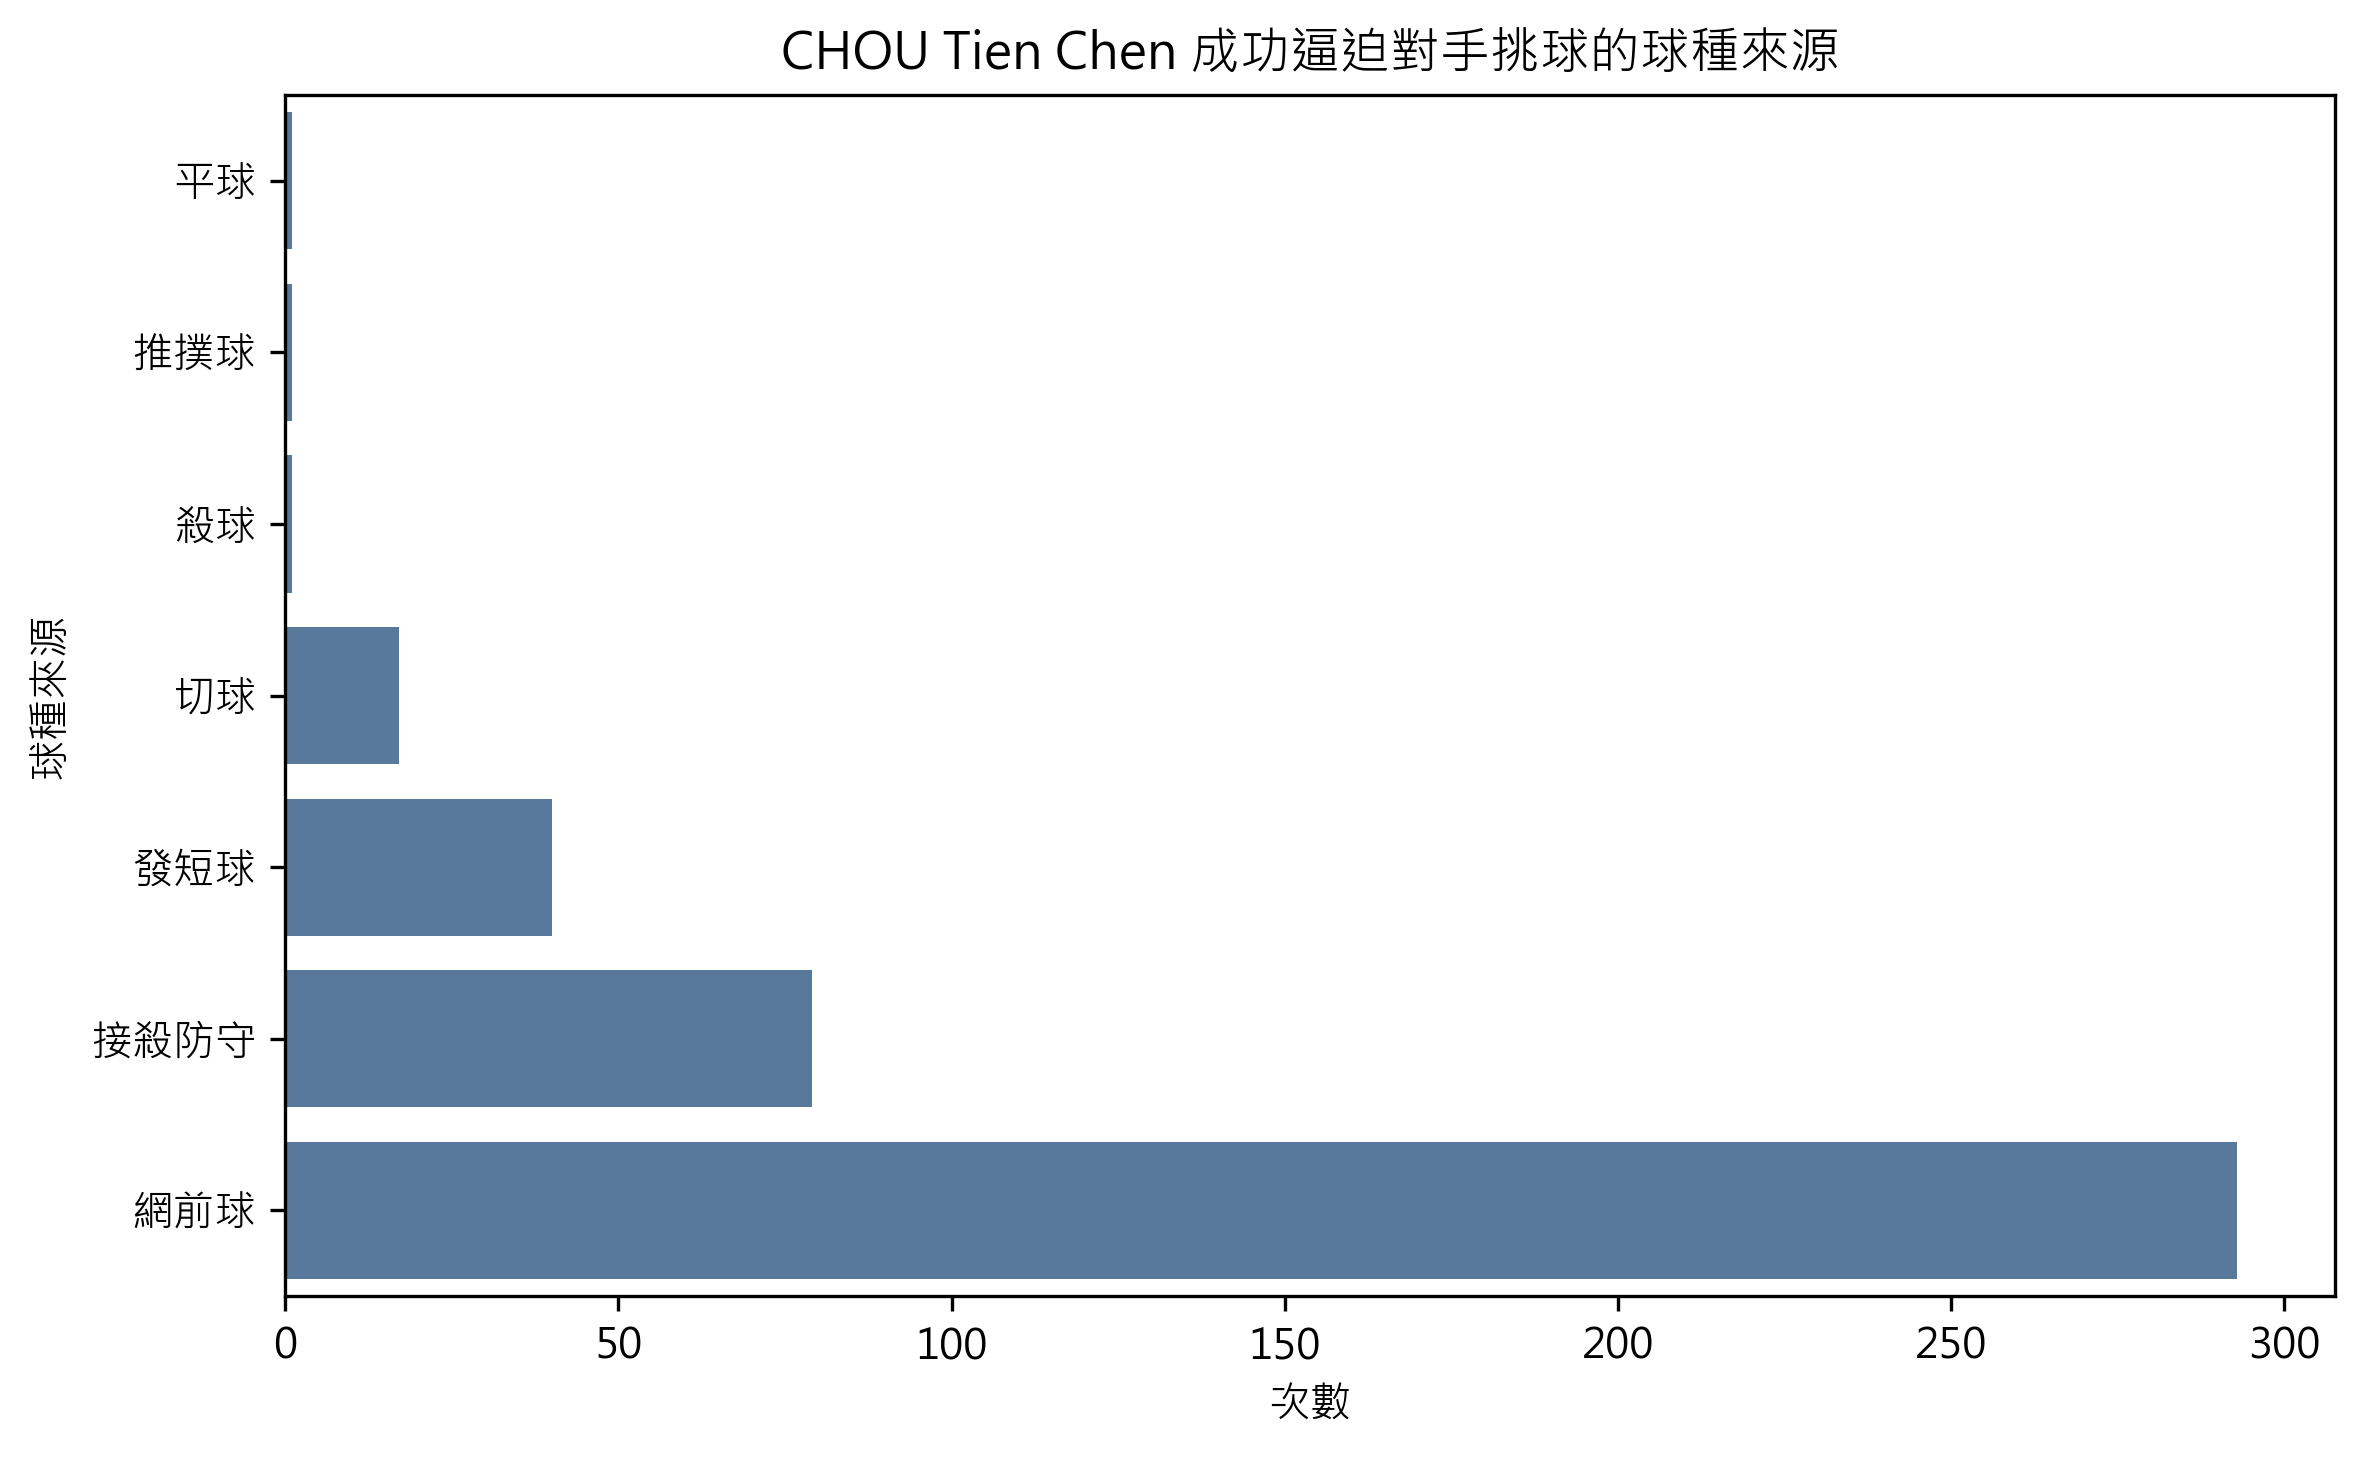

In [ ]:
required_cols = {"match_id", "set", "rally", "ball_round", "player", "opponent", "type"}
missing_cols = required_cols - set(df.columns)

if len(df) == 0:
    print("資料為空，無法進行分析。")
    fig = plt.figure(figsize=(8, 5))
elif missing_cols:
    print(f"缺少必要欄位：{sorted(missing_cols)}")
    fig = plt.figure(figsize=(8, 5))
else:
    target_player = "CHOU Tien Chen"
    opponent_name = "Kento MOMOTA"

    work = df.sort_values(
        ["match_id", "set", "rally", "ball_round"]
    ).copy()

    group_cols = ["match_id", "set", "rally"]

    # 在完整資料上建立同一回合的下一拍資訊，避免先篩選造成時序錯位
    next_player = work.groupby(group_cols, sort=False)["player"].shift(-1)
    next_type = work.groupby(group_cols, sort=False)["type"].shift(-1)
    next_match = work.groupby(group_cols, sort=False)["match_id"].shift(-1)
    next_set = work.groupby(group_cols, sort=False)["set"].shift(-1)
    next_rally = work.groupby(group_cols, sort=False)["rally"].shift(-1)

    eligible = (
        work["player"].eq(target_player)
        & next_player.eq(opponent_name)
        & next_match.eq(work["match_id"])
        & next_set.eq(work["set"])
        & next_rally.eq(work["rally"])
        & next_type.notna()
    )

    eligible_events = work.loc[eligible, ["match_id", "set", "rally", "ball_round", "type"]].copy()
    eligible_events["next_type"] = next_type.loc[eligible].to_numpy()

    total_eligible_events = len(eligible_events)
    forced_lob_events = eligible_events[eligible_events["next_type"].eq("挑球")].copy()
    forced_lob_count = len(forced_lob_events)

    frequency = (
        forced_lob_count / total_eligible_events
        if total_eligible_events > 0
        else 0
    )

    source_counts = (
        forced_lob_events["type"]
        .value_counts()
        .rename_axis("造成對手挑球的球種來源")
        .reset_index(name="次數")
    )

    if len(source_counts) > 0:
        source_counts["頻率"] = source_counts["次數"] / forced_lob_count
        top_source = source_counts.iloc[0]["造成對手挑球的球種來源"]
        top_source_count = int(source_counts.iloc[0]["次數"])
    else:
        top_source = "無"
        top_source_count = 0

    print(f"分析主體：{target_player} 的擊球後，下一拍由對手擊出挑球")
    print(f"可觀察且由對手回擊的事件數：{total_eligible_events}")
    print(f"成功逼迫對手挑球次數：{forced_lob_count}")
    print(f"成功逼迫對手挑球頻率：{frequency:.2%}")
    print(f"最常造成對手挑球的球種來源：{top_source}（{top_source_count} 次）")

    if len(source_counts) > 0:
        print("\n各球種造成對手挑球的統計：")
        print(
            source_counts.to_string(
                index=False,
                formatters={"頻率": "{:.2%}".format}
            )
        )

        fig, ax = plt.subplots(figsize=(8, 5))
        plot_data = source_counts.sort_values("次數", ascending=True)
        sns.barplot(
            data=plot_data,
            x="次數",
            y="造成對手挑球的球種來源",
            color="#4C78A8",
            ax=ax
        )
        ax.set_title(f"{target_player} 成功逼迫對手挑球的球種來源")
        ax.set_xlabel("次數")
        ax.set_ylabel("球種來源")
        plt.tight_layout()
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(
            0.5, 0.5,
            "沒有找到對手下一拍挑球事件",
            ha="center",
            va="center",
            fontsize=13
        )
        ax.set_axis_off()
        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 83
**問題**: 周天成挑高球的落點分布，是否常造成對手容易得分？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）


場地定義：後場區域 1-4；中場區域 5-16；前場區域 17-24；左側出界 29-31；右側出界 25-27；後方出界 28、32。同一排由左至右依序為 A、B、C、D。
得分口徑：以該挑高球所在回合的最終 getpoint_player 判定；對手得分包含對手主動得分與周天成失誤。
符合條件的周天成挑高球事件數：253
挑高球後對手得分次數：131
挑高球後對手得分率：51.78%

依挑高球落點區域統計：
 landing_area 落點類別  落點位置  挑高球次數 落點分布占比  對手得分次數  對手得分率
            3   後場 後場-中右     54 21.34%      35 64.81%
            6   中場 中場-中左      9  3.56%       5 55.56%
            4   後場  後場-右     79 31.23%      42 53.16%
            8   中場  中場-右     19  7.51%      10 52.63%
            5   中場  中場-左     21  8.30%      11 52.38%
            2   後場 後場-中左     10  3.95%       5 50.00%
            1   後場  後場-左     28 11.07%      12 42.86%
            7   中場 中場-中右     27 10.67%      10 37.04%
           10   中場 中場-中左      3  1.19%       1 33.33%
            9   中場  中場-左      1  0.40%       0  0.00%
           11   中場 中場-中右      1  0.40%       0  0.00%
           12   中場  中場-右      1  0.40%       0  0.00%
…（輸出已截斷；notebook 僅保留重點）


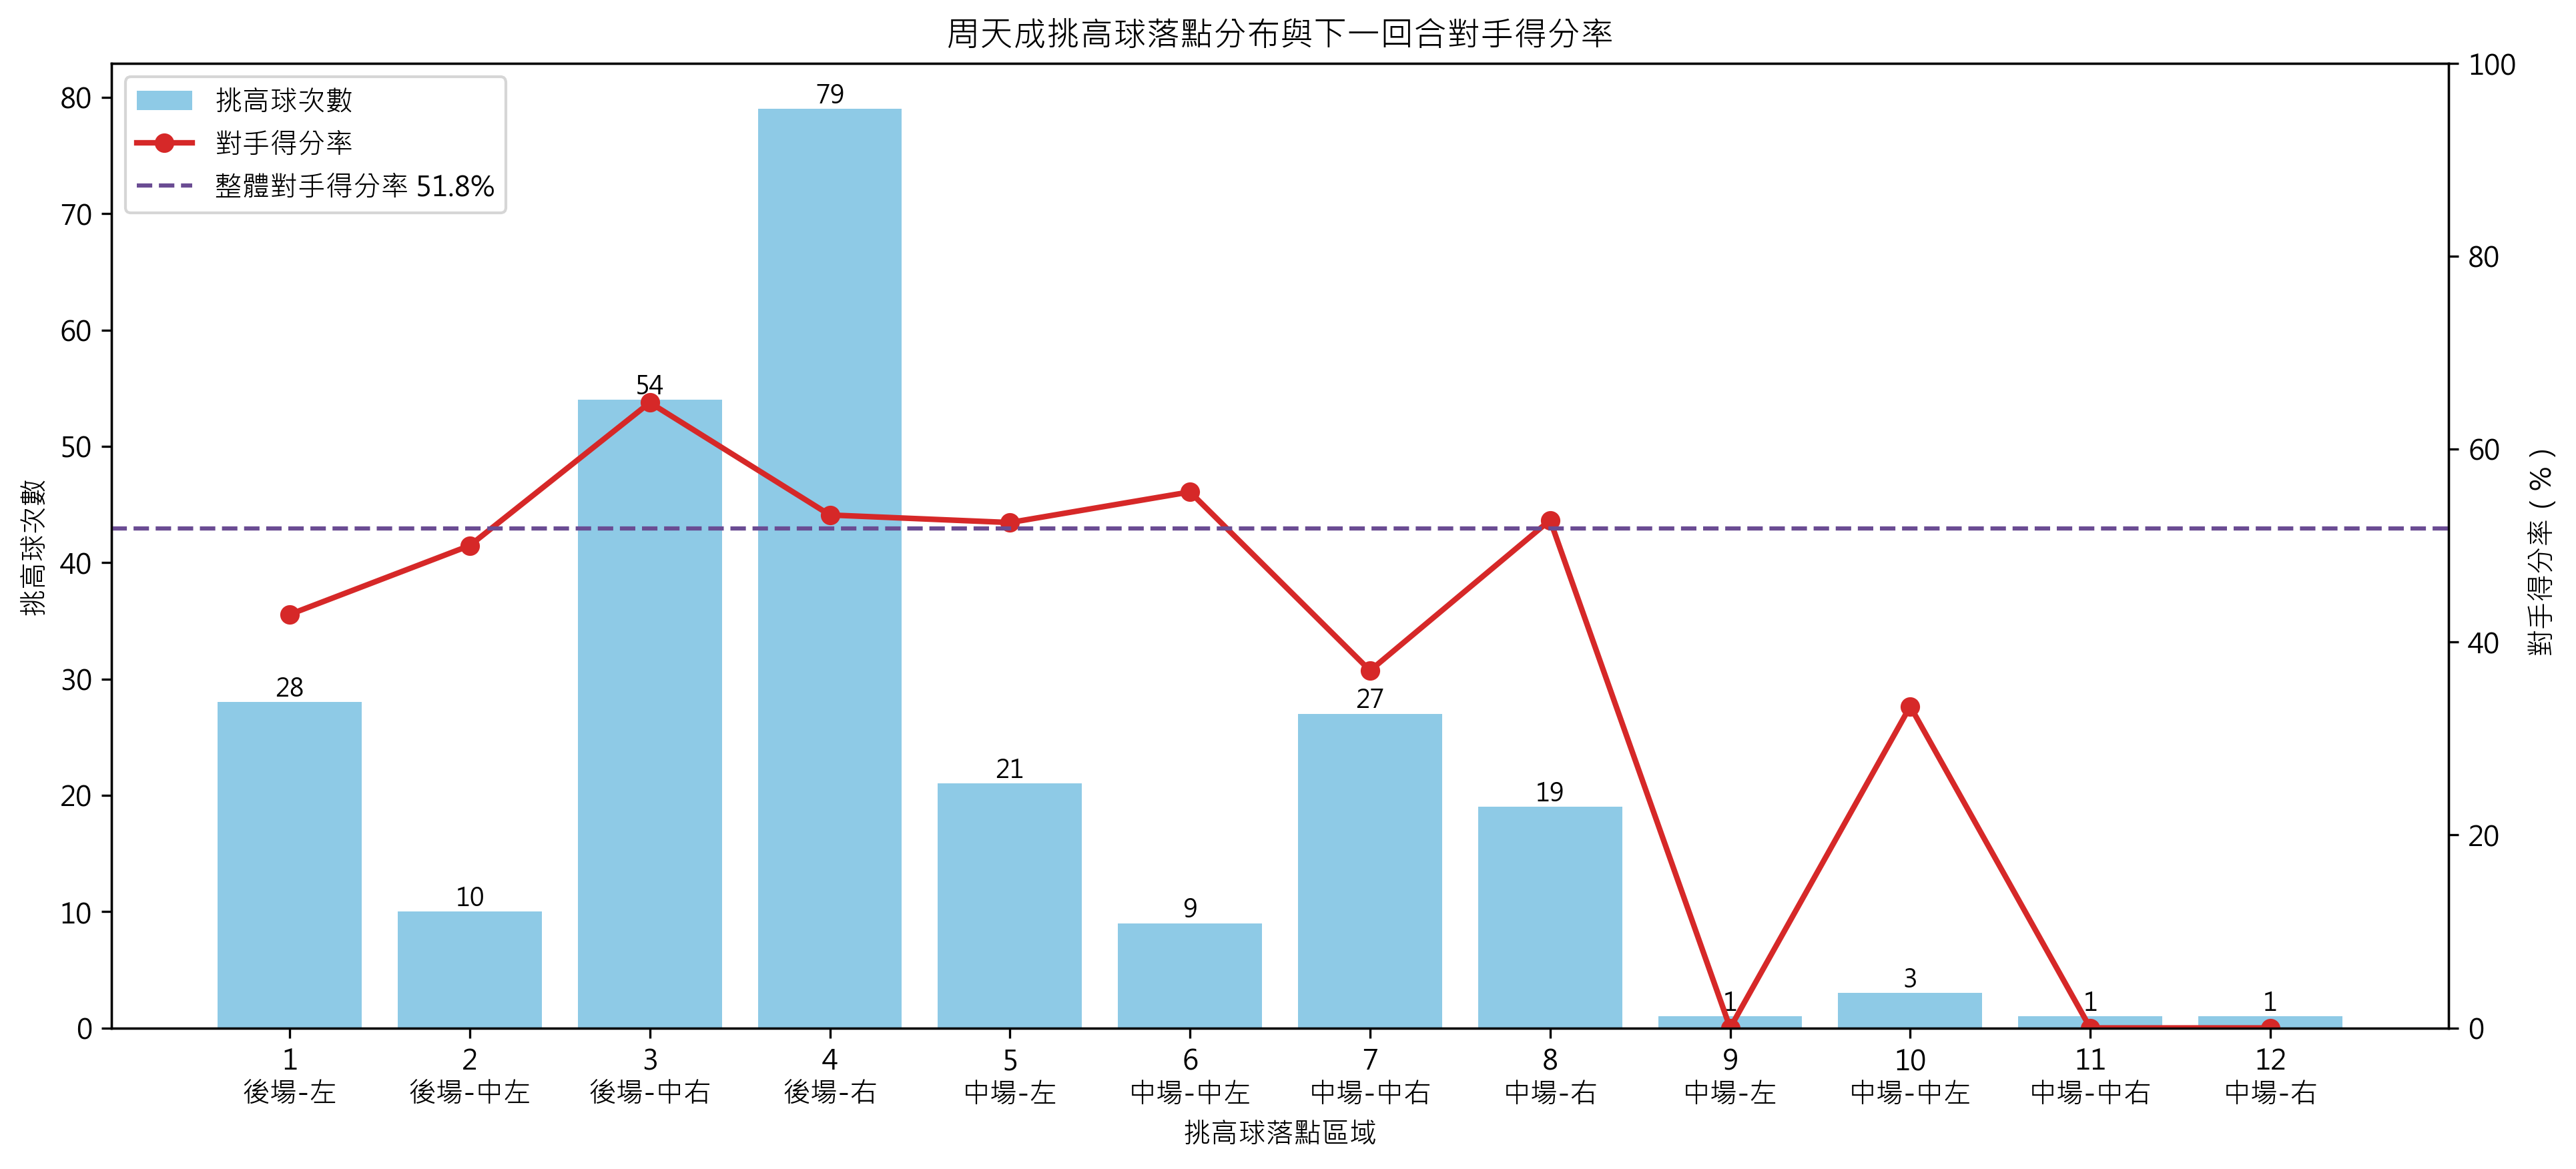

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'landing_area', 'getpoint_player'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print('資料為空，無法進行分析。')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title('周天成挑高球後對手得分分析')
    ax.text(0.5, 0.5, '無資料', ha='center', va='center')
    ax.axis('off')
    plt.tight_layout()
elif len(missing_cols) > 0:
    raise ValueError(f'缺少必要欄位：{missing_cols}')
else:
    player_name = 'CHOU Tien Chen'
    opponent_name = 'Kento MOMOTA'

    work_df = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    rally_keys = ['match_id', 'set', 'rally']

    # 在完整逐拍資料上建立同一回合的下一拍資訊，避免跨回合污染
    work_df['next_player'] = work_df.groupby(rally_keys)['player'].shift(-1)
    work_df['next_ball_round'] = work_df.groupby(rally_keys)['ball_round'].shift(-1)

    # 回合最終得分者：getpoint_player 只在回合最後一拍記錄
    work_df['rally_getpoint_player'] = (
        work_df.groupby(rally_keys)['getpoint_player'].transform('last')
    )

    # 分析主體：周天成挑高球，且確實存在同一回合的下一拍對手擊球
    event_df = work_df[
        (work_df['player'] == player_name) &
        (work_df['type'] == '挑球') &
        (work_df['next_player'] == opponent_name) &
        (work_df['landing_area'].notna()) &
        (work_df['rally_getpoint_player'].notna())
    ].copy()

    court_grid_definitions = (
        '場地定義：後場區域 1-4；中場區域 5-16；前場區域 17-24；'
        '左側出界 29-31；右側出界 25-27；後方出界 28、32。'
        '同一排由左至右依序為 A、B、C、D。'
    )
    print(court_grid_definitions)
    print('得分口徑：以該挑高球所在回合的最終 getpoint_player 判定；'
          '對手得分包含對手主動得分與周天成失誤。')

    def get_landing_description(zone):
        zone = int(zone)

        if 1 <= zone <= 4:
            columns = ['左', '中左', '中右', '右']
            return '後場', f'後場-{columns[zone - 1]}'
        elif 5 <= zone <= 8:
            columns = ['左', '中左', '中右', '右']
            return '中場', f'中場-{columns[zone - 5]}'
        elif 9 <= zone <= 12:
            columns = ['左', '中左', '中右', '右']
            return '中場', f'中場-{columns[zone - 9]}'
        elif 13 <= zone <= 16:
            columns = ['左', '中左', '中右', '右']
            return '中場', f'中場-{columns[zone - 13]}'
        elif 17 <= zone <= 20:
            columns = ['左', '中左', '中右', '右']
            return '前場', f'前場-{columns[zone - 17]}'
        elif 21 <= zone <= 24:
            columns = ['左', '中左', '中右', '右']
            return '前場', f'前場-{columns[zone - 21]}'
        elif zone == 25:
            return '右側出界', '右側出界-上'
        elif zone == 26:
            return '右側出界', '右側出界-中'
        elif zone == 27:
            return '右側出界', '右側出界-下'
        elif zone == 28:
            return '後方出界', '後方出界-右'
        elif zone == 29:
            return '左側出界', '左側出界-上'
        elif zone == 30:
            return '左側出界', '左側出界-中'
        elif zone == 31:
            return '左側出界', '左側出界-下'
        elif zone == 32:
            return '後方出界', '後方出界-左'
        else:
            return '未知區域', f'區域-{zone}'

    if len(event_df) == 0:
        print('沒有符合條件的「周天成挑高球後、對手下一拍擊球且回合有最終得分者」事件。')
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title('周天成挑高球後對手得分分析')
        ax.text(0.5, 0.5, '無符合條件的事件', ha='center', va='center')
        ax.axis('off')
        plt.tight_layout()
    else:
        event_df['landing_area'] = event_df['landing_area'].astype(int)
        event_df['opponent_scored'] = (
            event_df['rally_getpoint_player'] == opponent_name
        )

        area_summary = (
            event_df.groupby('landing_area', as_index=False)
            .agg(
                挑高球次數=('landing_area', 'size'),
                對手得分次數=('opponent_scored', 'sum'),
                對手得分率=('opponent_scored', 'mean')
            )
        )

        area_summary['落點分布占比'] = (
            area_summary['挑高球次數'] / area_summary['挑高球次數'].sum()
        )

        descriptions = area_summary['landing_area'].apply(get_landing_description)
        area_summary['落點類別'] = descriptions.str[0]
        area_summary['落點位置'] = descriptions.str[1]
        area_summary['對手得分率'] = area_summary['對手得分率'] * 100
        area_summary['落點分布占比'] = area_summary['落點分布占比'] * 100

        area_summary = area_summary.sort_values(
            ['對手得分率', '挑高球次數'],
            ascending=[False, False]
        ).reset_index(drop=True)

        total_events = len(event_df)
        total_opponent_scores = int(event_df['opponent_scored'].sum())
        overall_opponent_score_rate = (
            total_opponent_scores / total_events * 100
        )

        print(f'符合條件的周天成挑高球事件數：{total_events}')
        print(f'挑高球後對手得分次數：{total_opponent_scores}')
        print(f'挑高球後對手得分率：{overall_opponent_score_rate:.2f}%')
        print('\n依挑高球落點區域統計：')
        print(
            area_summary[
                [
                    'landing_area', '落點類別', '落點位置',
                    '挑高球次數', '落點分布占比',
                    '對手得分次數', '對手得分率'
                ]
            ].to_string(
                index=False,
                formatters={
                    '落點分布占比': '{:.2f}%'.format,
                    '對手得分率': '{:.2f}%'.format
                }
            )
        )

        top_area = area_summary.iloc[0]
        print(
            f'\n對手得分率最高的落點：{int(top_area["landing_area"])} '
            f'（{top_area["落點位置"]}），'
            f'對手得分率 {top_area["對手得分率"]:.2f}%，'
            f'樣本數 {int(top_area["挑高球次數"])}。'
        )

        plot_df = area_summary.sort_values('landing_area').copy()
        plot_df['區域標籤'] = plot_df.apply(
            lambda row: f'{int(row["landing_area"])}\n{row["落點位置"]}',
            axis=1
        )

        fig, ax1 = plt.subplots(figsize=(13, 6))

        bars = ax1.bar(
            plot_df['區域標籤'],
            plot_df['挑高球次數'],
            color='#8ecae6',
            label='挑高球次數'
        )
        ax1.set_xlabel('挑高球落點區域')
        ax1.set_ylabel('挑高球次數')
        ax1.set_title('周天成挑高球落點分布與下一回合對手得分率')
        ax1.tick_params(axis='x', rotation=0)

        ax2 = ax1.twinx()
        ax2.plot(
            plot_df['區域標籤'],
            plot_df['對手得分率'],
            color='#d62828',
            marker='o',
            linewidth=2,
            label='對手得分率'
        )
        ax2.axhline(
            overall_opponent_score_rate,
            color='#6a4c93',
            linestyle='--',
            linewidth=1.5,
            label=f'整體對手得分率 {overall_opponent_score_rate:.1f}%'
        )
        ax2.set_ylabel('對手得分率（%）')
        ax2.set_ylim(0, 100)

        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(
            handles1 + handles2,
            labels1 + labels2,
            loc='upper left'
        )

        for bar in bars:
            height = bar.get_height()
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9
            )

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 84
**問題**: 當周天成採取多拍耐心拉吊策略時的平均勝率。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


統計口徑：
- 統計單位：每回合
- 策略定義：至少 6 拍、周天成至少擊球 2 拍，且同回合同時使用長球與切球
- 得分口徑：該回合最後一拍的 getpoint_player
符合策略且 getpoint_player 非空的回合數：72
周天成贏得回合數：31
周天成未贏得回合數：41
周天成採取多拍耐心拉吊策略時的平均勝率：43.06%

結果明細：
    結果  回合數     比例(%)
 周天成得分   31 43.055556
周天成未得分   41 56.944444


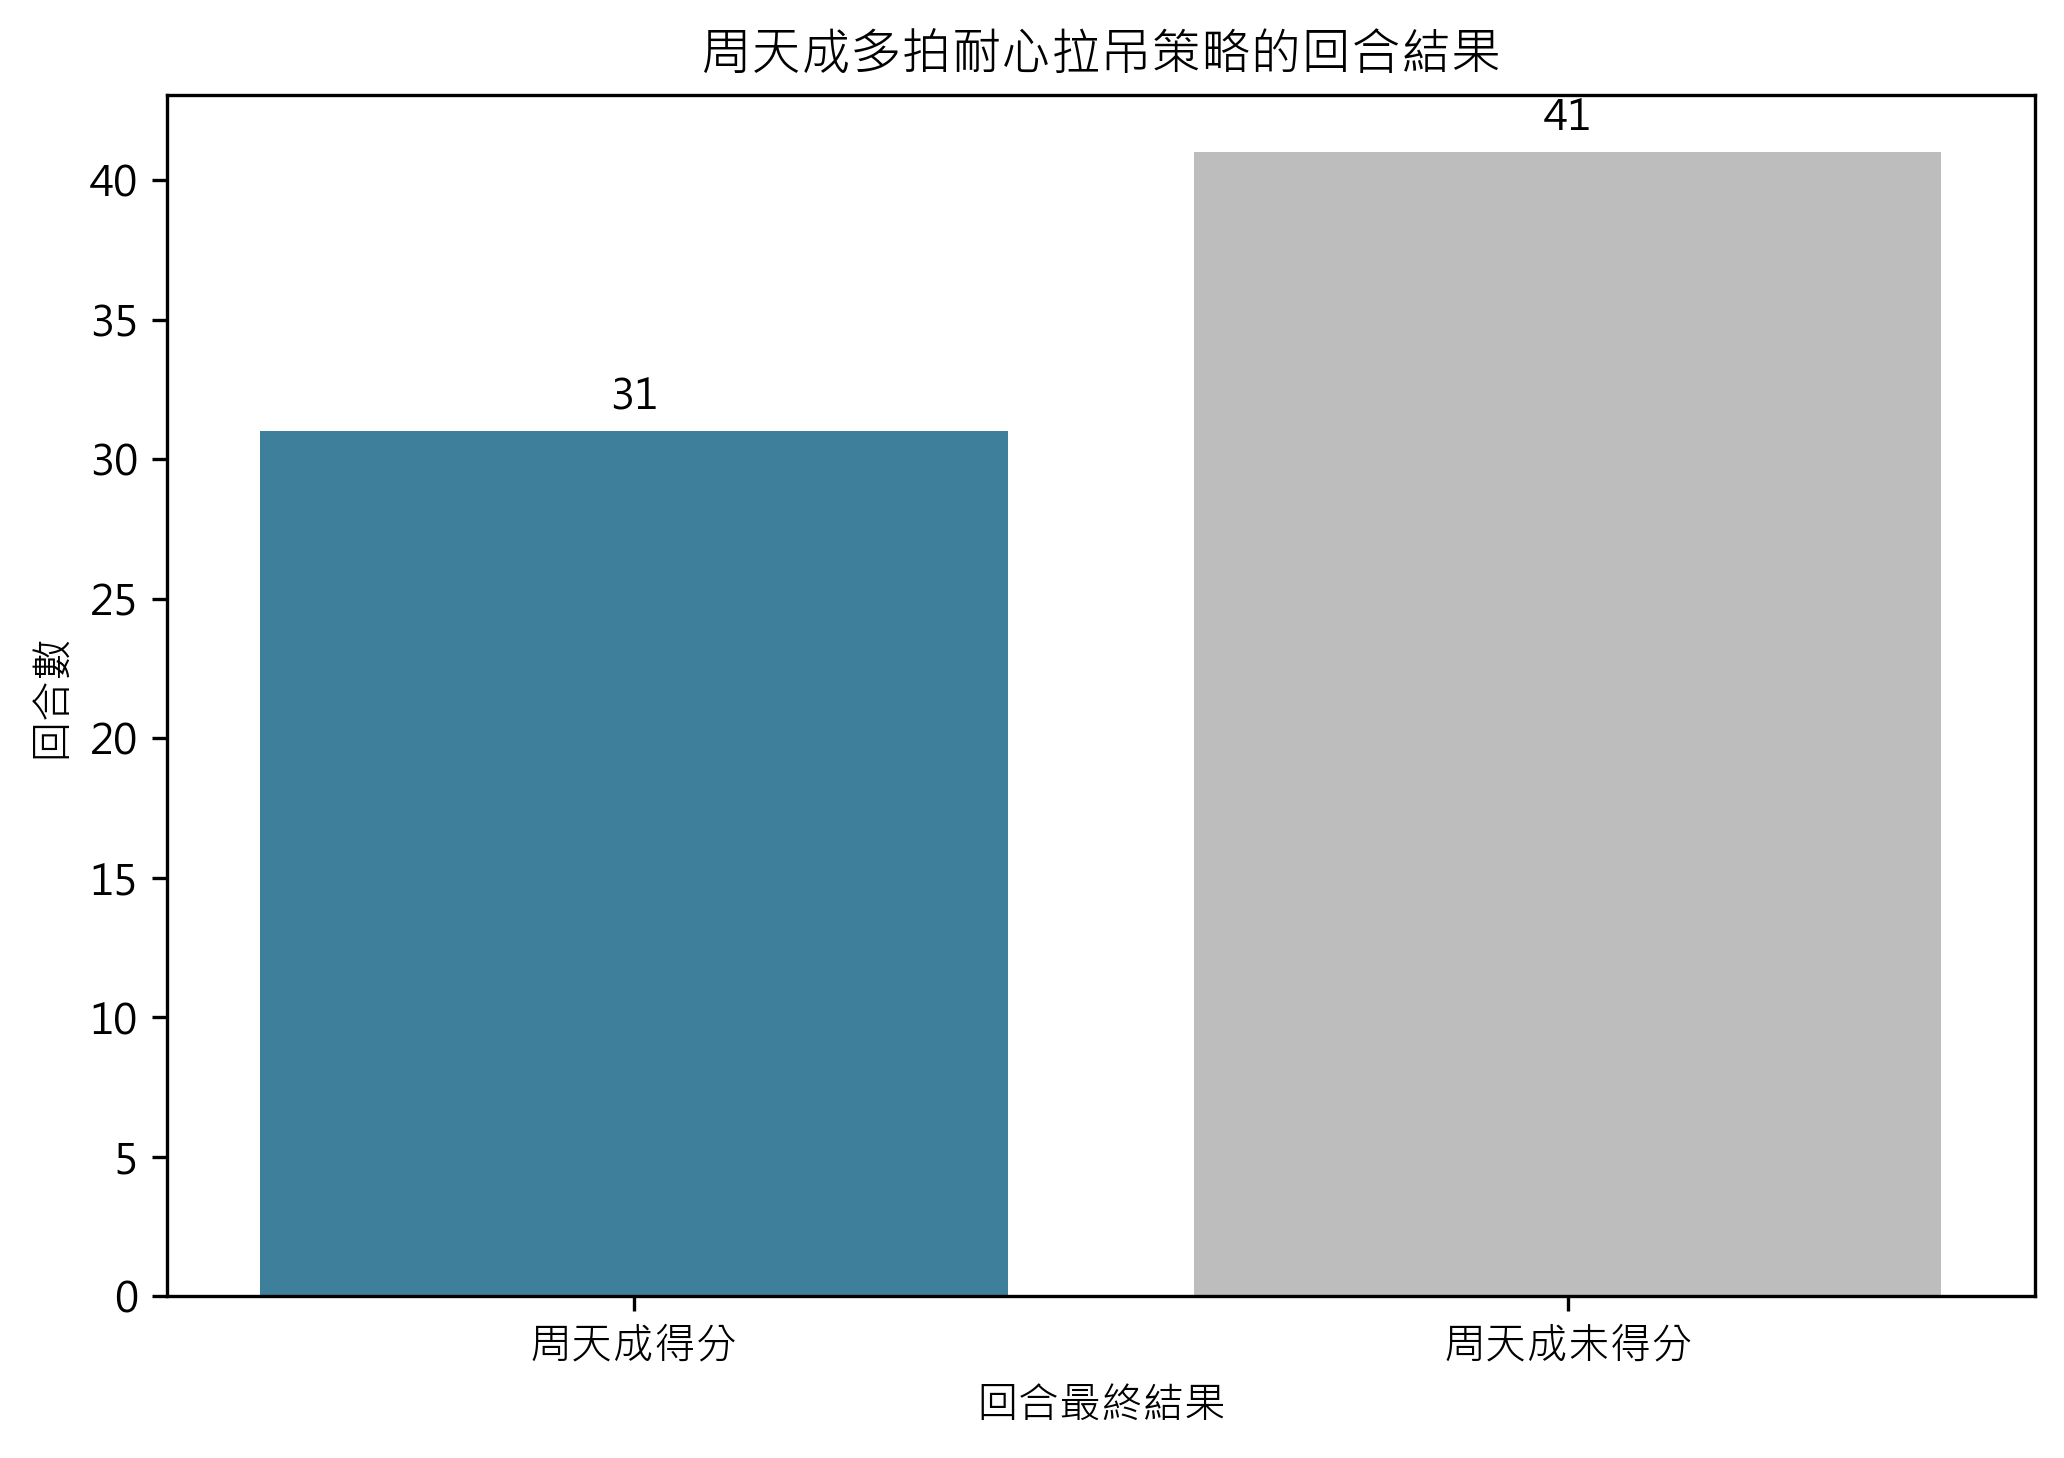

In [ ]:
import pandas as pd

fig, ax = plt.subplots(figsize=(7, 5))

required_cols = {
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'type', 'getpoint_player'
}

if len(df) == 0:
    ax.text(0.5, 0.5, '資料為空，無法分析', ha='center', va='center')
    ax.set_axis_off()
    plt.tight_layout()
    print('資料為空，無法分析。')
else:
    missing_cols = required_cols.difference(df.columns)

    if missing_cols:
        ax.text(0.5, 0.5, '缺少必要欄位', ha='center', va='center')
        ax.set_axis_off()
        plt.tight_layout()
        print(f'缺少必要欄位：{sorted(missing_cols)}')
    else:
        target_player = 'CHOU Tien Chen'
        rally_keys = ['match_id', 'set', 'rally']

        work = df.copy()
        work = work.sort_values(rally_keys + ['ball_round']).reset_index(drop=True)

        # 「多拍耐心拉吊」操作化定義：
        # 同一回合至少 6 拍、周天成至少擊球 2 拍，
        # 且周天成同一回合中同時使用長球與切球。
        work['_target_long'] = (
            (work['player'] == target_player) &
            (work['type'] == '長球')
        )
        work['_target_drop'] = (
            (work['player'] == target_player) &
            (work['type'] == '切球')
        )
        work['_target_shot'] = work['player'].eq(target_player)

        rally_summary = (
            work.groupby(rally_keys, as_index=False, sort=False)
            .agg(
                total_shots=('ball_round', 'count'),
                target_shots=('_target_shot', 'sum'),
                has_long=('_target_long', 'any'),
                has_drop=('_target_drop', 'any')
            )
        )

        # 取每個完整回合的最後一拍，取得回合最終得分者。
        final_rallies = (
            work.groupby(rally_keys, sort=False, as_index=False)
            .tail(1)[rally_keys + ['getpoint_player']]
        )

        rally_summary = rally_summary.merge(
            final_rallies,
            on=rally_keys,
            how='left',
            validate='one_to_one'
        )

        strategy_rallies = rally_summary[
            (rally_summary['total_shots'] >= 6) &
            (rally_summary['target_shots'] >= 2) &
            rally_summary['has_long'] &
            rally_summary['has_drop'] &
            rally_summary['getpoint_player'].notna()
        ].copy()

        if len(strategy_rallies) == 0:
            ax.text(
                0.5, 0.5,
                '沒有符合「多拍耐心拉吊」定義的完整回合',
                ha='center',
                va='center'
            )
            ax.set_axis_off()
            plt.tight_layout()

            print('統計口徑：至少 6 拍、周天成至少擊球 2 拍，且同回合同時使用長球與切球。')
            print('沒有符合條件且具回合最終得分者的回合。')
        else:
            strategy_rallies['周天成是否贏得回合'] = (
                strategy_rallies['getpoint_player'] == target_player
            )

            total_rallies = len(strategy_rallies)
            wins = int(strategy_rallies['周天成是否贏得回合'].sum())
            losses = total_rallies - wins
            win_rate = wins / total_rallies

            result_table = pd.DataFrame({
                '結果': ['周天成得分', '周天成未得分'],
                '回合數': [wins, losses],
                '比例(%)': [
                    wins / total_rallies * 100,
                    losses / total_rallies * 100
                ]
            })

            print('統計口徑：')
            print('- 統計單位：每回合')
            print('- 策略定義：至少 6 拍、周天成至少擊球 2 拍，且同回合同時使用長球與切球')
            print('- 得分口徑：該回合最後一拍的 getpoint_player')
            print(f'符合策略且 getpoint_player 非空的回合數：{total_rallies}')
            print(f'周天成贏得回合數：{wins}')
            print(f'周天成未贏得回合數：{losses}')
            print(f'周天成採取多拍耐心拉吊策略時的平均勝率：{win_rate:.2%}')
            print('\n結果明細：')
            print(result_table.to_string(index=False))

            sns.barplot(
                data=result_table,
                x='結果',
                y='回合數',
                hue='結果',
                palette=['#2E86AB', '#BDBDBD'],
                legend=False,
                ax=ax
            )
            ax.set_title('周天成多拍耐心拉吊策略的回合結果')
            ax.set_xlabel('回合最終結果')
            ax.set_ylabel('回合數')

            for container in ax.containers:
                ax.bar_label(container, fmt='%d', padding=3)

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 85
**問題**: 統計周天成經常「從防守轉攻擊得分」的常見回合模式。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


周天成主動得分回合數：85
符合防守轉攻擊得分回合數：47
常見回合模式：
        模式  回合數  占周天成主動得分比例(%)
   挑球 → 殺球   19          22.35
 接殺防守 → 殺球   16          18.82
  挑球 → 推撲球    3           3.53
接殺防守 → 網前球    3           3.53
  挑球 → 網前球    1           1.18
   挑球 → 長球    1           1.18
 接殺防守 → 切球    1           1.18
 接殺防守 → 平球    1           1.18
接殺防守 → 推撲球    1           1.18
 接殺防守 → 長球    1           1.18


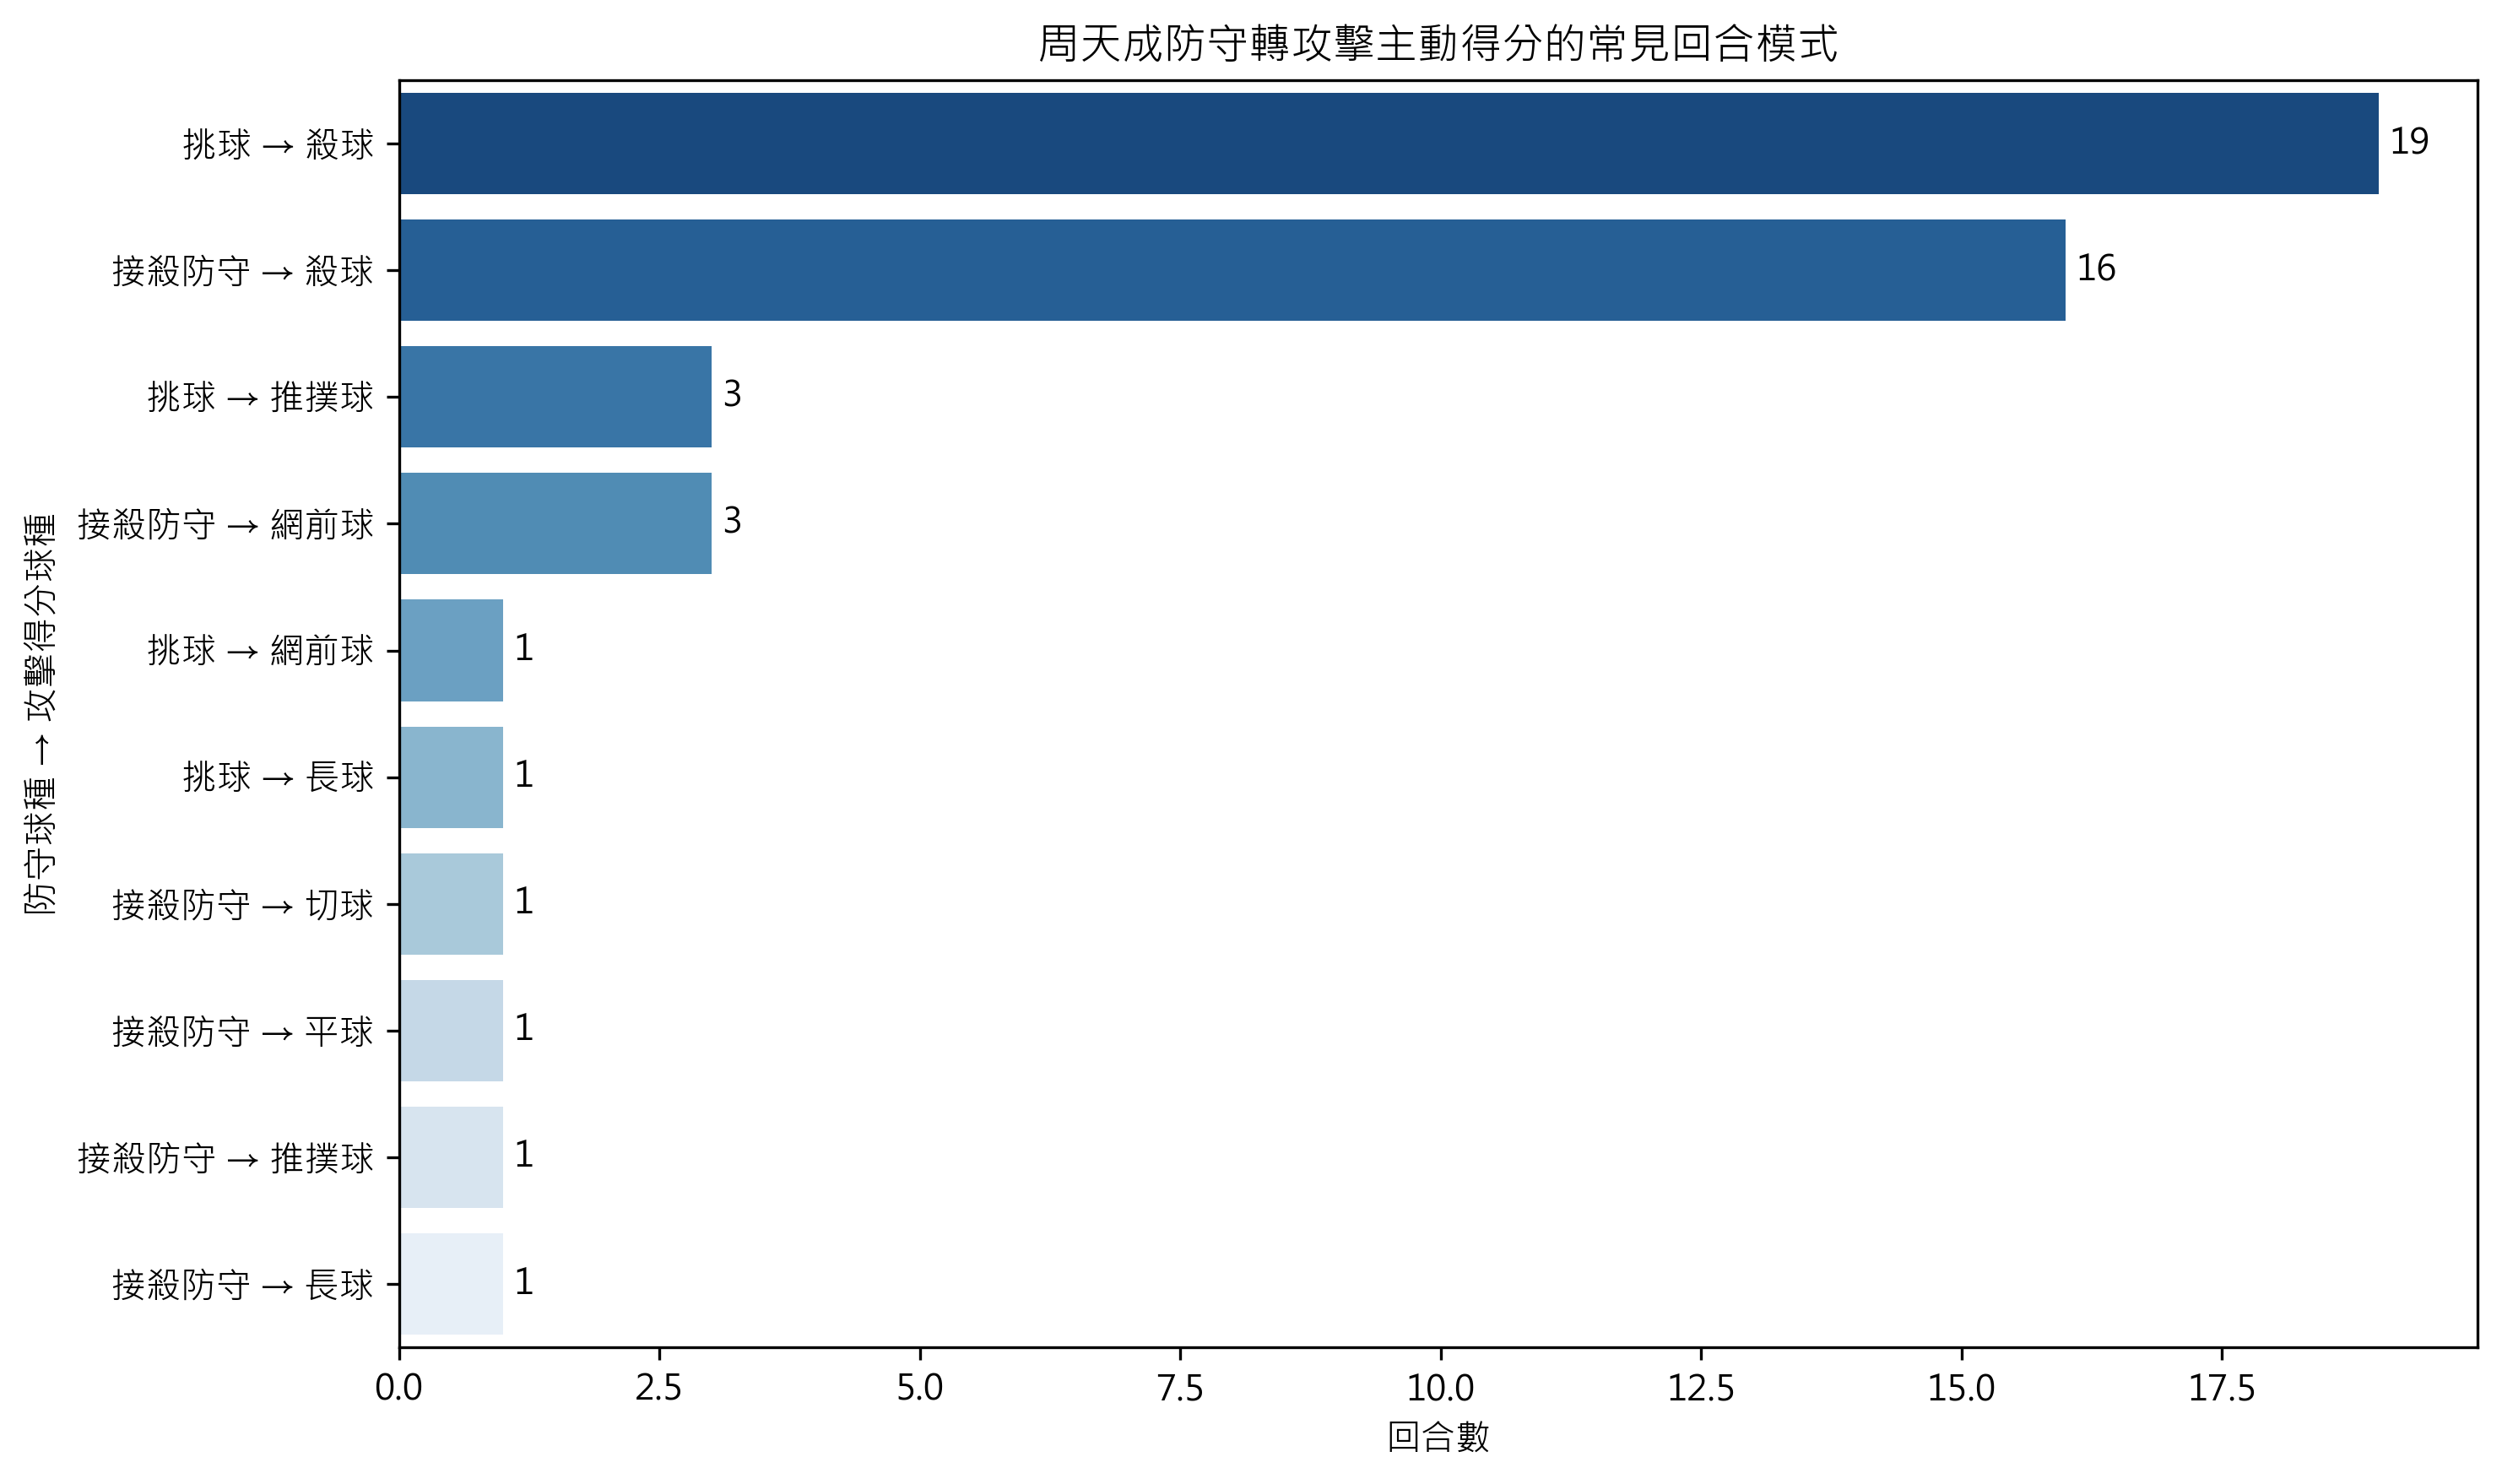

In [ ]:
required_columns = [
    'match_id', 'set', 'rally', 'ball_round', 'player',
    'getpoint_player', 'type'
]

missing_columns = [col for col in required_columns if col not in df.columns]

if len(df) == 0:
    print('資料為空，無法進行統計。')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title('周天成防守轉攻擊得分模式')
    ax.axis('off')
elif missing_columns:
    print(f'缺少必要欄位：{missing_columns}')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title('周天成防守轉攻擊得分模式')
    ax.axis('off')
else:
    player_name = 'CHOU Tien Chen'
    rally_keys = ['match_id', 'set', 'rally']

    defensive_types = ['接殺防守', '挑球']
    attacking_types = ['殺球', '推撲球', '平球', '網前球', '切球', '長球']

    work_df = df.sort_values(
        rally_keys + ['ball_round'],
        kind='stable'
    ).copy()

    valid_work_df = work_df.dropna(
        subset=['match_id', 'set', 'rally', 'ball_round', 'player', 'type']
    ).copy()

    pattern_records = []
    active_winning_rallies = 0

    for rally_key, rally_df in valid_work_df.groupby(rally_keys, sort=False):
        rally_df = rally_df.sort_values('ball_round', kind='stable')

        scoring_rows = rally_df.dropna(subset=['getpoint_player'])
        if len(scoring_rows) == 0:
            continue

        scoring_row = scoring_rows.iloc[-1]

        # 僅納入周天成主動得分，避免把對手失誤誤算為周天成的攻擊得分
        is_active_win = (
            scoring_row['player'] == player_name and
            scoring_row['getpoint_player'] == player_name
        )

        if not is_active_win:
            continue

        active_winning_rallies += 1

        # 「轉攻擊得分」要求最後一拍為周天成的攻擊型球種
        if (
            scoring_row['player'] != player_name or
            scoring_row['type'] not in attacking_types
        ):
            continue

        scoring_ball_round = scoring_row['ball_round']

        previous_player_shots = rally_df[
            (rally_df['player'] == player_name) &
            (rally_df['ball_round'] < scoring_ball_round)
        ]

        defensive_shots = previous_player_shots[
            previous_player_shots['type'].isin(defensive_types)
        ]

        if len(defensive_shots) == 0:
            continue

        defensive_row = defensive_shots.iloc[-1]

        pattern_records.append({
            'match_id': rally_key[0],
            'set': rally_key[1],
            'rally': rally_key[2],
            '防守球種': defensive_row['type'],
            '攻擊得分球種': scoring_row['type'],
            '模式': f"{defensive_row['type']} → {scoring_row['type']}"
        })

    pattern_df = pd.DataFrame(pattern_records)

    if len(pattern_df) == 0:
        print(f'周天成主動得分回合數：{active_winning_rallies}')
        print('沒有找到符合「防守球種後，以攻擊球種主動得分」的回合模式。')

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title('周天成防守轉攻擊得分模式')
        ax.text(
            0.5, 0.5,
            '沒有符合條件的回合',
            ha='center',
            va='center',
            fontsize=14
        )
        ax.axis('off')
        plt.tight_layout()
    else:
        pattern_counts = (
            pattern_df.groupby(
                ['防守球種', '攻擊得分球種', '模式'],
                as_index=False
            )
            .size()
            .rename(columns={'size': '回合數'})
            .sort_values(
                ['回合數', '模式'],
                ascending=[False, True]
            )
            .reset_index(drop=True)
        )

        pattern_counts['占周天成主動得分比例(%)'] = (
            pattern_counts['回合數'] /
            active_winning_rallies *
            100
        ).round(2)

        print(f'周天成主動得分回合數：{active_winning_rallies}')
        print(f'符合防守轉攻擊得分回合數：{len(pattern_df)}')
        print('常見回合模式：')
        print(
            pattern_counts[
                [
                    '模式',
                    '回合數',
                    '占周天成主動得分比例(%)'
                ]
            ].to_string(index=False)
        )

        plot_df = pattern_counts.copy()
        plot_df['圖表標籤'] = plot_df['模式'].astype(str)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(
            data=plot_df,
            x='回合數',
            y='圖表標籤',
            hue='圖表標籤',
            palette='Blues_r',
            legend=False,
            ax=ax
        )

        ax.set_title('周天成防守轉攻擊主動得分的常見回合模式')
        ax.set_xlabel('回合數')
        ax.set_ylabel('防守球種 → 攻擊得分球種')

        for container in ax.containers:
            ax.bar_label(container, fmt='%d', padding=3)

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 88
**問題**: 對手若習慣在第三拍主動攻擊，周天成應該如何設計接發策略，在前三拍就破壞對手節奏並轉守為攻？
> **使用的資料欄位群組**: `game_structure, shot_type, player_location`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


分析對象：CHOU Tien Chen 接發、對手第三拍主動攻擊
統計單位：同一 match_id、set、rally 的前三拍，並觀察第四拍
周天成接發且有完整第四拍的回合數：201
對手第三拍主動攻擊回合數：58
對手第三拍主動攻擊比例：28.9%
主動攻擊球種定義：殺球, 推撲球, 平球

對手第三拍攻擊分布：
對手第三拍攻擊球種  回合數  比例(%)
       殺球   31   53.4
      推撲球   21   36.2
       平球    6   10.3

周天成面對第三拍攻擊的第四拍回應：
周天成第四拍回應球種  回合數  周天成第四拍回應比例(%)
      接殺防守   32           55.2
        平球    9           15.5
        殺球    7           12.1
        長球    5            8.6
        切球    5            8.6
…（輸出已截斷；notebook 僅保留重點）


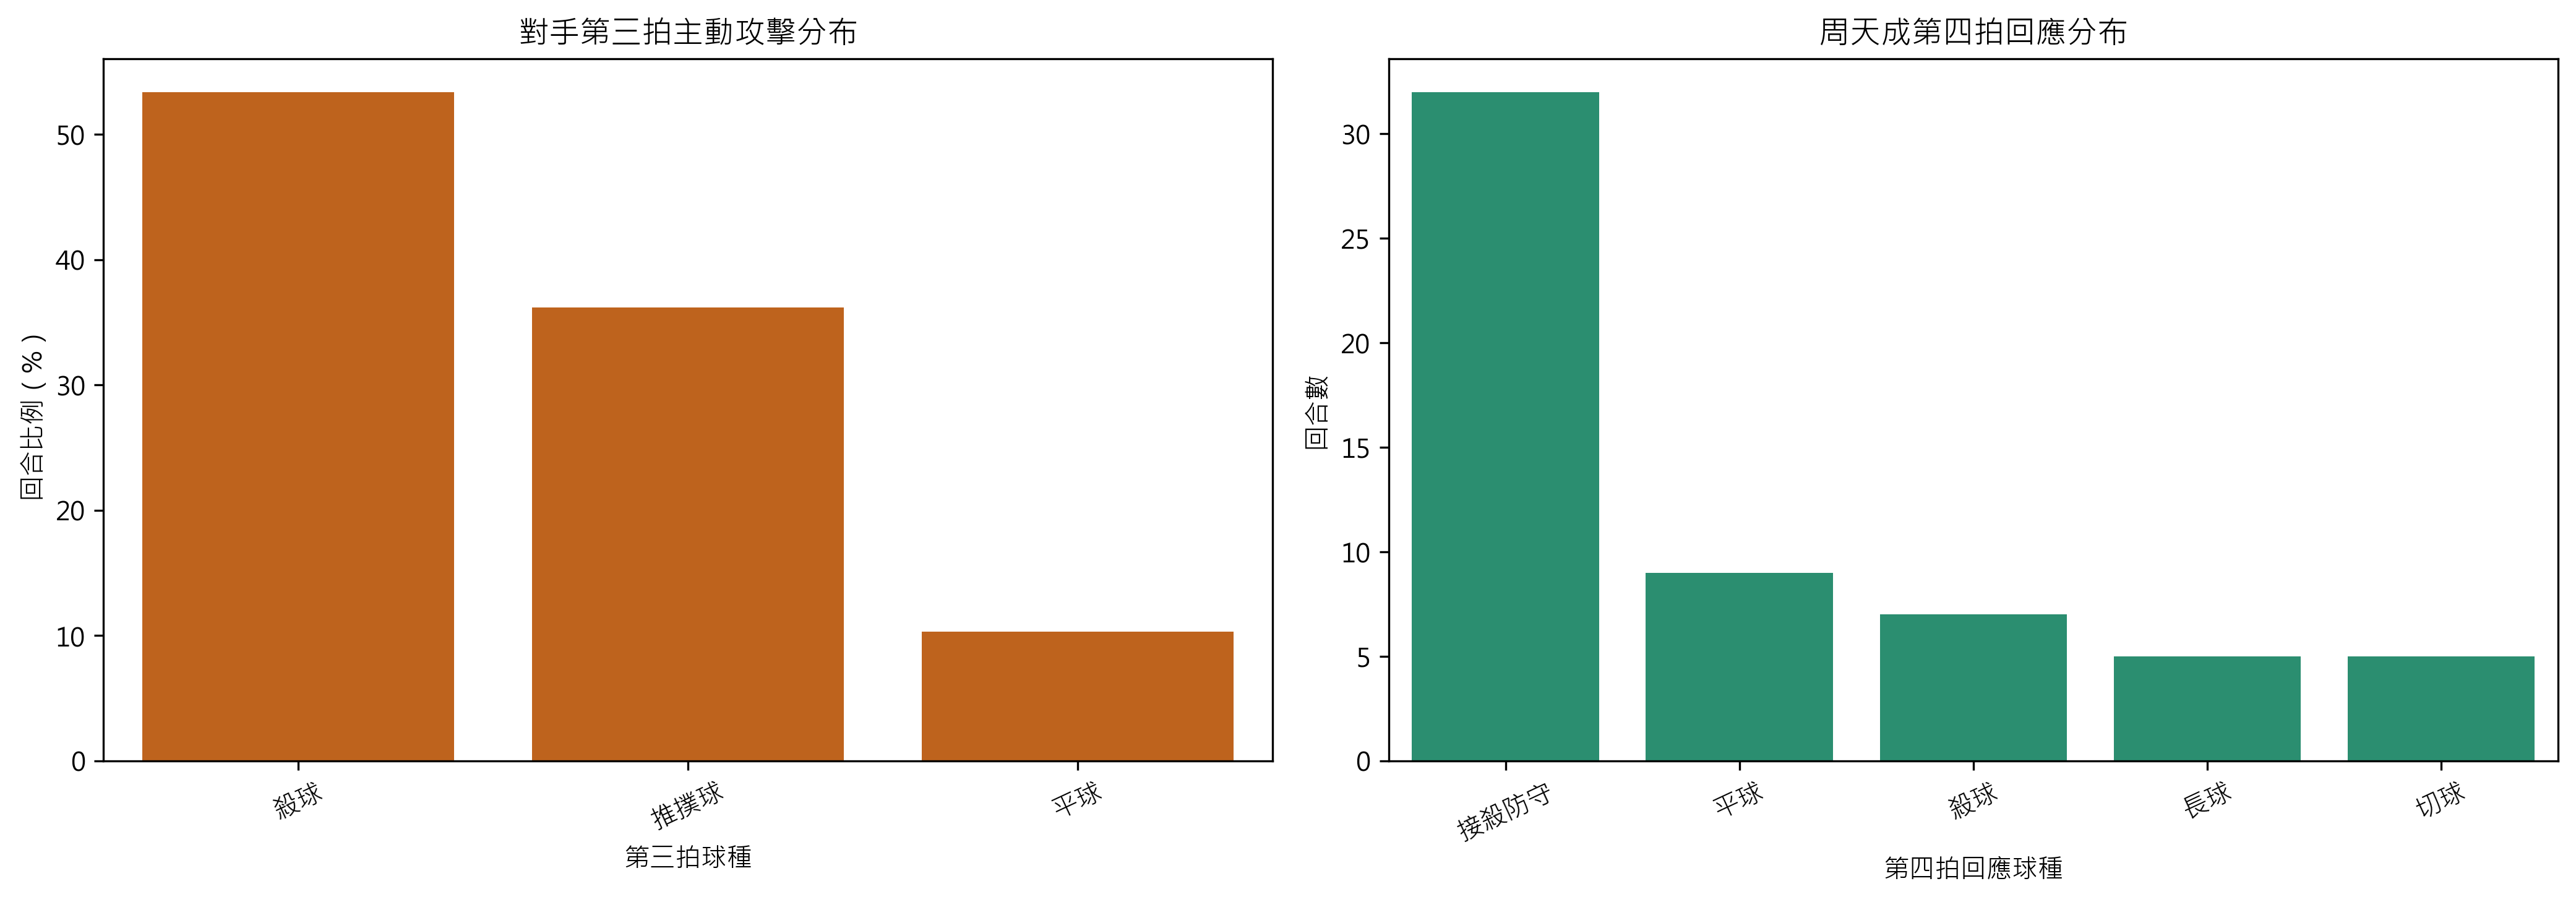

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent', 'type'
]

if len(df) == 0:
    raise ValueError("df 沒有資料，無法分析。")

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")

chou = 'CHOU Tien Chen'
opponent_names = [x for x in df['player'].dropna().unique() if x != chou]

if len(opponent_names) == 0:
    raise ValueError("資料中找不到周天成的對手。")

opponent = opponent_names[0]
group_cols = ['match_id', 'set', 'rally']

work = df[required_cols].copy()
work = work.dropna(subset=['match_id', 'set', 'rally', 'ball_round', 'player', 'opponent', 'type'])
work = work.sort_values(group_cols + ['ball_round'], kind='stable').reset_index(drop=True)

work['shot_index'] = work.groupby(group_cols).cumcount() + 1

# 必須先在完整資料中建立同一回合的下一拍資訊，避免篩選後 shift 造成跨拍污染
work['next_player'] = work.groupby(group_cols)['player'].shift(-1)
work['next_type'] = work.groupby(group_cols)['type'].shift(-1)
work['next_shot_index'] = work.groupby(group_cols)['shot_index'].shift(-1)

rally_first = (
    work.groupby(group_cols, as_index=False)
    .first()[group_cols + ['player', 'opponent']]
    .rename(columns={
        'player': 'first_player',
        'opponent': 'first_opponent'
    })
)

rally_size = (
    work.groupby(group_cols, as_index=False)
    .size()
    .rename(columns={'size': 'rally_shots'})
)

third_shots = work[work['shot_index'] == 3].merge(
    rally_first, on=group_cols, how='inner'
).merge(
    rally_size, on=group_cols, how='inner'
)

# 周天成接發：第一拍由對手擊球，且第二拍應由周天成回擊
receive_third = third_shots[
    (third_shots['first_player'] == opponent) &
    (third_shots['first_opponent'] == chou) &
    (third_shots['player'] == opponent) &
    (third_shots['opponent'] == chou) &
    (third_shots['rally_shots'] >= 4) &
    (third_shots['next_player'] == chou)
].copy()

if len(receive_third) == 0:
    raise ValueError("找不到周天成接發且具備前三拍與第四拍資料的回合。")

# 以球種定義第三拍主動攻擊；本分析不使用得分或失分口徑
attack_types = ['殺球', '推撲球', '平球']
receive_third['third_shot_is_attack'] = receive_third['type'].isin(attack_types)

attack_third = receive_third[receive_third['third_shot_is_attack']].copy()

# 第四拍是周天成面對第三拍攻擊的直接回應
attack_third['fourth_shot'] = attack_third['next_type']

aggressive_counter_types = ['殺球', '推撲球', '平球', '網前球']
attack_third['fourth_shot_role'] = attack_third['fourth_shot'].map(
    lambda x: '主動反擊' if x in aggressive_counter_types
    else ('防守或過渡' if pd.notna(x) else '無法判定')
)

total_receive_rallies = len(receive_third)
attack_rallies = len(attack_third)
attack_rate = attack_rallies / total_receive_rallies * 100

third_attack_summary = (
    attack_third['type']
    .value_counts()
    .rename_axis('對手第三拍攻擊球種')
    .reset_index(name='回合數')
)
third_attack_summary['比例(%)'] = (
    third_attack_summary['回合數'] / attack_rallies * 100
).round(1)

response_summary = (
    attack_third['fourth_shot']
    .value_counts(dropna=False)
    .rename_axis('周天成第四拍回應球種')
    .reset_index(name='回合數')
)
response_summary['周天成第四拍回應比例(%)'] = (
    response_summary['回合數'] / attack_rallies * 100
).round(1)

response_role_summary = (
    attack_third['fourth_shot_role']
    .value_counts()
    .rename_axis('第四拍策略角色')
    .reset_index(name='回合數')
)
response_role_summary['比例(%)'] = (
    response_role_summary['回合數'] / attack_rallies * 100
).round(1)

strategy_by_attack = (
    attack_third.groupby(['type', 'fourth_shot'], dropna=False)
    .size()
    .reset_index(name='回合數')
    .sort_values(['type', '回合數'], ascending=[True, False])
)

strategy_by_attack['比例(%)'] = (
    strategy_by_attack['回合數'] /
    strategy_by_attack.groupby('type')['回合數'].transform('sum') * 100
).round(1)

top_response_by_attack = (
    strategy_by_attack
    .dropna(subset=['fourth_shot'])
    .sort_values(['type', '回合數'], ascending=[True, False])
    .groupby('type', as_index=False)
    .first()
    .rename(columns={
        'type': '對手第三拍攻擊球種',
        'fourth_shot': '最常見第四拍回應',
        '回合數': '回合數',
        '比例(%)': '比例(%)'
    })
)

print(f"分析對象：{chou} 接發、對手第三拍主動攻擊")
print(f"統計單位：同一 match_id、set、rally 的前三拍，並觀察第四拍")
print(f"周天成接發且有完整第四拍的回合數：{total_receive_rallies}")
print(f"對手第三拍主動攻擊回合數：{attack_rallies}")
print(f"對手第三拍主動攻擊比例：{attack_rate:.1f}%")
print(f"主動攻擊球種定義：{', '.join(attack_types)}")
print("\n對手第三拍攻擊分布：")
print(third_attack_summary.to_string(index=False))

print("\n周天成面對第三拍攻擊的第四拍回應：")
print(response_summary.to_string(index=False))

print("\n第四拍策略角色分布：")
print(response_role_summary.to_string(index=False))

print("\n依對手第三拍球種的第四拍策略：")
print(top_response_by_attack.to_string(index=False))

if len(response_role_summary) > 0:
    aggressive_row = response_role_summary[
        response_role_summary['第四拍策略角色'] == '主動反擊'
    ]
    aggressive_rate = (
        float(aggressive_row['比例(%)'].iloc[0])
        if len(aggressive_row) > 0 else 0.0
    )

    if len(top_response_by_attack) > 0:
        recommendation_rows = []
        for _, row in top_response_by_attack.iterrows():
            response = row['最常見第四拍回應']
            if response in aggressive_counter_types:
                recommendation = (
                    f"對手第三拍{row['對手第三拍攻擊球種']}後，優先維持"
                    f"「{response}」作為轉守為攻的第四拍方案。"
                )
            else:
                recommendation = (
                    f"對手第三拍{row['對手第三拍攻擊球種']}後，目前最常見是"
                    f"「{response}」；若要更早破壞節奏，應增加低弧度、"
                    f"快速的主動反擊，而非只延續防守或過渡。"
                )
            recommendation_rows.append({
                '對手第三拍': row['對手第三拍攻擊球種'],
                '策略建議': recommendation
            })

        recommendation_table = pd.DataFrame(recommendation_rows)
        print("\n接發策略建議：")
        print(recommendation_table.to_string(index=False))

    print(
        f"\n整體執行重點：第四拍主動反擊比例為 {aggressive_rate:.1f}%。"
        "建議在接發階段先限制對手第三拍的攻擊品質，"
        "若已被迫接攻，第四拍以快速主動回擊破壞對手連續進攻節奏。"
    )
    print(
        "注意：本分析未使用得分、失分或勝率，因此上述是球路選擇與節奏設計建議，"
        "不是球種成功率或得分效果的因果結論。"
    )

# 為避免圖表資訊過載，僅繪製第三拍攻擊球種與第四拍回應球種的主要分布
plot_response = response_summary.copy()
plot_response['周天成第四拍回應球種'] = (
    plot_response['周天成第四拍回應球種'].fillna('缺少記錄').astype(str)
)

if len(plot_response) > 8:
    top_labels = set(
        plot_response.nlargest(7, '回合數')['周天成第四拍回應球種']
    )
    plot_response['圖表球種'] = plot_response[
        '周天成第四拍回應球種'
    ].where(
        plot_response['周天成第四拍回應球種'].isin(top_labels),
        '其他'
    )
    plot_response = (
        plot_response.groupby('圖表球種', as_index=False)['回合數']
        .sum()
        .sort_values('回合數', ascending=False)
    )
else:
    plot_response = plot_response.rename(
        columns={'周天成第四拍回應球種': '圖表球種'}
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=third_attack_summary,
    x='對手第三拍攻擊球種',
    y='比例(%)',
    ax=axes[0],
    color='#d95f02'
)
axes[0].set_title('對手第三拍主動攻擊分布')
axes[0].set_xlabel('第三拍球種')
axes[0].set_ylabel('回合比例（%）')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(
    data=plot_response,
    x='圖表球種',
    y='回合數',
    ax=axes[1],
    color='#1b9e77'
)
axes[1].set_title('周天成第四拍回應分布')
axes[1].set_xlabel('第四拍回應球種')
axes[1].set_ylabel('回合數')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 89
**問題**: 若對手在回合中主動進攻，周天成可以如何利用「節奏」與「落點深度」讓對手無法進入舒服的進攻狀態？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）


分析口徑：
1. 對手主動進攻定義為：對手擊出的殺球、推撲球、平球或網前球。
2. 周天成回擊定義為：同一 match_id、set、rally 中，緊接在對手主動進攻後的下一拍，且下一拍 player 為周天成。
3. 統計單位為每回合；同一回合只計一次各回擊球種與落點深度。
4. 落點深度依正式場地區域定義：後場 1–4、中場 5–16、前場 17–24、出界 25–32。
對手主動進攻後有周天成回擊的有效回合數：323
平均每個有效回合的周天成回擊次數：2.93

對手主動進攻球種涉及回合：
對手進攻球種  涉及回合數  回合占比
   網前球    228 70.6%
    殺球    179 55.4%
   推撲球    141 43.7%
    平球     63 19.5%

周天成回擊球種：
周天成回擊球種  回擊回合數  回合占比
   接殺防守    181 56.0%
    網前球    148 45.8%
     挑球    106 32.8%
…（輸出已截斷；notebook 僅保留重點）


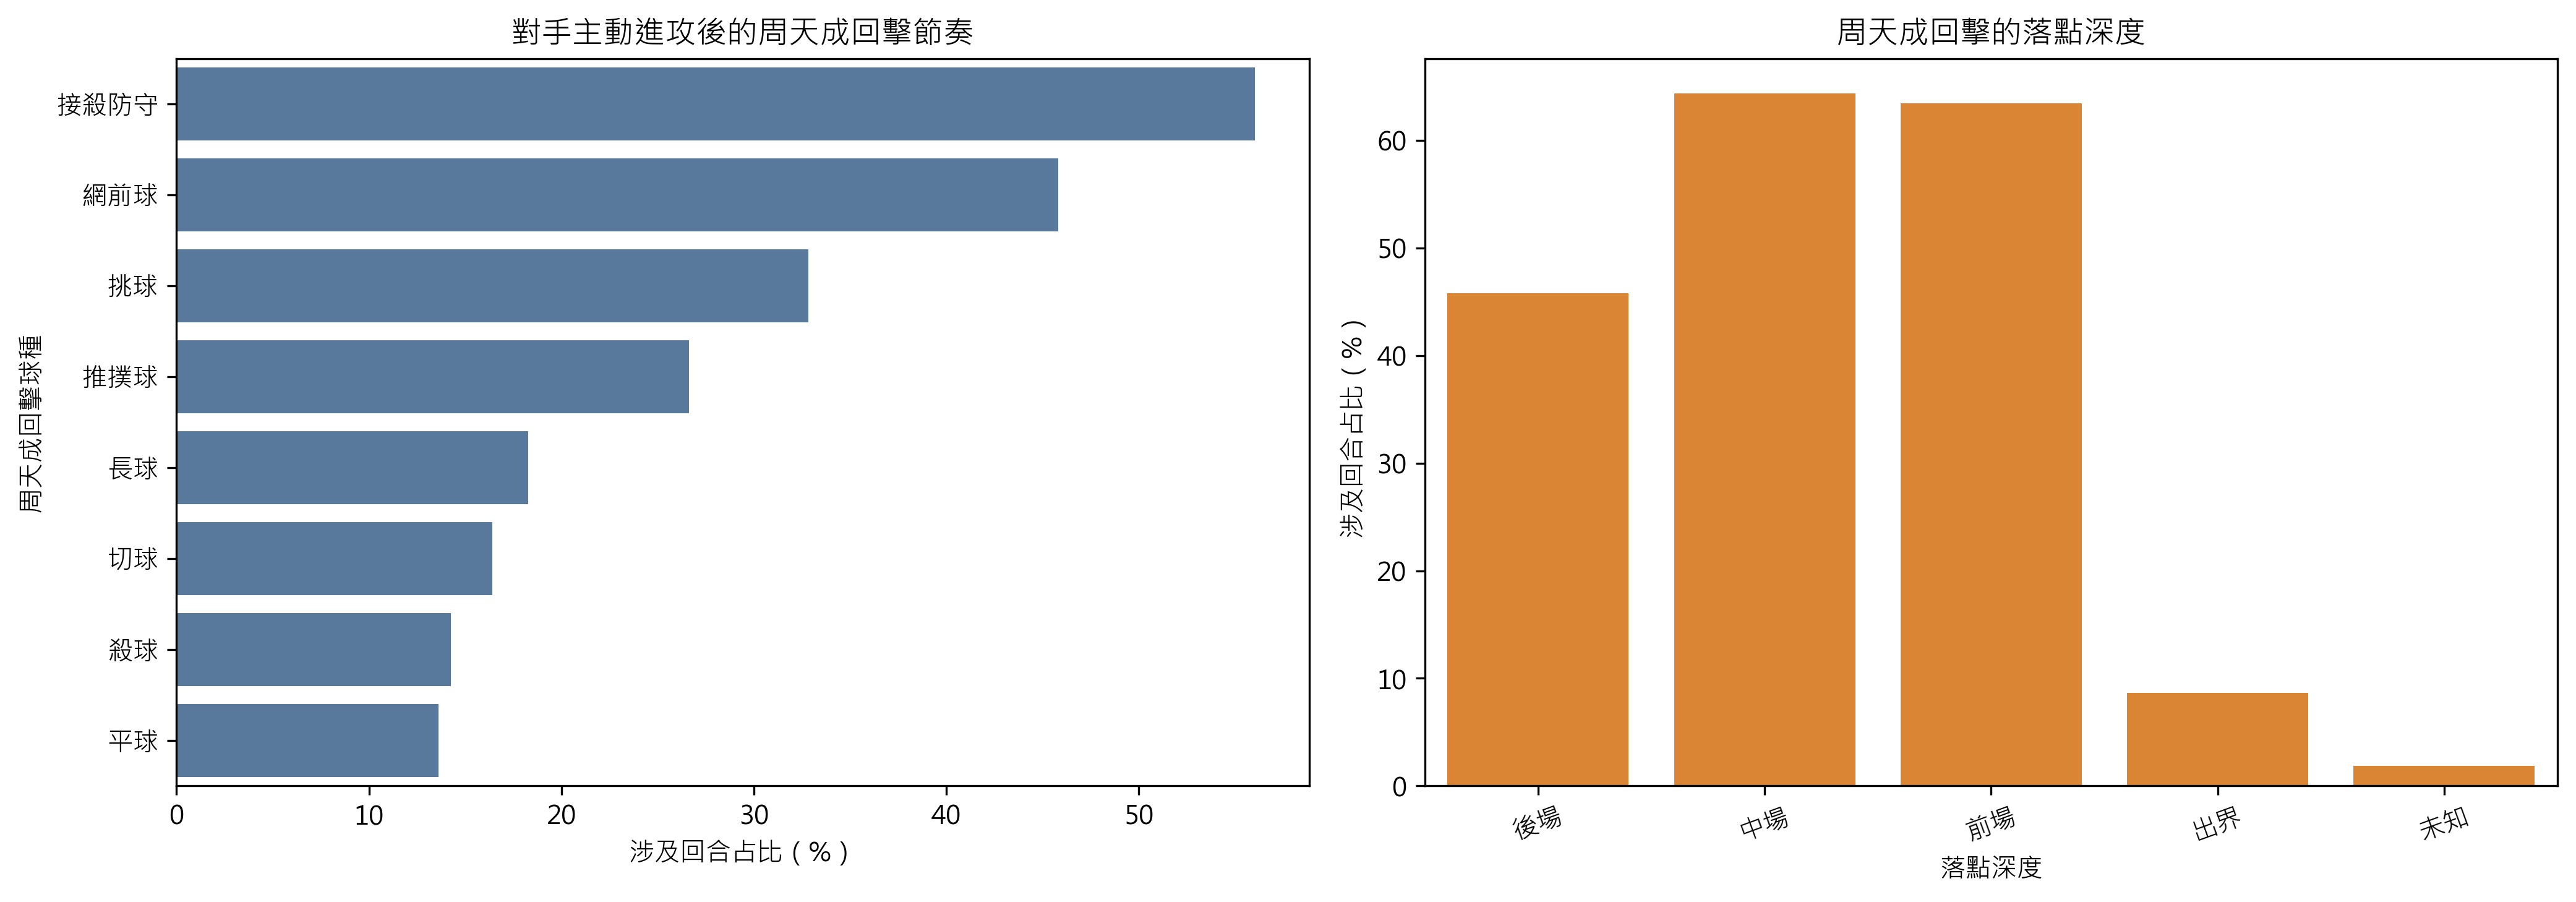

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'opponent', 'type', 'landing_area'
]

if len(df) == 0:
    print('資料為空，無法進行分析。')
else:
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
    else:
        chou = 'CHOU Tien Chen'
        attack_types = ['殺球', '推撲球', '平球', '網前球']

        print('分析口徑：')
        print('1. 對手主動進攻定義為：對手擊出的殺球、推撲球、平球或網前球。')
        print('2. 周天成回擊定義為：同一 match_id、set、rally 中，緊接在對手主動進攻後的下一拍，且下一拍 player 為周天成。')
        print('3. 統計單位為每回合；同一回合只計一次各回擊球種與落點深度。')
        print('4. 落點深度依正式場地區域定義：後場 1–4、中場 5–16、前場 17–24、出界 25–32。')

        work = df.copy()
        work = work.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).reset_index(drop=True)

        group_cols = ['match_id', 'set', 'rally']

        next_player = work.groupby(group_cols, sort=False)['player'].shift(-1)
        next_type = work.groupby(group_cols, sort=False)['type'].shift(-1)
        next_landing_area = work.groupby(group_cols, sort=False)['landing_area'].shift(-1)
        next_ball_round = work.groupby(group_cols, sort=False)['ball_round'].shift(-1)

        opponent_attack = (
            (work['player'] != chou) &
            (work['opponent'] == chou) &
            (work['type'].isin(attack_types))
        )

        response_mask = (
            opponent_attack &
            (next_player == chou) &
            next_ball_round.notna()
        )

        response_events = work.loc[response_mask, group_cols].copy()
        response_events['對手進攻球種'] = work.loc[response_mask, 'type'].astype(str).to_numpy()
        response_events['周天成回擊球種'] = next_type.loc[response_mask].astype(str).to_numpy()
        response_events['周天成落點區域'] = pd.to_numeric(
            next_landing_area.loc[response_mask],
            errors='coerce'
        ).to_numpy()

        def depth_category(zone):
            if pd.isna(zone):
                return '未知'
            zone = int(zone)
            if zone in [1, 2, 3, 4]:
                return '後場'
            if zone in list(range(5, 17)):
                return '中場'
            if zone in list(range(17, 25)):
                return '前場'
            if zone in list(range(25, 33)):
                return '出界'
            return '未知'

        response_events['周天成落點深度'] = response_events['周天成落點區域'].map(
            depth_category
        )

        if len(response_events) == 0:
            print('找不到對手主動進攻後由周天成緊接回擊的有效資料。')
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            for ax in axes:
                ax.text(
                    0.5, 0.5, '無有效資料',
                    ha='center', va='center', fontsize=14
                )
                ax.set_axis_off()
            plt.tight_layout()
        else:
            eligible_rallies = response_events[group_cols].drop_duplicates()
            eligible_rally_count = len(eligible_rallies)

            rally_summary = (
                response_events
                .groupby(group_cols, as_index=False)
                .agg(
                    對手主動進攻次數=('對手進攻球種', 'size'),
                    周天成回擊次數=('周天成回擊球種', 'size'),
                    周天成回擊球種=('周天成回擊球種', lambda s: '、'.join(sorted(set(s)))),
                    周天成落點深度=('周天成落點深度', lambda s: '、'.join(sorted(set(s)))),
                    落點區域=('周天成落點區域', lambda s: '、'.join(
                        sorted(set(str(int(x)) for x in s.dropna()))
                    ))
                )
            )

            type_rally_stats = (
                response_events[group_cols + ['周天成回擊球種']]
                .drop_duplicates()
                .groupby('周天成回擊球種')
                .size()
                .reset_index(name='回擊回合數')
            )
            type_rally_stats['回合占比'] = (
                type_rally_stats['回擊回合數'] / eligible_rally_count * 100
            )
            type_rally_stats = type_rally_stats.sort_values(
                '回擊回合數', ascending=False
            )

            depth_order = ['後場', '中場', '前場', '出界', '未知']
            depth_rally_stats = (
                response_events[group_cols + ['周天成落點深度']]
                .drop_duplicates()
                .groupby('周天成落點深度')
                .size()
                .reindex(depth_order, fill_value=0)
                .reset_index(name='落點深度回合數')
            )
            depth_rally_stats['回合占比'] = (
                depth_rally_stats['落點深度回合數'] / eligible_rally_count * 100
            )

            attack_type_stats = (
                response_events[group_cols + ['對手進攻球種']]
                .drop_duplicates()
                .groupby('對手進攻球種')
                .size()
                .reset_index(name='涉及回合數')
                .sort_values('涉及回合數', ascending=False)
            )
            attack_type_stats['回合占比'] = (
                attack_type_stats['涉及回合數'] / eligible_rally_count * 100
            )

            print(f'對手主動進攻後有周天成回擊的有效回合數：{eligible_rally_count}')
            print(f'平均每個有效回合的周天成回擊次數：{rally_summary["周天成回擊次數"].mean():.2f}')
            print('\n對手主動進攻球種涉及回合：')
            print(attack_type_stats.to_string(index=False, formatters={'回合占比': '{:.1f}%'.format}))
            print('\n周天成回擊球種：')
            print(type_rally_stats.to_string(index=False, formatters={'回合占比': '{:.1f}%'.format}))
            print('\n周天成落點深度：')
            print(depth_rally_stats.to_string(index=False, formatters={'回合占比': '{:.1f}%'.format}))
            print('\n每回合摘要：')
            print(rally_summary.head(20).to_string(index=False))

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            sns.barplot(
                data=type_rally_stats,
                x='回合占比',
                y='周天成回擊球種',
                color='#4C78A8',
                ax=axes[0]
            )
            axes[0].set_title('對手主動進攻後的周天成回擊節奏')
            axes[0].set_xlabel('涉及回合占比（%）')
            axes[0].set_ylabel('周天成回擊球種')

            sns.barplot(
                data=depth_rally_stats,
                x='周天成落點深度',
                y='回合占比',
                color='#F58518',
                order=depth_order,
                ax=axes[1]
            )
            axes[1].set_title('周天成回擊的落點深度')
            axes[1].set_xlabel('落點深度')
            axes[1].set_ylabel('涉及回合占比（%）')
            axes[1].tick_params(axis='x', rotation=20)

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 91
**問題**: 若對手的右後場出球不穩，周天成應如何調整策略，攻擊其弱側？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location, player_movement`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm+semantic_guard）


統計口徑：
- 分析主體：CHOU Tien Chen 攻擊 Kento MOMOTA 的弱側
- 對手右後場：依正式 Court Grid Definition，使用 hit_area == 4（右後角）
- 統計單位：單拍，不跨 rally、不使用前後拍資訊
- 四角區域：1=左後角、4=右後角、21=左前角、24=右前角
- 資料未提供得分、失誤或勝負欄位，因此以下以出球球種與落點分布作為戰術代理指標，不能直接判定失誤率或得分率。

Kento MOMOTA 從右後場 Zone 4 的出球球種分布：
type  拍數    比例
  切球 115 52.27
  長球  59 26.82
  殺球  31 14.09
  平球  12  5.45
接殺防守   1  0.45
 發長球   1  0.45
 網前球   1  0.45

Kento MOMOTA 從右後場 Zone 4 出球後的四角落點分布：
對手右後場出球落點  拍數    比例
      左後角  35 81.40
…（輸出已截斷；notebook 僅保留重點）


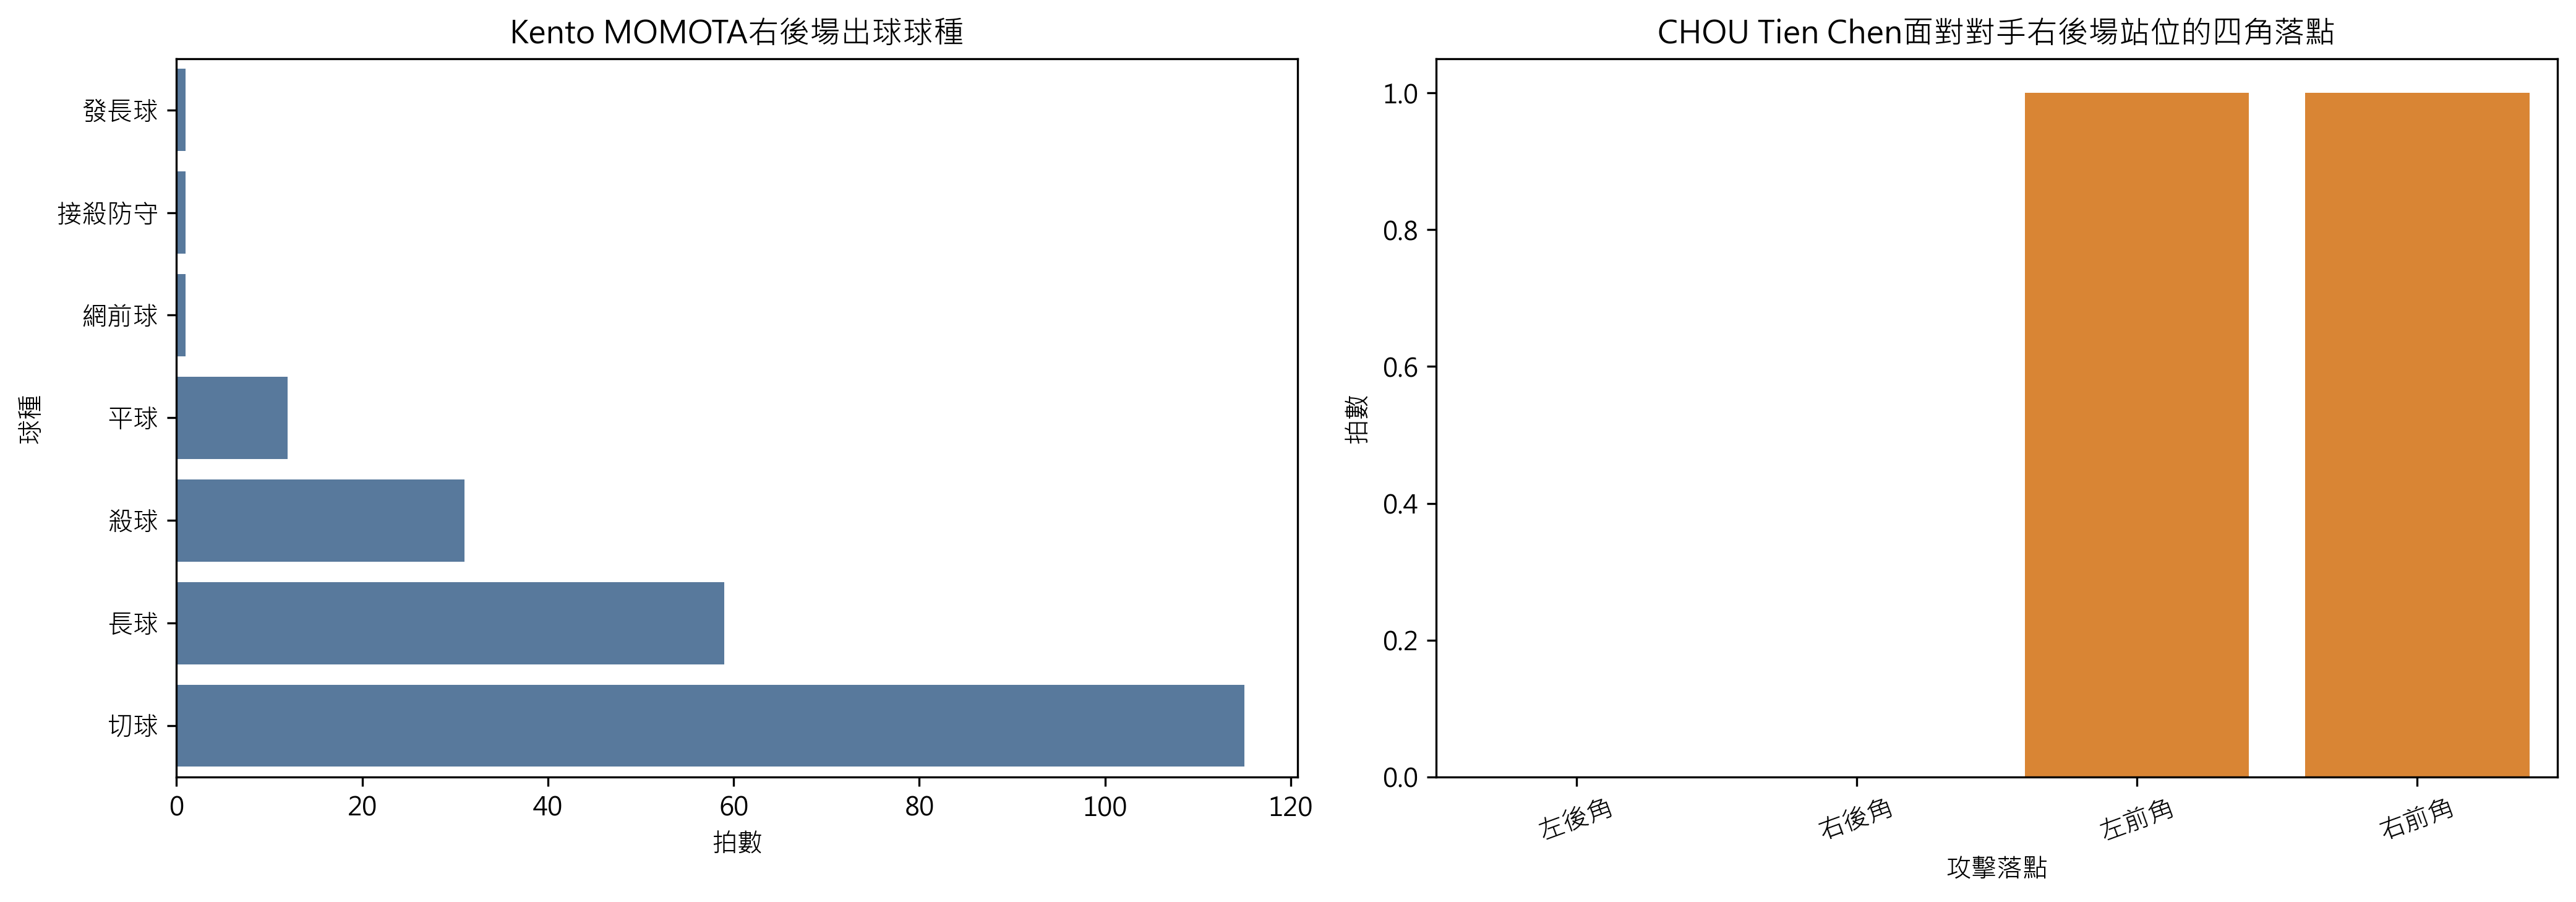

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    required_cols = [
        "match_id", "set", "rally", "ball_round", "player", "opponent",
        "type", "hit_area", "landing_area", "opponent_location_area"
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        chou_name = "CHOU Tien Chen"
        if chou_name not in df["player"].dropna().unique():
            print(f"資料中找不到周天成：{chou_name}")
        else:
            opponent_names = [
                x for x in df["player"].dropna().unique()
                if x != chou_name
            ]

            if len(opponent_names) == 0:
                print("找不到周天成的對手。")
            else:
                opponent_name = opponent_names[0]

                # 正式場地定義：右後場為後場 Row 1 的最右欄 Zone 4
                corner_map = {
                    1: "左後角",
                    4: "右後角",
                    21: "左前角",
                    24: "右前角"
                }
                corner_order = ["左後角", "右後角", "左前角", "右前角"]

                analysis_df = df.copy()
                analysis_df = analysis_df.sort_values(
                    ["match_id", "set", "rally", "ball_round"]
                )

                analysis_df["hit_area_num"] = pd.to_numeric(
                    analysis_df["hit_area"], errors="coerce"
                )
                analysis_df["landing_area_num"] = pd.to_numeric(
                    analysis_df["landing_area"], errors="coerce"
                )
                analysis_df["opponent_location_area_num"] = pd.to_numeric(
                    analysis_df["opponent_location_area"], errors="coerce"
                )

                # 單拍分析：對手從正式定義的右後場 Zone 4 出球
                opponent_right_back_df = analysis_df[
                    (analysis_df["player"] == opponent_name) &
                    (analysis_df["hit_area_num"] == 4) &
                    analysis_df["type"].notna()
                ].copy()

                # 單拍分析：周天成將球落在四角，且對手當下站在右後場
                chou_attack_df = analysis_df[
                    (analysis_df["player"] == chou_name) &
                    (analysis_df["opponent_location_area_num"] == 4) &
                    analysis_df["landing_area_num"].isin(corner_map.keys())
                ].copy()

                print("統計口徑：")
                print(f"- 分析主體：{chou_name} 攻擊 {opponent_name} 的弱側")
                print("- 對手右後場：依正式 Court Grid Definition，使用 hit_area == 4（右後角）")
                print("- 統計單位：單拍，不跨 rally、不使用前後拍資訊")
                print("- 四角區域：1=左後角、4=右後角、21=左前角、24=右前角")
                print("- 資料未提供得分、失誤或勝負欄位，因此以下以出球球種與落點分布作為戰術代理指標，不能直接判定失誤率或得分率。")

                if len(opponent_right_back_df) == 0:
                    print("\n沒有對手從右後場 Zone 4 出球的有效紀錄。")
                else:
                    opponent_type_stats = (
                        opponent_right_back_df
                        .groupby("type")
                        .size()
                        .reset_index(name="拍數")
                        .sort_values("拍數", ascending=False)
                    )
                    opponent_type_stats["比例"] = (
                        opponent_type_stats["拍數"] /
                        opponent_type_stats["拍數"].sum() * 100
                    ).round(2)

                    opponent_corner_df = opponent_right_back_df[
                        opponent_right_back_df["landing_area_num"].isin(corner_map.keys())
                    ].copy()

                    if len(opponent_corner_df) > 0:
                        opponent_corner_stats = (
                            opponent_corner_df["landing_area_num"]
                            .map(corner_map)
                            .value_counts()
                            .reindex(corner_order, fill_value=0)
                            .rename_axis("對手右後場出球落點")
                            .reset_index(name="拍數")
                        )
                        opponent_corner_stats["比例"] = (
                            opponent_corner_stats["拍數"] /
                            opponent_corner_stats["拍數"].sum() * 100
                        ).round(2)
                    else:
                        opponent_corner_stats = pd.DataFrame(
                            columns=["對手右後場出球落點", "拍數", "比例"]
                        )

                    print(f"\n{opponent_name} 從右後場 Zone 4 的出球球種分布：")
                    print(opponent_type_stats.to_string(index=False))

                    if len(opponent_corner_stats) > 0:
                        print(f"\n{opponent_name} 從右後場 Zone 4 出球後的四角落點分布：")
                        print(opponent_corner_stats.to_string(index=False))
                    else:
                        print(f"\n{opponent_name} 從右後場 Zone 4 出球後，沒有足夠的四角落點資料。")

                if len(chou_attack_df) > 0:
                    chou_target_stats = (
                        chou_attack_df["landing_area_num"]
                        .map(corner_map)
                        .value_counts()
                        .reindex(corner_order, fill_value=0)
                        .rename_axis("周天成攻擊落點")
                        .reset_index(name="拍數")
                    )
                    chou_target_stats["比例"] = (
                        chou_target_stats["拍數"] /
                        chou_target_stats["拍數"].sum() * 100
                    ).round(2)

                    right_back_target_share = float(
                        chou_target_stats.loc[
                            chou_target_stats["周天成攻擊落點"] == "右後角", "比例"
                        ].iloc[0]
                    )

                    print(f"\n當{opponent_name}站在右後場 Zone 4 時，{chou_name}攻擊四角的落點分布：")
                    print(chou_target_stats.to_string(index=False))

                    print("\n戰術建議：")
                    print(f"1. 優先讓{opponent_name}持續在右後場 Zone 4 擊球，將其右後場列為壓迫方向。")
                    print("2. 回球落點應以右後角 Zone 4 為主要壓迫目標，並搭配左前角 Zone 21 或右前角 Zone 24 的短球，避免落點單一。")
                    print(f"3. 目前資料中，{chou_name}在對手站右後場時攻擊右後角的比例為 {right_back_target_share:.2f}%；可依比賽中對手移動與回球品質提高或降低此比例。")
                    print("4. 由於缺少失誤與得分標記，不能僅憑本表宣稱右後場一定是實際失誤弱點，應將上述策略視為落點與站位壓迫方案。")
                else:
                    print(f"\n沒有{chou_name}在對手站於右後場 Zone 4 時攻擊四角的有效紀錄。")
                    print("\n戰術建議：")
                    print(f"1. 優先以右後角 Zone 4 作為{chou_name}的壓迫落點。")
                    print("2. 搭配左前角 Zone 21 與右前角 Zone 24 的變化，觀察對手右後場回球品質。")
                    print("3. 目前資料不足以估計實際攻擊成功率或失誤率。")

                fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                if len(opponent_right_back_df) > 0:
                    plot_type = (
                        opponent_right_back_df["type"]
                        .value_counts()
                        .sort_values(ascending=True)
                    )
                    sns.barplot(
                        x=plot_type.values,
                        y=plot_type.index,
                        ax=axes[0],
                        color="#4C78A8"
                    )
                    axes[0].set_title(f"{opponent_name}右後場出球球種")
                    axes[0].set_xlabel("拍數")
                    axes[0].set_ylabel("球種")
                else:
                    axes[0].text(0.5, 0.5, "無右後場出球資料", ha="center", va="center")
                    axes[0].set_title("對手右後場出球球種")
                    axes[0].set_axis_off()

                if len(chou_attack_df) > 0:
                    plot_target = chou_target_stats.set_index("周天成攻擊落點").reindex(
                        corner_order
                    )
                    sns.barplot(
                        x=plot_target.index,
                        y=plot_target["拍數"].values,
                        ax=axes[1],
                        color="#F58518"
                    )
                    axes[1].set_title(f"{chou_name}面對對手右後場站位的四角落點")
                    axes[1].set_xlabel("攻擊落點")
                    axes[1].set_ylabel("拍數")
                    axes[1].tick_params(axis="x", rotation=20)
                else:
                    axes[1].text(0.5, 0.5, "無四角攻擊資料", ha="center", va="center")
                    axes[1].set_title("周天成攻擊四角落點")
                    axes[1].set_axis_off()

                plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 93
**問題**: 當對手在關鍵分(18分以上)皆呈現非進攻狀態，周天成應如何調整球路設計來強化關鍵分得分率？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）


對手球種代碼與名稱對照表：
 球種代碼 球種名稱
    1  發短球
    2  發長球
    3   長球
    4   殺球
    5   切球
    6   挑球
    7   平球
    8  網前球
    9  推撲球
   10 接殺防守
   11  接不到

統計口徑：
1. 關鍵分：對手比分 >= 18。
2. 對手非進攻狀態：對手上一拍球種不屬於殺球、推撲球、平球。
3. 統計單位：關鍵分回合。
4. 球路設計：周天成在該回合的第一個擊球球種。
5. Active Win：該回合最後一拍由周天成擊出，且得分者為周天成。
…（輸出已截斷；notebook 僅保留重點）


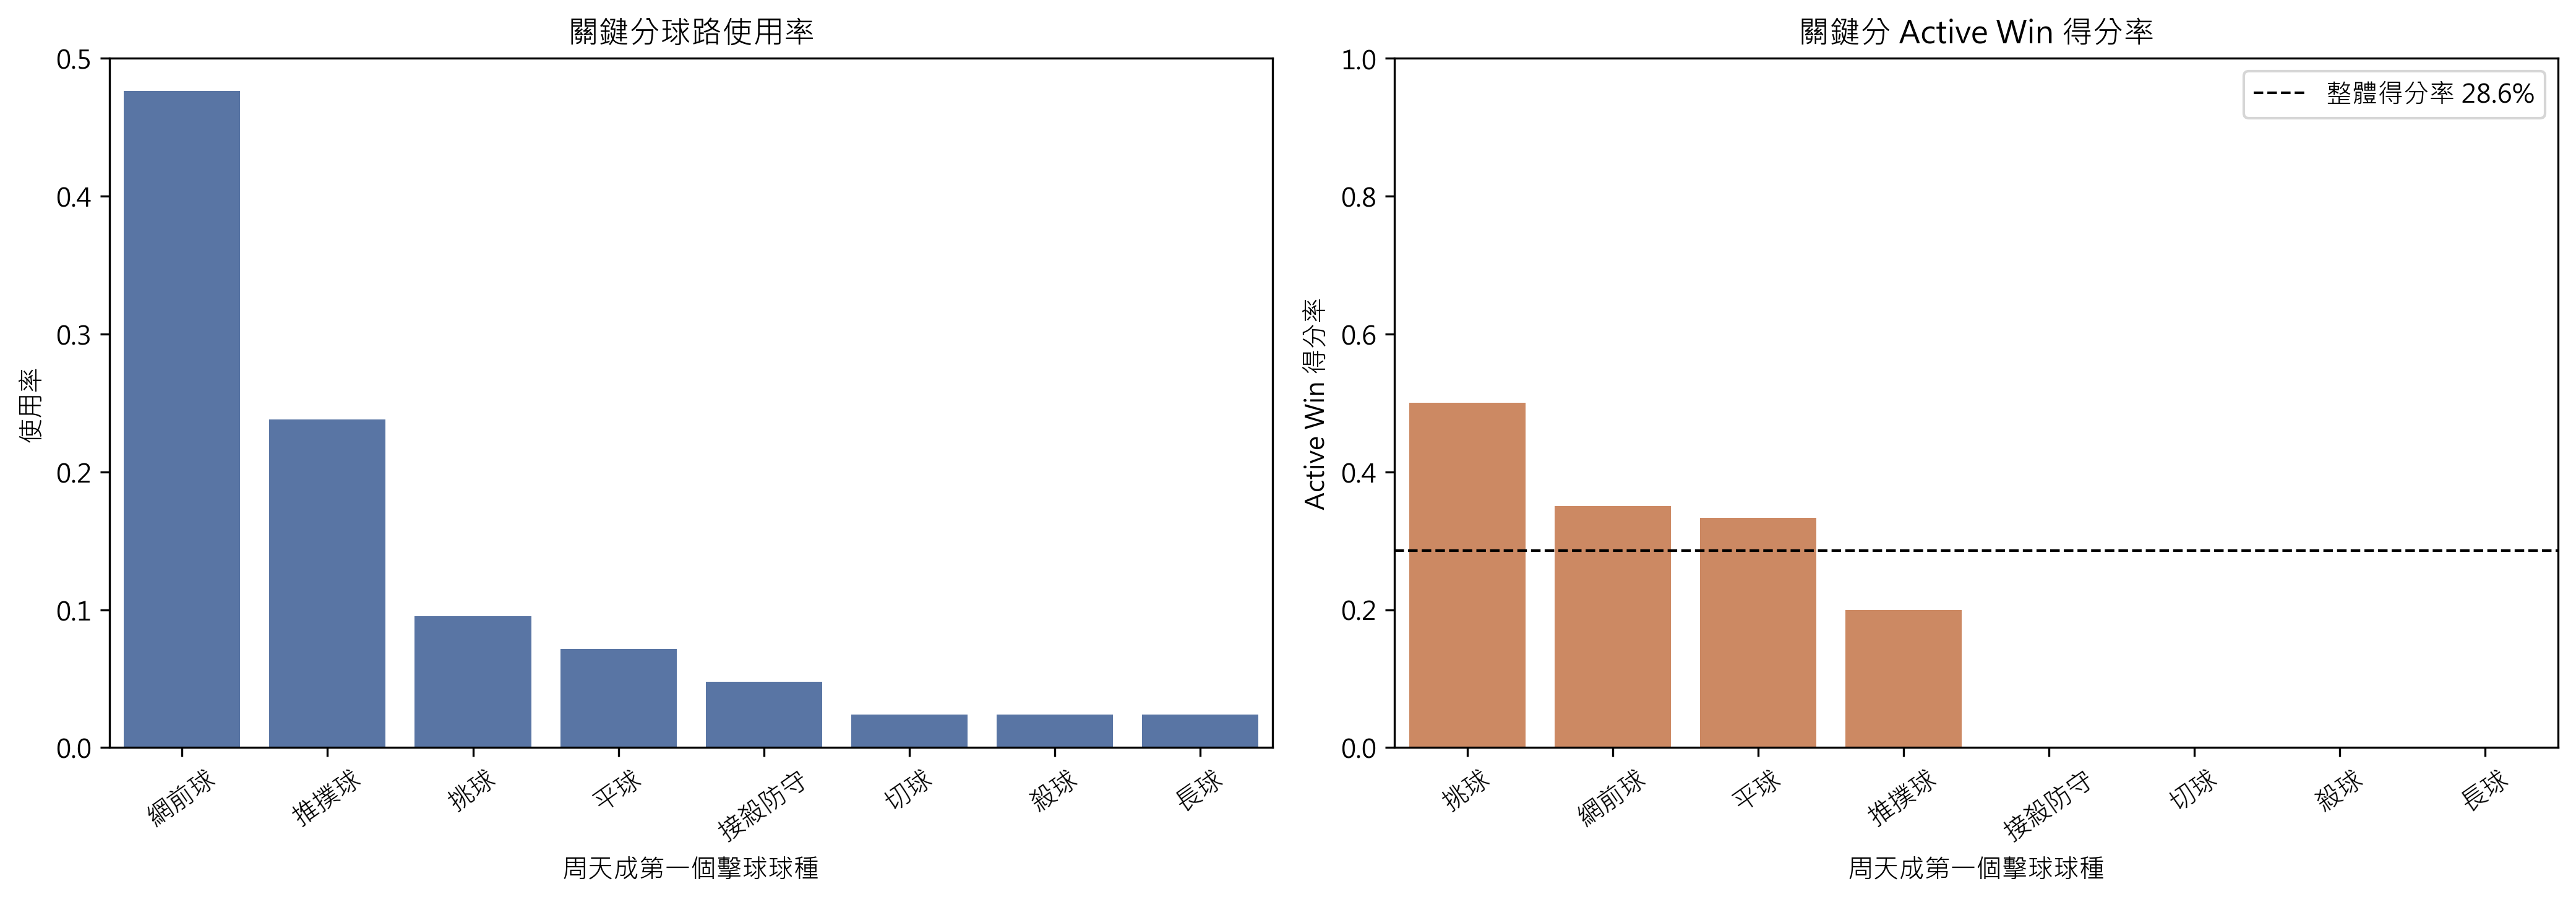

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'opponent_type', 'getpoint_player',
    'Kento MOMOTA_score', 'CHOU Tien Chen_score'
]

if len(df) == 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.text(0.5, 0.5, '資料為空，無法分析', ha='center', va='center')
    ax.axis('off')
    plt.tight_layout()
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, '缺少必要欄位，無法分析', ha='center', va='center')
        ax.axis('off')
        plt.tight_layout()
    else:
        ctc = 'CHOU Tien Chen'
        opponent = 'Kento MOMOTA'
        group_cols = ['match_id', 'set', 'rally']

        shot_type_mapping = {
            1: '發短球',
            2: '發長球',
            3: '長球',
            4: '殺球',
            5: '切球',
            6: '挑球',
            7: '平球',
            8: '網前球',
            9: '推撲球',
            10: '接殺防守',
            11: '接不到'
        }

        offensive_types = {'殺球', '推撲球', '平球'}
        non_offensive_codes = [
            code for code, name in shot_type_mapping.items()
            if name not in offensive_types
        ]

        work = df.copy()
        work['_opponent_score'] = pd.to_numeric(
            work['Kento MOMOTA_score'], errors='coerce'
        )
        work['_opponent_type'] = pd.to_numeric(
            work['opponent_type'], errors='coerce'
        )

        work = work.sort_values(
            group_cols + ['ball_round']
        ).reset_index(drop=True)

        print('對手球種代碼與名稱對照表：')
        print(
            pd.DataFrame(
                [
                    {'球種代碼': code, '球種名稱': name}
                    for code, name in shot_type_mapping.items()
                ]
            ).to_string(index=False)
        )

        print('\n統計口徑：')
        print('1. 關鍵分：對手比分 >= 18。')
        print('2. 對手非進攻狀態：對手上一拍球種不屬於殺球、推撲球、平球。')
        print('3. 統計單位：關鍵分回合。')
        print('4. 球路設計：周天成在該回合的第一個擊球球種。')
        print('5. Active Win：該回合最後一拍由周天成擊出，且得分者為周天成。')

        work['_is_ctc_response'] = (
            (work['player'] == ctc) &
            (work['_opponent_score'] >= 18) &
            (work['_opponent_type'].isin(non_offensive_codes)) &
            (work['type'].notna())
        )

        response_rows = work.loc[
            work['_is_ctc_response'],
            group_cols + ['type', 'ball_round']
        ].copy()

        if len(response_rows) == 0:
            print('\n沒有符合條件的關鍵分回合。')
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.text(0.5, 0.5, '沒有符合條件的關鍵分回合',
                    ha='center', va='center')
            ax.axis('off')
            plt.tight_layout()
        else:
            response_rows = (
                response_rows
                .sort_values(group_cols + ['ball_round'])
                .drop_duplicates(group_cols, keep='first')
            )

            rally_last_rows = (
                work
                .sort_values(group_cols + ['ball_round'])
                .groupby(group_cols, sort=False, group_keys=False)
                .tail(1)
                .copy()
            )

            rally_outcome = rally_last_rows[
                group_cols + ['player', 'getpoint_player']
            ].copy()

            rally_outcome = rally_outcome.rename(
                columns={
                    'player': '_end_player',
                    'getpoint_player': '_rally_winner'
                }
            )

            rally_outcome['_active_win'] = (
                (rally_outcome['_end_player'] == ctc) &
                (rally_outcome['_rally_winner'] == ctc)
            )

            analysis_df = response_rows.merge(
                rally_outcome[
                    group_cols + ['_end_player', '_rally_winner', '_active_win']
                ],
                on=group_cols,
                how='inner'
            )

            analysis_df['球路設計'] = analysis_df['type'].astype(str)

            summary = (
                analysis_df
                .groupby('球路設計', as_index=False)
                .agg(
                    關鍵分回合數=('球路設計', 'size'),
                    Active_Win=('_active_win', 'sum')
                )
            )

            summary['Active Win 得分率'] = (
                summary['Active_Win'] / summary['關鍵分回合數']
            )
            summary['使用率'] = (
                summary['關鍵分回合數'] / len(analysis_df)
            )

            summary = summary.sort_values(
                ['Active Win 得分率', '關鍵分回合數'],
                ascending=[False, False]
            ).reset_index(drop=True)

            total_rallies = len(analysis_df)
            total_active_wins = int(analysis_df['_active_win'].sum())
            overall_rate = total_active_wins / total_rallies

            print(f'\n符合條件的關鍵分回合數：{total_rallies}')
            print(f'周天成 Active Win 回合數：{total_active_wins}')
            print(f'整體 Active Win 得分率：{overall_rate:.2%}')

            print('\n對手非進攻狀態下，周天成球路設計分析：')
            print(
                summary[
                    [
                        '球路設計',
                        '關鍵分回合數',
                        'Active_Win',
                        'Active Win 得分率',
                        '使用率'
                    ]
                ].to_string(
                    index=False,
                    formatters={
                        'Active Win 得分率': '{:.2%}'.format,
                        '使用率': '{:.2%}'.format
                    }
                )
            )

            reliable_summary = summary.loc[
                summary['關鍵分回合數'] >= max(3, int(total_rallies * 0.05))
            ]

            print('\n調整建議：')
            if len(reliable_summary) == 0:
                print('各球路樣本數偏少，建議先累積更多關鍵分回合資料。')
            else:
                best_row = reliable_summary.iloc[0]
                print(
                    f"優先提高「{best_row['球路設計']}」的使用比例；"
                    f"其關鍵分 Active Win 得分率為 "
                    f"{best_row['Active Win 得分率']:.2%}，"
                    f"使用率為 {best_row['使用率']:.2%}。"
                )

                underused = reliable_summary.sort_values(
                    ['Active Win 得分率', '使用率'],
                    ascending=[False, True]
                ).iloc[0]

                if (
                    underused['球路設計'] != best_row['球路設計'] and
                    underused['使用率'] < 0.20
                ):
                    print(
                        f"「{underused['球路設計']}」具備較佳得分效率但使用率偏低，"
                        '可在對手非進攻的關鍵分增加配置。'
                    )

                print(
                    '建議以高 Active Win 得分率球路作為主要主動進攻方案，'
                    '並保留其他球路作為變化，避免關鍵分球路過度可預測。'
                )

            plot_df = summary.copy()

            if len(plot_df) > 8:
                top_types = set(plot_df.head(7)['球路設計'])
                plot_df['球路設計'] = plot_df['球路設計'].where(
                    plot_df['球路設計'].isin(top_types),
                    '其他'
                )

                plot_df = (
                    plot_df
                    .groupby('球路設計', as_index=False)
                    .agg(
                        關鍵分回合數=('關鍵分回合數', 'sum'),
                        Active_Win=('Active_Win', 'sum')
                    )
                )

                plot_df['Active Win 得分率'] = (
                    plot_df['Active_Win'] / plot_df['關鍵分回合數']
                )
                plot_df['使用率'] = (
                    plot_df['關鍵分回合數'] /
                    plot_df['關鍵分回合數'].sum()
                )

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            usage_plot = plot_df.sort_values(
                '使用率', ascending=False
            )

            sns.barplot(
                data=usage_plot,
                x='球路設計',
                y='使用率',
                color='#4C72B0',
                ax=axes[0]
            )
            axes[0].set_title('關鍵分球路使用率')
            axes[0].set_xlabel('周天成第一個擊球球種')
            axes[0].set_ylabel('使用率')
            axes[0].tick_params(axis='x', rotation=35)

            rate_plot = plot_df.sort_values(
                'Active Win 得分率', ascending=False
            )

            sns.barplot(
                data=rate_plot,
                x='球路設計',
                y='Active Win 得分率',
                color='#DD8452',
                ax=axes[1]
            )
            axes[1].axhline(
                overall_rate,
                color='black',
                linestyle='--',
                linewidth=1,
                label=f'整體得分率 {overall_rate:.1%}'
            )
            axes[1].set_title('關鍵分 Active Win 得分率')
            axes[1].set_xlabel('周天成第一個擊球球種')
            axes[1].set_ylabel('Active Win 得分率')
            axes[1].set_ylim(0, 1)
            axes[1].tick_params(axis='x', rotation=35)
            axes[1].legend()

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 95
**問題**: 比賽中若觀察到對手因壓力無法耐心打多拍，周天成可如何透過中場拉吊、穩定球路誘發對手躁進失誤？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm+semantic_guard）


分析主體：CHOU Tien Chen 造成的對手壓力失誤
統計單位：每回合
失誤定義：最後一拍為對手擊球，且 getpoint_player 為周天成，並有 lose_reason 記錄
周天成參與回合數：408
對手失誤回合數：106
對手失誤率：25.98%

不同戰術情境的回合層級結果：
                策略  回合數  對手失誤回合數 對手失誤率百分比
              中場擊球  367       91   24.80%
       中場拉吊（長球或切球）  223       54   24.22%
穩定拉吊組合（中場且包含長球與切球）   72       16   22.22%
              前場擊球  341       91   26.69%
              後場擊球  271       68   25.09%
                挑球  166       41   24.70%
               網前球  281       70   24.91%
                殺球  215       44   20.47%

周天成擊球區域與對手失誤：
擊球區域  回合數  對手失誤回合數 對手失誤率百分比
…（輸出已截斷；notebook 僅保留重點）


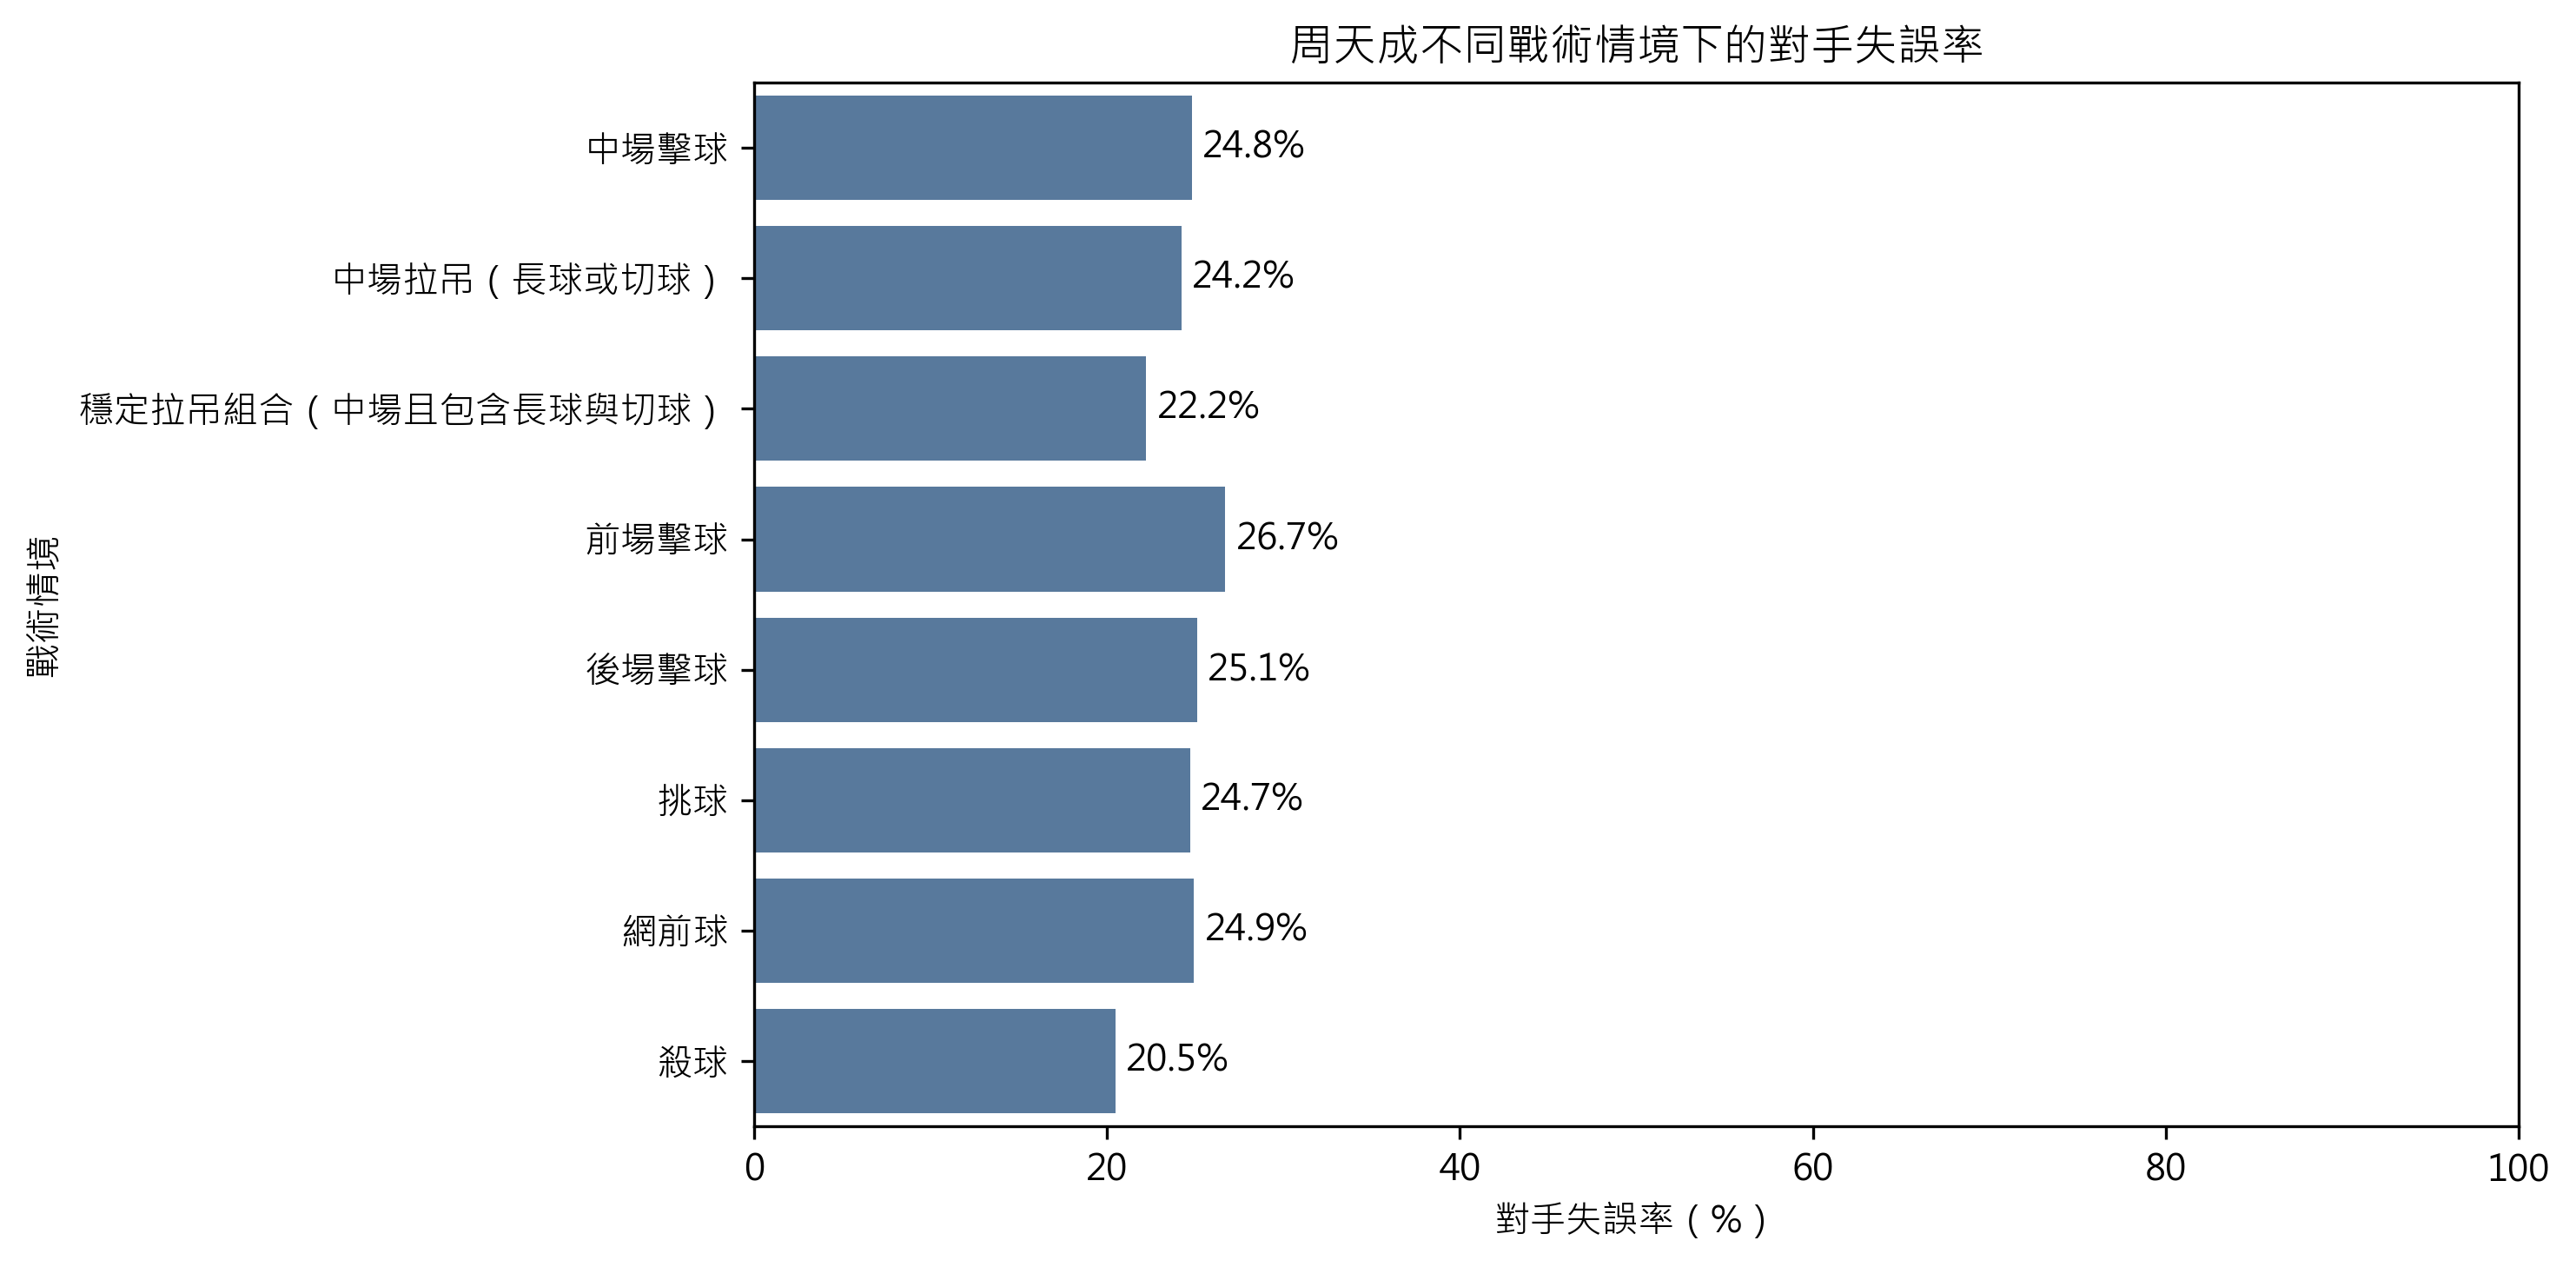

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'hit_area', 'getpoint_player', 'lose_reason'
]

if len(df) == 0:
    print('資料為空，無法分析。')
elif not set(required_cols).issubset(df.columns):
    missing_cols = sorted(set(required_cols) - set(df.columns))
    print(f'缺少必要欄位：{missing_cols}')
else:
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    target_player = 'CHOU Tien Chen'
    opponent_player = 'Kento MOMOTA'
    rally_keys = ['match_id', 'set', 'rally']

    data = df.sort_values(rally_keys + ['ball_round']).copy()

    # 依正式 Court Grid Definitions 將擊球區域分為前、中、後場及出界
    front_zones = {17, 18, 19, 20, 21, 22, 23, 24}
    mid_zones = {5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16}
    back_zones = {1, 2, 3, 4}
    out_zones = {25, 26, 27, 28, 29, 30, 31, 32}

    def court_category(zone):
        if pd.isna(zone):
            return pd.NA
        zone = int(zone)
        if zone in front_zones:
            return '前場'
        if zone in mid_zones:
            return '中場'
        if zone in back_zones:
            return '後場'
        if zone in out_zones:
            return '出界'
        return '未知'

    data['hit_court_category'] = data['hit_area'].map(court_category)

    # 以每回合最後一拍判定對手是否因擊球失誤讓周天成得分
    rally_last = (
        data.groupby(rally_keys, sort=False)
        .tail(1)
        .copy()
    )

    rally_last['opponent_error'] = (
        rally_last['player'].eq(opponent_player)
        & rally_last['getpoint_player'].eq(target_player)
        & rally_last['lose_reason'].notna()
    )

    # 只保留周天成在該回合的擊球，建立回合層級戰術特徵
    target_shots = data[data['player'].eq(target_player)].copy()

    rally_features = (
        target_shots.groupby(rally_keys, sort=False)
        .agg(
            target_shot_count=('player', 'size'),
            target_midcourt_shot=('hit_court_category', lambda x: x.eq('中場').any()),
            target_frontcourt_shot=('hit_court_category', lambda x: x.eq('前場').any()),
            target_backcourt_shot=('hit_court_category', lambda x: x.eq('後場').any()),
            target_clear=('type', lambda x: x.eq('長球').any()),
            target_slice=('type', lambda x: x.eq('切球').any()),
            target_lift=('type', lambda x: x.eq('挑球').any()),
            target_net=('type', lambda x: x.eq('網前球').any()),
            target_smash=('type', lambda x: x.eq('殺球').any())
        )
        .reset_index()
    )

    rally_features = rally_features.merge(
        rally_last[rally_keys + ['opponent_error', 'lose_reason']],
        on=rally_keys,
        how='left'
    )

    rally_features['opponent_error'] = rally_features['opponent_error'].fillna(False)
    rally_features['target_shot_count'] = rally_features['target_shot_count'].fillna(0)

    total_rallies = len(rally_features)
    error_rallies = int(rally_features['opponent_error'].sum())

    print(f'分析主體：{target_player} 造成的對手壓力失誤')
    print('統計單位：每回合')
    print('失誤定義：最後一拍為對手擊球，且 getpoint_player 為周天成，並有 lose_reason 記錄')
    print(f'周天成參與回合數：{total_rallies}')
    print(f'對手失誤回合數：{error_rallies}')
    print(f'對手失誤率：{error_rallies / total_rallies:.2%}' if total_rallies else '對手失誤率：無法計算')

    strategy_specs = {
        '中場擊球': 'target_midcourt_shot',
        '中場拉吊（長球或切球）': None,
        '穩定拉吊組合（中場且包含長球與切球）': None,
        '前場擊球': 'target_frontcourt_shot',
        '後場擊球': 'target_backcourt_shot',
        '挑球': 'target_lift',
        '網前球': 'target_net',
        '殺球': 'target_smash'
    }

    rally_features['midcourt_clear_or_slice'] = (
        rally_features['target_midcourt_shot']
        & (rally_features['target_clear'] | rally_features['target_slice'])
    )

    rally_features['midcourt_clear_and_slice'] = (
        rally_features['target_midcourt_shot']
        & rally_features['target_clear']
        & rally_features['target_slice']
    )

    strategy_specs['中場拉吊（長球或切球）'] = 'midcourt_clear_or_slice'
    strategy_specs['穩定拉吊組合（中場且包含長球與切球）'] = 'midcourt_clear_and_slice'

    summary_rows = []
    for strategy_name, feature_col in strategy_specs.items():
        selected = rally_features[rally_features[feature_col].eq(True)]
        rally_count = len(selected)
        opponent_error_count = int(selected['opponent_error'].sum())
        summary_rows.append({
            '策略': strategy_name,
            '回合數': rally_count,
            '對手失誤回合數': opponent_error_count,
            '對手失誤率': (
                opponent_error_count / rally_count if rally_count > 0 else pd.NA
            )
        })

    strategy_summary = pd.DataFrame(summary_rows)
    strategy_summary['對手失誤率百分比'] = strategy_summary['對手失誤率'] * 100

    print('\n不同戰術情境的回合層級結果：')
    print(
        strategy_summary[
            ['策略', '回合數', '對手失誤回合數', '對手失誤率百分比']
        ].to_string(
            index=False,
            formatters={
                '對手失誤率百分比': lambda x: f'{x:.2f}%' if pd.notna(x) else '—'
            }
        )
    )

    # 分析周天成不同擊球區域下，對手於該回合最後一拍失誤的比例
    area_data = data[data['player'].eq(target_player)].copy()
    area_data = area_data[area_data['hit_court_category'].isin(['前場', '中場', '後場'])]

    area_rally_flags = (
        area_data.groupby(rally_keys + ['hit_court_category'], sort=False)
        .size()
        .reset_index(name='shot_count')
        .merge(
            rally_last[rally_keys + ['opponent_error']],
            on=rally_keys,
            how='left'
        )
    )

    area_summary = (
        area_rally_flags.groupby('hit_court_category', sort=False)
        .agg(
            回合數=('rally', 'size'),
            對手失誤回合數=('opponent_error', 'sum')
        )
        .reset_index()
        .rename(columns={'hit_court_category': '擊球區域'})
    )

    area_summary['對手失誤率'] = (
        area_summary['對手失誤回合數'] / area_summary['回合數']
    )
    area_summary['對手失誤率百分比'] = area_summary['對手失誤率'] * 100

    print('\n周天成擊球區域與對手失誤：')
    print(
        area_summary[
            ['擊球區域', '回合數', '對手失誤回合數', '對手失誤率百分比']
        ].to_string(
            index=False,
            formatters={
                '對手失誤率百分比': lambda x: f'{x:.2f}%'
            }
        )
    )

    # 對手失誤原因分布
    error_reason_summary = (
        rally_last[rally_last['opponent_error']]
        .groupby('lose_reason', dropna=False)
        .size()
        .reset_index(name='回合數')
        .rename(columns={'lose_reason': '對手失誤原因'})
        .sort_values('回合數', ascending=False)
    )

    if len(error_reason_summary) > 0:
        error_reason_summary['比例'] = (
            error_reason_summary['回合數'] / error_reason_summary['回合數'].sum()
        )

        print('\n對手失誤原因分布：')
        print(
            error_reason_summary.to_string(
                index=False,
                formatters={'比例': lambda x: f'{x:.2%}'}
            )
        )
    else:
        print('\n沒有符合定義的對手失誤回合。')

    # 視覺化：比較主要策略的對手失誤率
    plot_data = strategy_summary.dropna(subset=['對手失誤率']).copy()

    if len(plot_data) > 0:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(
            data=plot_data,
            x='對手失誤率百分比',
            y='策略',
            color='#4C78A8',
            ax=ax
        )
        ax.set_title('周天成不同戰術情境下的對手失誤率')
        ax.set_xlabel('對手失誤率（%）')
        ax.set_ylabel('戰術情境')
        ax.set_xlim(0, max(100, plot_data['對手失誤率百分比'].max() * 1.15))

        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', padding=3)

        plt.tight_layout()
    else:
        fig = plt.figure(figsize=(8, 4))
        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 100
**問題**: 當對手偏好在網前搶撲時，周天成應如何調整網前落點深淺與後續連接球種？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）


對手推撲球後的有效下一拍樣本數：195
涵蓋回合數：141

事件後一拍的落點深度：
落點深度  次數  比例(%)
  前場  28   14.4
  中場 117   60.0
  後場  44   22.6
  出界   6    3.1

事件後一拍的落點區域：
落點區域  落點位置  次數  比例(%)
  前場   前場左   8    4.1
  前場  前場中左   6    3.1
  前場   前場右   4    2.1
  前場   網前左   4    2.1
  前場  前場中右   2    1.0
  前場  網前中右   2    1.0
  前場   網前右   2    1.0
  中場   中場右  36   18.5
…（輸出已截斷；notebook 僅保留重點）


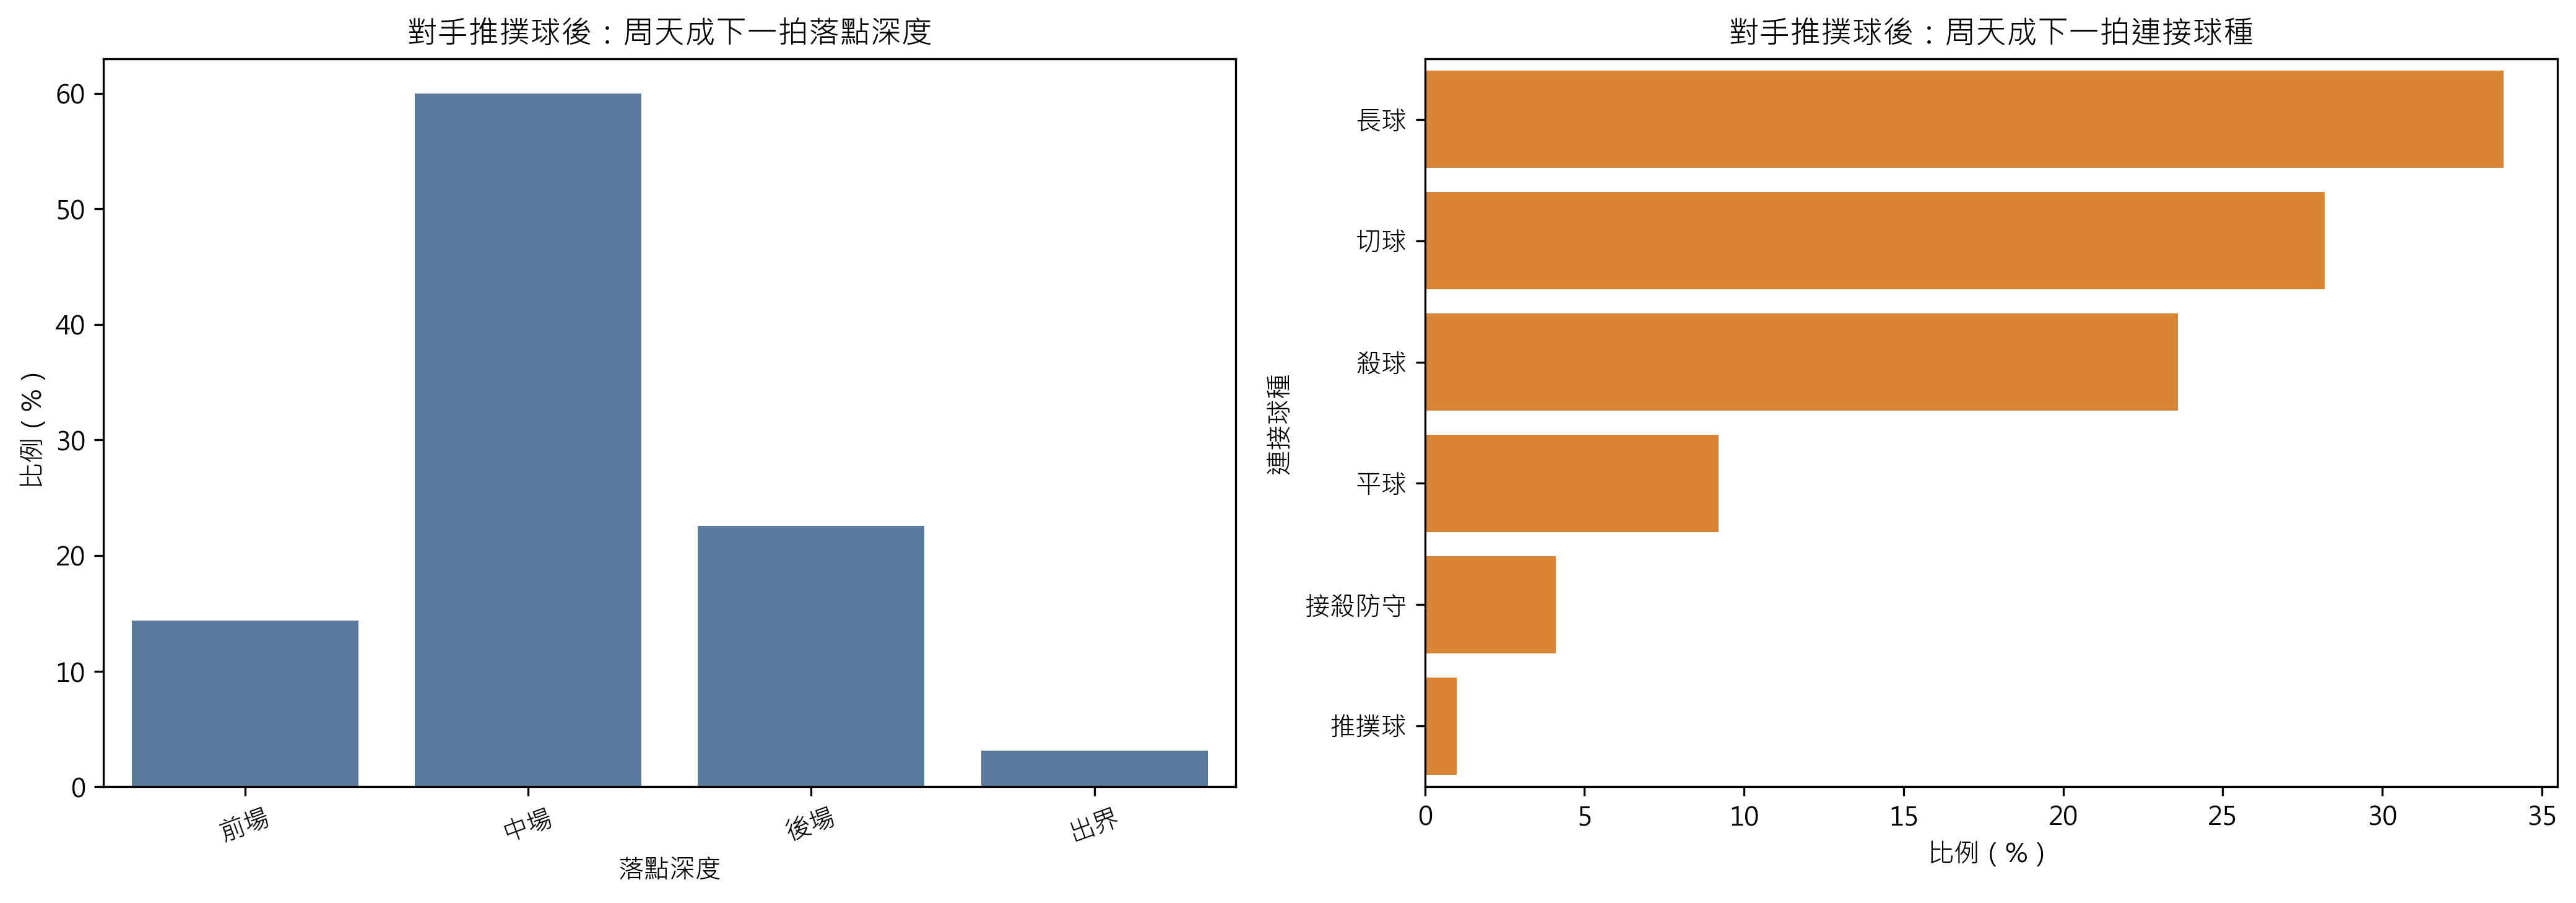

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'opponent', 'type', 'landing_area'
]

if len(df) == 0:
    print('資料為空，無法分析。')
else:
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
    else:
        player_name = 'CHOU Tien Chen'
        opponent_name = 'Kento MOMOTA'
        trigger_type = '推撲球'

        work = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).copy()

        group_cols = ['match_id', 'set', 'rally']
        grouped = work.groupby(group_cols, sort=False)

        work['next_player'] = grouped['player'].shift(-1)
        work['next_type'] = grouped['type'].shift(-1)
        work['next_landing_area'] = grouped['landing_area'].shift(-1)
        work['next_ball_round'] = grouped['ball_round'].shift(-1)

        valid_next_shot = (
            work['next_player'].notna()
            & work['next_type'].notna()
            & work['next_landing_area'].notna()
            & (work['next_player'] == player_name)
            & (work['next_ball_round'] == work['ball_round'] + 1)
        )

        trigger_events = work[
            (work['player'] == opponent_name)
            & (work['opponent'] == player_name)
            & (work['type'] == trigger_type)
            & valid_next_shot
        ].copy()

        zone_category = {
            **{z: '後場' for z in [1, 2, 3, 4]},
            **{z: '中場' for z in range(5, 17)},
            **{z: '前場' for z in range(17, 25)},
            **{z: '出界' for z in range(25, 33)}
        }

        zone_position = {
            1: '後場左', 2: '後場中左', 3: '後場中右', 4: '後場右',
            5: '中場左', 6: '中場中左', 7: '中場中右', 8: '中場右',
            9: '中場左', 10: '中場中左', 11: '中場中右', 12: '中場右',
            13: '中場左', 14: '中場中左', 15: '中場中右', 16: '中場右',
            17: '前場左', 18: '前場中左', 19: '前場中右', 20: '前場右',
            21: '網前左', 22: '網前中左', 23: '網前中右', 24: '網前右',
            25: '右側出界上', 26: '右側出界中', 27: '右側出界下',
            28: '後方出界右', 29: '左側出界上', 30: '左側出界中',
            31: '左側出界下', 32: '後方出界左'
        }

        depth_order = ['前場', '中場', '後場', '出界']

        if len(trigger_events) == 0:
            print('沒有找到「Kento MOMOTA 打出推撲球後，周天成完成下一拍」的有效事件。')
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            axes[0].set_title('事件後一拍的落點深度')
            axes[1].set_title('事件後一拍的連接球種')
            axes[0].text(0.5, 0.5, '無有效樣本', ha='center', va='center')
            axes[1].text(0.5, 0.5, '無有效樣本', ha='center', va='center')
            axes[0].set_axis_off()
            axes[1].set_axis_off()
            plt.tight_layout()
        else:
            trigger_events['landing_area_int'] = (
                pd.to_numeric(
                    trigger_events['next_landing_area'],
                    errors='coerce'
                ).round().astype('Int64')
            )

            trigger_events['落點區域'] = trigger_events['landing_area_int'].map(
                zone_category
            )
            trigger_events['落點位置'] = trigger_events['landing_area_int'].map(
                zone_position
            )

            trigger_events = trigger_events[
                trigger_events['落點區域'].notna()
                & trigger_events['落點位置'].notna()
            ].copy()

            print(f'對手推撲球後的有效下一拍樣本數：{len(trigger_events)}')
            print(
                f'涵蓋回合數：'
                f'{trigger_events[group_cols].drop_duplicates().shape[0]}'
            )

            depth_table = (
                trigger_events['落點區域']
                .value_counts()
                .reindex(depth_order, fill_value=0)
                .rename_axis('落點深度')
                .reset_index(name='次數')
            )
            depth_table['比例(%)'] = (
                depth_table['次數'] / depth_table['次數'].sum() * 100
            ).round(1)

            print('\n事件後一拍的落點深度：')
            print(depth_table.to_string(index=False))

            area_table = (
                trigger_events
                .groupby(['落點區域', '落點位置'], observed=True)
                .size()
                .reset_index(name='次數')
            )
            area_table['比例(%)'] = (
                area_table['次數'] / area_table['次數'].sum() * 100
            ).round(1)
            area_table['深度排序'] = area_table['落點區域'].map(
                {v: i for i, v in enumerate(depth_order)}
            )
            area_table = area_table.sort_values(
                ['深度排序', '次數'],
                ascending=[True, False]
            ).drop(columns='深度排序')

            print('\n事件後一拍的落點區域：')
            print(area_table.to_string(index=False))

            connection_table = (
                trigger_events['next_type']
                .value_counts()
                .rename_axis('連接球種')
                .reset_index(name='次數')
            )
            connection_table['比例(%)'] = (
                connection_table['次數']
                / connection_table['次數'].sum()
                * 100
            ).round(1)

            print('\n事件後一拍的周天成連接球種：')
            print(connection_table.to_string(index=False))

            depth_type_table = (
                trigger_events
                .groupby(['落點區域', 'next_type'], observed=True)
                .size()
                .reset_index(name='次數')
            )
            depth_type_table['深度排序'] = depth_type_table['落點區域'].map(
                {v: i for i, v in enumerate(depth_order)}
            )
            depth_type_table = depth_type_table.sort_values(
                ['深度排序', '次數'],
                ascending=[True, False]
            ).drop(columns='深度排序')

            print('\n各落點深度的主要連接球種：')
            print(depth_type_table.to_string(index=False))

            in_bounds = depth_table[
                depth_table['落點深度'].isin(['前場', '中場', '後場'])
                & (depth_table['次數'] > 0)
            ].sort_values('次數', ascending=False)

            if len(in_bounds) > 0:
                primary_depth = in_bounds.iloc[0]['落點深度']
                alternative_depth = (
                    in_bounds.iloc[1]['落點深度']
                    if len(in_bounds) > 1
                    else None
                )

                primary_types = depth_type_table[
                    depth_type_table['落點區域'] == primary_depth
                ].head(3)

                print('\n策略摘要：')
                print(
                    f'樣本中最常見的事件後落點深度為「{primary_depth}」，'
                    '可作為目前的主要落點模式。'
                )

                if alternative_depth is not None:
                    print(
                        f'可搭配「{alternative_depth}」作為深度變化，'
                        '避免落點深度過於單一。'
                    )

                if len(primary_types) > 0:
                    type_text = '、'.join(
                        primary_types['next_type'].astype(str).tolist()
                    )
                    print(
                        f'在「{primary_depth}」落點下，主要後續連接球種為：'
                        f'{type_text}。'
                    )

                print(
                    '由於本題未指定得分或勝負口徑，上述結果描述的是'
                    '對手推撲球後的落點與球種選擇頻率，不能直接視為效率排名；'
                    '實戰調整應以後續得分率或回合結果再驗證。'
                )
            else:
                print(
                    '\n策略摘要：有效樣本皆未落在界內前、中、後場，'
                    '無法建立界內落點深度建議。'
                )

            plot_depth = depth_table[depth_table['次數'] > 0].copy()
            plot_types = connection_table.head(8).copy()

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            sns.barplot(
                data=plot_depth,
                x='落點深度',
                y='比例(%)',
                order=[
                    d for d in depth_order
                    if d in plot_depth['落點深度'].tolist()
                ],
                color='#4C78A8',
                ax=axes[0]
            )
            axes[0].set_title('對手推撲球後：周天成下一拍落點深度')
            axes[0].set_xlabel('落點深度')
            axes[0].set_ylabel('比例（%）')
            axes[0].tick_params(axis='x', rotation=20)

            sns.barplot(
                data=plot_types,
                x='比例(%)',
                y='連接球種',
                color='#F58518',
                ax=axes[1]
            )
            axes[1].set_title('對手推撲球後：周天成下一拍連接球種')
            axes[1].set_xlabel('比例（%）')
            axes[1].set_ylabel('連接球種')

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。
